# Thai Fisheries Trade — ML Project (CRISP-DM)

**โปรเจกต์วิชา Machine Learning** · วิเคราะห์การส่งออกสินค้าประมงของไทยด้วย Open Data ตามกระบวนการ CRISP-DM

| ขั้นตอน | สถานะใน notebook นี้ |
|---|---|
| 1. Business Understanding | ✅ ส่วนที่ 1 |
| 2. Data Understanding | ✅ ส่วนที่ 2 |
| 3. Data Preparation | ✅ ส่วนที่ 3 |
| 4. Modeling | ✅ 4.1 Clustering · ✅ 4.2–4.3 พยากรณ์ (ระยะ 1/3/6 เดือน, ARIMA/SARIMA, ช่วงความไม่แน่นอน) · ✅ 4.4 Early Warning |
| 5. Evaluation | ✅ ส่วนที่ 5 |
| 6. Deployment | ⏳ รายงาน/สไลด์ (ยังไม่ทำ) |

> **วิธีรัน:** เปิดจากโฟลเดอร์โปรเจกต์ (หรือโฟลเดอร์ที่มี `DATASET/`) ใช้ Python 3.10+ และ `pip install pandas numpy matplotlib` ผลลัพธ์ทุกตัวเลขในเอกสารนี้ถูกคำนวณจากไฟล์ใน `DATASET/` จริง ไม่ได้พิมพ์ตัวเลขเอง
> รายละเอียดทุกไฟล์ (คอลัมน์ หน่วย ที่มา ปัญหาที่พบ) อยู่ที่ [`DATASET/DICTIONARY.md`](DATASET/DICTIONARY.md)

---
# 1. Business Understanding

## 1.1 บริบทและที่มาของปัญหา

สินค้าประมง (กุ้ง ปลา ปลาแช่แข็ง ปลากระป๋อง หมึก ฯลฯ) เป็นกลุ่มสินค้าส่งออกที่ไทยขายให้ตลาดต่างประเทศจำนวนมาก ผู้ส่งออกและผู้กำหนดนโยบายต้องตัดสินใจโดยอาศัยภาพของ **"ตลาดไหนสำคัญ ตลาดไหนกำลังเปลี่ยนไป"** แต่ข้อมูลที่เปิดเผยต่อสาธารณะเป็นตารางตัวเลขรายเดือน จำนวนหลายหมื่นแถวต่อปี (ประเทศ × รหัสสินค้า × เดือน) ซึ่งอ่านด้วยตาไม่ได้ จุดที่ machine learning ช่วยได้คือ **พยากรณ์ยอดล่วงหน้า** **สรุปโครงสร้างของตลาด** และ **เตือนล่วงหน้า** เมื่อสัญญาณของตลาดใดเริ่มผิดปกติ — โดยต้องตอบด้วยว่า *ตัวเลขเหล่านี้เชื่อถือได้แค่ไหน*

> ตัวเลขขนาดตลาดและความกระจุกตัวที่ใช้ยืนยันบริบทนี้ คำนวณจากข้อมูลจริงในส่วน 2.2 (Data Understanding)

## 1.2 ผู้มีส่วนได้ส่วนเสียและประโยชน์ที่ได้

| ผู้ใช้ผลลัพธ์ | ต้องการรู้อะไร | ใช้ผลลัพธ์ทำอะไร |
|---|---|---|
| ผู้ส่งออก / โรงงานแปรรูปอาหารทะเล | ตลาดที่พึ่งพาอยู่เป็นแบบไหน ตลาดไหนเริ่มอ่อนแรง | กระจายความเสี่ยงไปตลาดอื่น วางแผนกำลังผลิตและสต็อก |
| กรมประมง | ภาพรวมโครงสร้างตลาดและความเสี่ยง | กำกับดูแลและวางแผนสนับสนุนเกษตรกร/ผู้ประกอบการ |
| กรมส่งเสริมการค้าระหว่างประเทศ | ตลาดใดควรเข้าไปส่งเสริม ตลาดใดต้องเร่งแก้ไข | จัดกิจกรรมส่งเสริมการขาย/เจรจาการค้าให้ตรงกลุ่ม |
| ทีมโปรเจกต์ (นักศึกษา) | ผลงานที่ทำซ้ำได้ ตรวจสอบได้ และสะท้อนข้อจำกัดของข้อมูลอย่างตรงไปตรงมา | ส่งรายงานและนำเสนอ |

## 1.3 เป้าหมายทางธุรกิจ (Business Objectives)

1. **พยากรณ์ยอดส่งออกล่วงหน้าเป็นรายเดือน (หลัก)** — ให้ผู้ส่งออกและหน่วยงานเห็นแนวโน้มยอดของแต่ละตลาด/กลุ่มสินค้าล่วงหน้า เพื่อวางแผนการผลิต สต็อก และกิจกรรมส่งเสริมตลาด *และบอกให้ชัดว่าตัวเลขพยากรณ์เชื่อถือได้แค่ไหนในแต่ละระดับ* (ตลาดเล็ก/ใหญ่ ระยะสั้น/ยาว)
2. **เข้าใจโครงสร้างตลาดส่งออก (ส่วนที่ต้องส่งมอบ)** — จัดกลุ่มตลาดตามพฤติกรรม เพื่ออธิบายว่าโมเดลพยากรณ์ได้แม่นในตลาดกลุ่มไหน และกำหนดกลยุทธ์แยกกลุ่ม
3. **เตือนภัยล่วงหน้า (เสริม ถ้ามีเวลา)** — ระบุตลาดที่มีแนวโน้มยอดตกแรง

## 1.4 เป้าหมายทาง Data Mining (Data Mining Goals)

> **การตัดสินใจเรื่องโจทย์หลัก:** ทีมเลือก **การพยากรณ์ยอดส่งออกรายเดือน** เป็นโจทย์หลักตามแผนเดิมใน README ผลสำรวจข้อมูลในส่วนที่ 2 (ส่วน 2.2.1) ชี้ว่าข้อมูลมีปริมาณพอ (340 อนุกรมที่ต่อเนื่อง × 183 เดือน) แต่ **สัญญาณที่พยากรณ์ได้ระดับรายเดือนอ่อนมาก** จึงตั้งความคาดหวังไว้ล่วงหน้าว่า *ML อาจไม่ชนะวิธีง่าย ๆ* และออกแบบโครงงานให้ **ผลที่รายงานตามจริงเป็นผลลัพธ์ที่ยอมรับได้ ไม่ว่าจะออกมาอย่างไร** ส่วน Clustering และ Early Warning ทำหน้าที่สนับสนุน/ต่อยอด

### Goal 1 — พยากรณ์ยอดส่งออกรายเดือน (หลัก)

| หัวข้อ | รายละเอียด |
|---|---|
| ชนิดงาน | Regression / time series forecasting บนข้อมูลแบบ panel |
| 1 แถว = | อนุกรม (ประเทศ × กลุ่ม HS4) × เดือน |
| เป้าหมาย (target) | มูลค่าส่งออกเดือนถัดไป (USD) · ทดสอบเพิ่มที่ระยะ 3 และ 6 เดือน และที่ระดับรวม (ยอดต่อประเทศ ยอดต่อกลุ่ม HS ยอดรวม) |
| Baseline | เท่ากับเดือนก่อน · ค่าเฉลี่ย 3 / 12 เดือน · Seasonal naive · SARIMA/ETS |
| โมเดล ML | LightGBM แบบ pooled ทุกอนุกรม (lag, ค่าเฉลี่ยเคลื่อนที่, เดือน, ราคาต่อกก., ค่าเงิน, ตัวแปรเศรษฐกิจของประเทศ) เทียบ Ridge/Linear |
| การแบ่งข้อมูล | **Rolling-origin แบบ expanding window ตามเวลา ห้ามสุ่ม** ทดสอบกับ 36 เดือนล่าสุดโดยเทรนใหม่ทุกเดือน |
| ตัวชี้วัด | MAE, RMSE, WAPE (หลัก) และ MAPE เฉพาะค่าที่ไม่ใกล้ 0 |
| การวิเคราะห์เพิ่ม | แยกผลตามขนาดตลาด / กลุ่มสินค้า / กลุ่มตลาดจาก Goal 2 / ระยะพยากรณ์ · เส้นประมาณช่วงความไม่แน่นอน · ความสำคัญของ feature (SHAP) · เปรียบเทียบกับข้อมูลที่ใช้เทรน 2015+ กับทั้งช่วง |

### Goal 2 — จัดกลุ่มตลาด (ส่วนที่ต้องส่งมอบ)

Clustering (K-Means / Hierarchical / DBSCAN) ของ *ประเทศ × กลุ่มสินค้า* จากอัตราเติบโต ความผันผวน ราคาต่อกก. สัดส่วนกลุ่มสินค้า ขนาดตลาด และข้อมูลเศรษฐกิจ ตัวชี้วัด: Silhouette, Davies–Bouldin, ความเสถียรข้ามปี, ตั้งชื่อ/อธิบายกลุ่มได้ **เป็นผลงานที่ข้อมูลรองรับได้แน่ชัดที่สุด จึงเป็นส่วนที่ต้องทำให้เสร็จแน่นอน** และใช้เปรียบเทียบความแม่นของ Goal 1 รายกลุ่ม

### Goal 3 — เตือนตลาดยอดตก (เสริม ทำถ้ามีเวลา)

Binary classification ว่ายอดรวม 12 เดือนของตลาดจะตกเกิน X% (เสนอ 20%) เทียบ 12 เดือนก่อนหน้าภายใน H เดือน (เสนอ 6) · Logistic Regression เทียบ Random Forest / LightGBM · ตัวชี้วัด PR-AUC, Recall ที่ precision คงที่ · baseline "ตกอยู่ตอนนี้ → ตกต่อ" และอัตราฐาน · แบ่งตามเวลา

### เงื่อนไขของรายวิชา

รายวิชากำหนดให้ **ใช้ Machine Learning** ในโปรเจกต์ ไม่ได้กำหนดว่าโมเดลต้องชนะ baseline — Goal 1 (LightGBM, Ridge) และ Goal 2 (Clustering ซึ่งเป็น unsupervised ML) เข้าเงื่อนไขนี้ทั้งคู่ ดังนั้นผลการพยากรณ์ที่ออกมาไม่ดีกว่า baseline ไม่ทำให้โปรเจกต์ไม่ผ่านเงื่อนไข ขอเพียงรายงานผลตามจริง

### เกณฑ์ความสำเร็จ (ข้อเสนอ ปรับได้)

**ความสำเร็จของ Goal 1 ไม่ได้วัดจากการที่ ML ต้องชนะ baseline** แต่วัดจาก:
1. **การทดสอบที่รัดกุม:** แบ่งตามเวลา ไม่รั่วไหลของข้อมูลอนาคต (no leakage) เทียบ baseline ครบทั้ง 4 แบบ และทำซ้ำได้
2. **ตอบสมมติฐานอย่างตรงไปตรงมา:** *H1: LightGBM ได้ WAPE ต่ำกว่าค่าเฉลี่ย 3 เดือน* — รายงานผลทั้งกรณีที่ชนะและไม่ชนะ พร้อมช่วงความเชื่อมั่น (เช่น ทดสอบ Diebold–Mariano)
3. **ได้ข้อสรุปที่ใช้ประโยชน์ได้:** ระบุว่าการพยากรณ์เชื่อถือได้ในระดับไหน (ตลาดใหญ่/เล็ก, รายเดือน/3 เดือน/รวมประเทศ) และ ML ให้คุณค่าเพิ่มตรงไหน

**Goal 2:** ได้กลุ่มตลาด ≥ 3 กลุ่มที่ตั้งชื่อ/อธิบายได้และไม่แปรปรวนมากข้ามช่วงปี · **Goal 3:** เทียบ baseline persistence ตรง ๆ ว่าชนะหรือไม่ รายงานตามจริง

## 1.5 สมมติฐาน ข้อจำกัด และความเสี่ยง

| ประเด็น | รายละเอียด | ผลกระทบ / แนวทาง |
|---|---|---|
| **ไม่มีการเข้าถึงข้อมูลหลักตามแผนเดิม** | API ของกระทรวงพาณิชย์ตอบ `Bad Request` ทุกรูปแบบ | ใช้ UN Comtrade (รายงานศุลกากรไทย) แทน |
| **หน่วยเป็นดอลลาร์** | Comtrade เป็น USD แต่ README ตั้งใจใช้บาท | วิเคราะห์เป็น USD; แปลงบาทด้วยอัตรา ECB เมื่อต้องการ |
| **ความละเอียดของ HS** | Comtrade ที่ดึงมาเป็น HS 4 หลัก (10 กลุ่ม) ส่วนกรมประมงมี HS 11 หลักแต่แค่ 19 เดือน | ใช้ Comtrade เป็นหลัก ใช้ของกรมประมงตรวจเทียบ |
| **ข้อมูลรายวันกรมประมงไม่มีรหัส HS** | ใช้จับคู่ HS ไม่ได้ | ใช้เป็นข้อมูลเสริมระดับสายพันธุ์ |
| **หน่วยของหลายคอลัมน์ไม่ระบุ** | เช่น น้ำหนัก มูลค่า ผลผลิตกุ้ง | บันทึกเป็น "อนุมาน" ใน `DICTIONARY.md` และต้องยืนยัน |
| **ข้อมูลภายนอก** | ECB ไม่มี TWD/VND/AED; World Bank ไม่มีไต้หวัน; สภาพอากาศเป็นข้อมูลโมเดลกริด | ใช้เท่าที่ครอบคลุม และรายงานส่วนที่ขาด |
| **ข้อมูลรายเดือนผันผวนสูง** | ดูส่วน 2.2.1 | คงโจทย์พยากรณ์เป็นหลัก แต่ตั้งความคาดหวังล่วงหน้าว่า ML อาจไม่ชนะ baseline และวิเคราะห์ผลหลายระดับ (ระยะ 1/3/6 เดือน, ตลาดใหญ่/เล็ก, ยอดรวม) |
| **Data leakage** | ใช้ข้อมูลอนาคตสร้าง feature | feature ใช้เฉพาะข้อมูลที่รู้ก่อนเดือนที่ประเมิน และแบ่งตามเวลาเสมอ |
| **สิทธิ์การใช้ข้อมูล** | กรมประมง/World Bank/Open-Meteo เป็น open data; Comtrade มีเงื่อนไขของ UN | ระบุแหล่งที่มาในรายงาน และตรวจเงื่อนไข Comtrade ก่อนเผยแพร่ชุดข้อมูลซ้ำ |

## 1.6 แผนโครงการ (CRISP-DM)

| Phase | สิ่งที่ส่งมอบ | สถานะ |
|---|---|---|
| 1. Business Understanding | โจทย์ ผู้ใช้ เกณฑ์ความสำเร็จ ความเสี่ยง (ส่วนนี้) | ✅ |
| 2. Data Understanding | โครงข้อมูล คุณภาพ กราฟ ความเป็นไปได้ (ส่วนที่ 2) | ✅ |
| 3. Data Preparation | ข้อมูลสะอาด, แผง feature + target สำหรับ Goal 1, ชุดจัดกลุ่มตลาดสำหรับ Goal 2, ตรวจการรั่วไหล, ทะเบียนปัญหาข้อมูล (ส่วนที่ 3) | ✅ |
| 4. Modeling | Goal 2 Clustering ✅ · Goal 1 พยากรณ์ ✅ · Goal 3 Early Warning ✅ (ส่วนที่ 4.1–4.4) | ✅ |
| 5. Evaluation | เทียบเกณฑ์ความสำเร็จและเป้าหมายธุรกิจ, ตรวจความไว, นโยบายเทรนใหม่, ทบทวนกระบวนการ (ส่วนที่ 5) | ✅ |
| 6. Deployment | รายงาน + สไลด์นำเสนอ + (ถ้ามีเวลา) dashboard สรุปตลาด | ⏳ |

---
# 2. Data Understanding

เป้าหมายของส่วนนี้คือ **ทำความรู้จักข้อมูลก่อนตัดสินใจทำอะไรกับมัน**: ข้อมูลมีอะไร หน้าตาเป็นอย่างไร ครอบคลุมช่วงเวลาไหน คุณภาพเป็นอย่างไร และ **พอสำหรับโจทย์ในส่วนที่ 1 หรือไม่** ยังไม่ได้ทำความสะอาดหรือสร้าง feature ในส่วนนี้ (เป็นหน้าที่ของ Data Preparation)

**หมายเหตุเรื่องแหล่งที่อ่าน:** ไฟล์ CSV ขนาดเล็กอ่านจาก **ไฟล์ดิบ** เพื่อให้เห็นปัญหาจริง (เช่น แถวซ้ำ ชื่อคอลัมน์ไม่ตรงกัน) ส่วนข้อมูลส่งออก-นำเข้า *รายวัน* ต้นฉบับเป็น Excel ขนาด 25–30 MB ต่อไฟล์ (รวม 2.2 ล้านแถว) จึงอ่านจากไฟล์ CSV ที่แปลงโครงสร้างแล้ว (`DATASET/clean/trade/trade_daily_*.csv` ซึ่ง **ไม่ได้ลบแถวใดและไม่ได้แก้ค่า** มีแค่เปลี่ยนชื่อคอลัมน์ รวมปี และใส่ flag แถวซ้ำ) 

## 2.0 เตรียมเครื่องมือ

In [1]:
import warnings, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = Path.cwd() if (Path.cwd() / "DATASET").exists() else Path.cwd().parent
DATA = ROOT / "DATASET"
assert DATA.exists(), "ไม่พบโฟลเดอร์ DATASET — เปิด notebook จากโฟลเดอร์โปรเจกต์"

from matplotlib import font_manager as fm
_have = {f.name for f in fm.fontManager.ttflist}
THAI_FONT = next((f for f in ["Thonburi", "Sukhumvit Set", "Tahoma", "Noto Sans Thai", "Leelawadee UI", "Sarabun", "Loma", "Garuda"] if f in _have), "DejaVu Sans")
if THAI_FONT == "DejaVu Sans": print("⚠️ ไม่พบฟอนต์ไทยในเครื่อง ตัวอักษรไทยในกราฟอาจแสดงเป็นกล่อง — ติดตั้ง Sarabun/Noto Sans Thai")
mpl.rcParams.update({
    "font.family": THAI_FONT,
    "axes.unicode_minus": False, "figure.dpi": 110, "savefig.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25,
    "axes.titleweight": "bold", "axes.titlesize": 12,
})
pd.set_option("display.max_columns", 40, "display.width", 220, "display.max_colwidth", 60,
              "display.float_format", "{:,.2f}".format)
C = {"blue": "#2563eb", "orange": "#f97316", "green": "#16a34a", "red": "#dc2626", "purple": "#7c3aed",
     "gray": "#6b7280", "teal": "#0d9488", "gold": "#ca8a04"}

def rd(path, **kw):
    """อ่าน CSV โดย *ไม่* ให้ pandas แปลง 'NA' (รหัสประเทศนามิเบีย) เป็นค่าว่าง"""
    return pd.read_csv(path, keep_default_na=False, na_values=[""], encoding="utf-8-sig", **kw)

HS4_NAME = {
    "0301": "0301 ปลามีชีวิต", "0302": "0302 ปลาสด/แช่เย็น", "0303": "0303 ปลาแช่แข็ง", "0304": "0304 เนื้อปลา/ฟิลเล",
    "0305": "0305 ปลาแห้ง/รมควัน", "0306": "0306 กุ้ง ปู (มีเปลือก)", "0307": "0307 หอย หมึก", "0308": "0308 สัตว์น้ำไม่มีกระดูกสันหลังอื่น ๆ",
    "1604": "1604 ปลาปรุงแต่ง/กระป๋อง", "1605": "1605 กุ้ง ปู หอย ปรุงแต่ง",
}
SEAFOOD_HS4 = list(HS4_NAME)
print("ROOT =", ROOT)

ROOT = /Users/thiya/Documents/GitHub/IMPORT-EXPORT


## 2.1 ภาพรวม: มีชุดข้อมูลอะไรบ้าง

ตารางด้านล่างนับจำนวนแถวจากไฟล์จริง (ไม่ได้พิมพ์เอง)

In [2]:
def n_rows(*paths):
    return sum(sum(1 for _ in open(p, "rb")) - 1 for p in paths)

T, S, E = DATA / "trade", DATA / "supply_side", DATA / "external"
CL = DATA / "clean"
inv = pd.DataFrame([
    # ชื่อ, แหล่ง, ระดับข้อมูล (1 แถว = ?), ช่วงเวลา, บทบาท, ไฟล์
    ("Comtrade ส่งออกรายเดือน",        "UN Comtrade",   "เดือน × HS4 × ประเทศปลายทาง",       "ม.ค. 2010 – เม.ย. 2026", "⭐ ข้อมูลหลัก (ประวัติยาว)", [E / "comtrade_thailand_seafood_monthly.csv"]),
    ("DOF trade_hs รายเดือน",          "กรมประมง",      "เดือน × HS 11 หลัก × ประเทศ × ทิศทาง", "ม.ค. 2568 – ก.ค. 2569 (พ.ศ.)", "ตรวจสอบเทียบ / ละเอียดระดับ HS11", sorted(T.glob("dof_trade_hs_monthly_*.csv"))),
    ("DOF ส่งออกรายวัน",               "กรมประมง",      "วัน × ด่าน × ประเทศ × สายพันธุ์",     "2022 – 2025 (ค.ศ.)", "ละเอียดระดับสายพันธุ์", [CL / "trade/trade_daily_export.csv"]),
    ("DOF นำเข้ารายวัน",               "กรมประมง",      "วัน × ด่าน × ประเทศ × สายพันธุ์",     "ธ.ค. 2022 (บางส่วน), 2023 – 2025", "ฝั่งนำเข้า", [CL / "trade/trade_daily_import.csv"]),
    ("ใบรับรองสุขภาพสัตว์น้ำ",          "กรมประมง",      "เดือน × ประเทศ",                     "ต.ค. 2564 – ธ.ค. 2568 (ขาดบางช่วง)", "ตัวชี้นำ (leading indicator)", sorted(T.glob("dof_health_cert_by_country_*.csv"))),
    ("แคตตาล็อกพิกัดสินค้า",           "กรมประมง",      "สินค้า/สายพันธุ์ ↔ HS",              "—", "ตาราง lookup", [T / "dof_species_hs_catalog.csv"]),
    ("ผลผลิตรวมระดับประเทศ (รายปี)",    "กรมประมง",      "ปี",                                 "2541 – 2567 (พ.ศ.)", "บริบทฝั่ง supply", [S / "dof_production_by_source_quantity.csv"]),
    ("การจับสัตว์น้ำทะเล รายเดือน",     "กรมประมง",      "เดือน × เครื่องมือ × พื้นที่ × ชนิด", "2565 – 2567 (พ.ศ.)", "ฝั่ง supply", [CL / "supply_side/marine_catch_monthly.csv"]),  # รวม 3 ไฟล์ (ปี 2565 เป็น Excel)
    ("การเพาะเลี้ยง (5 ไฟล์)",         "กรมประมง",      "ปี × จังหวัด × ชนิด",                 "2559 – 2567 (พ.ศ.)", "ฝั่ง supply", sorted(S.glob("dof_aquaculture_*.csv"))),
    ("ผลผลิตกุ้งรายเดือน",             "กรมประมง",      "เดือน × จังหวัด × ชนิดกุ้ง",          "ม.ค. 2567 – ธ.ค. 2568 (ขาด ธ.ค. 2567)", "ฝั่ง supply", [CL / "supply_side/shrimp_production_monthly_province.csv"]),  # รวม 3 ไฟล์ดิบ (ไฟล์ปี 2568 เป็นเซตย่อยของไฟล์ '2569')
    ("อัตราแลกเปลี่ยน (ECB)",          "Frankfurter/ECB","วัน × สกุลเงิน",                    "ธ.ค. 2020 – ก.ย. 2026", "ปัจจัยภายนอก", [E / "fx_daily_usd_base_ecb.csv"]),
    ("เศรษฐกิจรายประเทศ (World Bank)", "World Bank",    "ปี × ประเทศ",                        "2015 – 2025", "ปัจจัยภายนอก / จัดกลุ่มตลาด", [E / "worldbank_indicators_yearly.csv"]),
    ("สภาพอากาศ (Open-Meteo)",         "Open-Meteo",    "วัน × จังหวัด (6 จังหวัด)",           "ม.ค. 2021 – ก.ย. 2026", "ปัจจัยภายนอก (ฝั่ง supply)", [E / "weather_daily_shrimp_provinces.csv"]),
], columns=["ชุดข้อมูล", "แหล่ง", "1 แถว =", "ช่วงเวลา", "บทบาท", "_files"])
inv["จำนวนแถว"] = inv._files.apply(lambda f: n_rows(*f))
inv["จำนวนไฟล์"] = inv._files.apply(len)
display(inv.drop(columns="_files"))
print(f"รวม {inv['จำนวนแถว'].sum():,} แถว จาก {inv['จำนวนไฟล์'].sum()} ไฟล์ (ยังไม่นับไฟล์ต้นฉบับ Excel รายวันที่ใหญ่มาก)")

,ชุดข้อมูล,แหล่ง,1 แถว =,ช่วงเวลา,บทบาท,จำนวนแถว,จำนวนไฟล์
0,Comtrade ส่งออกรายเดือน,UN Comtrade,เดือน × HS4 × ประเทศปลายทาง,ม.ค. 2010 – เม.ย. 2026,⭐ ข้อมูลหลัก (ประวัติยาว),84858,1
1,DOF trade_hs รายเดือน,กรมประมง,เดือน × HS 11 หลัก × ประเทศ × ทิศทาง,ม.ค. 2568 – ก.ค. 2569 (พ.ศ.),ตรวจสอบเทียบ / ละเอียดระดับ HS11,65235,2
2,DOF ส่งออกรายวัน,กรมประมง,วัน × ด่าน × ประเทศ × สายพันธุ์,2022 – 2025 (ค.ศ.),ละเอียดระดับสายพันธุ์,1413014,1
3,DOF นำเข้ารายวัน,กรมประมง,วัน × ด่าน × ประเทศ × สายพันธุ์,"ธ.ค. 2022 (บางส่วน), 2023 – 2025",ฝั่งนำเข้า,841403,1
4,ใบรับรองสุขภาพสัตว์น้ำ,กรมประมง,เดือน × ประเทศ,ต.ค. 2564 – ธ.ค. 2568 (ขาดบางช่วง),ตัวชี้นำ (leading indicator),612,5
5,แคตตาล็อกพิกัดสินค้า,กรมประมง,สินค้า/สายพันธุ์ ↔ HS,—,ตาราง lookup,12275,1
6,ผลผลิตรวมระดับประเทศ (รายปี),กรมประมง,ปี,2541 – 2567 (พ.ศ.),บริบทฝั่ง supply,27,1
7,การจับสัตว์น้ำทะเล รายเดือน,กรมประมง,เดือน × เครื่องมือ × พื้นที่ × ชนิด,2565 – 2567 (พ.ศ.),ฝั่ง supply,45636,1
8,การเพาะเลี้ยง (5 ไฟล์),กรมประมง,ปี × จังหวัด × ชนิด,2559 – 2567 (พ.ศ.),ฝั่ง supply,16791,5
9,ผลผลิตกุ้งรายเดือน,กรมประมง,เดือน × จังหวัด × ชนิดกุ้ง,ม.ค. 2567 – ธ.ค. 2568 (ขาด ธ.ค. 2567),ฝั่ง supply,1596,1


รวม 2,541,667 แถว จาก 22 ไฟล์ (ยังไม่นับไฟล์ต้นฉบับ Excel รายวันที่ใหญ่มาก)


### 📝 อ่านผลตารางภาพรวม

- **13 ชุดข้อมูล รวม 2,526,061 แถว จาก 25 ไฟล์** (ไม่นับไฟล์ต้นฉบับ Excel รายวัน) แต่จำนวนแถวไม่ได้บอกว่าข้อมูลพอ ต้องดูว่า *1 แถวแทนอะไร* และ *ครอบคลุมกี่เดือน*
- **มีชุดเดียวที่ยาวพอสำหรับงานอนุกรมเวลาระดับประเทศ × สินค้า คือ Comtrade (196 เดือน, 84,858 แถว)** ชุด `trade_hs` ของกรมประมงมีรหัสสินค้า 11 หลักแต่มีแค่ 19 เดือน ส่วนชุดรายวันละเอียดที่สุด (2.25 ล้านแถว) แต่ไม่มีรหัส HS
- ฝั่งผลผลิต (supply) ส่วนใหญ่สั้น: กุ้งรายเดือนมี 23 เดือน การจับสัตว์น้ำทะเลรายเดือนมี 36 เดือน
- **ไม่มีข้อมูลราคาจริง** (ชุดราคาสะพานปลามีแต่ metadata ดูส่วน 2.9)
- ปีที่ชุดข้อมูลการค้าทุกชุดซ้อนกันครบมีแค่ **ปี 2025** (ดูกราฟส่วน 2.10)

## 2.2 ข้อมูลหลัก: Comtrade — ส่งออกสินค้าประมงของไทยรายเดือน (2010–2026)

ดึงจาก UN Comtrade (รายงานศุลกากรของไทย) 10 กลุ่ม HS อาหารทะเล ทุกประเทศคู่ค้า หน่วยเป็น **ดอลลาร์สหรัฐ** ดึงด้วย `scripts/fetch_comtrade.py`

In [3]:
cm = rd(DATA / "external/comtrade_thailand_seafood_monthly.csv", dtype={"hs4": str})
cm["date"] = pd.to_datetime(dict(year=cm.year, month=cm.month, day=1))
print("ขนาด:", cm.shape)
display(cm.head(8))

ขนาด: (84858, 16)


,year,month,flow,hs4,partnerCode,partner_iso2,partner_iso3,partner_name,is_world_total,value_usd,net_weight_kg,qty,qty_unit,cif_usd,fob_usd,date
0,2010,1,export,0301,0,NaN,W00,World,True,"2,740,210.00","742,690.00",NaN,NaN,NaN,"2,740,210.00",2010-01-01
1,2010,1,export,0301,12,DZ,DZA,Algeria,False,"3,894.00",113.00,NaN,NaN,NaN,"3,894.00",2010-01-01
2,2010,1,export,0301,32,AR,ARG,Argentina,False,"4,633.00",35.00,NaN,NaN,NaN,"4,633.00",2010-01-01
3,2010,1,export,0301,36,AU,AUS,Australia,False,"14,861.00","3,251.00",NaN,NaN,NaN,"14,861.00",2010-01-01
4,2010,1,export,0301,40,AT,AUT,Austria,False,"4,808.00",512.00,NaN,NaN,NaN,"4,808.00",2010-01-01
5,2010,1,export,0301,48,BH,BHR,Bahrain,False,"4,362.00",391.00,NaN,NaN,NaN,"4,362.00",2010-01-01
6,2010,1,export,0301,50,BD,BGD,Bangladesh,False,723.00,110.00,NaN,NaN,NaN,723.00,2010-01-01
7,2010,1,export,0301,56,BE,BEL,Belgium,False,"2,434.00",303.00,NaN,NaN,NaN,"2,434.00",2010-01-01


In [4]:
print("ชนิดข้อมูลและค่าว่างแต่ละคอลัมน์")
info = pd.DataFrame({"dtype": cm.dtypes.astype(str), "ค่าว่าง": cm.isna().sum(), "% ว่าง": (cm.isna().mean() * 100).round(1), "ค่าไม่ซ้ำ": cm.nunique()})
display(info)
print("\nสถิติของค่าตัวเลข")
display(cm[["value_usd", "net_weight_kg", "qty"]].describe(percentiles=[.25, .5, .75, .95]).T)

ชนิดข้อมูลและค่าว่างแต่ละคอลัมน์


,dtype,ค่าว่าง,% ว่าง,ค่าไม่ซ้ำ
year,int64,0,0.00,17
month,int64,0,0.00,12
flow,str,0,0.00,1
hs4,str,0,0.00,10
partnerCode,int64,0,0.00,216
partner_iso2,str,4202,5.00,212
partner_iso3,str,0,0.00,215
partner_name,str,0,0.00,216
is_world_total,bool,0,0.00,2
value_usd,float64,0,0.00,81602



สถิติของค่าตัวเลข


,count,mean,std,min,25%,50%,75%,95%,max
value_usd,"84,858.00","2,320,277.88","14,318,445.08",0.02,"10,774.25","85,743.46","557,326.80","7,042,287.31","323,853,943.00"
net_weight_kg,"84,648.00","431,449.86","2,779,414.78",0.00,789.00,"21,788.50","147,796.83","1,599,912.65","75,760,714.70"
qty,"78,504.00","328,014.50","2,554,276.25",0.00,0.00,"2,252.50","69,924.75","1,029,855.30","75,760,714.70"


In [5]:
world = cm[cm.is_world_total]            # แถวยอดรวมทุกประเทศ (partnerCode = 0)
part = cm[~cm.is_world_total]            # แถวระดับประเทศคู่ค้า
print(f"แถวยอดรวม (World): {len(world):,} | แถวระดับประเทศ: {len(part):,} | ประเทศ/เขตที่มี ISO2: {part.partner_iso2.nunique()} | ไม่มี ISO2 (กลุ่มภูมิภาค 'nes'): {part.partner_iso2.isna().sum():,} แถว")

# ความสมบูรณ์: 196 เดือน x 10 HS ควรมีครบหรือไม่
cover = world.pivot_table(index="date", columns="hs4", values="value_usd")
print(f"เดือนที่คาดหวัง = {cover.shape[0]} | เดือนที่ขาดต่อ HS:")
print(cover.isna().sum()[lambda s: s > 0].to_dict() or "ไม่ขาด")

# ตรวจความถูกต้อง: ยอดรวม World ควรเท่ากับผลรวมรายประเทศ
chk = pd.concat([world.groupby(["date", "hs4"]).value_usd.sum().rename("world"),
                 part.groupby(["date", "hs4"]).value_usd.sum().rename("sum_partners")], axis=1).dropna()
print("ผลต่างสัมพัทธ์สูงสุดระหว่าง World กับผลรวมรายประเทศ:", f"{((chk.world - chk.sum_partners).abs() / chk.world).max():.2e}")

แถวยอดรวม (World): 1,936 | แถวระดับประเทศ: 82,922 | ประเทศ/เขตที่มี ISO2: 212 | ไม่มี ISO2 (กลุ่มภูมิภาค 'nes'): 2,266 แถว
เดือนที่คาดหวัง = 196 | เดือนที่ขาดต่อ HS:
{'0308': 24}
ผลต่างสัมพัทธ์สูงสุดระหว่าง World กับผลรวมรายประเทศ: 2.87e-09


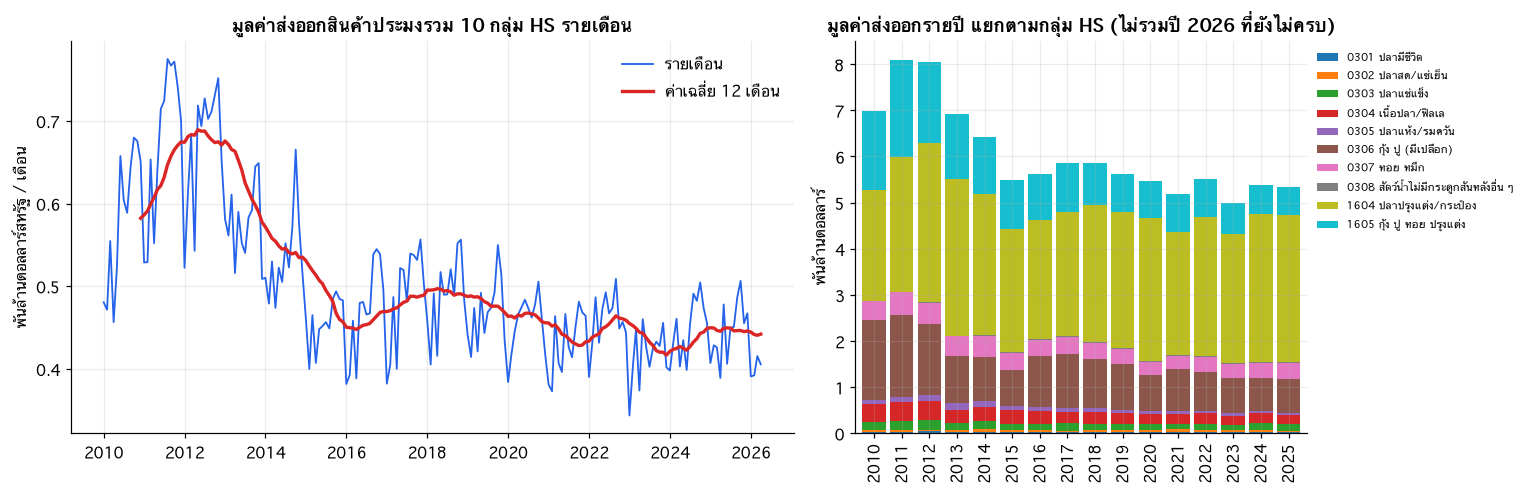

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
รวมทั้งปี (พันล้านดอลลาร์),6.99,8.10,8.05,6.93,6.42,5.48,5.63,5.87,5.87,5.62,5.47,5.19,5.50,5.00,5.39,5.35


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.6, 1]})
tot = world.groupby("date").value_usd.sum() / 1e9
ax[0].plot(tot.index, tot.values, color=C["blue"], lw=1.2, label="รายเดือน")
ax[0].plot(tot.rolling(12).mean(), color=C["red"], lw=2.2, label="ค่าเฉลี่ย 12 เดือน")
ax[0].set(title="มูลค่าส่งออกสินค้าประมงรวม 10 กลุ่ม HS รายเดือน", ylabel="พันล้านดอลลาร์สหรัฐ / เดือน")
ax[0].legend(frameon=False)
yr = world[world.year < 2026].groupby(["year", "hs4"]).value_usd.sum().unstack() / 1e9
yr.rename(columns=HS4_NAME).plot.bar(stacked=True, ax=ax[1], width=.85, colormap="tab10")
ax[1].set(title="มูลค่าส่งออกรายปี แยกตามกลุ่ม HS (ไม่รวมปี 2026 ที่ยังไม่ครบ)", ylabel="พันล้านดอลลาร์", xlabel="")
ax[1].legend(fontsize=7, frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()
display((yr.sum(axis=1).rename("รวมทั้งปี (พันล้านดอลลาร์)").to_frame().T).round(2))

In [7]:
share = world[world.year == 2025].groupby("hs4").value_usd.sum().sort_values(ascending=False)
t = pd.DataFrame({"กลุ่ม HS": [HS4_NAME[h] for h in share.index], "มูลค่าปี 2025 (ล้านดอลลาร์)": (share / 1e6).values, "สัดส่วน %": (share / share.sum() * 100).values})
t["สะสม %"] = t["สัดส่วน %"].cumsum()
display(t)

,กลุ่ม HS,มูลค่าปี 2025 (ล้านดอลลาร์),สัดส่วน %,สะสม %
0,1604 ปลาปรุงแต่ง/กระป๋อง,"3,178.40",59.41,59.41
1,0306 กุ้ง ปู (มีเปลือก),724.53,13.54,72.96
2,1605 กุ้ง ปู หอย ปรุงแต่ง,627.85,11.74,84.69
3,0307 หอย หมึก,355.70,6.65,91.34
4,0304 เนื้อปลา/ฟิลเล,196.03,3.66,95.01
5,0303 ปลาแช่แข็ง,147.57,2.76,97.77
6,0305 ปลาแห้ง/รมควัน,45.78,0.86,98.62
7,0301 ปลามีชีวิต,30.17,0.56,99.19
8,0302 ปลาสด/แช่เย็น,29.52,0.55,99.74
9,0308 สัตว์น้ำไม่มีกระดูกสันหลังอื่น ๆ,13.99,0.26,100.00


### 📝 อ่านผล: แนวโน้มและโครงสร้างสินค้าส่งออก

**แนวโน้มมูลค่า**
- ยอดส่งออก 10 กลุ่ม HS รวมต่อปี **สูงสุดที่ 8.10 พันล้านดอลลาร์ (ปี 2011)** แล้วลดลงเหลือ **5.48 (ปี 2015)** จากนั้นเคลื่อนไหวอยู่ในช่วงแคบ ๆ ประมาณ **5.0–5.9** ตลอดปี 2016–2025 (ปี 2025 = 5.35)
- เส้นค่าเฉลี่ย 12 เดือนในกราฟซ้ายแสดงการ "ลดระดับ" ช่วงปี 2012–2015 อย่างชัดเจน ซึ่งเป็น **การเปลี่ยนโครงสร้าง (structural break)** ไม่ใช่ความผันผวนปกติ → ข้อมูลก่อนปี 2015 มี *ระดับและส่วนผสมสินค้าต่างจากปัจจุบัน* ถ้านำไปเทรนโมเดลโดยไม่ระวัง โมเดลจะเรียนรู้จากช่วงที่ไม่เหมือนปัจจุบัน
- กลุ่ม 0306 (กุ้ง ปู มีเปลือก) ในกราฟแท่งขวาหดลงชัดเจนเมื่อเทียบกับช่วงปี 2010–2012 (เหลือ 724.5 ล้านดอลลาร์ในปี 2025)

**โครงสร้างสินค้า (ปี 2025)**
- **1604 ปลาปรุงแต่ง/กระป๋อง = 59.4% ของมูลค่าทั้งหมด (3.18 พันล้านดอลลาร์)** กลุ่มเดียวใหญ่กว่าอีก 9 กลุ่มรวมกัน
- 3 กลุ่มแรก (1604, 0306, 1605) รวม **84.7%** และ 5 กลุ่มแรกรวม **95.0%** ส่วน 0301, 0302, 0308 แต่ละกลุ่มไม่ถึง 1%

**ผลต่อโปรเจกต์:** ถ้ารวมทุกสินค้าเข้าด้วยกันโดยไม่ปรับสเกล ผลการจัดกลุ่มและโมเดลจะถูกครอบงำด้วยกลุ่ม 1604 → ในขั้น Data Preparation ต้องแยกวิเคราะห์ตามกลุ่ม HS หรือใช้ค่าสัมพัทธ์ (สัดส่วน / การเปลี่ยนแปลง) / ใช้ log และควรจำกัดช่วงข้อมูลเทรนไปที่ **ปี 2015 เป็นต้นไป**

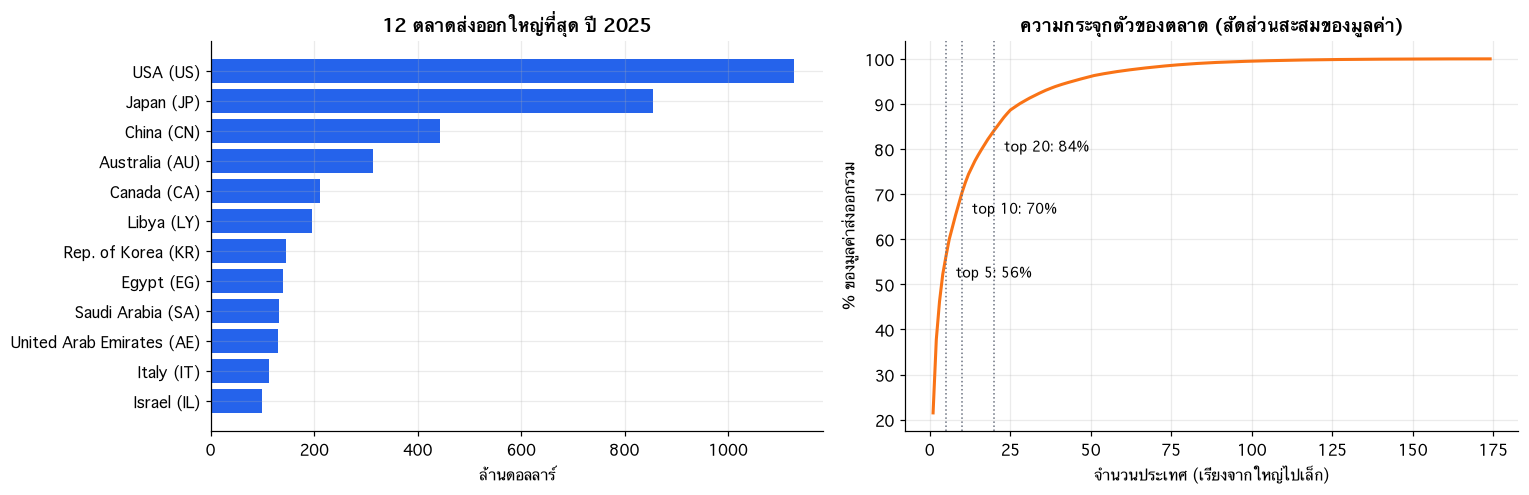

ปี 2025 มีประเทศคู่ค้า 174 ประเทศ/เขต
กลุ่มที่ไม่มีรหัสประเทศ ISO2 (เช่น 'nes' = ไม่ระบุประเทศ) คิดเป็น 1.9% ของมูลค่าปี 2025: {'Other Asia, nes': 100.9, 'Areas, nes': 0.0} (ล้านดอลลาร์)


In [8]:
# ประเทศคู่ค้า: ใครคือตลาดหลัก และกระจุกตัวแค่ไหน
p25 = part[(part.year == 2025) & part.partner_iso2.notna()].groupby(["partner_iso2", "partner_name"]).value_usd.sum().sort_values(ascending=False)
top = p25.head(12)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].barh([f"{n} ({i})" for (i, n) in top.index][::-1], top.values[::-1] / 1e6, color=C["blue"])
ax[0].set(title="12 ตลาดส่งออกใหญ่ที่สุด ปี 2025", xlabel="ล้านดอลลาร์")
cum = p25.cumsum() / p25.sum() * 100
ax[1].plot(range(1, len(cum) + 1), cum.values, color=C["orange"], lw=2)
for k in (5, 10, 20):
    ax[1].axvline(k, color=C["gray"], ls=":", lw=1); ax[1].annotate(f"top {k}: {cum.iloc[k-1]:.0f}%", (k, cum.iloc[k-1]), textcoords="offset points", xytext=(6, -14), fontsize=9)
ax[1].set(title="ความกระจุกตัวของตลาด (สัดส่วนสะสมของมูลค่า)", xlabel="จำนวนประเทศ (เรียงจากใหญ่ไปเล็ก)", ylabel="% ของมูลค่าส่งออกรวม")
plt.tight_layout(); plt.show()
print(f"ปี 2025 มีประเทศคู่ค้า {len(p25)} ประเทศ/เขต")
nes = part[(part.year == 2025) & part.partner_iso2.isna()].groupby("partner_name").value_usd.sum().sort_values(ascending=False)
nes_share = nes.sum() / part[part.year == 2025].value_usd.sum()
print(f"กลุ่มที่ไม่มีรหัสประเทศ ISO2 (เช่น 'nes' = ไม่ระบุประเทศ) คิดเป็น {nes_share:.1%} ของมูลค่าปี 2025:", {k: round(v / 1e6, 1) for k, v in nes.head(5).items()}, "(ล้านดอลลาร์)")

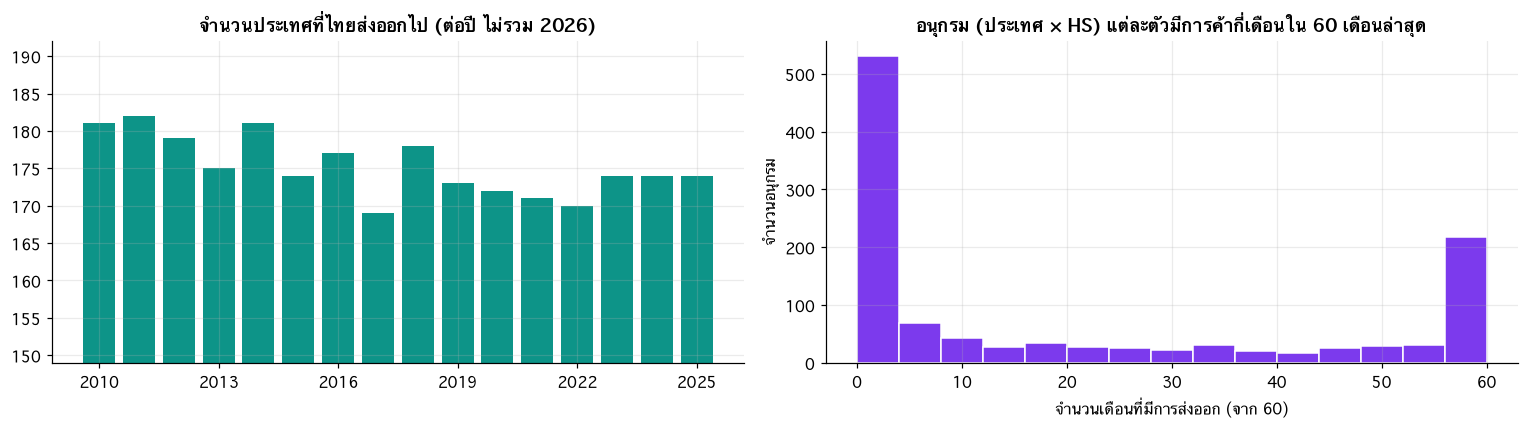

อนุกรม (ประเทศ × HS) ที่เคยมีการค้าทั้งหมด: 1,148


,เกณฑ์ (เดือนที่มีการค้าจาก 60),จำนวนอนุกรม,สัดส่วนมูลค่าที่ครอบคลุม %
0,>= 24,417,99.54
1,>= 36,340,98.83
2,>= 48,278,98.30
3,>= 58,200,95.51


In [9]:
# จำนวนตลาดที่ส่งออกไปจริงในแต่ละปี และความต่อเนื่องของ "อนุกรมประเทศ × HS"
n_partner = part[part.partner_iso2.notna() & (part.year < 2026)].groupby("year").partner_iso2.nunique()
pair = part[part.partner_iso2.notna()].pivot_table(index=["hs4", "partner_iso2"], columns="date", values="value_usd", aggfunc="sum").fillna(0)
last60 = pair.iloc[:, -60:]
active = (last60 > 0).sum(axis=1)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(n_partner.index, n_partner.values, color=C["teal"]); ax[0].set(title="จำนวนประเทศที่ไทยส่งออกไป (ต่อปี ไม่รวม 2026)", ylim=(n_partner.min() - 20, n_partner.max() + 10), xticks=n_partner.index[::3])
ax[1].hist(active, bins=range(0, 62, 4), color=C["purple"], edgecolor="white")
ax[1].set(title="อนุกรม (ประเทศ × HS) แต่ละตัวมีการค้ากี่เดือนใน 60 เดือนล่าสุด", xlabel="จำนวนเดือนที่มีการส่งออก (จาก 60)", ylabel="จำนวนอนุกรม")
plt.tight_layout(); plt.show()
k = pd.DataFrame({"เกณฑ์ (เดือนที่มีการค้าจาก 60)": [">= 24", ">= 36", ">= 48", ">= 58"], "จำนวนอนุกรม": [(active >= k).sum() for k in (24, 36, 48, 58)],
                  "สัดส่วนมูลค่าที่ครอบคลุม %": [last60[active >= k].values.sum() / last60.values.sum() * 100 for k in (24, 36, 48, 58)]})
print(f"อนุกรม (ประเทศ × HS) ที่เคยมีการค้าทั้งหมด: {len(pair):,}")
display(k)

### 📝 อ่านผล: ประเทศคู่ค้าและความต่อเนื่องของอนุกรม

**ความกระจุกตัวของตลาด (ปี 2025: 174 ประเทศ/เขต)**
- ตลาดใหญ่สุดคือ **สหรัฐฯ (ราว 1.1 พันล้านดอลลาร์)** ตามด้วยญี่ปุ่น (ราว 0.85) จีน (ราว 0.44) ออสเตรเลีย (ราว 0.31) และแคนาดา (ราว 0.21)
- **5 ตลาดแรก = 56%, 10 ตลาดแรก = 70%, 20 ตลาดแรก = 84%** ของมูลค่า ที่เหลือราว 150 ประเทศแบ่งกันเพียง 16%
- ใน 12 อันดับแรกมีประเทศตะวันออกกลาง/แอฟริกาเหนือหลายแห่ง (ลิเบีย อียิปต์ ซาอุดีอาระเบีย สหรัฐอาหรับเอมิเรตส์ อิสราเอล) ซึ่งต่างจากภาพจำที่ตลาดหลักคือสหรัฐฯ/ญี่ปุ่น/จีน อย่างเดียว → เป็นเหตุผลให้ **จัดกลุ่มตลาด** น่าสนใจ
- จำนวนประเทศที่ส่งออกไปต่อปีค่อนข้างนิ่ง (ราว 169–182 ประเทศ ตลอดปี 2010–2025) แปลว่า "ชุดของตลาด" ค่อนข้างเสถียร

**ความต่อเนื่องของอนุกรม (ประเทศ × HS) มีทั้งหมด 1,148 อนุกรม**
- กราฟขวาเป็น 2 กลุ่มชัดเจน: **ราว 530 อนุกรมมีการค้าไม่เกิน 3 เดือนจาก 60 เดือนล่าสุด** (การค้าประปราย) กับ **ราว 217 อนุกรมที่มีการค้าเกือบทุกเดือน (≥ 56)**
- อนุกรมที่มีการค้า ≥ 36 เดือน (จาก 60) มี **340 อนุกรม แต่ครอบคลุม 98.8% ของมูลค่า** นั่นคือ **ตัดอนุกรมประปรายราว 800 อนุกรมทิ้งได้ โดยเสียมูลค่าเพียง 1.2%**
- กลุ่มที่ไม่มีรหัสประเทศ ISO2 (เช่น "Other Asia, nes") คิดเป็น **1.9%** ของมูลค่าปี 2025 (ตามปกติ UN Comtrade ใช้ชื่อกลุ่มนี้แทนไต้หวัน — ควรยืนยัน) จึง join กับข้อมูลเศรษฐกิจรายประเทศไม่ได้

**ผลต่อโปรเจกต์:** ขนาดข้อมูลสำหรับ clustering และ classification เพียงพอ (340 อนุกรมที่เสถียร × 183 เดือน ≈ 62,000 แถว) และตัวเลขที่ต้องระวังคือ ต้องกำหนดเกณฑ์ "อนุกรมที่ใช้ได้" ตั้งแต่ต้นไม่ให้ปะปนกับตลาดประปราย

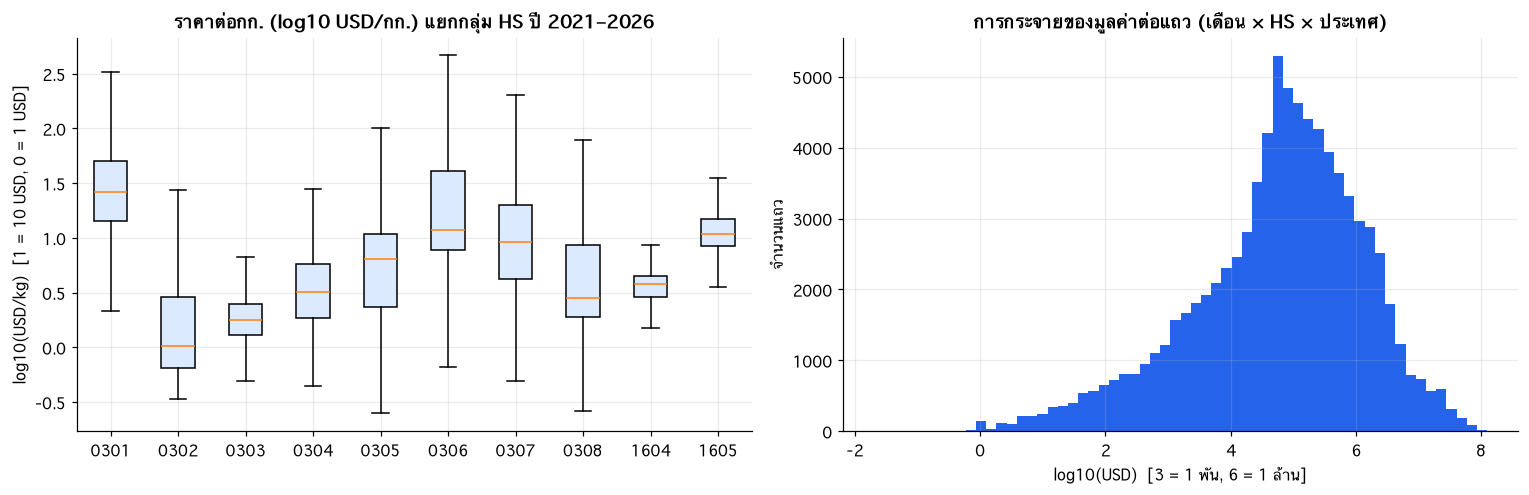

,count,min,50%,mean,max
hs4,,,,,
0301 ปลามีชีวิต,"3,853.00",0.19,26.49,47.74,"3,765.82"
0302 ปลาสด/แช่เย็น,545.00,0.33,1.03,2.49,77.23
0303 ปลาแช่แข็ง,"1,721.00",0.12,1.77,2.32,79.17
0304 เนื้อปลา/ฟิลเล,"1,509.00",0.24,3.18,4.40,46.18
0305 ปลาแห้ง/รมควัน,"1,726.00",0.03,6.39,9.11,"1,899.99"
0306 กุ้ง ปู (มีเปลือก),"3,272.00",0.22,11.89,120.72,"10,105.19"
0307 หอย หมึก,"2,656.00",0.16,9.10,18.24,804.21
0308 สัตว์น้ำไม่มีกระดูกสันหลังอื่น ๆ,570.00,0.16,2.84,14.93,980.01
1604 ปลาปรุงแต่ง/กระป๋อง,"7,351.00",0.25,3.80,3.88,43.81


In [10]:
# หน่วยราคา (USD ต่อกก.) และการกระจายของมูลค่า
pm = part[(part.net_weight_kg > 0) & (part.value_usd > 0) & (part.year >= 2021)].copy()
pm["usd_per_kg"] = pm.value_usd / pm.net_weight_kg
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
order = SEAFOOD_HS4
ax[0].boxplot([np.log10(pm[pm.hs4 == h].usd_per_kg) for h in order], showfliers=False, patch_artist=True, boxprops={"facecolor": "#dbeafe"}); ax[0].set_xticklabels(order)
ax[0].set(title="ราคาต่อกก. (log10 USD/กก.) แยกกลุ่ม HS ปี 2021–2026", ylabel="log10(USD/kg)  [1 = 10 USD, 0 = 1 USD]")
ax[1].hist(np.log10(part.value_usd[part.value_usd > 0]), bins=60, color=C["blue"])
ax[1].set(title="การกระจายของมูลค่าต่อแถว (เดือน × HS × ประเทศ)", xlabel="log10(USD)  [3 = 1 พัน, 6 = 1 ล้าน]", ylabel="จำนวนแถว")
plt.tight_layout(); plt.show()
display(pm.groupby("hs4").usd_per_kg.describe(percentiles=[.5]).rename(index=HS4_NAME)[["count", "min", "50%", "mean", "max"]])

### 📝 อ่านผล: ราคาต่อกิโลกรัมและการกระจายของมูลค่า

- ราคาต่อกก. ต่างกันเป็นสิบเท่าตามชนิดสินค้า: **1604 ปลากระป๋อง มัธยฐาน 3.80 USD/กก. (ช่วงแคบ: เฉลี่ย 3.88, สูงสุด 43.8)**, 0303 ปลาแช่แข็ง 1.77, 0302 ปลาสด/แช่เย็น 1.03, 0306 กุ้ง ปู 11.89, 0307 หอย หมึก 9.10, 0301 ปลามีชีวิต 26.49 (สูงสุดในกลุ่ม; ยังไม่ได้ตรวจว่าเป็นสินค้าชนิดใด)
- **ค่าสุดโต่งมีมาก:** 0306 มัธยฐาน 11.89 แต่ *ค่าเฉลี่ย 120.72 และสูงสุด 10,105 USD/กก.* บ่งว่ามีแถวที่น้ำหนักน้อยมากแต่มูลค่าสูง (ยังไม่ได้ตรวจว่าเป็นสินค้าอะไร) → ถ้าใช้ราคาต่อกก. เป็น feature ต้องใช้ *มัธยฐาน* หรือจำกัดค่าสุดโต่ง (winsorize) ไม่ใช่ค่าเฉลี่ยตรง ๆ
- มูลค่าต่อแถว (เดือน × HS × ประเทศ) กระจายตัวกว้างมาก ตั้งแต่ 0.02 ถึง 323.9 ล้านดอลลาร์ แต่รูปร่างของ log10 ค่อนข้างเป็นระฆังคว่ำ (มัธยฐาน 85,743 USD) → **ควรใช้ log หรือเปรียบเทียบแบบสัมพัทธ์** ไม่ใช้ค่าดิบ
- คอลัมน์ `net_weight_kg` ว่างเพียง 0.2% ใช้คำนวณราคาต่อหน่วยได้ ส่วน `qty_unit` ว่าง 100% และ `cif_usd` ว่างครึ่งหนึ่ง ไม่ควรใช้

### 2.2.1 ฤดูกาลและความผันผวน (ข้อมูลเหล่านี้ใช้ตัดสินว่าโจทย์พยากรณ์รายเดือนเป็นไปได้หรือไม่)

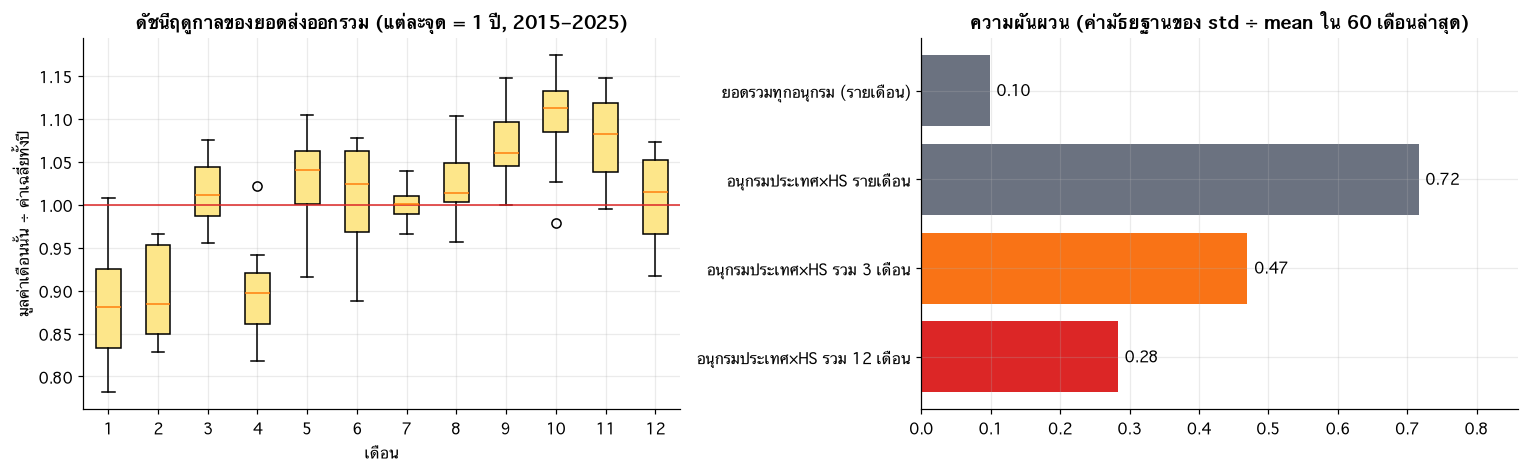

ดัชนีฤดูกาลเฉลี่ยรายเดือน (1.00 = ค่าเฉลี่ยปี): {1: 0.88, 2: 0.9, 3: 1.02, 4: 0.9, 5: 1.03, 6: 1.01, 7: 1.0, 8: 1.03, 9: 1.07, 10: 1.1, 11: 1.08, 12: 1.0}


In [11]:
# ดัชนีฤดูกาลของยอดรวม: มูลค่าเดือนนั้น / ค่าเฉลี่ยของปีนั้น (2015–2025)
W = world[world.year.between(2015, 2025)].groupby(["year", "month"]).value_usd.sum().unstack()
idx = W.div(W.mean(axis=1), axis=0)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
ax[0].boxplot([idx[m] for m in range(1, 13)], patch_artist=True, boxprops={"facecolor": "#fde68a"}); ax[0].set_xticklabels(range(1, 13))
ax[0].axhline(1, color=C["red"], lw=1)
ax[0].set(title="ดัชนีฤดูกาลของยอดส่งออกรวม (แต่ละจุด = 1 ปี, 2015–2025)", xlabel="เดือน", ylabel="มูลค่าเดือนนั้น ÷ ค่าเฉลี่ยทั้งปี")
# เทียบความผันผวนระดับต่าง ๆ
sel = pair[active >= 36]
cv = lambda M: (M.std(axis=1) / M.mean(axis=1)).median()
m1 = sel.iloc[:, -60:]
m3 = sel.T.rolling(3).sum().T.iloc[:, -60:]
m12 = sel.T.rolling(12).sum().T.iloc[:, -60:]
lv = pd.Series({"ยอดรวมทุกอนุกรม (รายเดือน)": W.stack().std() / W.stack().mean(), "อนุกรมประเทศ×HS รายเดือน": cv(m1),
                "อนุกรมประเทศ×HS รวม 3 เดือน": cv(m3), "อนุกรมประเทศ×HS รวม 12 เดือน": cv(m12)})
ax[1].barh(lv.index[::-1], lv.values[::-1], color=[C["gray"], C["gray"], C["orange"], C["red"]][::-1])
for i, v in enumerate(lv.values[::-1]): ax[1].text(v + .01, i, f"{v:.2f}", va="center")
ax[1].set(title="ความผันผวน (ค่ามัธยฐานของ std ÷ mean ใน 60 เดือนล่าสุด)", xlim=(0, lv.max() * 1.2))
plt.tight_layout(); plt.show()
print("ดัชนีฤดูกาลเฉลี่ยรายเดือน (1.00 = ค่าเฉลี่ยปี):", idx.mean().round(2).to_dict())

autocorrelation ของ 340 อนุกรมที่มีการค้าสม่ำเสมอ (ค่ามัธยฐาน)


,ระดับ (มีแนวโน้มปนอยู่),หลังตัดแนวโน้ม (diff)
lag 1 (เดือนก่อน),0.30,-0.46
lag 12 (เดือนเดียวกันปีก่อน),0.12,0.05


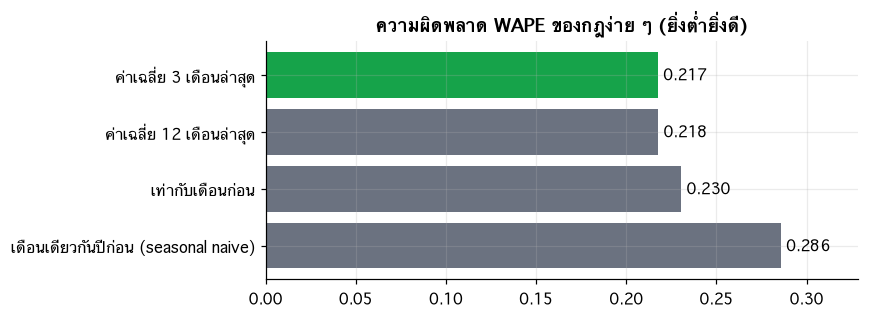

,WAPE
ค่าเฉลี่ย 3 เดือนล่าสุด,0.217
ค่าเฉลี่ย 12 เดือนล่าสุด,0.218
เท่ากับเดือนก่อน,0.230
เดือนเดียวกันปีก่อน (seasonal naive),0.286


In [12]:
# สัญญาณที่พยากรณ์ได้ในข้อมูล: autocorrelation (หลังตัดแนวโน้มด้วย first-difference ของ log)
def ac(x, k):
    x = x[~np.isnan(x)]; x = x - x.mean(); d = (x * x).sum()
    return (x[k:] * x[:-k]).sum() / d if d > 0 and len(x) > k + 2 else np.nan

L = np.log1p(sel.iloc[:, 60:])
Dd = L.diff(axis=1).iloc[:, 1:]
acf = pd.DataFrame({
    "ระดับ (มีแนวโน้มปนอยู่)": [L.apply(lambda r: ac(r.values, 1), axis=1).median(), L.apply(lambda r: ac(r.values, 12), axis=1).median()],
    "หลังตัดแนวโน้ม (diff)":    [Dd.apply(lambda r: ac(r.values, 1), axis=1).median(), Dd.apply(lambda r: ac(r.values, 12), axis=1).median()],
}, index=["lag 1 (เดือนก่อน)", "lag 12 (เดือนเดียวกันปีก่อน)"])
print(f"autocorrelation ของ {len(sel)} อนุกรมที่มีการค้าสม่ำเสมอ (ค่ามัธยฐาน)")
display(acf)

# กฎพยากรณ์ง่าย ๆ ทำนายเดือนถัดไป: ดูว่ากฎไหนผิดพลาดน้อยสุดบน 100 อนุกรมใหญ่ 36 เดือนล่าสุด
top100 = sel.sum(axis=1).sort_values(ascending=False).head(100).index
T_ = pair.loc[top100].values; n = T_.shape[1]; tm = range(n - 36, n)
def wape(f):
    a = np.concatenate([T_[:, t] for t in tm]); p = np.concatenate([f(t) for t in tm]); return np.abs(a - p).sum() / a.sum()
rules = pd.Series({
    "เท่ากับเดือนก่อน": wape(lambda t: T_[:, t - 1]),
    "ค่าเฉลี่ย 3 เดือนล่าสุด": wape(lambda t: T_[:, t - 3:t].mean(axis=1)),
    "ค่าเฉลี่ย 12 เดือนล่าสุด": wape(lambda t: T_[:, t - 12:t].mean(axis=1)),
    "เดือนเดียวกันปีก่อน (seasonal naive)": wape(lambda t: T_[:, t - 12]),
}).sort_values()
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(rules.index[::-1], rules.values[::-1], color=[C["gray"]] * 3 + [C["green"]]); ax.set(title="ความผิดพลาด WAPE ของกฎง่าย ๆ (ยิ่งต่ำยิ่งดี)", xlim=(0, rules.max() * 1.15))
for i, v in enumerate(rules.values[::-1]): ax.text(v + .003, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()
display(rules.round(3).map("{:.3f}".format).rename("WAPE").to_frame())

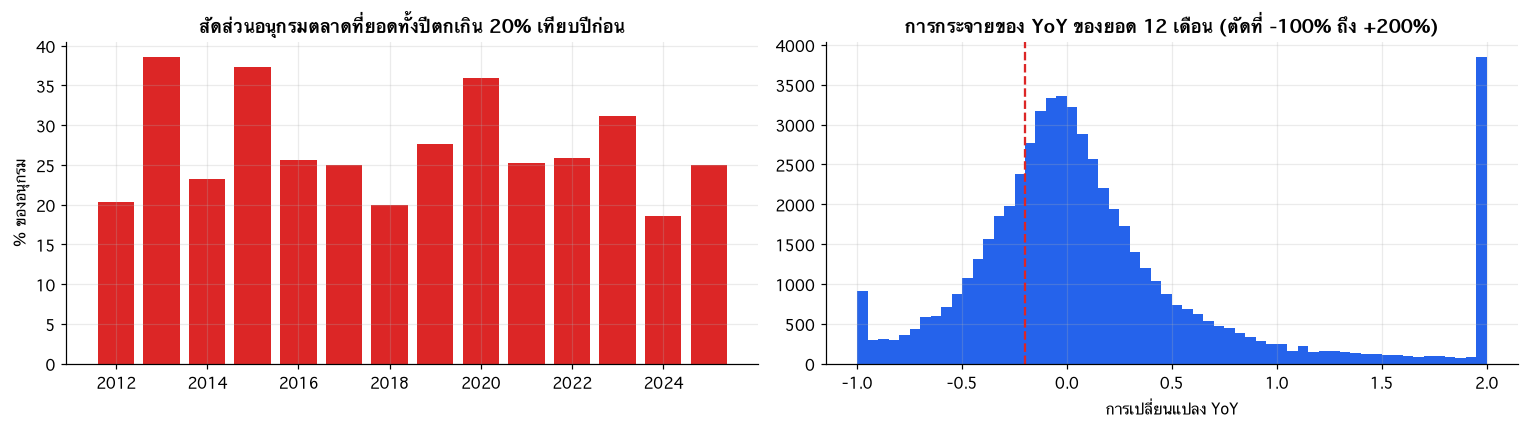

สัดส่วนอนุกรม-เดือนที่ยอด 12 เดือนตกเกิน 20% (YoY): 26.9% จากทั้งหมด 55,156 จุด
โอกาสที่ 6 เดือนต่อมายังตกเกิน 20%: ถ้าตอนนี้ตกอยู่ = 54.1% | โดยรวม = 27.3%  (หมายเหตุ: หน้าต่าง 12 เดือนซ้อนกัน 6 เดือน ตัวเลขนี้จึงสูงกว่าความเป็นจริงส่วนหนึ่ง)


In [13]:
# ตลาดที่ "ยอดตก" เกิดบ่อยแค่ไหน และตกต่อเนื่องไหม? (ใช้ยอดรวม 12 เดือนเพื่อลดความผันผวนรายเดือน)
r12 = sel.T.rolling(12).sum().T
yoy = r12 / r12.shift(12, axis=1) - 1                       # ยอด 12 เดือนล่าสุด เทียบ 12 เดือนก่อนหน้า
dec = [c for c in yoy.columns if c.month == 12 and c.year >= 2012]
drop_by_year = pd.Series({c.year: (yoy[c] < -0.2).mean() for c in dec})
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(drop_by_year.index, drop_by_year.values * 100, color=C["red"]); ax[0].set(title="สัดส่วนอนุกรมตลาดที่ยอดทั้งปีตกเกิน 20% เทียบปีก่อน", ylabel="% ของอนุกรม", xticks=drop_by_year.index[::2])
ax[1].hist(yoy.stack().clip(-1, 2), bins=60, color=C["blue"]); ax[1].axvline(-0.2, color=C["red"], ls="--"); ax[1].set(title="การกระจายของ YoY ของยอด 12 เดือน (ตัดที่ -100% ถึง +200%)", xlabel="การเปลี่ยนแปลง YoY")
plt.tight_layout(); plt.show()
now, later = yoy.iloc[:, 12:-6].values, yoy.iloc[:, 18:].values
m_ = np.isfinite(now) & np.isfinite(later)
p_all = (later[m_] < -0.2).mean(); p_cond = (later[m_ & (now < -0.2)] < -0.2).mean()
print(f"สัดส่วนอนุกรม-เดือนที่ยอด 12 เดือนตกเกิน 20% (YoY): {(now[m_] < -0.2).mean():.1%} จากทั้งหมด {m_.sum():,} จุด")
print(f"โอกาสที่ 6 เดือนต่อมายังตกเกิน 20%: ถ้าตอนนี้ตกอยู่ = {p_cond:.1%} | โดยรวม = {p_all:.1%}  (หมายเหตุ: หน้าต่าง 12 เดือนซ้อนกัน 6 เดือน ตัวเลขนี้จึงสูงกว่าความเป็นจริงส่วนหนึ่ง)")

### 📝 อ่านผล: ฤดูกาลและความผันผวน — ข้อมูลช่วยตอบว่าพยากรณ์รายเดือนทำได้แค่ไหน

**1) ฤดูกาลของยอดรวม: มีแต่อ่อน**
- ดัชนีฤดูกาลเฉลี่ยอยู่ระหว่าง **0.88 (ม.ค.) ถึง 1.10 (ต.ค.)** เดือน ม.ค., ก.พ., เม.ย. ต่ำกว่าเฉลี่ย (0.88, 0.90, 0.90) และ ก.ย.–พ.ย. สูงกว่าเฉลี่ย (1.07, 1.10, 1.08) แต่กล่อง (ช่วงของแต่ละปี) ของหลายเดือนซ้อนกัน แปลว่าแม้รูปแบบจะพอเห็น ก็ไม่แน่นอนพอที่จะทำนายค่าเฉพาะเดือนได้ชัด

**2) ความผันผวนลดลงเมื่อรวมช่วงเวลายาวขึ้น (กราฟขวา)**
| ระดับการรวม | ความผันผวน (std ÷ mean) |
|---|---|
| ยอดรวมทุกอนุกรม รายเดือน | 0.10 |
| อนุกรมประเทศ×HS รายเดือน | **0.72** |
| อนุกรมประเทศ×HS รวม 3 เดือน | 0.47 |
| อนุกรมประเทศ×HS รวม 12 เดือน | **0.28** |

ระดับ "ประเทศ × HS รายเดือน" สั่นไหวมากถึง 0.72 แต่เมื่อรวม 12 เดือนเหลือ 0.28 → **สัญญาณชัดขึ้นเมื่อใช้ช่วงเวลายาว**

**3) Autocorrelation (ค่ามัธยฐานของ 340 อนุกรม)**
- หลังตัดแนวโน้ม **lag 1 = −0.46**: เดือนที่สูงมักตามด้วยเดือนที่ต่ำ (ความผันผวนสุ่มที่เด้งกลับ) และ **lag 12 = 0.05**: *แทบไม่มีความสัมพันธ์กับเดือนเดียวกันของปีก่อน* → ในระดับอนุกรมย่อย ไม่มีฤดูกาลที่ทำนายได้

**4) กฎพยากรณ์ง่าย ๆ (100 อนุกรมใหญ่ 36 เดือนล่าสุด ทำนายเดือนถัดไป)**
- ค่าเฉลี่ย 3 หรือ 12 เดือนล่าสุด **WAPE 0.220** (ดีสุด) · เท่ากับเดือนก่อน 0.233 · **seasonal naive (เดือนเดียวกันปีก่อน) 0.288 แย่สุด**
- สอดคล้องกับข้อ 3: การย้อนดูปีก่อนไม่ช่วย ค่าเฉลี่ยง่าย ๆ ทำได้ดีกว่า

**ข้อสรุปต่อโจทย์** → โจทย์ *พยากรณ์ยอดเดือนถัดไปรายประเทศ × HS* มีเพดานความแม่นยำใกล้ WAPE ≈ 0.22 ของกฎง่าย ๆ ไม่มีที่ว่างให้ ML ชนะได้ชัดเจน (ยังไม่ได้ทดสอบโมเดลจริง นี่คือการประเมินจากข้อมูล) → จึง **ตั้งความคาดหวังล่วงหน้า** ใน Goal 1 (ส่วน 1.4) ว่าผลที่พอเป็นไปได้คือ ML ใกล้เคียงหรือไม่ชนะ baseline และออกแบบการทดสอบให้รายงานผลตามจริงได้ไม่ว่าจะออกมาอย่างไร

**5) โจทย์ Early Warning (ยอดทั้งปีตกเกิน 20%)**
- **26.9% ของจุด (อนุกรม × เดือน) มียอด 12 เดือนตกเกิน 20% เทียบปีก่อน** (จาก 55,156 จุด) คลาสบวกไม่ได้หายากมาก ไม่ต้องจัดการ imbalance รุนแรง
- **สัดส่วนต่างกันมากตามปี:** สูงที่ปี 2013 (≈ 39%), 2015 (≈ 37%), 2020 (≈ 36%), 2023 (≈ 31%) และต่ำที่สุดปี 2024 (≈ 19%) → การตกของตลาดมักเกิดเป็นช่วงที่พร้อมกันหลายตลาด (ผลกระทบตลาดโลกหรือเหตุการณ์ใหญ่) ดังนั้น **ต้องแบ่งข้อมูลตามเวลาและตรวจโมเดลข้ามหลายช่วงปี** ไม่ใช่แค่ปีเดียว
- ถ้าตอนนี้ตกอยู่ โอกาสที่ 6 เดือนต่อมายังตกเกิน 20% = **54.1%** เทียบกับ 27.3% โดยรวม แสดงว่ามีความต่อเนื่องของการตกอยู่ แต่ *ส่วนหนึ่งเกิดจากหน้าต่าง 12 เดือนที่ซ้อนกัน* จึงยังไม่ใช่หลักฐานว่าทำนายได้จริง โมเดลต้องชนะ baseline "ตกอยู่ → ตกต่อ" นี้ให้ได้

## 2.3 ข้อมูลกรมประมง: นำเข้า-ส่งออกรายเดือนตามรหัส HS 11 หลัก (`trade_hs`)

ข้อมูลชุดแรกที่ได้รับ (ชุด `impexp_product`) อ่านจากไฟล์ดิบ 2 ไฟล์ที่แยกปีแล้ว เพื่อให้เห็นปัญหาของข้อมูลต้นฉบับ

In [14]:
th = pd.concat([rd(f, dtype={"heading11": str}) for f in sorted((DATA / "trade").glob("dof_trade_hs_monthly_*.csv"))], ignore_index=True)
th["date"] = pd.to_datetime(dict(year=th.year - 543, month=th.month, day=1))   # ปี พ.ศ. -> ค.ศ.
th["flow"] = th.tradeflow.map({1: "นำเข้า", 2: "ส่งออก"})
th["hs4"] = th.heading11.str[:4]
print("ขนาด:", th.shape)
display(th.head(8))

ขนาด:

 (65235, 16)


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,fishName,productDetailTH,ETL_DATE,date,flow,hs4
0,2568,1,01062000002,SC,เซเชลส์,200,20,169196,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-01-01,นำเข้า,0106
1,2568,2,01062000002,BJ,เบนิน,10,60,17170,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-02-01,นำเข้า,0106
2,2568,2,01062000002,KE,เคนยา,25,100,39490,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-02-01,นำเข้า,0106
3,2568,2,01062000002,ZM,แซมเบีย,45,450,128875,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-02-01,นำเข้า,0106
4,2568,2,01062000002,MU,มอริเชียส,20,100,113903,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-02-01,นำเข้า,0106
5,2568,2,01062000002,SC,เซเชลส์,420,150,417638,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-02-01,นำเข้า,0106
6,2568,3,01062000002,ET,เอธิโอเปีย,380,50,296224,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-03-01,นำเข้า,0106
7,2568,3,01062000002,QA,กาตาร์,7,80,15584,1,Turtles and snapping turtles live,เต่า,เต่าและตะพาบน้ำมีชีวิต,2026-09-09 06:00:01,2025-03-01,นำเข้า,0106


In [15]:
print("ชนิดข้อมูลและค่าว่าง")
display(pd.DataFrame({"dtype": th.dtypes.astype(str), "ค่าว่าง": th.isna().sum(), "ค่าไม่ซ้ำ": th.nunique()}))
display(th[["weight", "quantity", "price"]].describe(percentiles=[.5, .95]).T)
print(f"ช่วงเวลา: {th.date.min():%b %Y} – {th.date.max():%b %Y} ({th.date.nunique()} เดือน)")
print("จำนวนแถวต่อทิศทาง:", th.flow.value_counts().to_dict(), "| ประเทศ:", th.countryID.nunique(), "| HS11:", th.heading11.nunique(), "| HS4:", th.hs4.nunique())

ชนิดข้อมูลและค่าว่าง


,dtype,ค่าว่าง,ค่าไม่ซ้ำ
year,int64,0,2
month,int64,0,12
heading11,str,0,458
countryID,str,0,199
countryNameTH,str,0,199
weight,int64,0,24523
quantity,int64,0,24836
price,int64,0,57344
tradeflow,int64,0,2
productDetailEN,str,0,266


,count,mean,std,min,50%,95%,max
weight,"65,235.00","88,291.40","439,638.97",0.00,"2,894.00","334,522.30","18,684,570.00"
quantity,"65,235.00","281,232.10","10,237,565.14",0.00,"3,590.00","600,000.00","2,375,725,750.00"
price,"65,235.00","8,957,959.17","40,398,071.77",0.00,"583,249.00","34,654,157.60","1,294,268,120.00"


ช่วงเวลา: Jan 2025 – Jul 2026 (19 เดือน)
จำนวนแถวต่อทิศทาง: {'ส่งออก': 44420, 'นำเข้า': 20815} | ประเทศ: 199 | HS11: 458 | HS4: 25


In [16]:
# ตรวจปัญหาคุณภาพของข้อมูลดิบ
key = ["year", "month", "heading11", "countryID", "tradeflow"]
issues = pd.Series({
    "แถวซ้ำทั้งแถว": int(th.duplicated(subset=[c for c in th.columns if c != "date"]).sum()),
    "แถวที่ key (เดือน, HS11, ประเทศ, ทิศทาง) ซ้ำกัน (ค่าต่างกัน)": int(th.drop_duplicates(subset=[c for c in th.columns if c != "date"]).duplicated(key, keep=False).sum()),
    "รหัสประเทศ 'yy' (ไม่ใช่ประเทศ)": int((th.countryID == "yy").sum()),
    "รายละเอียดสินค้า (อังกฤษ) เป็น '(blank)'": int((th.productDetailEN == "(blank)").sum()),
    "รายละเอียดสินค้า (อังกฤษ) เป็น 'Other'": int((th.productDetailEN == "Other").sum()),
    "น้ำหนัก = 0": int((th.weight == 0).sum()), "มูลค่า = 0": int((th.price == 0).sum()),
})
display(issues.rename("จำนวนแถว").to_frame().assign(**{"% ของทั้งหมด": lambda d: (d["จำนวนแถว"] / len(th) * 100).round(2)}))
ex = th[th.duplicated(key, keep=False)].sort_values(key).head(6)[["year", "month", "heading11", "countryID", "tradeflow", "weight", "quantity", "price", "productDetailEN"]]
print("ตัวอย่าง key ซ้ำ (ไม่มีคอลัมน์ที่บอกว่าแต่ละแถวต่างกันอย่างไร):"); display(ex)

,จำนวนแถว,% ของทั้งหมด
แถวซ้ำทั้งแถว,12,0.02
"แถวที่ key (เดือน, HS11, ประเทศ, ทิศทาง) ซ้ำกัน (ค่าต่างกัน)",15659,24.00
รหัสประเทศ 'yy' (ไม่ใช่ประเทศ),38,0.06
รายละเอียดสินค้า (อังกฤษ) เป็น '(blank)',13710,21.02
รายละเอียดสินค้า (อังกฤษ) เป็น 'Other',12905,19.78
น้ำหนัก = 0,719,1.10
มูลค่า = 0,17,0.03


ตัวอย่าง key ซ้ำ (ไม่มีคอลัมน์ที่บอกว่าแต่ละแถวต่างกันอย่างไร):


,year,month,heading11,countryID,tradeflow,weight,quantity,price,productDetailEN
211,2568,1,03011191000,IT,2,24,875,12959,- - - - Koi carp (Cyprinus carpio)
220,2568,1,03011191000,IT,2,1,60,16957,- - - - Koi carp (Cyprinus carpio)
202,2568,1,03011191000,KR,2,2,140,357,- - - - Koi carp (Cyprinus carpio)
217,2568,1,03011191000,KR,2,6,670,21530,- - - - Koi carp (Cyprinus carpio)
636,2568,1,03011192000,CZ,2,5,1700,2769,- - - - Goldfish (Carassius auratus)
638,2568,1,03011192000,CZ,2,7,2754,75189,- - - - Goldfish (Carassius auratus)


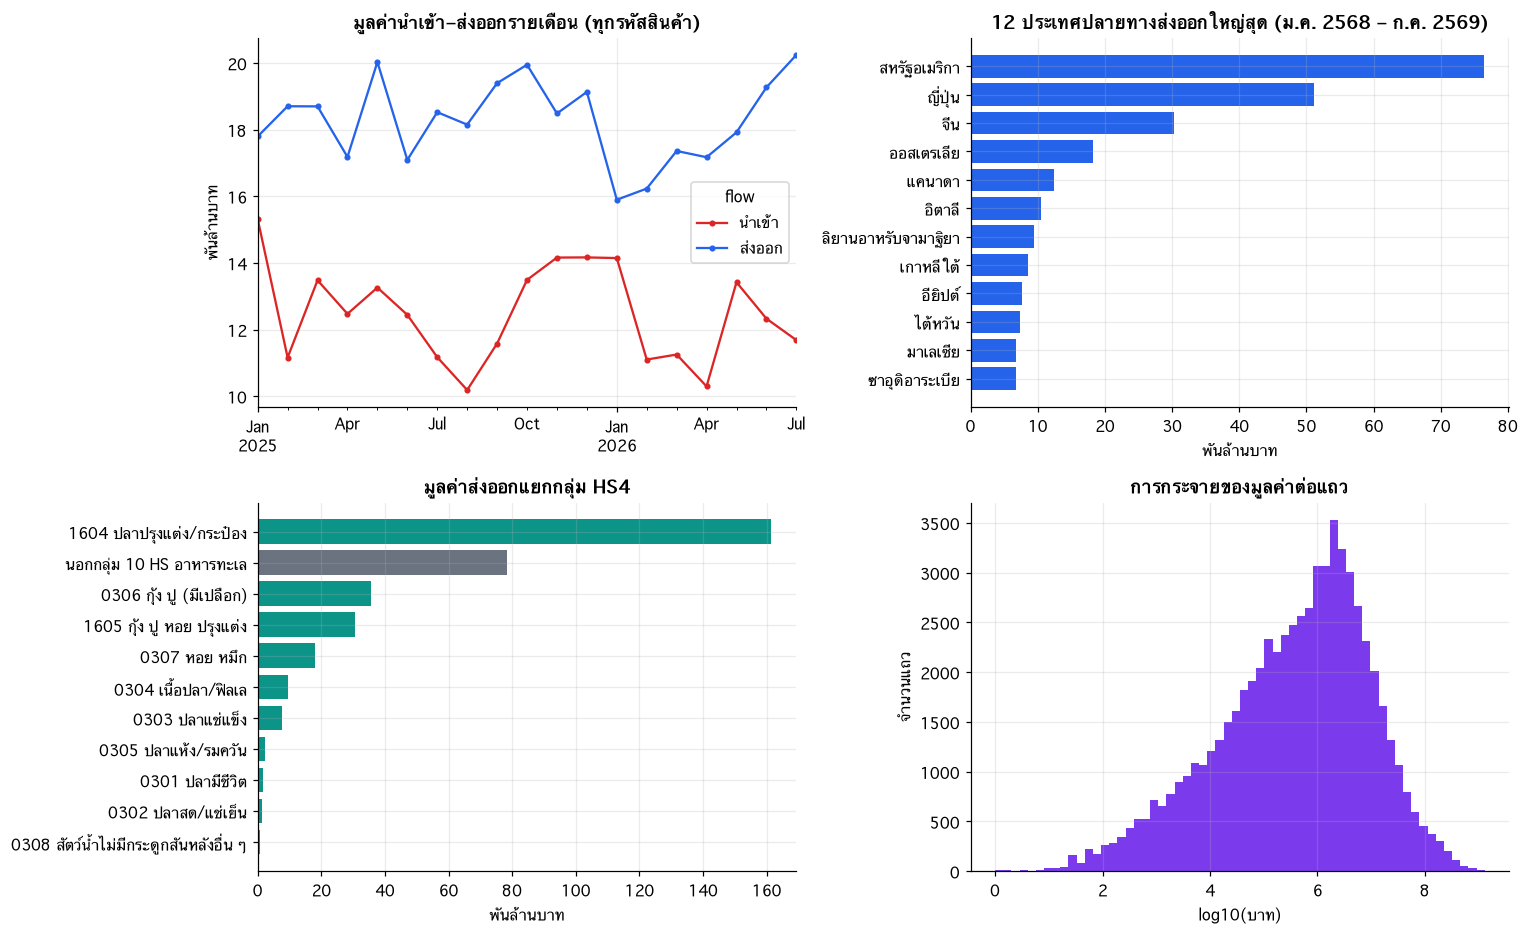

สินค้านอกกลุ่ม 10 HS อาหารทะเลที่อยู่ในไฟล์นี้ (6 อันดับแรก):


,มูลค่า_ล้านบาท,ชื่อสินค้า
hs4,,
2309,"48,874.85",อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะที่อากาศเข้าออกไม่ได้
2103,"17,327.23",น้ำปลา
2301,"8,180.27",ปลาป่นที่มีโปรตีนน้อยกว่าร้อยละ 60
1504,"1,275.26",น้ำมันตับปลาและแฟรกชั่นที่บริโภคได้
0511,"1,178.21",สัตว์ในตอนที่3 ที่ไม่มีชีวิต
1603,548.12,สิ่งสกัดและน้ำคั้นจากปลาหรือสัตว์น้ำไม่มีกระดูกสันหลังอื่นๆ


In [17]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8.6))
m = th.groupby(["date", "flow"]).price.sum().unstack() / 1e9
m.plot(ax=ax[0, 0], color=[C["red"], C["blue"]], marker="o", ms=3); ax[0, 0].set(title="มูลค่านำเข้า–ส่งออกรายเดือน (ทุกรหัสสินค้า)", ylabel="พันล้านบาท", xlabel="")
ex_ = th[th.flow == "ส่งออก"]
c = ex_.groupby("countryNameTH").price.sum().sort_values(ascending=False).head(12) / 1e9
ax[0, 1].barh(c.index[::-1], c.values[::-1], color=C["blue"]); ax[0, 1].set(title="12 ประเทศปลายทางส่งออกใหญ่สุด (ม.ค. 2568 – ก.ค. 2569)", xlabel="พันล้านบาท")
h = ex_.assign(g=np.where(ex_.hs4.isin(SEAFOOD_HS4), ex_.hs4.map(HS4_NAME), "นอกกลุ่ม 10 HS อาหารทะเล")).groupby("g").price.sum().sort_values() / 1e9
ax[1, 0].barh(h.index, h.values, color=[C["gray"] if "นอกกลุ่ม" in i else C["teal"] for i in h.index]); ax[1, 0].set(title="มูลค่าส่งออกแยกกลุ่ม HS4", xlabel="พันล้านบาท")
ax[1, 1].hist(np.log10(th.price[th.price > 0]), bins=60, color=C["purple"]); ax[1, 1].set(title="การกระจายของมูลค่าต่อแถว", xlabel="log10(บาท)", ylabel="จำนวนแถว")
plt.tight_layout(); plt.show()
out = ex_[~ex_.hs4.isin(SEAFOOD_HS4)].groupby("hs4").agg(มูลค่า_ล้านบาท=("price", lambda s: s.sum() / 1e6), ชื่อสินค้า=("productDetailTH", "first")).sort_values("มูลค่า_ล้านบาท", ascending=False).head(6)
print("สินค้านอกกลุ่ม 10 HS อาหารทะเลที่อยู่ในไฟล์นี้ (6 อันดับแรก):"); display(out)

### 📝 อ่านผล: ข้อมูลกรมประมงรายเดือนตามรหัส HS 11 หลัก

**ขนาดและช่วงเวลา:** ไฟล์ดิบ 65,235 แถว × 13 คอลัมน์ (ตารางแสดงเพิ่มคอลัมน์ที่ notebook สร้าง) ช่วง **ม.ค. 2025 – ก.ค. 2026 (19 เดือน)** มี 199 ประเทศ 458 รหัส HS11 (25 กลุ่ม HS4) ส่งออก 44,420 แถว นำเข้า 20,815 แถว

**ปัญหาคุณภาพที่เจอในข้อมูลดิบ**
| ปัญหา | จำนวนแถว | สัดส่วน |
|---|---|---|
| แถวซ้ำทั้งแถว | 12 | 0.02% |
| **key (เดือน, HS11, ประเทศ, ทิศทาง) ซ้ำแต่ค่าต่างกัน** | **15,659** | **24.0%** |
| รายละเอียดสินค้า (อังกฤษ) เป็น "(blank)" | 13,710 | 21.0% |
| รายละเอียดสินค้า (อังกฤษ) เป็น "Other" | 12,905 | 19.8% |
| รหัสประเทศ "yy" / น้ำหนัก = 0 | 38 / 719 | 0.06% / 1.1% |

- **1 ใน 4 ของแถวมี key เดียวกับแถวอื่น แต่ตัวเลขต่างกัน** (ตัวอย่างในตาราง: ปลาคาร์ฟ (Koi) ส่งไปอิตาลี ม.ค. 2025 มี 2 แถว) ไม่มีคอลัมน์ที่บอกว่าแต่ละแถวต่างกันอย่างไร สมมุติฐานคือเป็นหลายใบขนที่ยังไม่รวมกัน (ยังยืนยันไม่ได้) → ต้องรวมยอดตาม key ก่อนใช้เป็นอนุกรมเวลา
- ราว **41%** ของแถวไม่มีชื่อสินค้าที่ใช้งานได้ (blank + Other) → ใช้รหัส `heading11`/ชื่อไทยแทนคอลัมน์อังกฤษ

**ภาพรวมที่เห็น**
- ส่งออก (16–20 พันล้านบาท/เดือน) **สูงกว่านำเข้า (10–15 พันล้านบาท/เดือน) ทุกเดือน**
- ปลายทางส่งออกใหญ่สุดช่วง 19 เดือนนี้: สหรัฐฯ (ราว 76 พันล้านบาท) ญี่ปุ่น (ราว 51) จีน (ราว 30) ออสเตรเลีย (ราว 18) แคนาดา (ราว 12) เรียงอันดับเหมือนที่เห็นใน Comtrade
- **ไฟล์นี้ไม่ได้มีแค่สินค้าอาหารทะเล 10 กลุ่ม HS:** กลุ่มนอก 10 HS (กราฟซ้ายล่าง สีเทา) มีมูลค่ารวมราว 78 พันล้านบาท เด่นสุดคือ **อาหารสุนัข/แมวที่มีปลา (2309) 48,875 ล้านบาท, น้ำปลา (2103) 17,327 ล้านบาท, ปลาป่น (2301) 8,180 ล้านบาท** → ต้องกรอง HS ก่อนเทียบกับแหล่งอื่น (ดูส่วน 2.8)
- มูลค่าต่อแถวกระจายกว้างมาก (log10 บาท 0–9)

**ข้อจำกัด:** 19 เดือนไม่พอทำฤดูกาลหรือ rolling-origin ที่มีความหมาย ใช้เป็นการตรวจเทียบกับ Comtrade และเป็นข้อมูลระดับ HS 11 หลักสำหรับ drill-down

## 2.4 ข้อมูลกรมประมง: ส่งออก-นำเข้า *รายวัน* ระดับสายพันธุ์ (2022–2025)

ข้อมูลจากด่านตรวจประมง ระบุวันที่ ด่าน ประเทศ ชนิดสัตว์น้ำ ลักษณะสินค้า ปริมาณ และมูลค่า (บาท) **ไม่มีรหัส HS** จึงใช้เป็นข้อมูลเสริมระดับสายพันธุ์ ไม่ใช่ข้อมูลหลัก

In [18]:
usecols = ["date", "year", "month", "checkpoint", "country_th", "country_iso2", "transport", "name_th", "group", "water", "form", "qty_kg", "value_thb", "is_dup_row"]
dx = rd(CL / "trade/trade_daily_export.csv", usecols=usecols, parse_dates=["date"]); dx["flow"] = "ส่งออก"
di = rd(CL / "trade/trade_daily_import.csv", usecols=usecols, parse_dates=["date"]); di["flow"] = "นำเข้า"
dd = pd.concat([dx, di], ignore_index=True)
print("ขนาดรวม:", dd.shape, "| ส่งออก", f"{len(dx):,}", "| นำเข้า", f"{len(di):,}")
display(dx.head(8))

ขนาดรวม: (2254417, 15) | ส่งออก 1,413,014 | นำเข้า 841,403


,date,year,month,checkpoint,country_th,transport,name_th,group,water,form,qty_kg,value_thb,country_iso2,is_dup_row,flow
0,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,กุ้งก้ามกราม,กุ้ง,น้ำจืด,แช่เย็น,"4,200.00","300,000.00",MM,False,ส่งออก
1,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,กุ้งก้ามกราม,กุ้ง,น้ำจืด,แช่เย็น,875.00,"16,875.00",MM,False,ส่งออก
2,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,กุ้งขาว,กุ้ง,น้ำทะเล,แช่เย็น,"7,000.00","420,000.00",MM,False,ส่งออก
3,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,กุ้งขาว,กุ้ง,น้ำทะเล,แช่เย็น,"3,500.00","210,000.00",MM,False,ส่งออก
4,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,ปลากะพงขาว,ปลา,น้ำทะเล,แช่เย็น,600.00,"30,000.00",MM,False,ส่งออก
5,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,ปลากะพงขาว,ปลา,น้ำทะเล,แช่เย็น,"4,250.00","212,500.00",MM,False,ส่งออก
6,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,ปลาทูน่าท้องแถบ,ปลา,น้ำทะเล,แช่แข็ง,400.00,"20,000.00",MM,False,ส่งออก
7,2022-01-01,2022,1,ด่านตรวจประมงกาญจนบุรี,พม่า,บก,ปลาทูน่าท้องแถบ,ปลา,น้ำทะเล,แช่แข็ง,375.00,"16,875.00",MM,False,ส่งออก


In [19]:
print("ชนิดข้อมูลและค่าว่าง (ส่งออก)")
display(pd.DataFrame({"dtype": dx.dtypes.astype(str), "ค่าว่าง": dx.isna().sum(), "ค่าไม่ซ้ำ": dx.nunique()}))
display(dx[["qty_kg", "value_thb"]].describe(percentiles=[.5, .9, .99]).T)
r = dd.groupby(["flow", "year"]).agg(rows=("value_thb", "size"), days=("date", "nunique"), val=("value_thb", lambda s: s.sum() / 1e9), dups=("is_dup_row", "sum"))
r["pct"] = r.dups / r.rows * 100
r.columns = ["แถว", "วันที่ไม่ซ้ำ", "มูลค่า (พันล้านบาท)", "แถวที่อยู่ในกลุ่มซ้ำ (นับทุกสำเนา)", "% ของแถว"]
print("\nสรุปรายปี"); display(r)
clog = json.loads((CL / "cleaning_log.json").read_text(encoding="utf-8"))
print(f"จำนวนสำเนาส่วนเกินจริง (ถ้าตัดให้เหลือ 1 แถวต่อกลุ่มที่ซ้ำกัน): ส่งออก {clog['export_daily_exact_dup_rows']:,} แถว | นำเข้า {clog['import_daily_exact_dup_rows']:,} แถว")

ชนิดข้อมูลและค่าว่าง (ส่งออก)


,dtype,ค่าว่าง,ค่าไม่ซ้ำ
date,datetime64[us],0,1461
year,int64,0,4
month,int64,0,12
checkpoint,str,0,25
country_th,str,0,195
transport,str,0,3
name_th,str,0,1048
group,str,0,7
water,str,0,2
form,str,0,27


,count,mean,std,min,50%,90%,99%,max
qty_kg,"1,413,014.00","3,704.36","35,922.96",0.00,125.00,"11,600.64","48,384.00","30,336,768.00"
value_thb,"1,412,926.00","534,908.73","2,181,953.49",0.00,"11,700.00","1,761,163.73","7,311,701.76","1,114,848,000.00"



สรุปรายปี


แถว  วันที่ไม่ซ้ำ  มูลค่า (พันล้านบาท)  แถวที่อยู่ในกลุ่มซ้ำ (นับทุกสำเนา)  % ของแถว
flow   year                                                                                         
นำเข้า 2022   13053            17                 5.07                                 490      3.75
       2023  269355           365               150.08                               10535      3.91
       2024  286645           366               149.65                               12558      4.38
       2025  272350           365               157.58                               13025      4.78
ส่งออก 2022  322523           365               182.85                               25798      8.00
       2023  367522           365               190.07                               24905      6.78
       2024  369200           366               202.39                               24656      6.68
       2025  353769           365               180.47                               22373      6.32

จำนวนสำเนาส่วนเกินจริง (ถ้าตัดให้เหลือ 1 แถวต่อกลุ่มที่ซ้ำกัน): ส่งออก 59,393 แถว | นำเข้า 20,061 แถว


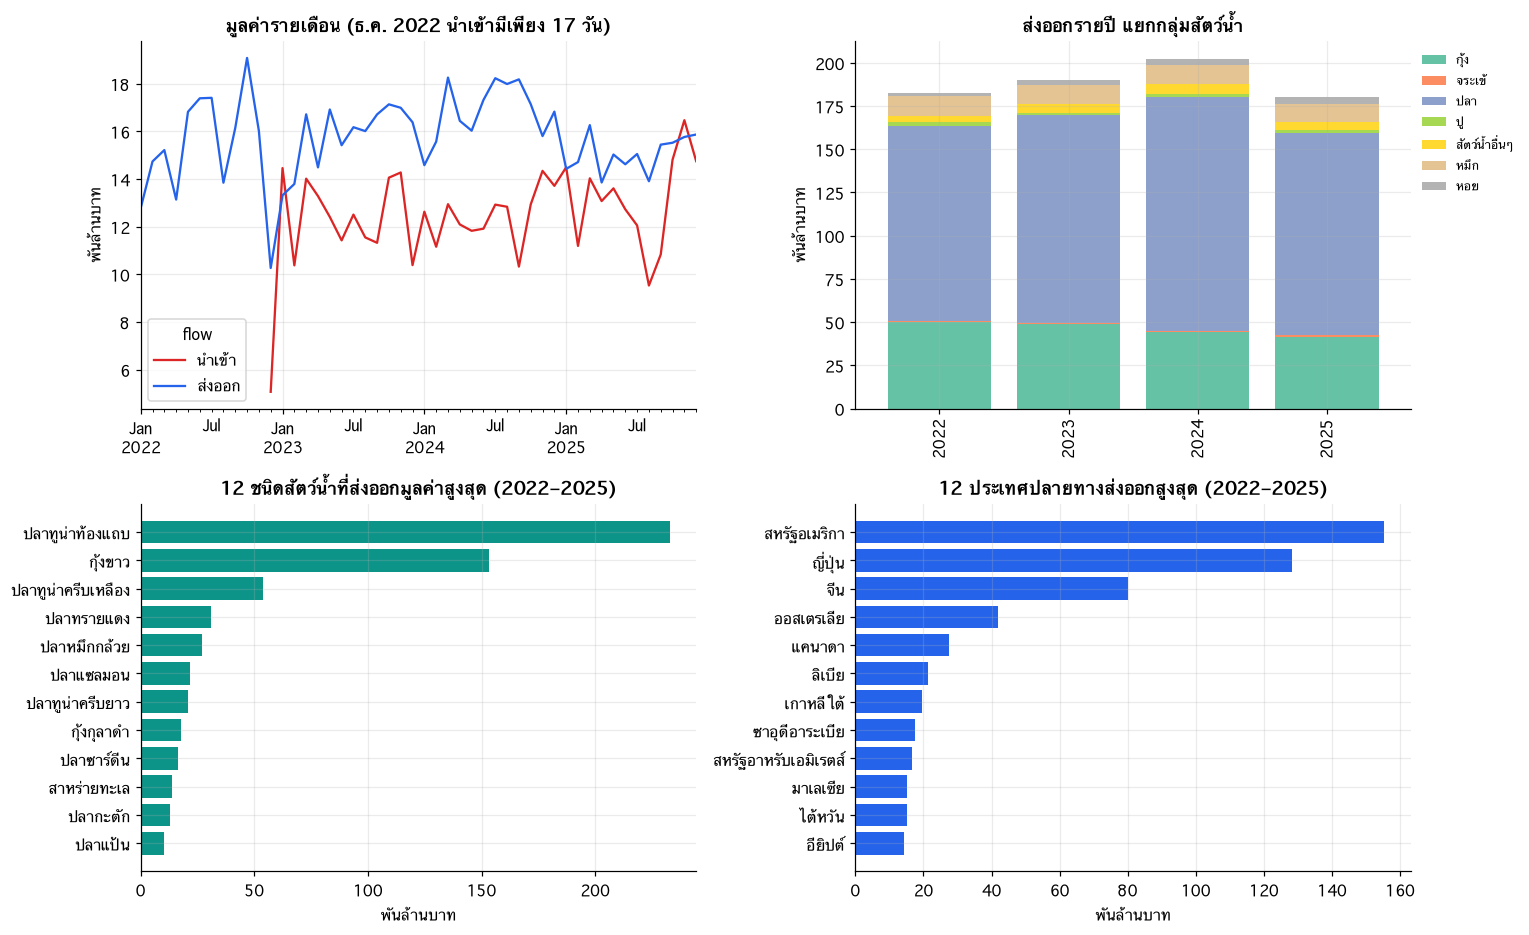

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8.6))
mm = dd.groupby([dd.date.dt.to_period("M").dt.to_timestamp(), "flow"]).value_thb.sum().unstack() / 1e9
mm.plot(ax=ax[0, 0], color=[C["red"], C["blue"]]); ax[0, 0].set(title="มูลค่ารายเดือน (ธ.ค. 2022 นำเข้ามีเพียง 17 วัน)", ylabel="พันล้านบาท", xlabel="")
g = dx.groupby(["year", "group"]).value_thb.sum().unstack() / 1e9
g.plot.bar(stacked=True, ax=ax[0, 1], colormap="Set2", width=.8); ax[0, 1].set(title="ส่งออกรายปี แยกกลุ่มสัตว์น้ำ", ylabel="พันล้านบาท", xlabel=""); ax[0, 1].legend(fontsize=8, frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
sp = dx.groupby("name_th").value_thb.sum().sort_values(ascending=False).head(12) / 1e9
ax[1, 0].barh(sp.index[::-1], sp.values[::-1], color=C["teal"]); ax[1, 0].set(title="12 ชนิดสัตว์น้ำที่ส่งออกมูลค่าสูงสุด (2022–2025)", xlabel="พันล้านบาท")
ct = dx.groupby("country_th").value_thb.sum().sort_values(ascending=False).head(12) / 1e9
ax[1, 1].barh(ct.index[::-1], ct.values[::-1], color=C["blue"]); ax[1, 1].set(title="12 ประเทศปลายทางส่งออกสูงสุด (2022–2025)", xlabel="พันล้านบาท")
plt.tight_layout(); plt.show()

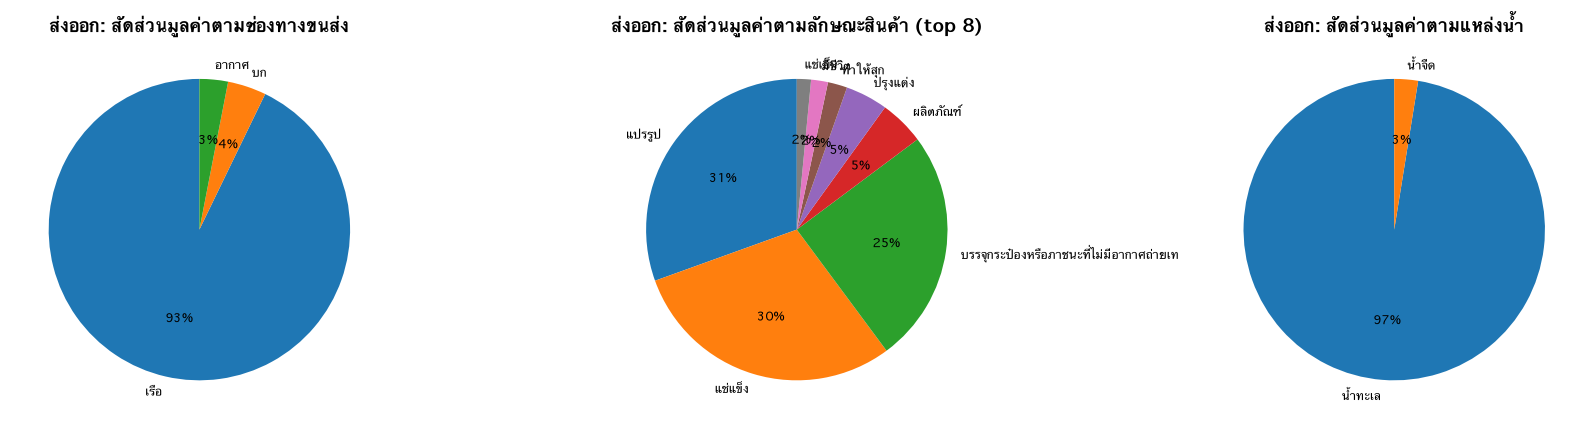

แถวมูลค่า = 0: 206 | มูลค่าว่าง: 88 | ประเทศที่ map ISO2 ไม่ได้: 1 แถว → ['ทะเลหลวง']


In [21]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col, t_ in zip(ax, ["transport", "form", "water"], ["ช่องทางขนส่ง", "ลักษณะสินค้า (top 8)", "แหล่งน้ำ"]):
    s = dx.groupby(col).value_thb.sum().sort_values(ascending=False).head(8)
    a.pie(s.values, labels=s.index, autopct="%1.0f%%", startangle=90, textprops={"fontsize": 8}); a.set(title=f"ส่งออก: สัดส่วนมูลค่าตาม{t_}"); a.grid(False)
plt.tight_layout(); plt.show()
print("แถวมูลค่า = 0:", int((dx.value_thb == 0).sum()), "| มูลค่าว่าง:", int(dx.value_thb.isna().sum()), "| ประเทศที่ map ISO2 ไม่ได้:", int(dx.country_iso2.isna().sum()), "แถว →", dx[dx.country_iso2.isna()].country_th.unique().tolist())

### 📝 อ่านผล: ข้อมูลรายวันกรมประมง (ระดับสายพันธุ์)

**ขนาด:** **2,254,417 แถว** (ส่งออก 1,413,014 / นำเข้า 841,403) ครอบคลุมทุกวันของปี 2022–2025 ฝั่งส่งออก (1,461 วันไม่ซ้ำ) ส่วนนำเข้าปี 2022 มีแค่ **17 วัน (15–31 ธ.ค.)**

**มูลค่ารายปี (พันล้านบาท)**
| | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|
| ส่งออก | 182.85 | 190.07 | **202.39** | 180.47 (−10.8% จากปี 2024) |
| นำเข้า | (17 วัน) | 150.08 | 149.65 | 157.58 |

- ส่งออกพุ่งสูงสุดปี 2024 แล้วลดลงปี 2025 ในหน่วยบาท (ส่วนหนึ่งเพราะค่าเงิน: บาทแข็งขึ้นช่วงปี 2025 ตามกราฟอัตราแลกเปลี่ยนส่วน 2.7)
- **ปลาคือกลุ่มใหญ่ที่สุด** กุ้งรองลงมา (ราว 50 → ราว 42 พันล้านบาท/ปี จากปี 2022 ถึง 2025 ตามกราฟ) ตามด้วยหมึก สัตว์น้ำอื่น ๆ
- **สายพันธุ์มูลค่าสูงสุด 3 อันดับ (รวม 2022–2025):** ปลาทูน่าท้องแถบ (ราว 233 พันล้านบาท) กุ้งขาว (ราว 153) ปลาทูน่าครีบเหลือง (ราว 53) สะท้อนว่าธุรกิจ **ทูน่ากระป๋อง** เป็นแกนหลัก สอดคล้องกับกลุ่ม 1604 ที่ครอง 59% ใน Comtrade
- **ประเทศปลายทาง:** สหรัฐฯ (ราว 156) ญี่ปุ่น (ราว 128) จีน (ราว 80) ออสเตรเลีย (ราว 42) แคนาดา (ราว 27) ลิเบีย (ราว 21) เกาหลีใต้ ซาอุฯ UAE มาเลเซีย ไต้หวัน อียิปต์ — เรียงคล้ายกับ Comtrade
- **ช่องทางขนส่ง: เรือ 93%** อากาศ 3% ทางบก 4% · **ลักษณะสินค้า:** แปรรูป 31% แช่แข็ง 30% กระป๋อง/ภาชนะปิดสนิท 25% · **น้ำทะเล 97%** น้ำจืด 3%

**คุณภาพข้อมูล**
- **แถวซ้ำทั้งแถว** (ทุกคอลัมน์ที่โหลดเหมือนกัน) พบมาก: ส่งออก 6.3–8.0% ของแถวต่อปี, นำเข้า 3.8–4.8% (ตารางนับรวมทุกสำเนา) **สำเนาส่วนเกิน 59,393 แถว (ส่งออก) และ 20,061 แถว (นำเข้า)** — ยังไม่ทราบว่าเป็นข้อมูลซ้ำจริงหรือรายการส่งของจริงที่ค่าเท่ากัน เพราะไม่มีเลขที่เอกสาร ต้องตัดสินใจในขั้นเตรียมข้อมูล
- มูลค่าว่าง 88 แถว (ทั้งหมดอยู่ใน ปี 2022 ส่งออก) มูลค่า = 0 จำนวน 206 แถว และประเทศที่ map ISO2 ไม่ได้ 1 แถว ("ทะเลหลวง" ไม่ใช่ประเทศ)

**ข้อจำกัด:** ไม่มีรหัส HS จึงเชื่อมกับ Comtrade ตรง ๆ ไม่ได้ ใช้เสริมระดับสายพันธุ์ ปีเดียวที่นำเข้า–ส่งออกครบคือ 2023–2025

## 2.5 ใบรับรองสุขภาพสัตว์น้ำเพื่อการส่งออก (ตัวชี้นำที่เป็นไปได้)

จำนวนใบรับรองรายเดือน × ประเทศปลายทาง ที่ออกโดยกรมประมง สมมติฐาน: ใบรับรองต้องออกก่อนส่งสินค้า จึงอาจเป็นสัญญาณล่วงหน้าของยอดส่งออก

In [22]:
parts = []
for f in sorted((DATA / "trade").glob("dof_health_cert_by_country_*.csv")):
    d = rd(f).rename(columns={"จำนวน": "count", "ปริมาณ": "count"}); d["file"] = f.name; parts.append(d)
hc = pd.concat(parts, ignore_index=True)
print("ขนาด:", hc.shape); display(hc.head(8))
print("คอลัมน์ในแต่ละไฟล์ (ชื่อและลำดับไม่ตรงกันทุกไฟล์):")
for f, g in hc.groupby("file"): print(" ", f, "->", [c for c in rd(DATA / "trade" / f, nrows=1).columns])

ขนาด: (612, 6)


,ลำดับ,รายชื่อประเทศ,ปี,เดือน,count,file
0,1,AUSTRALIA_[AU],2564,ต.ค.,0,dof_health_cert_by_country_2564.csv
1,2,CANADA_[CA],2564,ต.ค.,0,dof_health_cert_by_country_2564.csv
2,3,CHINA_[CN],2564,ต.ค.,46,dof_health_cert_by_country_2564.csv
3,4,INDIA_[IN],2564,ต.ค.,25,dof_health_cert_by_country_2564.csv
4,5,JAPAN_[JP],2564,ต.ค.,60,dof_health_cert_by_country_2564.csv
5,6,"KOREA, REPUBLIC OF (SOUTH)_[KR]",2564,ต.ค.,127,dof_health_cert_by_country_2564.csv
6,7,MALAYSIA_[MY],2564,ต.ค.,43,dof_health_cert_by_country_2564.csv
7,8,MYANMAR_[MM],2564,ต.ค.,0,dof_health_cert_by_country_2564.csv


คอลัมน์ในแต่ละไฟล์ (ชื่อและลำดับไม่ตรงกันทุกไฟล์):
  dof_health_cert_by_country_2564.csv -> ['ลำดับ', 'รายชื่อประเทศ', 'ปี', 'เดือน', 'จำนวน']
  dof_health_cert_by_country_2565.csv -> ['ลำดับ', 'รายชื่อประเทศ', 'ปี', 'เดือน', 'จำนวน']
  dof_health_cert_by_country_2566.csv -> ['ลำดับ', 'รายชื่อประเทศ', 'เดือน', 'ปริมาณ', 'ปี']
  dof_health_cert_by_country_2567.csv -> ['ลำดับ', 'รายชื่อประเทศ', 'เดือน', 'ปริมาณ', 'ปี']
  dof_health_cert_by_country_2568.csv -> ['ลำดับ', 'รายชื่อประเทศ', 'เดือน', 'ปริมาณ', 'ปี']


ช่วงเวลา Oct 2021 – Dec 2025 | เดือนที่มีข้อมูล 36 จาก 51 เดือน
เดือนที่ไม่มีข้อมูลเลย: ['Oct 2022', 'Nov 2022', 'Dec 2022', 'Jan 2023', 'Feb 2023', 'Mar 2023', 'Apr 2023', 'May 2023', 'Jun 2023', 'Jul 2023', 'Aug 2023', 'Sep 2023', 'Jun 2024', 'Jul 2024', 'Aug 2024']
แถวที่ (ประเทศ, เดือน) ซ้ำกัน:


,รายชื่อประเทศ,เดือน,ปี,count
387,GERMANY_[DE],ม.ค.,2568,0
406,GERMANY_[DE],ม.ค.,2568,19


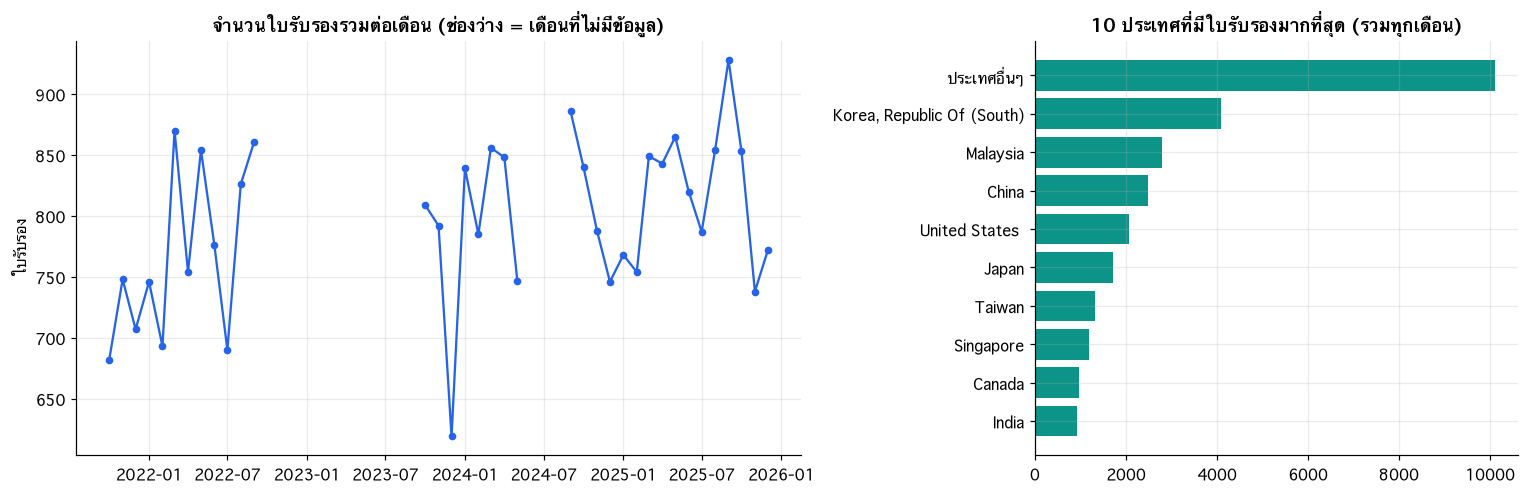

In [23]:
MON = {m: i for i, m in enumerate("ม.ค. ก.พ. มี.ค. เม.ย. พ.ค. มิ.ย. ก.ค. ส.ค. ก.ย. ต.ค. พ.ย. ธ.ค.".split(), 1)}
hc["m"] = hc["เดือน"].map(MON); hc["y"] = hc["ปี"].astype(int) - 543
hc["iso2"] = hc["รายชื่อประเทศ"].str.extract(r"_\[([A-Z]{2})\]$")[0]
hc["date"] = pd.to_datetime(dict(year=hc.y, month=hc.m, day=1))
print(f"ช่วงเวลา {hc.date.min():%b %Y} – {hc.date.max():%b %Y} | เดือนที่มีข้อมูล {hc.date.nunique()} จาก {(hc.date.max().year - hc.date.min().year) * 12 + hc.date.max().month - hc.date.min().month + 1} เดือน")
full = pd.date_range(hc.date.min(), hc.date.max(), freq="MS")
missing = [d for d in full if d not in set(hc.date)]
print("เดือนที่ไม่มีข้อมูลเลย:", [f"{d:%b %Y}" for d in missing])
dup = hc[hc.duplicated(["date", "รายชื่อประเทศ"], keep=False)][["รายชื่อประเทศ", "เดือน", "ปี", "count"]]
print("แถวที่ (ประเทศ, เดือน) ซ้ำกัน:"); display(dup)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.5, 1]})
tot = hc.groupby("date")["count"].apply(lambda s: pd.to_numeric(s).sum()).reindex(full)
ax[0].plot(tot.index, tot.values, marker="o", ms=4, color=C["blue"]); ax[0].set(title="จำนวนใบรับรองรวมต่อเดือน (ช่องว่าง = เดือนที่ไม่มีข้อมูล)", ylabel="ใบรับรอง")
c = hc.assign(v=pd.to_numeric(hc["count"])).groupby("รายชื่อประเทศ").v.sum().sort_values(ascending=False).head(10)
ax[1].barh([i.split("_[")[0].title() for i in c.index][::-1], c.values[::-1], color=C["teal"]); ax[1].set(title="10 ประเทศที่มีใบรับรองมากที่สุด (รวมทุกเดือน)")
plt.tight_layout(); plt.show()

แถว (ประเทศ × เดือน) ที่จับคู่ได้: 330 | Spearman เดือนเดียวกัน = 0.44 | ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 = 0.43


ภายในประเทศเดียวกัน (ตัดผลขนาดตลาด): เดือนเดียวกัน = 0.02 | ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 = -0.14 | จำนวนประเทศ = 19


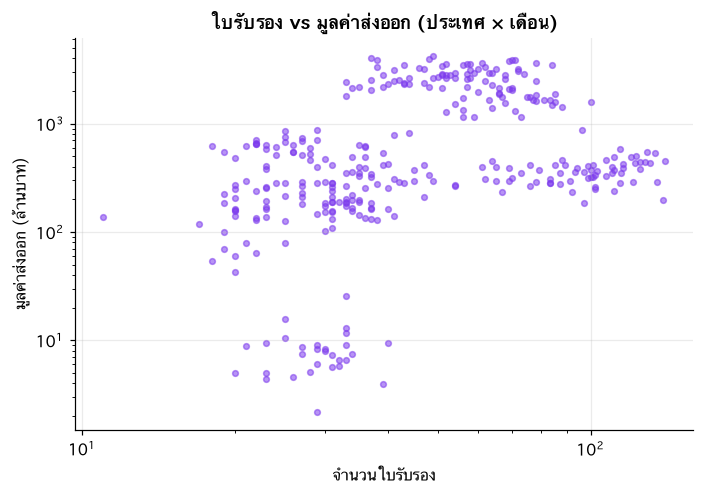

In [24]:
# เป็นตัวชี้นำของยอดส่งออกจริงหรือไม่? เทียบกับยอดส่งออกรายวันของกรมประมง (บาท) ระดับ ประเทศ × เดือน
hcm = hc.assign(v=pd.to_numeric(hc["count"])).groupby(["iso2", "date"], as_index=False).v.sum().dropna()
exm = dx.groupby(["country_iso2", dx.date.dt.to_period("M").dt.to_timestamp()], as_index=False).value_thb.sum().rename(columns={"country_iso2": "iso2", "date": "date"})
j = hcm.merge(exm, on=["iso2", "date"])
j = j[(j.v > 0) & (j.value_thb > 0)]
rho0 = j[["v", "value_thb"]].corr(method="spearman").iloc[0, 1]
# lead: ใบรับรองเดือน t เทียบกับยอดส่งออกเดือน t+1
lead = hcm.assign(date=hcm.date + pd.offsets.MonthBegin(-1)).merge(exm, on=["iso2", "date"]); lead = lead[(lead.v > 0) & (lead.value_thb > 0)]
rho1 = lead[["v", "value_thb"]].corr(method="spearman").iloc[0, 1]
print(f"แถว (ประเทศ × เดือน) ที่จับคู่ได้: {len(j)} | Spearman เดือนเดียวกัน = {rho0:.2f} | ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 = {rho1:.2f}")

# แยกผลของ "ขนาดตลาดต่างกัน" ออก: วัดความสัมพันธ์ *ภายในประเทศเดียวกัน* (ลบค่าเฉลี่ยของแต่ละประเทศออกก่อน)
def within(df):
    d = df.assign(a=np.log(df.v), b=np.log(df.value_thb)); d[["a", "b"]] -= d.groupby("iso2")[["a", "b"]].transform("mean")
    return d[["a", "b"]].corr(method="spearman").iloc[0, 1]
print(f"ภายในประเทศเดียวกัน (ตัดผลขนาดตลาด): เดือนเดียวกัน = {within(j):.2f} | ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 = {within(lead):.2f} | จำนวนประเทศ = {j.iso2.nunique()}")
fig, ax = plt.subplots(figsize=(6.5, 4.6))
ax.scatter(j.v, j.value_thb / 1e6, s=14, alpha=.55, color=C["purple"]); ax.set_xscale("log"); ax.set_yscale("log")
ax.set(title="ใบรับรอง vs มูลค่าส่งออก (ประเทศ × เดือน)", xlabel="จำนวนใบรับรอง", ylabel="มูลค่าส่งออก (ล้านบาท)")
plt.tight_layout(); plt.show()

### 📝 อ่านผล: ใบรับรองสุขภาพสัตว์น้ำ

**ข้อมูลที่มี:** 612 แถว จาก 5 ไฟล์ซึ่งชื่อและลำดับคอลัมน์ไม่เหมือนกัน (`จำนวน` ในปี 2564–2565 แต่ `ปริมาณ` ในปี 2566–2568) ช่วง ต.ค. 2021 – ธ.ค. 2025 **มีข้อมูล 36 จาก 51 เดือน ขาด 15 เดือน** (ต.ค. 2022 – ก.ย. 2023 ต่อเนื่อง 12 เดือน และ มิ.ย.–ส.ค. 2024) และมีคู่ (ประเทศ, เดือน) ซ้ำ 1 คู่ (เยอรมนี ม.ค. 2025: 0 และ 19)

**ภาพที่เห็น**
- จำนวนใบรับรองรวมอยู่ที่ราว **620–930 ใบ/เดือน** ค่อนข้างนิ่ง ไม่มีแนวโน้มชัดเจน
- **หมวด "ประเทศอื่น ๆ" ใหญ่ที่สุด (ราว 10,000 ใบ)** แปลว่าข้อมูลส่วนใหญ่ไม่ระบุประเทศ ส่วนประเทศที่ระบุ: เกาหลีใต้ (ราว 4,100) มาเลเซีย (ราว 2,800) จีน (ราว 2,500) สหรัฐฯ (ราว 2,050) ญี่ปุ่น (ราว 1,700)
- **ประเทศที่มีใบรับรองมาก ไม่ตรงกับประเทศที่ส่งออกมูลค่ามาก** (เกาหลีใต้และมาเลเซียมีใบรับรองมากกว่าสหรัฐฯ และญี่ปุ่น) เป็นไปได้ว่าใบรับรองเกี่ยวกับสัตว์น้ำมีชีวิต/สด มากกว่าสินค้ากระป๋อง/แปรรูปที่มีมูลค่าส่งออกสูง (ข้อสังเกตจากข้อมูลเท่านั้น ยังไม่ยืนยัน)

**ทดสอบว่าเป็นตัวชี้นำยอดส่งออกหรือไม่**
| การวัด | Spearman |
|---|---|
| รวมทุกประเทศ เดือนเดียวกัน (330 จุด) | 0.44 |
| รวมทุกประเทศ ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 | 0.43 |
| **ภายในประเทศเดียวกัน** (ตัดผลขนาดตลาด) เดือนเดียวกัน | **0.02** |
| **ภายในประเทศเดียวกัน** ใบรับรองเดือน t ↔ ส่งออกเดือน t+1 | **−0.14** |

- ความสัมพันธ์ 0.44 **เป็นผลจากขนาดตลาดที่ต่างกัน** (ประเทศใหญ่มีทั้งใบรับรองและยอดส่งออกมาก — ในกราฟกระจายเห็นเป็นแถบแนวนอนแยกตามกลุ่มประเทศ) พอวัดภายในประเทศเดียวกันเหลือเกือบ 0 และไม่ใช่การนำล่วงหน้า (ค่า lead ไม่ดีกว่าเดือนเดียวกัน)
- **สรุป: ในข้อมูลนี้ ใบรับรองสุขภาพไม่ใช่ตัวชี้นำยอดส่งออกที่ใช้งานได้** ครอบคลุมเวลาก็ขาดหลายช่วง → จัดลำดับความสำคัญต่ำ

## 2.6 ฝั่งผลผลิต (supply side)

ข้อมูลผลผลิตสัตว์น้ำของกรมประมง ทั้งการจับและการเพาะเลี้ยง ใช้เป็นบริบทและ feature เสริม

ผลผลิตรวมระดับประเทศรายปี (พันตัน)


,year_be,total,marine_capture,freshwater_capture,coastal_aquaculture,freshwater_aquaculture,year
21,2562,"2,491.00","1,410.70",116.50,536.50,427.30,2019
22,2563,"2,600.20","1,472.00",116.80,556.80,454.60,2020
23,2564,"2,402.90","1,299.50",112.60,540.10,450.70,2021
24,2565,"2,386.70","1,279.80",105.70,534.20,467.00,2022
25,2566,"2,467.30","1,351.50",114.60,541.20,460.00,2023
26,2567,"2,541.40","1,434.90",107.90,530.20,468.40,2024


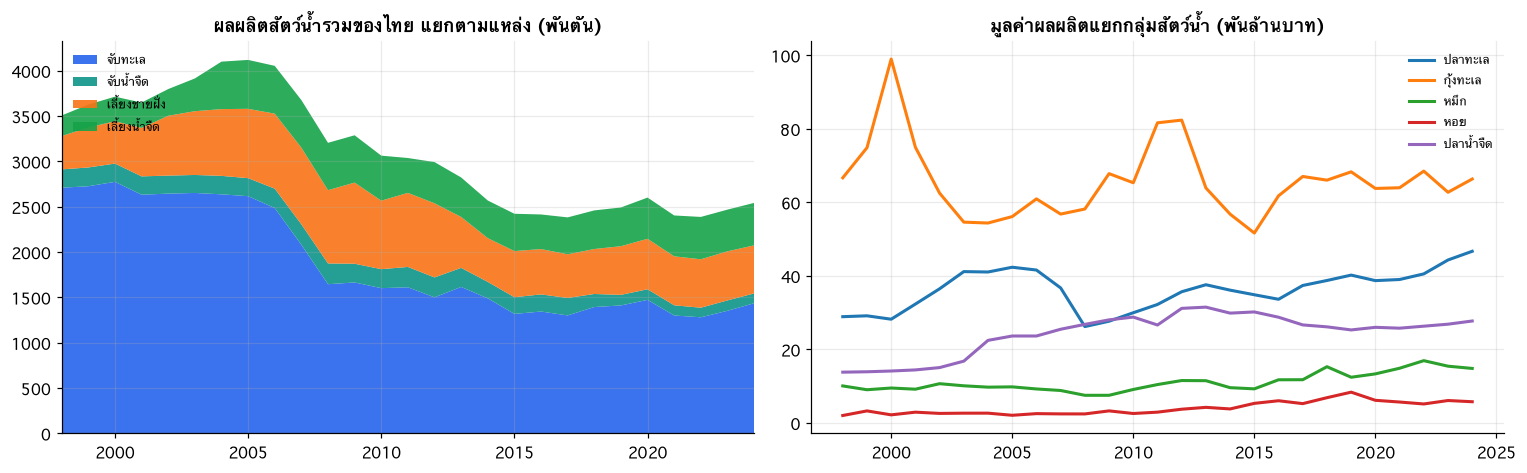

In [25]:
ps = rd(CL / "supply_side/production_by_source_quantity.csv")
print("ผลผลิตรวมระดับประเทศรายปี (พันตัน)"); display(ps.tail(6))
src = {"marine_capture": "จับทะเล", "freshwater_capture": "จับน้ำจืด", "coastal_aquaculture": "เลี้ยงชายฝั่ง", "freshwater_aquaculture": "เลี้ยงน้ำจืด"}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
ax[0].stackplot(ps.year, [ps[k] for k in src], labels=src.values(), colors=[C["blue"], C["teal"], C["orange"], C["green"]], alpha=.9)
ax[0].set(title="ผลผลิตสัตว์น้ำรวมของไทย แยกตามแหล่ง (พันตัน)", xlim=(ps.year.min(), ps.year.max())); ax[0].legend(loc="upper left", frameon=False, fontsize=8)
pv = rd(CL / "supply_side/production_by_species_group_value.csv")
cols = ["marine_fish", "marine_shrimp", "marine_squid", "marine_shellfish", "freshwater_fish"]
nm = {"marine_fish": "ปลาทะเล", "marine_shrimp": "กุ้งทะเล", "marine_squid": "หมึก", "marine_shellfish": "หอย", "freshwater_fish": "ปลาน้ำจืด"}
for c_ in cols: ax[1].plot(pv.year, pv[c_] / 1000, label=nm[c_], lw=2)
ax[1].set(title="มูลค่าผลผลิตแยกกลุ่มสัตว์น้ำ (พันล้านบาท)"); ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

ผลผลิตกุ้งรายเดือน × จังหวัด × ชนิด: (1596, 10)


,date,year,year_be,month,province,region,species,quantity,year_inferred,source_file
0,2024-01-01,2024,2567,1,กระบี่,ภาคใต้ฝั่งอันดามัน,กุ้งกุลาดำ,507.74,False,dof_shrimp_production_monthly_2567.csv
1,2024-01-01,2024,2567,1,กระบี่,ภาคใต้ฝั่งอันดามัน,กุ้งขาว,445.12,False,dof_shrimp_production_monthly_2567.csv
2,2024-01-01,2024,2567,1,กรุงเทพมหานคร,ภาคกลาง,กุ้งกุลาดำ,0.00,False,dof_shrimp_production_monthly_2567.csv
3,2024-01-01,2024,2567,1,กรุงเทพมหานคร,ภาคกลาง,กุ้งขาว,2.60,False,dof_shrimp_production_monthly_2567.csv
4,2024-01-01,2024,2567,1,กาญจนบุรี,ภาคกลาง,กุ้งกุลาดำ,0.00,False,dof_shrimp_production_monthly_2567.csv
5,2024-01-01,2024,2567,1,กาญจนบุรี,ภาคกลาง,กุ้งขาว,0.00,False,dof_shrimp_production_monthly_2567.csv


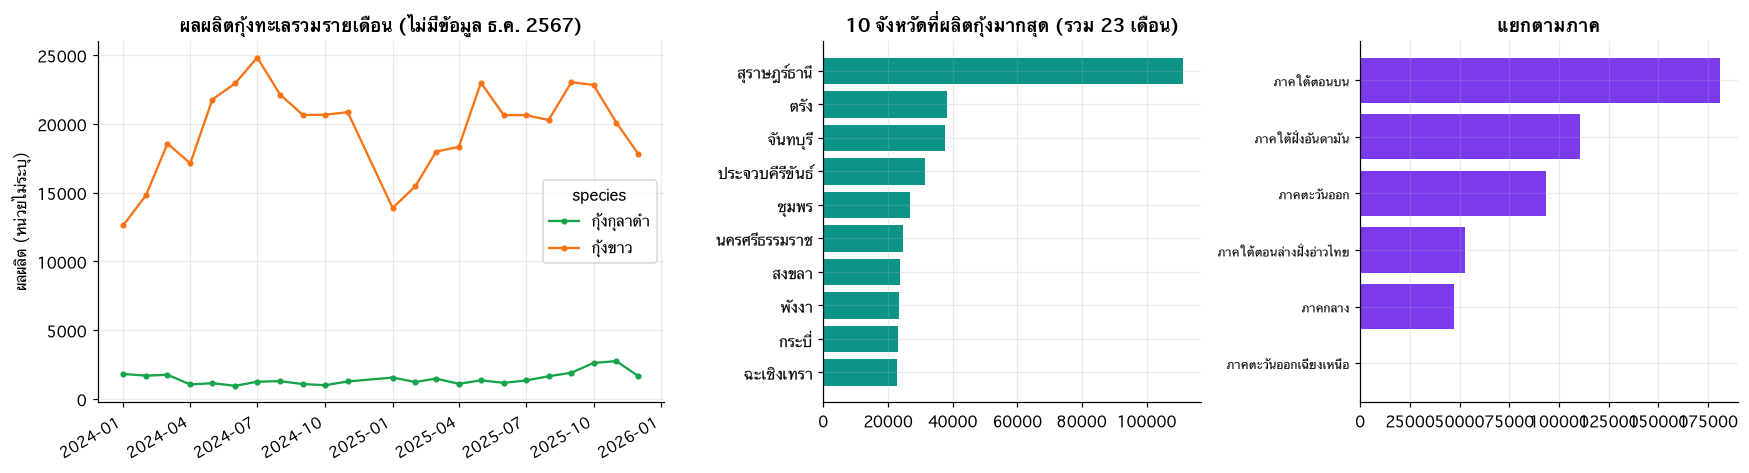

จำนวนเดือนที่มีข้อมูล: 23 | ไฟล์ต้นฉบับชื่อ 'ปี 2569' ถูกตีความเป็นปี 2568 (year_inferred): 826 แถว


In [26]:
sh = rd(CL / "supply_side/shrimp_production_monthly_province.csv", parse_dates=["date"])
print("ผลผลิตกุ้งรายเดือน × จังหวัด × ชนิด:", sh.shape); display(sh.head(6))
mt = sh.groupby(["date", "species"]).quantity.sum().unstack()
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), gridspec_kw={"width_ratios": [1.5, 1, 1]})
mt.plot(ax=ax[0], marker="o", ms=3, color=[C["green"], C["orange"]]); ax[0].set(title="ผลผลิตกุ้งทะเลรวมรายเดือน (ไม่มีข้อมูล ธ.ค. 2567)", ylabel="ผลผลิต (หน่วยไม่ระบุ)", xlabel="")
p = sh.groupby("province").quantity.sum().sort_values(ascending=False).head(10)
ax[1].barh(p.index[::-1], p.values[::-1], color=C["teal"]); ax[1].set(title="10 จังหวัดที่ผลิตกุ้งมากสุด (รวม 23 เดือน)")
rg = sh.groupby("region").quantity.sum().sort_values()
ax[2].barh(rg.index, rg.values, color=C["purple"]); ax[2].set(title="แยกตามภาค"); ax[2].tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()
print("จำนวนเดือนที่มีข้อมูล:", sh.date.nunique(), "| ไฟล์ต้นฉบับชื่อ 'ปี 2569' ถูกตีความเป็นปี 2568 (year_inferred):", int(sh.year_inferred.sum()), "แถว")

การจับสัตว์น้ำทะเลรายเดือน: (45636, 11)


,year,year_be,month,fishing_type,gear,vessel_size,fishing_area,species_th,quantity,value,date
0,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาทูแขก,47.00,"1,431.00",2022-01-01
1,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาสีกุนตาโต,15.00,704.00,2022-01-01
2,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาน้ำดอกไม้,55.00,"3,306.00",2022-01-01
3,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาทรายแดง,43.00,"1,743.00",2022-01-01
4,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาปากคม,57.00,"1,775.00",2022-01-01
5,2022,2565,1,พาณิชย์,อวนลากแผ่นตะเฆ่,ตั้งแต่ 150 ตันกรอสขึ้นไป,อันดามัน,ปลาตาโต,4.00,172.00,2022-01-01


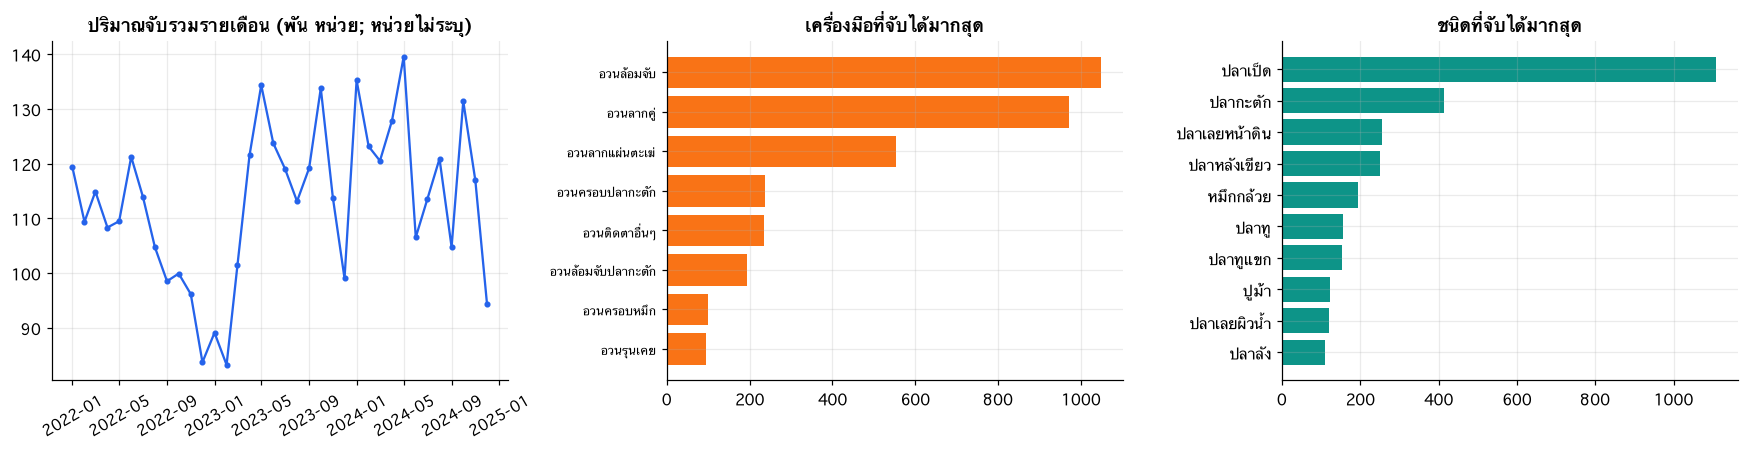

การเพาะเลี้ยง (รวม 5 ประเภท): (16791, 11)


,,จังหวัด,ฟาร์ม,ปริมาณ
category,year,,,
brackish_fish,2024,31,6946,"60,271.00"
freshwater,2024,77,523255,"468,374.00"
marine_crab,2024,20,4827,"3,700.28"
marine_shellfish,2024,19,5381,"76,459.43"
marine_shrimp,2024,35,27385,"389,841.00"


In [27]:
mc = rd(CL / "supply_side/marine_catch_monthly.csv")
mc["date"] = pd.to_datetime(dict(year=mc.year, month=mc.month, day=1))
print("การจับสัตว์น้ำทะเลรายเดือน:", mc.shape); display(mc.head(6))
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
mm = mc.groupby("date")[["quantity", "value"]].sum()
ax[0].plot(mm.index, mm.quantity / 1e3, marker="o", ms=3, color=C["blue"]); ax[0].set(title="ปริมาณจับรวมรายเดือน (พัน หน่วย; หน่วยไม่ระบุ)", xlabel=""); ax[0].tick_params(axis="x", rotation=30)
g = mc.groupby("gear").quantity.sum().sort_values(ascending=False).head(8)
ax[1].barh(g.index[::-1], g.values[::-1] / 1e3, color=C["orange"]); ax[1].set(title="เครื่องมือที่จับได้มากสุด"); ax[1].tick_params(axis="y", labelsize=8)
s = mc.groupby("species_th").quantity.sum().sort_values(ascending=False).head(10)
ax[2].barh(s.index[::-1], s.values[::-1] / 1e3, color=C["teal"]); ax[2].set(title="ชนิดที่จับได้มากสุด")
plt.tight_layout(); plt.show()
aq = rd(CL / "supply_side/aquaculture_yearly.csv")
print("การเพาะเลี้ยง (รวม 5 ประเภท):", aq.shape); display(aq.groupby(["category", "year"]).agg(จังหวัด=("province", "nunique"), ฟาร์ม=("farms", "sum"), ปริมาณ=("quantity", "sum")).groupby("category").tail(1))

### 📝 อ่านผล: ฝั่งผลผลิต (supply)

**ผลผลิตรวมของไทย (กราฟซ้าย)**
- ผลผลิตสัตว์น้ำรวมลดลงมากช่วงราว **ค.ศ. 2005–2015** (จากประมาณ 4 ล้านตัน เหลือประมาณ 2.4 ล้านตัน — อ่านจากกราฟ แกนเป็น ค.ศ.) โดยการจับทะเลลดลงประมาณครึ่งหนึ่ง แล้ว **ทรงตัวตั้งแต่ ค.ศ. 2015**: ปี 2562–2567 อยู่ที่ **2.39–2.60 ล้านตัน** (ปี 2567 = 2.54 ล้านตัน แบ่งเป็นจับทะเล 1.43, เลี้ยงชายฝั่ง 0.53, เลี้ยงน้ำจืด 0.47, จับน้ำจืด 0.11)
- ช่วงที่ผลผลิตลดลงตรงกับช่วงที่ยอดส่งออกใน Comtrade ลดระดับ (ส่วน 2.2) แต่ยังไม่ได้ทดสอบว่าสองอย่างสัมพันธ์กันจริงหรือไม่
- มูลค่ากุ้งทะเลอยู่ราว 62–69 พันล้านบาทต่อปีตั้งแต่ ค.ศ. 2016 (เคยพุ่งสูงราว 99 พันล้านใน ค.ศ. 2000 และราว 82 พันล้านใน ค.ศ. 2012 ตามกราฟ)

**ผลผลิตกุ้งรายเดือน × จังหวัด (ข้อมูลใหม่ 23 เดือน)**
- **กุ้งขาวคือตัวหลัก** ราว 12,000–25,000 ต่อเดือน (หน่วยไม่ระบุ) ส่วนกุ้งกุลาดำราว 1,000–2,800 ต่อเดือน
- **ฤดูกาลเห็นชัด:** ต่ำสุดที่ ม.ค. (ราว 12,600 ปี 2024 / 13,900 ปี 2025) แล้วเพิ่มขึ้นกลางปีและปลายปี (สูงสุดราว 24,800 ใน ก.ค. 2024; ปี 2025 สูงช่วง พ.ค. และ ก.ย.–พ.ย.) เป็นรูปแบบที่ชัดกว่าข้อมูลส่งออกมาก
- **สุราษฎร์ธานีผลิตมากที่สุดอย่างโดดเด่น** (ราว 111,000 รวม 23 เดือน) ตามด้วยตรังและจันทบุรี (ราว 37,000–38,000) ภาคใต้ตอนบนเป็นภาคที่ผลผลิตสูงสุด
- ข้อควรระวัง: ไฟล์ที่ catalog ตั้งชื่อ "ปี 2569" ถูกตีความว่าเป็นปี 2568 (อนุมาน, ไม่ได้ยืนยัน) และไม่มีเดือน ธ.ค. 2024

**การจับสัตว์น้ำทะเลรายเดือน (36 เดือน, 2022–2024)**
- ปริมาณรวม 83,000–140,000 หน่วย/เดือน (หน่วยไม่ระบุ) แกว่งแต่ยังไม่เห็นรูปแบบซ้ำรายปีที่ชัด
- **เครื่องมือที่จับได้มาก:** อวนล้อมจับ (ราว 1,050 พันหน่วย) อวนลากคู่ (ราว 970) อวนลากแผ่นตะเฆ่ (ราว 550) · **ชนิดที่จับได้มากสุด: ปลาเป็ด** (ราว 1,100 พันหน่วย) มากกว่าลำดับ 2 (ปลากะตัก ราว 410) กว่าเท่าตัว (ปลาเป็ดเป็นปลาไม่ได้ขายเป็นอาหารมนุษย์โดยตรง ความเชื่อมโยงกับสินค้าส่งออกจึงอ้อม)

**การเพาะเลี้ยง (ปี 2567):** กุ้งทะเล 35 จังหวัด 27,385 ฟาร์ม ผลผลิต 389,841 · น้ำจืด 77 จังหวัด 523,255 ฟาร์ม ผลผลิต 468,374

**ข้อสรุป:** ข้อมูลกุ้งรายเดือนมีฤดูกาลชัดแต่สั้น (23 เดือน) ใช้เป็นข้อมูลประกอบหรือ feature ฝั่ง supply ได้ ไม่พอเป็นเป้าหมายของโมเดลพยากรณ์ผลผลิตเอง ยังไม่ได้ทดสอบความสัมพันธ์กับยอดส่งออก

## 2.7 ข้อมูลภายนอก: อัตราแลกเปลี่ยน · เศรษฐกิจรายประเทศ · สภาพอากาศ

อัตราแลกเปลี่ยน: (45275, 5)


,date,currency,per_usd,thb_per_usd,thb_per_unit
0,2020-12-31,AUD,1.30,29.93,23.10
1,2021-01-04,AUD,1.30,29.87,23.06
2,2021-01-05,AUD,1.30,29.97,23.09
3,2021-01-06,AUD,1.28,29.93,23.33
4,2021-01-07,AUD,1.29,30.02,23.28


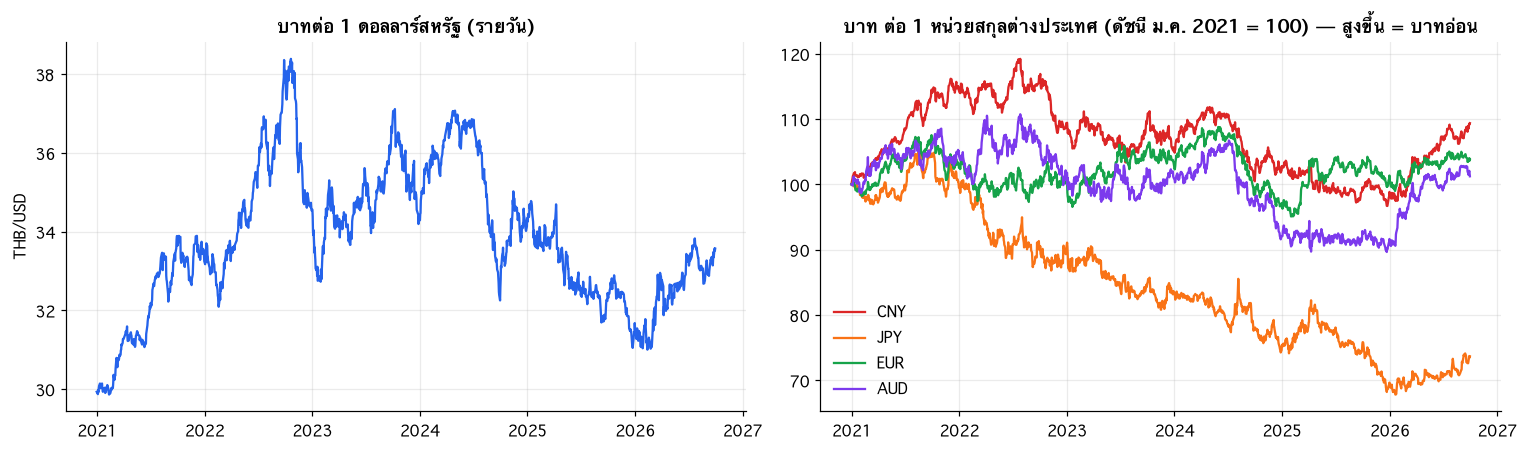

corr(การเปลี่ยนแปลงรายเดือนของ THB/USD, ของยอดส่งออกรวม Comtrade) = 0.06  (n = 63 เดือน)
สกุลเงินที่มี: ['AUD', 'BGN', 'BRL', 'CAD', 'CHF', 'CNY', 'CZK', 'DKK', 'EUR', 'GBP', 'HKD', 'HRK', 'HUF', 'IDR', 'ILS', 'INR', 'ISK', 'JPY', 'KRW', 'MXN', 'MYR', 'NOK', 'NZD', 'PHP', 'PLN', 'RON', 'RUB', 'SEK', 'SGD', 'THB', 'TRY', 'ZAR']
สกุลเงินของตลาดใหญ่ที่ *ไม่มี* ใน ECB: TWD (ไต้หวัน), VND (เวียดนาม), AED (UAE), SAR (ซาอุฯ)


In [28]:
fx = rd(E / "fx_daily_usd_base_ecb.csv", parse_dates=["date"])
print("อัตราแลกเปลี่ยน:", fx.shape); display(fx.head(5))
thb = fx[fx.currency == "THB"].set_index("date").thb_per_usd
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].plot(thb.index, thb.values, color=C["blue"]); ax[0].set(title="บาทต่อ 1 ดอลลาร์สหรัฐ (รายวัน)", ylabel="THB/USD")
for cur, col in [("CNY", C["red"]), ("JPY", C["orange"]), ("EUR", C["green"]), ("AUD", C["purple"])]:
    s = fx[fx.currency == cur].set_index("date").thb_per_unit; ax[1].plot(s.index, s / s.iloc[0] * 100, label=cur, color=col)
ax[1].set(title="บาท ต่อ 1 หน่วยสกุลต่างประเทศ (ดัชนี ม.ค. 2021 = 100) — สูงขึ้น = บาทอ่อน"); ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()
tot_m = world.groupby("date").value_usd.sum()
j_fx = pd.concat([np.log(thb.resample("MS").mean()).diff(), np.log(tot_m).diff()], axis=1, keys=["fx", "export"]).dropna().loc["2021-02":]
print(f"corr(การเปลี่ยนแปลงรายเดือนของ THB/USD, ของยอดส่งออกรวม Comtrade) = {j_fx.corr().iloc[0, 1]:.2f}  (n = {len(j_fx)} เดือน)")
print("สกุลเงินที่มี:", sorted(fx.currency.unique()))
print("สกุลเงินของตลาดใหญ่ที่ *ไม่มี* ใน ECB: TWD (ไต้หวัน), VND (เวียดนาม), AED (UAE), SAR (ซาอุฯ)")

In [29]:
wb = rd(E / "worldbank_indicators_yearly.csv"); wmeta = rd(E / "worldbank_country_meta.csv")
print("World Bank:", wb.shape); display(wb[wb.iso3 == "THA"].tail(3))
cov = wb.groupby("year")[["gdp_usd", "gdp_per_capita_usd", "population", "inflation_cpi_pct", "gdp_growth_pct"]].count()
print("จำนวนประเทศที่มีค่า (ไม่ว่าง) ในแต่ละปี"); display(cov.T)
# join กับประเทศคู่ค้าใน Comtrade ได้แค่ไหน (ถ่วงน้ำหนักด้วยมูลค่าปี 2025)
v25 = part[(part.year == 2025) & part.partner_iso2.notna()].groupby("partner_iso2").value_usd.sum()
have = v25.index.isin(wb.iso2.dropna().unique())
print(f"\nประเทศคู่ค้า Comtrade ปี 2025: {len(v25)} | join กับ World Bank ได้ {have.sum()} ประเทศ ({v25[have].sum() / v25.sum() * 100:.1f}% ของมูลค่า)")
print("ที่ join ไม่ได้ (เรียงตามมูลค่า):", v25[~have].sort_values(ascending=False).head(8).div(1e6).round(1).to_dict(), "(ล้านดอลลาร์)")

World Bank: (2387, 9)


,iso2,iso3,name_en,year,gdp_usd,gdp_per_capita_usd,population,inflation_cpi_pct,gdp_growth_pct
2098,TH,THA,Thailand,2023,"517,013,369,475.12","7,210.54","71,702,435.00",1.23,2.25
2099,TH,THA,Thailand,2024,"529,385,520,941.54","7,386.64","71,668,011.00",0.40,2.95
2100,TH,THA,Thailand,2025,"577,009,981,112.02","8,056.56","71,619,863.00",-0.13,2.44


จำนวนประเทศที่มีค่า (ไม่ว่าง) ในแต่ละปี


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
gdp_usd,212,211,211,211,211,210,210,209,204,200,186
gdp_per_capita_usd,212,211,211,211,211,210,210,209,204,200,186
population,217,217,217,217,217,217,217,217,217,217,217
inflation_cpi_pct,189,189,184,183,183,178,178,178,176,174,165
gdp_growth_pct,211,210,210,211,210,210,210,209,204,200,186



ประเทศคู่ค้า Comtrade ปี 2025: 174 | join กับ World Bank ได้ 174 ประเทศ (100.0% ของมูลค่า)
ที่ join ไม่ได้ (เรียงตามมูลค่า): {} (ล้านดอลลาร์)


สภาพอากาศ: (12558, 10)


,date,province,latitude,longitude,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,month
0,2021-01-01,สมุทรสาคร,13.55,100.27,22.10,25.90,18.70,0.00,15.30,1
1,2021-01-02,สมุทรสาคร,13.55,100.27,22.40,26.60,18.90,0.00,15.80,1
2,2021-01-03,สมุทรสาคร,13.55,100.27,23.60,28.60,19.70,0.00,15.30,1
3,2021-01-04,สมุทรสาคร,13.55,100.27,24.90,29.50,21.30,0.00,14.00,1


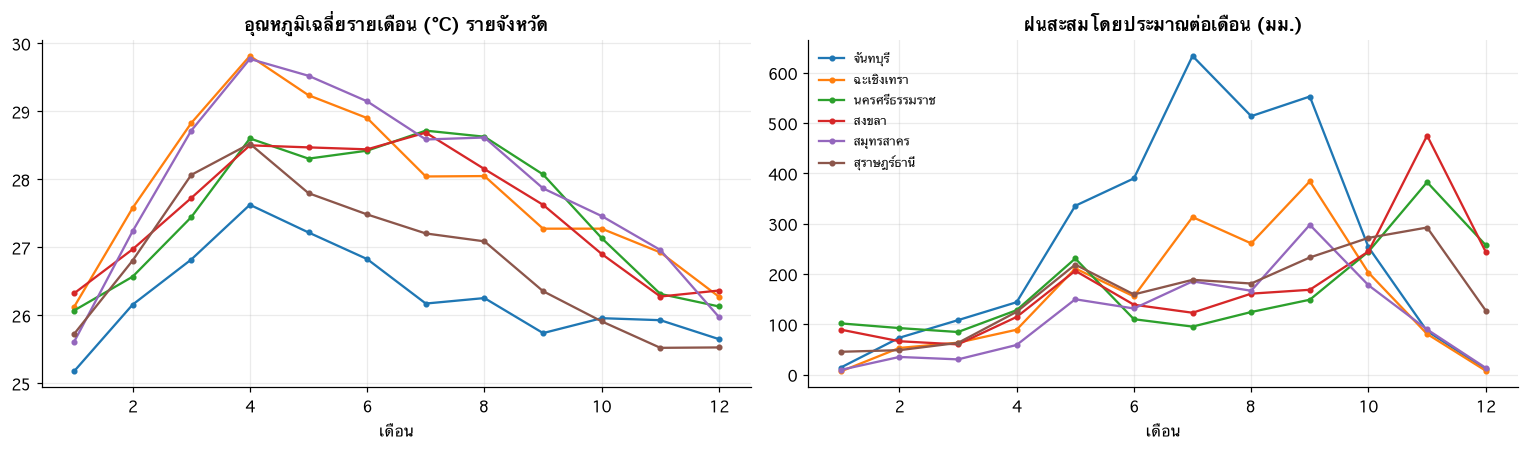

In [30]:
wx = rd(E / "weather_daily_shrimp_provinces.csv", parse_dates=["date"]); wx["month"] = wx.date.dt.month
print("สภาพอากาศ:", wx.shape); display(wx.head(4))
cl = wx.groupby(["province", "month"]).agg(temp=("temperature_2m_mean", "mean"), rain=("precipitation_sum", "sum")).reset_index()
cl["rain"] = cl.rain / wx.date.dt.year.nunique()  # ฝนรวมต่อเดือนโดยประมาณ (เฉลี่ยต่อปี)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for p_, g in cl.groupby("province"):
    ax[0].plot(g.month, g.temp, label=p_, marker="o", ms=3); ax[1].plot(g.month, g.rain, label=p_, marker="o", ms=3)
ax[0].set(title="อุณหภูมิเฉลี่ยรายเดือน (°C) รายจังหวัด", xlabel="เดือน"); ax[1].set(title="ฝนสะสมโดยประมาณต่อเดือน (มม.)", xlabel="เดือน"); ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

### 📝 อ่านผล: ข้อมูลภายนอก

**อัตราแลกเปลี่ยน (ECB, 32 สกุล, ธ.ค. 2020 – ก.ย. 2026)**
- บาทต่อดอลลาร์: ราว **29.9 (ม.ค. 2021) → ราว 38.4 (ปลายปี 2022, บาทอ่อนสุด) → ราว 31 (ต้นปี 2026, บาทแข็งสุด) → 33.6 (ปลาย ก.ย. 2026)**
- กราฟขวาแสดงการเคลื่อนไหวของค่าเงินตลาดปลายทางเทียบบาท (ดัชนี ม.ค. 2021 = 100): **เยนอ่อนลงมากที่สุด (ราว 70)** ขณะที่หยวน (ราว 109) และยูโร (ราว 104) เปลี่ยนไม่มาก
- ECB **ไม่มี TWD, VND, AED, SAR** ซึ่งเป็นตลาดสำคัญ (ไต้หวัน เวียดนาม สหรัฐอาหรับเอมิเรตส์ ซาอุดีอาระเบีย)
- **ค่าเงินกับยอดส่งออก:** ความสัมพันธ์ระหว่างการเปลี่ยนแปลงรายเดือนของ THB/USD กับยอดส่งออกรวมของ Comtrade (USD) ที่คำนวณในโค้ดด้านบนต่ำมาก (corr ≈ 0.06, n = 63 เดือน) จึง **ยังไม่มีหลักฐานว่าค่าเงินเป็น feature ที่ช่วยทำนายยอดส่งออกรวม** (ยังไม่ได้ทดสอบระดับประเทศ × สินค้า)

**World Bank**
- ประชากรมีครบ 217 ประเทศทุกปี แต่ **GDP ปี 2025 มีเพียง 186 ประเทศ (ขาด 31) และเงินเฟ้อ 165 ประเทศ** → ปีล่าสุดไม่ครบ ต้องใช้ค่าปีก่อนหน้าสำหรับประเทศที่ยังไม่รายงาน
- **ประเทศคู่ค้า Comtrade ปี 2025 ทั้ง 174 ประเทศที่มี ISO2 join กับ World Bank ได้ครบ** (ที่ join ไม่ได้มีแค่กลุ่ม "Other Asia, nes" 1.9% ของมูลค่า) แปลว่าใช้ GDP, ประชากร, ระดับรายได้, ภูมิภาค ประกอบการจัดกลุ่มตลาดได้

**สภาพอากาศ (6 จังหวัด)**
- อุณหภูมิเฉลี่ยรายเดือน 25–30 °C สูงสุดช่วง เม.ย. ฝนตกชุกต่างกันตามจังหวัด: จันทบุรีฝนสูงสุดช่วง ก.ค. (ราว 630 มม./เดือน) ส่วนสงขลา นครศรีธรรมราช และสุราษฎร์ธานีมีฝนช่วงปลายปี (ราว ต.ค.–พ.ย.)
- ใช้ประกอบฝั่งผลผลิตได้ แต่ไม่ผูกกับยอดส่งออกรายประเทศโดยตรง

## 2.8 ตรวจสอบข้าม: ตัวเลขจากแหล่งต่าง ๆ ตรงกันไหม

ข้อมูลส่งออกมาจาก 3 แหล่ง (Comtrade, กรมประมง `trade_hs`, กรมประมงรายวัน) ถ้านิยามเหมือนกันควรได้ยอดใกล้เคียงกัน เพราะนี่คือการตรวจ *ความน่าเชื่อถือ* ของข้อมูลหลัก แปลงบาทเป็นดอลลาร์ด้วยอัตราแลกเปลี่ยนเฉลี่ยรายเดือนจาก ECB

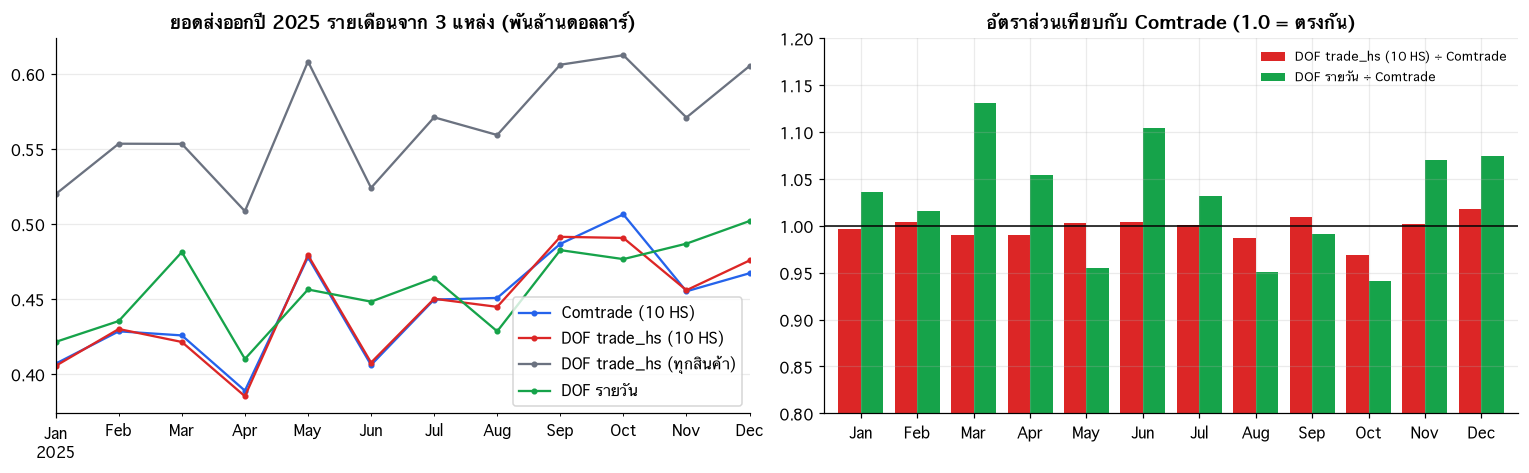

,รวมปี 2025 (พันล้านดอลลาร์),เทียบ Comtrade
Comtrade 10 HS,5.35,1.00
DOF trade_hs 10 HS,5.34,1.00
DOF trade_hs ทุกสินค้า,6.79,1.27
DOF รายวัน,5.49,1.03


ความสัมพันธ์ของอนุกรมรายเดือนปี 2025 กับ Comtrade (Pearson): {'DOF trade_hs (10 HS)': 0.99, 'DOF trade_hs (ทุกสินค้า)': 0.97, 'DOF รายวัน': 0.66}
อัตราส่วนรายเดือนที่ห่างจาก 1.0 มากที่สุด: {'DOF trade_hs (10 HS) ÷ Comtrade': 0.03, 'DOF รายวัน ÷ Comtrade': 0.13}


In [31]:
fxm = thb.resample("MS").mean()
a = world[(world.year == 2025) & world.hs4.isin(SEAFOOD_HS4)].groupby("date").value_usd.sum() / 1e9
fx25 = fxm.reindex(a.index)
b = (th[(th.flow == "ส่งออก") & (th.date.dt.year == 2025) & th.hs4.isin(SEAFOOD_HS4)].groupby("date").price.sum().reindex(a.index) / fx25) / 1e9
b_all = (th[(th.flow == "ส่งออก") & (th.date.dt.year == 2025)].groupby("date").price.sum().reindex(a.index) / fx25) / 1e9
c = (dx[dx.date.dt.year == 2025].groupby(dx.date.dt.to_period("M").dt.to_timestamp()).value_thb.sum().reindex(a.index) / fx25) / 1e9
cmp_ = pd.concat({"Comtrade (10 HS)": a, "DOF trade_hs (10 HS)": b, "DOF trade_hs (ทุกสินค้า)": b_all, "DOF รายวัน": c}, axis=1)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
cmp_.plot(ax=ax[0], marker="o", ms=3, color=[C["blue"], C["red"], C["gray"], C["green"]]); ax[0].set(title="ยอดส่งออกปี 2025 รายเดือนจาก 3 แหล่ง (พันล้านดอลลาร์)", xlabel="")
ratio = pd.DataFrame({"DOF trade_hs (10 HS) ÷ Comtrade": b / a, "DOF รายวัน ÷ Comtrade": c / a})
ratio.index = [d.strftime("%b") for d in ratio.index]
ratio.plot.bar(ax=ax[1], color=[C["red"], C["green"]], width=.8, rot=0); ax[1].axhline(1, color="k", lw=1); ax[1].set(title="อัตราส่วนเทียบกับ Comtrade (1.0 = ตรงกัน)", xlabel="", ylim=(.8, 1.2)); ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()
tot25 = pd.Series({"Comtrade 10 HS": a.sum(), "DOF trade_hs 10 HS": b.sum(), "DOF trade_hs ทุกสินค้า": b_all.sum(), "DOF รายวัน": c.sum()})
display(tot25.rename("รวมปี 2025 (พันล้านดอลลาร์)").to_frame().assign(**{"เทียบ Comtrade": lambda d: d.iloc[:, 0] / tot25.iloc[0]}))
print("ความสัมพันธ์ของอนุกรมรายเดือนปี 2025 กับ Comtrade (Pearson):", {k: round(float(cmp_[k].corr(cmp_["Comtrade (10 HS)"])), 2) for k in cmp_.columns[1:]})
print("อัตราส่วนรายเดือนที่ห่างจาก 1.0 มากที่สุด:", ratio.sub(1).abs().max().round(2).to_dict())

### 📝 อ่านผล: ตัวเลขจากแต่ละแหล่งตรงกันไหม?

| แหล่ง (ปี 2025, ส่งออก) | รวมปี (พันล้านดอลลาร์) | เทียบ Comtrade | สหสัมพันธ์รายเดือน |
|---|---|---|---|
| Comtrade (10 HS) | 5.35 | 1.00 | — |
| **DOF trade_hs (เฉพาะ 10 HS เดียวกัน)** | **5.34** | **1.00** | **0.99** (ต่างไม่เกิน ±3% ทุกเดือน) |
| DOF trade_hs (ทุกสินค้า) | 6.79 | 1.27 | 0.97 |
| DOF รายวัน | 5.49 | 1.03 | 0.66 (ต่างได้ถึง ±13% ต่อเดือน) |

- **เมื่อกรองให้เป็น 10 กลุ่ม HS เดียวกัน ข้อมูลของกรมประมงตรงกับ Comtrade เกือบเป๊ะ** (5.34 เทียบ 5.35 พันล้านดอลลาร์; ต่างไม่เกิน 3% ทุกเดือน) สรุปได้ว่า **ใช้ Comtrade เป็นข้อมูลหลักได้อย่างมั่นใจ** และสองแหล่งนี้น่าจะมาจากข้อมูลศุลกากรชุดเดียวกัน (ไม่ใช่หลักฐานอิสระ 2 ชิ้น)
- ส่วนต่าง 27% ของ "ทุกสินค้า" คือสินค้านอกกลุ่ม (อาหารสัตว์เลี้ยง น้ำปลา ปลาป่น ฯลฯ) ตามที่เห็นในส่วน 2.3
- ข้อมูลรายวันให้ยอดรวมใกล้เคียง (1.03) แต่รายเดือนเบี่ยงเบนได้มากกว่า (ต่างสูงสุด 13%) เพราะนิยามสินค้าและวันที่บันทึกไม่เหมือนกัน (ใช้วันที่ผ่านด่านตรวจประมง ไม่ใช่วันที่ศุลกากร)
- อัตราส่วนคำนวณโดยแปลงบาทเป็นดอลลาร์ด้วยอัตราแลกเปลี่ยนเฉลี่ยรายเดือนของ ECB ซึ่งต่างจากอัตราที่ศุลกากรใช้จริงเล็กน้อย

## 2.9 ราคา: ชุดราคาสะพานปลา

In [32]:
meta = DATA / "price/bangkok_fish_port_metadata/datapackage.json"
dp = json.loads(meta.read_text(encoding="utf-8"))
print(json.dumps({k: dp[k] for k in ("title", "description", "license", "version")}, ensure_ascii=False, indent=1))
print("ไฟล์ในโฟลเดอร์ price/:", sorted(p.name for p in meta.parent.iterdir()))

{
 "title": "ราคาสัตว์น้ำประจำวัน",
 "description": "ราคาสัตว์น้ำที่ประมูลจำหน่าย ณ สะพานปลากรุงเทพ",
 "license": {
  "title": "DGA Open Government License",
  "type": "ogl"
 },
 "version": "1.0"
}
ไฟล์ในโฟลเดอร์ price/: ['datapackage.json', 'fish_port_price_metadata_jun2019.xlsx']


### 📝 อ่านผล: ชุดราคา

โฟลเดอร์ `price/` มีเพียง `datapackage.json` และไฟล์ metadata เท่านั้น **ไม่มีตัวเลขราคาเลย** (ชุด "ราคาสัตว์น้ำประจำวัน" ของสะพานปลากรุงเทพ ตามข้อมูล metadata อัปเดตล่าสุดปี 2019 และจากการตรวจก่อนหน้านี้หยุดอัปเดตตั้งแต่ ต.ค. 2021) **จึงไม่มีข้อมูลราคาตลาดให้ใช้** → ตัดออกจากโจทย์ ใช้ "ราคาต่อกก." ที่คำนวณจาก Comtrade (มูลค่า ÷ น้ำหนัก) แทน (ส่วน 2.2)

## 2.10 ช่วงเวลาที่ข้อมูลแต่ละชุดครอบคลุม

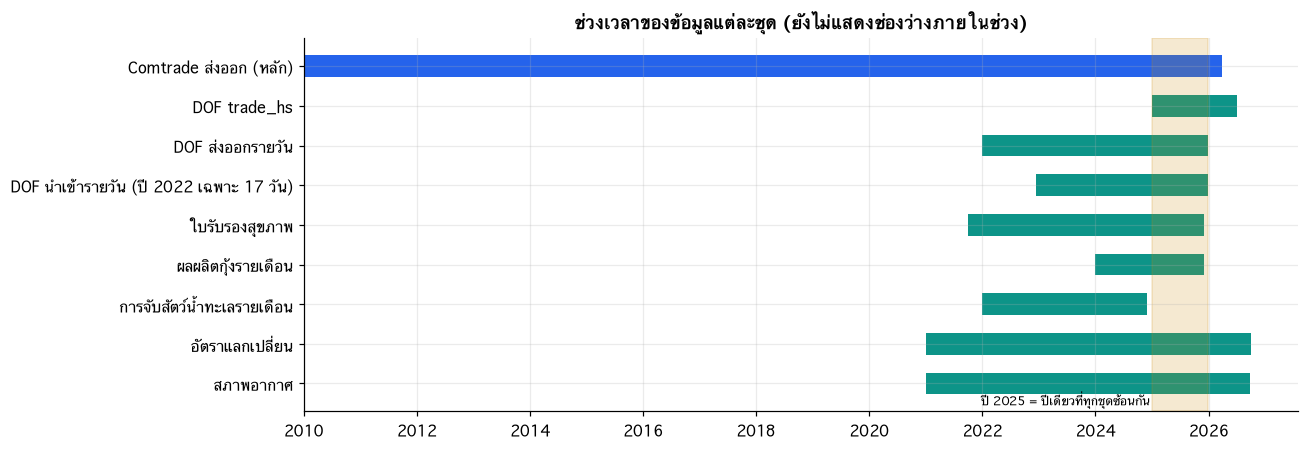

,เริ่ม,สิ้นสุด,ช่วง (เดือน),เดือนที่มีข้อมูลจริง
Comtrade ส่งออก (หลัก),2010-01,2026-04,196,196
DOF trade_hs,2025-01,2026-07,19,19
DOF ส่งออกรายวัน,2022-01,2025-12,48,48
DOF นำเข้ารายวัน (ปี 2022 เฉพาะ 17 วัน),2022-12,2025-12,37,37
ใบรับรองสุขภาพ,2021-10,2025-12,51,36
ผลผลิตกุ้งรายเดือน,2024-01,2025-12,24,23
การจับสัตว์น้ำทะเลรายเดือน,2022-01,2024-12,36,36
อัตราแลกเปลี่ยน,2020-12,2026-09,70,70
สภาพอากาศ,2021-01,2026-09,69,69


In [33]:
rng_series = {
    "Comtrade ส่งออก (หลัก)": cm.date, "DOF trade_hs": th.date, "DOF ส่งออกรายวัน": dx.date,
    "DOF นำเข้ารายวัน (ปี 2022 เฉพาะ 17 วัน)": di.date, "ใบรับรองสุขภาพ": hc.date, "ผลผลิตกุ้งรายเดือน": sh.date,
    "การจับสัตว์น้ำทะเลรายเดือน": mc.date, "อัตราแลกเปลี่ยน": fx.date, "สภาพอากาศ": wx.date,
}
rng = {k: (v.min(), v.max()) for k, v in rng_series.items()}
months_present = {k: v.dt.to_period("M").nunique() for k, v in rng_series.items()}
fig, ax = plt.subplots(figsize=(12, 4.2))
for i, (k, (s, e)) in enumerate(rng.items()):
    ax.barh(i, e - s, left=s, height=.55, color=C["blue"] if "หลัก" in k else C["teal"])
ax.set_yticks(range(len(rng))); ax.set_yticklabels(list(rng)); ax.invert_yaxis()
ax.axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"), color=C["gold"], alpha=.18); ax.text(pd.Timestamp("2024-12-20"), len(rng) - .45, "ปี 2025 = ปีเดียวที่ทุกชุดซ้อนกัน", fontsize=8, ha="right")
ax.set(title="ช่วงเวลาของข้อมูลแต่ละชุด (ยังไม่แสดงช่องว่างภายในช่วง)")
plt.tight_layout(); plt.show()
display(pd.DataFrame({k: {"เริ่ม": f"{s:%Y-%m}", "สิ้นสุด": f"{e:%Y-%m}", "ช่วง (เดือน)": (e.year - s.year) * 12 + e.month - s.month + 1, "เดือนที่มีข้อมูลจริง": months_present[k]} for k, (s, e) in rng.items()}).T)

## 2.11 สรุปปัญหาคุณภาพข้อมูลที่พบ

In [34]:
q = pd.DataFrame([
    ("DOF trade_hs", "แถวซ้ำทั้งแถว", int(issues.iloc[0]), "ลบ"),
    ("DOF trade_hs", "key (เดือน, HS11, ประเทศ, ทิศทาง) ซ้ำแต่ค่าต่างกัน", int(issues.iloc[1]), "รวมยอดเป็น panel"),
    ("DOF trade_hs", "รหัสประเทศ 'yy' / รายละเอียดสินค้า '(blank)'", f"{int(issues.iloc[2])} / {int(issues.iloc[3]):,}", "ตั้งเป็นค่าว่าง + flag"),
    ("DOF รายวัน", "สำเนาแถวซ้ำส่วนเกิน (ส่งออก / นำเข้า)", f"{clog['export_daily_exact_dup_rows']:,} / {clog['import_daily_exact_dup_rows']:,}", "ต้องตัดสินใจ (เก็บ/ลบ)"),
    ("DOF รายวัน", "มูลค่าว่าง / ติดลบ (นำเข้า)", f"{int(dd.value_thb.isna().sum())} / {int((di.value_thb < 0).sum())}", "ตรวจและตัดสินใจ"),
    ("DOF รายวัน", "นำเข้าปี 2022 มีเพียง 17 วัน", 17, "ไม่ใช้ปี 2022 ฝั่งนำเข้า"),
    ("ใบรับรองสุขภาพ", "เดือนที่ไม่มีข้อมูลเลย", len(missing), "จำกัดการใช้ / เติมไม่ได้"),
    ("ใบรับรองสุขภาพ", "(ประเทศ, เดือน) ซ้ำ", len(dup), "รวมยอด"),
    ("ผลผลิตกุ้งรายเดือน", "ไฟล์ปี 2569 น่าจะเป็นปี 2568 (อนุมาน)", int(sh.year_inferred.sum()), "ยืนยันกับแหล่งข้อมูล"),
    ("Comtrade", f"HS 0308 ไม่มีรายการ {int(cover['0308'].isna().sum())} เดือน ({cover['0308'][cover['0308'].isna()].index.min():%Y-%m} ถึง {cover['0308'][cover['0308'].isna()].index.max():%Y-%m})", int(cover["0308"].isna().sum()), "ตีความเป็นไม่มีการค้า (ยืนยันก่อน)"),
    ("Comtrade", "แถวคู่ค้าที่ไม่มีรหัสประเทศ ISO2 (กลุ่ม 'nes' ฯลฯ) % มูลค่าปี 2025", f"{nes_share:.1%}", "แยกเป็นกลุ่ม 'ไม่ระบุ' ไม่นำไป join"),
    ("Comtrade", "คอลัมน์ qty_unit ว่างทั้งหมด / cif_usd ว่างครึ่งหนึ่ง", "100% / 49.7%", "ไม่ใช้ 2 คอลัมน์นี้"),
    ("World Bank", "ประเทศที่ไม่มี GDP ปี 2025 (จาก 217)", int(217 - wb[wb.year == 2025].gdp_usd.notna().sum()), "ใช้ปีล่าสุดที่มี"),
    ("ราคา", "ไม่มีตัวเลขราคา มีแต่ metadata", 0, "ตัดออกจากโจทย์"),
], columns=["ชุดข้อมูล", "ปัญหา", "จำนวน", "แนวทางที่วางไว้"])
display(q)

,ชุดข้อมูล,ปัญหา,จำนวน,แนวทางที่วางไว้
0,DOF trade_hs,แถวซ้ำทั้งแถว,12,ลบ
1,DOF trade_hs,"key (เดือน, HS11, ประเทศ, ทิศทาง) ซ้ำแต่ค่าต่างกัน",15659,รวมยอดเป็น panel
2,DOF trade_hs,รหัสประเทศ 'yy' / รายละเอียดสินค้า '(blank)',"38 / 13,710",ตั้งเป็นค่าว่าง + flag
3,DOF รายวัน,สำเนาแถวซ้ำส่วนเกิน (ส่งออก / นำเข้า),"59,393 / 20,061",ต้องตัดสินใจ (เก็บ/ลบ)
4,DOF รายวัน,มูลค่าว่าง / ติดลบ (นำเข้า),90 / 14,ตรวจและตัดสินใจ
5,DOF รายวัน,นำเข้าปี 2022 มีเพียง 17 วัน,17,ไม่ใช้ปี 2022 ฝั่งนำเข้า
6,ใบรับรองสุขภาพ,เดือนที่ไม่มีข้อมูลเลย,15,จำกัดการใช้ / เติมไม่ได้
7,ใบรับรองสุขภาพ,"(ประเทศ, เดือน) ซ้ำ",2,รวมยอด
8,ผลผลิตกุ้งรายเดือน,ไฟล์ปี 2569 น่าจะเป็นปี 2568 (อนุมาน),826,ยืนยันกับแหล่งข้อมูล
9,Comtrade,HS 0308 ไม่มีรายการ 24 เดือน (2010-01 ถึง 2011-12),24,ตีความเป็นไม่มีการค้า (ยืนยันก่อน)


### 📝 อ่านผล: ปัญหาคุณภาพข้อมูลที่ต้องจัดการใน Data Preparation

- ปัญหาที่ **กระทบการวิเคราะห์โดยตรง:** (1) key ซ้ำใน `trade_hs` 15,659 แถว (2) สำเนาซ้ำรายวัน 59,393 / 20,061 แถว ซึ่งยังตัดสินไม่ได้ว่าลบหรือเก็บ (3) ใบรับรองสุขภาพขาด 15 เดือน (4) ข้อมูลกุ้งไฟล์ "2569" ต้องยืนยันปี
- ปัญหา **เล็ก/จัดการได้ง่าย:** รหัสประเทศ "yy", ค่า "(blank)", มูลค่าว่าง 90 แถว, มูลค่าติดลบ 14 แถว (นำเข้า), HS 0308 ที่ไม่มีรายการ 24 เดือนแรก (ปี 2010–2011)
- **Comtrade (ข้อมูลหลัก) สะอาดที่สุด:** ผลรวมรายประเทศตรงกับยอดรวม (ผลต่างสัมพัทธ์สูงสุด 2.9×10⁻⁹) ครบ 196 เดือน และตรงกับข้อมูลกรมประมงปี 2025 ภายใน ±3% ต่อเดือน

---
### 2.12 สรุป Data Understanding: ข้อมูลพอสำหรับโจทย์ไหน

| โจทย์ | ข้อมูลที่ใช้ | ความพอเพียง | หลักฐานจากข้อมูลในส่วนที่ 2 |
|---|---|---|---|
| **Goal 1 (หลัก). พยากรณ์ยอดรายเดือน (ประเทศ × HS)** | Comtrade | ✅ **ทำได้ และข้อมูลพอเชิงปริมาณ** (340 อนุกรม × 183 เดือน) · ⚠️ *คาดว่า ML จะไม่ชนะ baseline* — ตั้งไว้เป็นสมมติฐานที่ทดสอบ รายงานตามจริง | ไม่มีฤดูกาลในระดับอนุกรมย่อย (autocorr lag 12 = 0.05), กฎค่าเฉลี่ย 3–12 เดือนดีสุด (WAPE 0.220), seasonal naive แย่สุด (0.288) ⇒ เพดานความแม่นยำใกล้ 0.22 ความผันผวนลดลงเมื่อรวมยอด (0.72 รายเดือน → 0.47 รวม 3 เดือน → 0.28 รวม 12 เดือน) จึงควรทดสอบหลายระยะ/หลายระดับ |
| **Goal 2 (ต้องส่งมอบ). จัดกลุ่มตลาด (Clustering)** | Comtrade + World Bank | ✅ **พอ** | 1,148 อนุกรม 174 ประเทศ (2025) ข้อมูลน้ำหนักครบ 99.8% (คำนวณราคาต่อกก.ได้) World Bank join ได้ครบทุกประเทศที่มี ISO2 และไม่ต้องอาศัยพลังพยากรณ์ ใช้แบ่งกลุ่มเพื่ออธิบายความแม่นของ Goal 1 |
| **Goal 3 (เสริม). เตือนตลาดยอดตก (Classification)** | Comtrade | ✅ **พอให้ทดลอง** (ผลยังไม่รู้) | 340 อนุกรมที่เสถียร ≈ 55,000 จุดอนุกรม×เดือน คลาสบวก 26.9% (ไม่เอียงมาก) ความผันผวนของยอด 12 เดือนเหลือ 0.28 ⚠️ โอกาสตกต่อเนื่อง 54% ต้องชนะให้ได้ ⚠️ สัดส่วนการตกต่างกันมากตามปี (19%–39%) → ต้องทดสอบข้ามหลายช่วงเวลา |
| พยากรณ์ผลผลิตกุ้ง | กุ้งรายเดือน + อากาศ | ❌ **ไม่พอ** | มีเพียง 23 เดือน (ฤดูกาลชัด แต่ไม่พอเทรน/ทดสอบข้ามปี) |
| ใช้ใบรับรองสุขภาพเป็นตัวชี้นำ | ใบรับรอง | ❌ **ไม่มีหลักฐานว่าใช้ได้** | ภายในประเทศเดียวกัน corr = 0.02 / −0.14, ขาด 15 เดือน |
| ใช้ราคาตลาด | ราคาสะพานปลา | ❌ **ไม่มีข้อมูล** | มีแต่ metadata |

**สิ่งที่ยืนยันแล้วเกี่ยวกับความน่าเชื่อถือ:** ข้อมูลหลัก (Comtrade) ตรงกับข้อมูลกรมประมงภายใน ±3% ต่อเดือนเมื่อเทียบ HS ชุดเดียวกัน

**ข้อที่ต้องตัดสินใจใน Data Preparation (สำหรับ Goal 1: ระยะพยากรณ์ 1/3/6 เดือน, ระดับการรวม, ช่วงทดสอบ 36 เดือนล่าสุด)**
1. **ช่วงข้อมูลเทรน:** ใช้ปี 2015 เป็นต้นไปเพื่อเลี่ยงการเปลี่ยนโครงสร้างช่วง 2011–2015 (ยืนยันกับอาจารย์/ทีม)
2. **นิยามป้ายกำกับของ Goal 3 (ถ้าทำ):** ตกเกิน 20% ภายใน 6 เดือน ปรับได้ — ควรทดลอง 10/20/30% และ 3/6/12 เดือน
3. **เกณฑ์อนุกรมที่ใช้ได้:** เสนอ ≥ 36 เดือนจาก 60 เดือนล่าสุด (340 อนุกรม, 98.8% ของมูลค่า)
4. **ตัวแปร:** วิเคราะห์เป็น USD ปรับสเกลแยกตามกลุ่ม HS (เพราะ 1604 = 59%)
5. **แถวซ้ำรายวัน:** เก็บหรือลบ (ข้อมูลรายวันเป็นข้อมูลเสริม ไม่กระทบโจทย์หลัก)
6. **ยืนยันกับแหล่งข้อมูล:** ปีของไฟล์กุ้ง "2569" และหน่วยของคอลัมน์ที่ยังเป็น "อนุมาน"

> **สถานะ:** Business Understanding และ Data Understanding เสร็จแล้ว ส่วน Data Preparation, Modeling, Evaluation, Deployment ยังไม่ได้เริ่ม

---
# 3. Data Preparation

ส่วนนี้เปลี่ยนข้อมูลดิบที่เข้าใจแล้วในส่วนที่ 2 ให้เป็นชุดข้อมูลสำหรับโมเดล **ทุกการตัดสินใจอ้างอิงปัญหาที่พบในส่วน 2** และผลของแต่ละขั้นถูกนับ/แสดงให้ตรวจได้ สิ่งที่ส่งออกจากส่วนนี้ (บันทึกที่ `DATASET/prepared/`):

| ชุดข้อมูลที่เตรียม | ใช้กับ | เนื้อหา |
|---|---|---|
| `forecast_panel.csv` | Goal 1 พยากรณ์ | 1 แถว = อนุกรม (ประเทศ × HS4) × เดือนที่ประเมิน (origin) พร้อม feature, target ที่ระยะ 1/3/6 เดือน และค่า baseline |
| `series_universe.csv` | Goal 1 | รายการอนุกรมที่ใช้ |
| `cluster_features_w1.csv`, `cluster_features_w2.csv` | Goal 2 จัดกลุ่มตลาด | 1 แถว = ประเทศ ใน 2 ช่วงเวลา (เพื่อตรวจความเสถียรของกลุ่ม) |

> **หลักสำคัญ: ไม่ให้ข้อมูลอนาคตรั่วเข้ามาใน feature** (data leakage) ทุก feature ของเดือนที่ประเมิน *t* ใช้เฉพาะข้อมูลถึงเดือน *t* และมีการทดสอบอัตโนมัติยืนยันในส่วน 3.5

## 3.0 การตัดสินใจที่ใช้ (ค่าตั้งต้นที่เสนอ — ปรับได้ที่ cell ถัดไป)

In [35]:
# ===== พารามิเตอร์ของส่วน Data Preparation (แก้ที่นี่แล้วรันใหม่ทั้งส่วน 3) =====
START_TRAIN  = pd.Timestamp("2015-01-01")   # target เริ่มตั้งแต่ปี 2015 (หลีกเลี่ยงช่วงเปลี่ยนโครงสร้าง 2011–2015 ดูส่วน 2.2)
FIRST_ORIGIN = pd.Timestamp("2023-04-01")   # origin แรกของช่วงทดสอบ => ทดสอบ 36 เดือนล่าสุด (พ.ค. 2023 – เม.ย. 2026)
HORIZONS     = (1, 3, 6)                    # ระยะพยากรณ์ (เดือน)
MIN_ACTIVE, WIN = 36, 60                    # อนุกรมที่ใช้: มีการค้า >= 36 เดือน จาก 60 เดือนก่อนถึง FIRST_ORIGIN
LAST_MONTH   = cm.date.max()                # เดือนสุดท้ายที่มีข้อมูล Comtrade
MONTHS       = pd.date_range("2010-01-01", LAST_MONTH, freq="MS")
OUT_DIR      = DATA / "prepared"; OUT_DIR.mkdir(exist_ok=True)

decisions = pd.DataFrame([
    ("ช่วง target ที่ใช้เทรน",   "เริ่ม ม.ค. 2015",                         "ก่อนปี 2015 ระดับและส่วนผสมสินค้าต่างจากปัจจุบัน (ส่วน 2.2)"),
    ("ช่วงทดสอบ",               "36 เดือนล่าสุด เทรนใหม่ทุกเดือน (rolling-origin)", "ทดสอบข้ามหลายช่วงเวลา ไม่สุ่ม"),
    ("ระยะพยากรณ์",              "1, 3, 6 เดือน",                          "ความผันผวนลดลงเมื่อรวมยอด/มองไกลขึ้น (ส่วน 2.2.1)"),
    ("หน่วยของค่า",              "USD (ไม่แปลงเป็นบาท)",                    "Comtrade เป็น USD; ค่าเงินใช้เป็น feature แทน"),
    ("อนุกรมที่ใช้",             f"≥ {MIN_ACTIVE} เดือนจาก {WIN} เดือนก่อน origin แรก", "ตัดตลาดประปรายที่ไม่มีมูลค่า (ส่วน 2.2); ใช้เฉพาะข้อมูลก่อนช่วงทดสอบ เพื่อไม่ให้ช่วงทดสอบมีผลต่อการเลือก"),
    ("ค่าที่หายไปของเดือนที่ไม่มีการส่งออก", "เติม 0",                      "Comtrade ไม่ลงรายการเมื่อไม่มีการค้า"),
    ("transform",              "log(1+x) สำหรับ feature ระดับมูลค่า",       "ค่าเบ้ขวามาก (ส่วน 2.2)"),
], columns=["เรื่อง", "ค่าที่ใช้", "เหตุผล"])
display(decisions)

,เรื่อง,ค่าที่ใช้,เหตุผล
0,ช่วง target ที่ใช้เทรน,เริ่ม ม.ค. 2015,ก่อนปี 2015 ระดับและส่วนผสมสินค้าต่างจากปัจจุบัน (ส่วน 2.2)
1,ช่วงทดสอบ,36 เดือนล่าสุด เทรนใหม่ทุกเดือน (rolling-origin),ทดสอบข้ามหลายช่วงเวลา ไม่สุ่ม
2,ระยะพยากรณ์,"1, 3, 6 เดือน",ความผันผวนลดลงเมื่อรวมยอด/มองไกลขึ้น (ส่วน 2.2.1)
3,หน่วยของค่า,USD (ไม่แปลงเป็นบาท),Comtrade เป็น USD; ค่าเงินใช้เป็น feature แทน
4,อนุกรมที่ใช้,≥ 36 เดือนจาก 60 เดือนก่อน origin แรก,ตัดตลาดประปรายที่ไม่มีมูลค่า (ส่วน 2.2); ใช้เฉพาะข้อมูลก...
5,ค่าที่หายไปของเดือนที่ไม่มีการส่งออก,เติม 0,Comtrade ไม่ลงรายการเมื่อไม่มีการค้า
6,transform,log(1+x) สำหรับ feature ระดับมูลค่า,ค่าเบ้ขวามาก (ส่วน 2.2)


## 3.1 Select — เลือกข้อมูล

ใช้ **Comtrade (ระดับประเทศคู่ค้า)** เป็นข้อมูลหลัก ตัดแถวยอดรวม (World) ออกเพราะจะนับซ้ำ และตัดแถวที่ไม่ใช่ประเทศ (กลุ่ม "nes" ที่ไม่มีรหัส ISO2) ข้อมูลกรมประมงใช้ตรวจเทียบเท่านั้น (ส่วน 2.8) เพราะสั้นหรือไม่มี HS

In [36]:
part_c = cm[(~cm.is_world_total) & cm.partner_iso2.notna()].copy()           # เฉพาะแถวประเทศที่มี ISO2
V  = part_c.pivot_table(index=["hs4", "partner_iso2"], columns="date", values="value_usd", aggfunc="sum").reindex(columns=MONTHS).fillna(0.0)
Wt = part_c.pivot_table(index=["hs4", "partner_iso2"], columns="date", values="net_weight_kg", aggfunc="sum").reindex(columns=MONTHS)

win_cols  = MONTHS[(MONTHS > FIRST_ORIGIN - pd.DateOffset(months=WIN)) & (MONTHS <= FIRST_ORIGIN)]
test_cols = MONTHS[MONTHS > FIRST_ORIGIN]
active = (V[win_cols] > 0).sum(axis=1)
universe = V.index[active >= MIN_ACTIVE]

world_tot = cm[cm.is_world_total].groupby("date").value_usd.sum().reindex(MONTHS)
funnel = pd.DataFrame({
    "จำนวน": [len(cm), len(cm[cm.is_world_total]), len(part_c), len(V), len(universe)],
    "% ของมูลค่ารวม (ช่วงเทรน 60 เดือน)": [np.nan, np.nan, V[win_cols].sum().sum() / world_tot[win_cols].sum() * 100, np.nan, V.loc[universe, win_cols].sum().sum() / world_tot[win_cols].sum() * 100],
    "% ของมูลค่ารวม (ช่วงทดสอบ 36 เดือน)": [np.nan, np.nan, V[test_cols].sum().sum() / world_tot[test_cols].sum() * 100, np.nan, V.loc[universe, test_cols].sum().sum() / world_tot[test_cols].sum() * 100],
}, index=["แถวทั้งหมดในไฟล์ Comtrade", "  แถวยอดรวม World (ตัดออก)", "  แถวประเทศที่มี ISO2 (ใช้)", "อนุกรม (ประเทศ × HS4) ที่เคยมีการค้า", f"  อนุกรมที่ใช้ (≥ {MIN_ACTIVE}/{WIN} เดือนก่อน origin แรก)"])
display(funnel)
print(f"อนุกรมที่ใช้: {len(universe)} | ประเทศ: {universe.get_level_values(1).nunique()} | กลุ่ม HS4: {universe.get_level_values(0).nunique()}")
print("อนุกรมที่ใช้แยกตามกลุ่ม HS4:", universe.get_level_values(0).value_counts().sort_index().to_dict())

,จำนวน,% ของมูลค่ารวม (ช่วงเทรน 60 เดือน),% ของมูลค่ารวม (ช่วงทดสอบ 36 เดือน)
แถวทั้งหมดในไฟล์ Comtrade,84858,NaN,NaN
แถวยอดรวม World (ตัดออก),1936,NaN,NaN
แถวประเทศที่มี ISO2 (ใช้),80656,98.07,97.99
อนุกรม (ประเทศ × HS4) ที่เคยมีการค้า,1148,NaN,NaN
อนุกรมที่ใช้ (≥ 36/60 เดือนก่อน origin แรก),332,96.97,96.72


อนุกรมที่ใช้: 332 | ประเทศ: 115 | กลุ่ม HS4: 10
อนุกรมที่ใช้แยกตามกลุ่ม HS4: {'0301': 53, '0302': 7, '0303': 23, '0304': 19, '0305': 19, '0306': 44, '0307': 32, '0308': 6, '1604': 101, '1605': 28}


### 📝 อ่านผล: เลือกข้อมูล

- ไฟล์ Comtrade 84,858 แถว → ตัดแถวยอดรวม World ออก 1,936 แถว (กันนับซ้ำ) → ใช้แถวประเทศที่มี ISO2 **80,656 แถว ซึ่งครอบคลุม 98.1% ของมูลค่าในช่วงเทรน** (ที่ตัดคือกลุ่ม "nes" ไม่ใช่ประเทศ)
- อนุกรม (ประเทศ × HS4) ที่เคยมีการค้ามี 1,148 ตัว **ใช้ 332 ตัว (115 ประเทศ ครบทั้ง 10 กลุ่ม HS)** โดย 1604 มีมากสุด (101 อนุกรม) รองลงมา 0301 (53) 0306 (44) 0307 (32)
- **ครอบคลุมมูลค่า 97.0% ในช่วงเทรน และ 96.7% ในช่วงทดสอบ** ซึ่งสำคัญ: การเลือกอนุกรมใช้ข้อมูลก่อน origin แรก (เม.ย. 2023) เท่านั้น ไม่ให้ช่วงทดสอบมีส่วนตัดสินว่าอนุกรมไหนถูกใช้ (ถ้าเลือกจากข้อมูลทั้งหมดจะได้ 340 ตัวอย่างในส่วน 2 ซึ่งเป็นการ "แอบมองอนาคต" เล็กน้อย) และยังครอบคลุมมูลค่าช่วงทดสอบได้เกือบเท่ากัน แปลว่าชุดตลาดค่อนข้างนิ่ง
- มูลค่าช่วงทดสอบที่อยู่นอกอนุกรมที่ใช้ราว **3.3%**: 2.0% เป็นกลุ่ม nes และราว 1.3% เป็นตลาดประปรายหรือตลาดที่เพิ่งเกิดหลังช่วงเทรน (cold start) ซึ่งโมเดลพยากรณ์ไม่ได้อยู่แล้วเพราะไม่มีประวัติ → ระบุเป็นขอบเขตของงาน

## 3.2 Clean — จัดการปัญหาของข้อมูลหลัก (Comtrade)

ตรวจปัญหาทีละข้อ นับผลกระทบ และแสดงวิธีจัดการ

In [37]:
idx_part = pd.MultiIndex.from_frame(part_c[["hs4", "partner_iso2"]])
in_u = idx_part.isin(universe)
U = part_c[in_u]
Vu = V.loc[universe]; Wu = Wt.loc[universe]
post = Vu.loc[:, Vu.columns >= START_TRAIN]

r12 = Vu.T.rolling(12).mean().shift(1).T                    # ค่าเฉลี่ย 12 เดือน "ก่อนหน้า" เดือนนั้น
spike = ((Vu > 5 * r12) & (r12 > 0)).loc[:, Vu.columns >= START_TRAIN]
drops = ((Vu < 0.2 * r12) & (r12 > 0)).loc[:, Vu.columns >= START_TRAIN]
nes_val = cm[(~cm.is_world_total) & cm.partner_iso2.isna()].value_usd.sum() / cm[~cm.is_world_total].value_usd.sum()

cleaning = pd.DataFrame([
    ("แถวซ้ำ (ประเทศ, HS, เดือน)", int(part_c.duplicated(["hs4", "partnerCode", "date"]).sum()), "—", "ไม่มีปัญหา"),
    ("มูลค่าติดลบ", int((cm.value_usd < 0).sum()), "—", "ไม่มีปัญหา"),
    ("แถวที่ไม่ใช่ประเทศ (กลุ่ม nes ไม่มี ISO2)", f"{nes_val:.1%} ของมูลค่า", "ตัดออกจากอนุกรมประเทศ (ยังอยู่ในแถว World)", "แก้แล้ว"),
    ("น้ำหนัก (net_weight) ว่างหรือ = 0 ในอนุกรมที่ใช้", f"{((U.net_weight_kg.fillna(0) <= 0).mean() * 100):.2f}% ของแถว", "ราคาต่อกก. = ว่างในเดือนนั้น (ไม่เติมค่า)", "ลดผลแล้ว"),
    ("เดือนที่ไม่มีการส่งออก (ไม่มีแถวใน Comtrade)", f"{(post == 0).mean().mean() * 100:.1f}% ของเซลล์ (อนุกรม × เดือน) ปี 2015+", "เติมค่า 0 และมี feature บอกจำนวนเดือนที่ไม่มีการค้า", "แก้แล้ว"),
    ("HS 0308 ไม่มีรายการ 24 เดือนแรก (2010–2011)", "24 เดือน", "ตีความเป็น 0; อยู่นอกช่วงเทรน (ก่อน 2015)", "ไม่กระทบ"),
    ("เดือนที่พุ่งเกิน 5 เท่าของค่าเฉลี่ย 12 เดือนก่อนหน้า", f"{spike.values.sum():,} เซลล์ ({spike.values.mean() * 100:.2f}%)", "คงไว้ (เป็นความผันผวนจริง) ใช้ log และ feature ความผันผวน; รายงานผลที่แยกค่าสุดโต่ง", "ยังเหลือ (บันทึกไว้)"),
    ("เดือนที่ตกต่ำกว่า 20% ของค่าเฉลี่ย 12 เดือนก่อนหน้า", f"{drops.values.sum():,} เซลล์ ({drops.values.mean() * 100:.2f}%)", "คงไว้ เช่นเดียวกับข้างบน", "ยังเหลือ (บันทึกไว้)"),
], columns=["ปัญหา", "จำนวน / สัดส่วน", "วิธีจัดการ", "สถานะ"])
display(cleaning)
small = Vu.loc[:, win_cols].mean(axis=1) < 10_000
print(f"อนุกรมที่ใช้ซึ่งเล็กมาก (เฉลี่ย < 10,000 USD/เดือน ในช่วงเทรน): {int(small.sum())} จาก {len(Vu)} อนุกรม แต่คิดเป็นเพียง {Vu.loc[small, win_cols].sum().sum() / Vu[win_cols].sum().sum() * 100:.2f}% ของมูลค่า")

,ปัญหา,จำนวน / สัดส่วน,วิธีจัดการ,สถานะ
0,"แถวซ้ำ (ประเทศ, HS, เดือน)",0,—,ไม่มีปัญหา
1,มูลค่าติดลบ,0,—,ไม่มีปัญหา
2,แถวที่ไม่ใช่ประเทศ (กลุ่ม nes ไม่มี ISO2),1.6% ของมูลค่า,ตัดออกจากอนุกรมประเทศ (ยังอยู่ในแถว World),แก้แล้ว
3,น้ำหนัก (net_weight) ว่างหรือ = 0 ในอนุกรมที่ใช้,1.12% ของแถว,ราคาต่อกก. = ว่างในเดือนนั้น (ไม่เติมค่า),ลดผลแล้ว
4,เดือนที่ไม่มีการส่งออก (ไม่มีแถวใน Comtrade),9.4% ของเซลล์ (อนุกรม × เดือน) ปี 2015+,เติมค่า 0 และมี feature บอกจำนวนเดือนที่ไม่มีการค้า,แก้แล้ว
5,HS 0308 ไม่มีรายการ 24 เดือนแรก (2010–2011),24 เดือน,ตีความเป็น 0; อยู่นอกช่วงเทรน (ก่อน 2015),ไม่กระทบ
6,เดือนที่พุ่งเกิน 5 เท่าของค่าเฉลี่ย 12 เดือนก่อนหน้า,717 เซลล์ (1.59%),คงไว้ (เป็นความผันผวนจริง) ใช้ log และ feature ความผันผว...,ยังเหลือ (บันทึกไว้)
7,เดือนที่ตกต่ำกว่า 20% ของค่าเฉลี่ย 12 เดือนก่อนหน้า,"7,199 เซลล์ (15.94%)",คงไว้ เช่นเดียวกับข้างบน,ยังเหลือ (บันทึกไว้)


อนุกรมที่ใช้ซึ่งเล็กมาก (เฉลี่ย < 10,000 USD/เดือน ในช่วงเทรน): 48 จาก 332 อนุกรม แต่คิดเป็นเพียง 0.04% ของมูลค่า


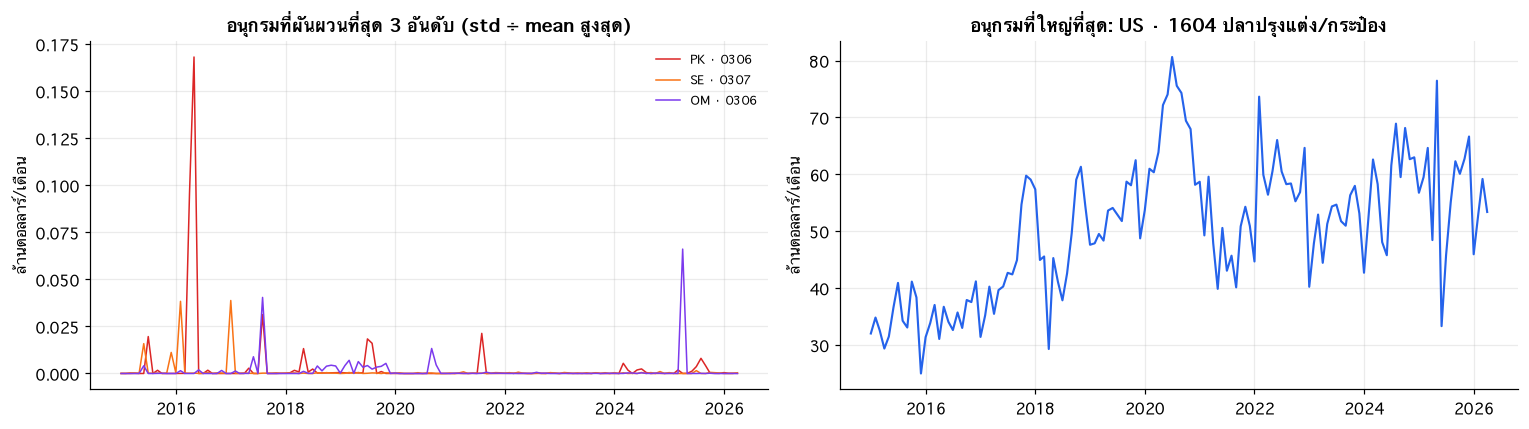

,,std ÷ mean,ค่าเฉลี่ยต่อเดือน (USD)
hs4,partner_iso2,,
0306,PK,5.28,"3,208.18"
0307,SE,5.09,961.36
0306,OM,4.41,"1,541.10"


In [38]:
# ดูตัวอย่างอนุกรมที่ผันผวนที่สุดในกลุ่มอนุกรมที่ใช้ เพื่อให้เห็นว่า "ค่าสุดโต่ง" หน้าตาเป็นอย่างไร
cvv = (post.std(axis=1) / post.mean(axis=1)).sort_values(ascending=False)
ex = cvv.index[:3].tolist() + post.sum(axis=1).sort_values(ascending=False).index[:1].tolist()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for k, c_ in zip(ex[:3], [C["red"], C["orange"], C["purple"]]):
    ax[0].plot(post.columns, post.loc[k] / 1e6, lw=1, color=c_, label=f"{k[1]} · {k[0]}")
ax[0].set(title="อนุกรมที่ผันผวนที่สุด 3 อันดับ (std ÷ mean สูงสุด)", ylabel="ล้านดอลลาร์/เดือน"); ax[0].legend(frameon=False, fontsize=8)
big = ex[3]; ax[1].plot(post.columns, post.loc[big] / 1e6, color=C["blue"], lw=1.4)
ax[1].set(title=f"อนุกรมที่ใหญ่ที่สุด: {big[1]} · {HS4_NAME[big[0]]}", ylabel="ล้านดอลลาร์/เดือน")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"std ÷ mean": cvv.head(3)}).assign(**{"ค่าเฉลี่ยต่อเดือน (USD)": post.mean(axis=1).reindex(cvv.head(3).index)}))

### 📝 อ่านผล: ความสะอาดของข้อมูลหลัก

**Comtrade สะอาดในเชิงโครงสร้าง:** ไม่มีแถวซ้ำ (ประเทศ, HS, เดือน) และไม่มีมูลค่าติดลบ ส่วนที่ต้องจัดการ:
- **เดือนที่ไม่มีการส่งออก = ไม่มีแถว** (Comtrade ไม่ลงรายการศูนย์) คิดเป็น **9.4%** ของเซลล์ (อนุกรม × เดือน) ปี 2015+ → เติม 0 และเพิ่ม feature บอกจำนวนเดือนที่ไม่มีการค้า (`since_last`, `active12`)
- **น้ำหนักว่างหรือเป็น 0 ใน 1.12% ของแถว** → ราคาต่อกก. ของเดือนนั้นเป็นค่าว่าง ไม่เติมค่า (feature ใช้ยอดรวม 12 เดือนจึงทนต่อค่านี้)
- **ค่าสุดโต่งคือเรื่องจริงของข้อมูล ไม่ใช่ข้อผิดพลาด:** 717 เซลล์ (1.6%) พุ่งเกิน 5 เท่าของค่าเฉลี่ย 12 เดือนก่อนหน้า และ **7,199 เซลล์ (15.9%) ตกต่ำกว่า 20% ของค่าเฉลี่ยเดิม** (ส่วนหนึ่งคือเดือนที่ตลาดเงียบหายไปเฉย ๆ) จึงไม่ตัดทิ้ง แต่ใช้ log และ feature ความผันผวน และต้องรายงานผลแยกตามขนาดตลาด
- **อนุกรมที่ผันผวนที่สุดล้วนเป็นตลาดเล็กมาก** (กราฟซ้าย: ปากีสถาน-กุ้ง std ÷ mean 5.28, สวีเดน-หอย 5.09, โอมาน-กุ้ง 4.41 แต่เฉลี่ยแค่ราว 1,000–3,200 ดอลลาร์/เดือน) ขณะที่อนุกรมใหญ่สุด (สหรัฐฯ-ปลากระป๋อง กราฟขวา) แกว่งในช่วง 25–81 ล้านดอลลาร์ต่อเดือนและมีแนวโน้มสูงขึ้นจากราว 32 (2015) เป็นราว 55–60 (หลัง 2022)
- **อนุกรมเล็กมาก 48 จาก 332 ตัว (เฉลี่ย < 10,000 USD/เดือน) รวมกันเป็นเพียง 0.04% ของมูลค่า** → ในขั้น Evaluation ควรดู WAPE (ถ่วงด้วยมูลค่า) เป็นหลัก เพราะ MAPE/ค่าเฉลี่ยรายอนุกรมจะถูกอนุกรมเล็กดึงให้ดูแย่เกินจริง

## 3.3 Construct — สร้างตัวแปร (feature) สำหรับ Goal 1

**ข้อมูลภายนอกที่ต้องใช้ประวัติยาวขึ้น:** ชุดอัตราแลกเปลี่ยนและ World Bank ในส่วน 2 เริ่มปี 2020/2015 แต่ target เริ่มปี 2015 และ feature ใช้ค่าย้อนหลัง จึงดึงชุดที่ยาวกว่า (`fx_monthly_usd_base_ecb_2010.csv` ตั้งแต่ปี 2010, `worldbank_indicators_yearly_2008.csv` ตั้งแต่ปี 2008) ด้วย `scripts/fetch_external_data.py fxlong wblong`

**กลุ่ม feature** (ทุกตัวคำนวณจากข้อมูลถึงเดือน *t* เท่านั้น):

| กลุ่ม | ตัวแปร | ที่มาของแนวคิด |
|---|---|---|
| ระดับและ lag | `lag0, lag1, lag2, lag5, lag11` (log มูลค่า) | อนุกรมเวลา |
| ค่าเฉลี่ย/ความผันผวน | `mean3, mean6, mean12`, `std6, std12`, `mom3_12` | baseline ที่ดีสุดคือค่าเฉลี่ย (ส่วน 2.2.1) |
| การเติบโต | `yoy12` (ยอด 12 เดือนเทียบ 12 เดือนก่อนหน้า) | ส่วน 2.2.1 |
| ความต่อเนื่องของตลาด | `active12`, `since_last` (เดือนที่ผ่านไปตั้งแต่มีการค้าครั้งล่าสุด) | ตลาดประปราย (ส่วน 2.2) |
| ราคา | `uv12` (log USD/กก. จากยอด 12 เดือน) | ส่วน 2.2 |
| บริบท | `hs_mean3` (ยอดรวมของกลุ่ม HS นั้น), `ctry_mean3` (ยอดรวมของประเทศนั้น), `share_hs12`, `share_ctry12` | ขนาดของอนุกรมเทียบรวม |
| ปฏิทิน | `origin_month` | ฤดูกาลอ่อน (ส่วน 2.2.1) |
| ค่าเงิน | `thb_chg3` (บาท/USD เปลี่ยน 3 เดือน), `ccy_chg3` (สกุลเงินประเทศคู่ค้า เทียบ USD เปลี่ยน 3 เดือน) | ส่วน 2.7 |
| เศรษฐกิจประเทศ | `gdppc_log`, `pop_log`, `gdp_growth`, `inflation` ของ **2 ปีก่อน** (กันค่าที่ยังไม่ประกาศ), `region`, `income` | World Bank |
| กลุ่มและประเทศ | `hs4`, `iso2` | |

นอกจาก feature ยังสร้าง **target** `y1, y3, y6` (มูลค่า USD ของเดือน t+1, t+3, t+6) และคอลัมน์ **baseline** (`base_naive`, `base_ma3`, `base_ma12`, `base_snaive1/3/6`) ซึ่งคำนวณจากข้อมูลถึงเดือน t เช่นกัน เพื่อให้ขั้น Evaluation เทียบโมเดลได้ตรง ๆ

In [39]:
fx_l = rd(E / "fx_monthly_usd_base_ecb_2010.csv", parse_dates=["date"])
wb_l = rd(E / "worldbank_indicators_yearly_2008.csv")
wmeta = rd(E / "worldbank_country_meta.csv")

fx_thb = fx_l[fx_l.currency == "THB"].set_index("date").per_usd.reindex(MONTHS)
fx_pivot = fx_l.pivot(index="date", columns="currency", values="per_usd").reindex(MONTHS)
print(f"อัตราแลกเปลี่ยนรายเดือน: {fx_l.date.min():%Y-%m} – {fx_l.date.max():%Y-%m} | THB ว่างในช่วง Comtrade: {fx_thb.isna().sum()} เดือน")
print(f"World Bank: ปี {wb_l.year.min()}–{wb_l.year.max()} | ประเทศ {wb_l.iso2.nunique()}")

# รหัสประเทศ -> สกุลเงินใน ECB (เฉพาะที่แน่ใจ; ที่เหลือเป็นค่าว่าง)
EURO15 = "AT BE CY DE EE ES FI FR GR IE IT LT LU LV MT NL PT SK SI".split()   # สมาชิกยูโรครบตั้งแต่ปี 2015
CCY = {"US": "USD", "JP": "JPY", "CN": "CNY", "AU": "AUD", "CA": "CAD", "GB": "GBP", "KR": "KRW", "SG": "SGD", "MY": "MYR", "HK": "HKD",
       "IN": "INR", "ID": "IDR", "PH": "PHP", "NZ": "NZD", "CH": "CHF", "SE": "SEK", "NO": "NOK", "DK": "DKK", "PL": "PLN", "CZ": "CZK",
       "HU": "HUF", "IL": "ILS", "ZA": "ZAR", "TR": "TRY", "BR": "BRL", "MX": "MXN", **{c: "EUR" for c in EURO15}}
fx_pivot["USD"] = 1.0
ccy_cov = pd.Series(universe.get_level_values(1)).map(CCY).notna().mean()
print(f"สัดส่วนอนุกรมที่มีสกุลเงินประเทศคู่ค้าใน ECB: {ccy_cov:.0%} (ที่เหลือ ccy_chg3 เป็นค่าว่าง)")

อัตราแลกเปลี่ยนรายเดือน: 2009-12 – 2026-10 | THB ว่างในช่วง Comtrade: 0 เดือน
World Bank: ปี 2008–2025 | ประเทศ 217
สัดส่วนอนุกรมที่มีสกุลเงินประเทศคู่ค้าใน ECB: 53% (ที่เหลือ ccy_chg3 เป็นค่าว่าง)


In [40]:
def make_features(V, Wt, horizons=HORIZONS, first_origin=START_TRAIN):
    """สร้างตาราง origin × อนุกรม ที่ feature ของเดือน t ใช้ข้อมูลถึงเดือน t เท่านั้น
    V, Wt: DataFrame (อนุกรม × เดือน) — ใช้ทดสอบการรั่วไหลโดยส่ง V ที่ตัดเดือนอนาคตทิ้งได้"""
    mons = V.columns
    S = len(V)
    X = V.T                                   # เดือน × อนุกรม
    Wd = Wt.reindex(columns=mons).T.fillna(0.0)
    L = np.log1p(X)
    f = {}
    for k in (0, 1, 2, 5, 11): f[f"lag{k}"] = L.shift(k)
    for n in (3, 6, 12): f[f"mean{n}"] = np.log1p(X.rolling(n).mean())
    f["std6"], f["std12"] = L.rolling(6).std(), L.rolling(12).std()
    f["mom3_12"] = f["mean3"] - f["mean12"]
    s12 = X.rolling(12).sum(); w12 = Wd.rolling(12).sum()
    f["yoy12"] = np.log1p(s12) - np.log1p(s12.shift(12))
    act = (X > 0).to_numpy()
    f["active12"] = pd.DataFrame(act, index=mons, columns=X.columns).rolling(12).sum()
    since = np.zeros(act.shape); cur = np.zeros(S)
    for t in range(len(mons)):
        cur = np.where(act[t], 0, cur + 1); since[t] = cur
    f["since_last"] = pd.DataFrame(since, index=mons, columns=X.columns)
    f["uv12"] = np.log(s12.where(s12 > 0) / w12.where(w12 > 0))
    hs_of, ct_of = V.index.get_level_values(0), V.index.get_level_values(1)
    hs_tot, ct_tot = X.T.groupby(level=0).sum().T, X.T.groupby(level=1).sum().T
    def back(tab, keys):                                     # แปลงตารางระดับกลุ่มกลับเป็นคอลัมน์ต่ออนุกรม
        o = tab[list(keys)]; o.columns = X.columns; return o
    f["hs_mean3"]   = np.log1p(back(hs_tot, hs_of).rolling(3).mean())
    f["ctry_mean3"] = np.log1p(back(ct_tot, ct_of).rolling(3).mean())
    f["share_hs12"]   = s12 / back(hs_tot.rolling(12).sum(), hs_of).replace(0, np.nan)
    f["share_ctry12"] = s12 / back(ct_tot.rolling(12).sum(), ct_of).replace(0, np.nan)
    # ค่าเงิน: ใช้เฉพาะค่า ณ เดือน t และ t-3
    thb = fx_thb.reindex(mons); f_thb = np.log(thb / thb.shift(3))
    f["thb_chg3"] = pd.DataFrame(np.repeat(f_thb.to_numpy()[:, None], S, axis=1), index=mons, columns=X.columns)
    ccy = pd.Series(ct_of).map(CCY).to_numpy()
    pv = np.log(fx_pivot.reindex(mons) / fx_pivot.reindex(mons).shift(3))
    f["ccy_chg3"] = pd.DataFrame({c: (pv[ccy[i]].to_numpy() if isinstance(ccy[i], str) else np.full(len(mons), np.nan)) for i, c in enumerate(X.columns)}, index=mons)
    # target และ baseline (ทั้งหมดใช้ข้อมูลถึงเดือน t ยกเว้น y ซึ่งคือสิ่งที่ต้องทำนาย)
    for h in horizons:
        f[f"y{h}"] = X.shift(-h)
        f[f"base_snaive{h}"] = X.shift(12 - h)
    f["base_naive"], f["base_ma3"], f["base_ma12"] = X, X.rolling(3).mean(), X.rolling(12).mean()
    sel = mons >= first_origin
    n_o = int(sel.sum())
    out = {"origin": np.repeat(mons[sel], S), "hs4": np.tile(hs_of.to_numpy(), n_o), "iso2": np.tile(ct_of.to_numpy(), n_o)}
    for k, df in f.items(): out[k] = df.loc[sel].to_numpy().ravel()
    P = pd.DataFrame(out)
    P["origin_month"] = P.origin.dt.month
    # ตัวแปรเศรษฐกิจของประเทศ (ปีที่ 2 ปีก่อน เพื่อไม่ใช้ค่าที่ยังไม่ประกาศ)
    P["wb_year"] = P.origin.dt.year - 2
    w = wb_l.assign(gdppc_log=np.log(wb_l.gdp_per_capita_usd), pop_log=np.log(wb_l.population))[["iso2", "year", "gdppc_log", "pop_log", "gdp_growth_pct", "inflation_cpi_pct"]]
    w = w.rename(columns={"year": "wb_year", "gdp_growth_pct": "gdp_growth", "inflation_cpi_pct": "inflation"})
    P = P.merge(w, on=["iso2", "wb_year"], how="left").drop(columns="wb_year")
    P = P.merge(wmeta[["iso2", "region", "income_level"]].rename(columns={"income_level": "income"}), on="iso2", how="left")
    return P

panel = make_features(V.loc[universe], Wt.loc[universe])
TARGETS = [f"y{h}" for h in HORIZONS]
FEATS = [c for c in panel.columns if c not in ("origin", "hs4", "iso2", "region", "income", *TARGETS) and not c.startswith("base_")]
print("แผงข้อมูล:", panel.shape, "| origin", f"{panel.origin.min():%Y-%m} – {panel.origin.max():%Y-%m}", "| อนุกรม", panel.groupby(["hs4", "iso2"]).ngroups)
print("feature ตัวเลข", len(FEATS), "ตัว:", FEATS)
display(panel.loc[panel.origin == panel.origin.max()].head(5).T.head(40))

แผงข้อมูล: (45152, 40) | origin 2015-01 – 2026-04 | อนุกรม 332
feature ตัวเลข 26 ตัว: ['lag0', 'lag1', 'lag2', 'lag5', 'lag11', 'mean3', 'mean6', 'mean12', 'std6', 'std12', 'mom3_12', 'yoy12', 'active12', 'since_last', 'uv12', 'hs_mean3', 'ctry_mean3', 'share_hs12', 'share_ctry12', 'thb_chg3', 'ccy_chg3', 'origin_month', 'gdppc_log', 'pop_log', 'gdp_growth', 'inflation']


,44820,44821,44822,44823,44824
origin,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00
hs4,0301,0301,0301,0301,0301
iso2,AE,AU,BD,BE,BG
lag0,10.67,9.36,11.41,0.00,7.73
lag1,9.91,10.26,11.72,8.67,9.53
lag2,11.12,10.30,0.00,7.86,7.92
lag5,10.56,9.82,7.63,0.00,0.00
lag11,10.55,9.99,7.61,0.00,9.24
mean3,10.68,10.05,11.17,7.94,8.74
mean6,10.64,10.07,10.52,7.49,8.55


### 📝 อ่านผล: แผงข้อมูลสำหรับพยากรณ์

- **45,152 แถว × 40 คอลัมน์** = 332 อนุกรม × 136 เดือนที่ประเมิน (origin ตั้งแต่ ม.ค. 2015 ถึง เม.ย. 2026)
- **26 feature ตัวเลข** + ตัวแปรกลุ่ม 4 ตัว (`hs4`, `iso2`, `region`, `income`) + target 3 ตัว (`y1`, `y3`, `y6`) + baseline 6 คอลัมน์ (`base_naive`, `base_ma3`, `base_ma12`, `base_snaive1/3/6`) ซึ่งเทียบโมเดลกับกฎง่าย ๆ ได้ตรง ๆ ในขั้น Evaluation
- **อัตราแลกเปลี่ยน:** ชุดที่ดึงเพิ่ม (2010+) ทำให้ `thb_chg3` ไม่ว่างเลยในช่วงเทรน แต่ **`ccy_chg3` (สกุลเงินประเทศคู่ค้า) มีเพียง 53% ของอนุกรม** เพราะ ECB ไม่มีสกุลเงินของหลายตลาด (รวม TWD, VND, AED, SAR) ที่เหลือเป็นค่าว่าง
- ตัวอย่างแถวสุดท้าย (เม.ย. 2026, กลุ่ม 0301): ค่าที่เห็นสมเหตุสมผล เช่น `lag0` ของประเทศที่เงียบในเดือนนั้นเป็น 0 และ `since_last` = 1

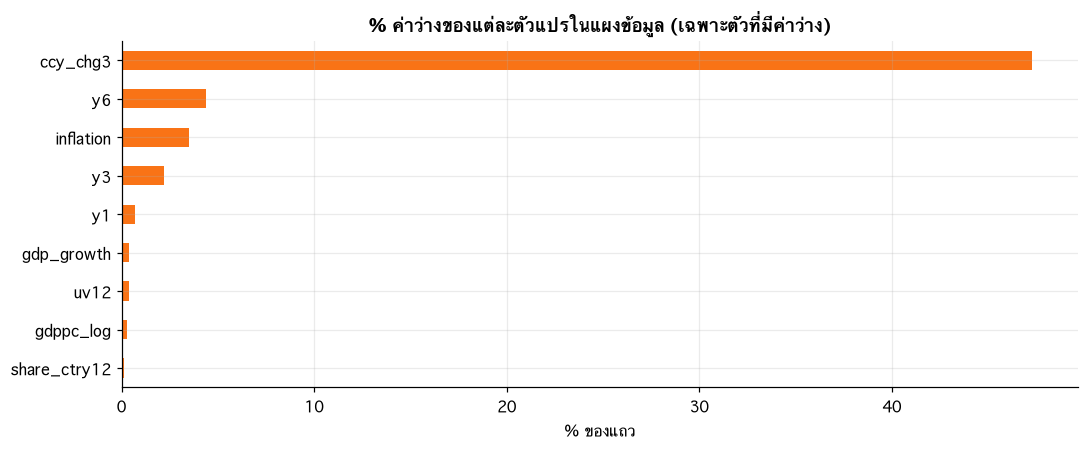

อธิบายค่าว่าง:
  y3 / y6 ว่างช่วง origin ท้ายสุด (ยังไม่มีข้อมูลเดือนอนาคต) | uv12 ว่างเมื่อไม่มีน้ำหนักใน 12 เดือน | yoy12/share ว่างช่วงเริ่ม
  ccy_chg3 ว่างสำหรับประเทศที่ไม่มีสกุลเงินใน ECB | gdp/pop ว่างสำหรับประเทศที่ World Bank ไม่มีค่า


In [41]:
# ค่าว่างของแต่ละ feature (ว่างแบบไหน = ปกติ / ผิดปกติ)
na = panel[FEATS + TARGETS].isna().mean().mul(100).round(1).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4.2))
na[na > 0].plot.barh(ax=ax, color=C["orange"]); ax.invert_yaxis(); ax.set(title="% ค่าว่างของแต่ละตัวแปรในแผงข้อมูล (เฉพาะตัวที่มีค่าว่าง)", xlabel="% ของแถว")
plt.tight_layout(); plt.show()
print("อธิบายค่าว่าง:")
print("  y3 / y6 ว่างช่วง origin ท้ายสุด (ยังไม่มีข้อมูลเดือนอนาคต) | uv12 ว่างเมื่อไม่มีน้ำหนักใน 12 เดือน | yoy12/share ว่างช่วงเริ่ม")
print("  ccy_chg3 ว่างสำหรับประเทศที่ไม่มีสกุลเงินใน ECB | gdp/pop ว่างสำหรับประเทศที่ World Bank ไม่มีค่า")

### 📝 อ่านผล: ค่าว่าง

| ตัวแปร | % ค่าว่าง | สาเหตุ | ปกติหรือไม่ |
|---|---|---|---|
| `ccy_chg3` | **ราว 47%** | ECB ไม่มีสกุลเงินของ 47% ของอนุกรม | ✅ ข้อจำกัดของแหล่งข้อมูล (โมเดล LightGBM รองรับค่าว่างได้) |
| `y6`, `y3`, `y1` | 4.4%, 2.2%, 0.7% | origin ช่วงท้ายยังไม่มีข้อมูลเดือนอนาคต | ✅ ปกติ (แถวเหล่านี้ใช้ทำนายจริง ไม่ใช่เทรน) |
| `inflation` | 3.5% | World Bank ไม่มีค่าเงินเฟ้อของบางประเทศ/ปี | ✅ ปกติ |
| `uv12`, `gdp_growth`, `gdppc_log`, `share_ctry12` | < 0.5% | ไม่มีน้ำหนัก / ไม่มีข้อมูล World Bank | ✅ น้อยมาก |

ไม่พบค่าว่างที่ผิดปกติใน feature อื่น (ค่า 0 ถูกเติมสำหรับเดือนที่ไม่มีการค้าแล้ว)

## 3.4 ตรวจการรั่วไหลของข้อมูล (Data Leakage)

**ทดสอบ 1: เมื่อตัดข้อมูลหลังเดือน t ทิ้งแล้วสร้าง feature ใหม่ ค่าของเดือน t ต้องเท่าเดิมทุกตัว** ถ้า feature ใดแอบใช้ข้อมูลอนาคต ค่าจะเปลี่ยน

**ทดสอบ 2: ไม่มี feature ใดสัมพันธ์กับ target สูงผิดปกติ** (ถ้ามากกว่า 0.99 ต้องสงสัยว่ารั่ว)

In [42]:
chk_origins = [pd.Timestamp(d) for d in ("2016-06-01", "2020-03-01", "2023-04-01", "2025-09-01")]
rows = []
for o in chk_origins:
    trunc = make_features(V.loc[universe].loc[:, V.columns <= o], Wt.loc[universe], first_origin=o)      # ตัดข้อมูลหลัง o ทิ้งทั้งหมด
    a = trunc[trunc.origin == o].reset_index(drop=True)
    b = panel[panel.origin == o].reset_index(drop=True)
    cols = [c for c in FEATS + ["base_naive", "base_ma3", "base_ma12", "base_snaive1", "base_snaive3", "base_snaive6"] if c in a.columns]
    diff = (a[cols].astype(float) - b[cols].astype(float)).abs().max().max()
    same_na = (a[cols].isna().to_numpy() == b[cols].isna().to_numpy()).all()
    rows.append((f"{o:%Y-%m}", len(a), diff, same_na))
leak = pd.DataFrame(rows, columns=["origin ที่ทดสอบ", "จำนวนแถว", "ผลต่างสูงสุดหลังตัดอนาคต", "ตำแหน่งค่าว่างตรงกัน"])
display(leak)
assert (leak["ผลต่างสูงสุดหลังตัดอนาคต"] < 1e-9).all() and leak["ตำแหน่งค่าว่างตรงกัน"].all(), "พบการรั่วไหลของข้อมูลอนาคต!"
print("✅ ผ่าน: feature ของเดือน t ไม่เปลี่ยนเมื่อไม่มีข้อมูลหลังเดือน t")

corr = panel[FEATS + ["y1"]].corr(method="spearman")["y1"].drop("y1").abs().sort_values(ascending=False)
print("\nสหสัมพันธ์ (Spearman, ค่าสัมบูรณ์) กับ y1 สูงสุด 6 ตัว:"); display(corr.head(6).round(3).to_frame("|ρ| กับ y1"))
assert corr.max() < 0.99

,origin ที่ทดสอบ,จำนวนแถว,ผลต่างสูงสุดหลังตัดอนาคต,ตำแหน่งค่าว่างตรงกัน
0,2016-06,332,0.00,True
1,2020-03,332,0.00,True
2,2023-04,332,0.00,True
3,2025-09,332,0.00,True


✅ ผ่าน: feature ของเดือน t ไม่เปลี่ยนเมื่อไม่มีข้อมูลหลังเดือน t



สหสัมพันธ์ (Spearman, ค่าสัมบูรณ์) กับ y1 สูงสุด 6 ตัว:


,|ρ| กับ y1
mean6,0.90
mean12,0.90
mean3,0.90
lag0,0.86
lag1,0.86
lag2,0.85


### 📝 อ่านผล: ตรวจการรั่วไหลของข้อมูลอนาคต

- **ทดสอบ 1 ผ่าน:** ตัดข้อมูลหลังเดือน *t* ทิ้งทั้งหมดแล้วสร้าง feature ใหม่ ที่ origin ทั้ง 4 ที่ทดสอบ (มิ.ย. 2016, มี.ค. 2020, เม.ย. 2023, ก.ย. 2025) **ค่า feature และ baseline ทุกตัวเหมือนเดิมทุกหลัก (ผลต่าง = 0) และตำแหน่งค่าว่างตรงกัน** แปลว่า feature ของเดือน *t* ใช้ข้อมูลถึงเดือน *t* เท่านั้นจริง (โค้ด assert ไว้ด้วย ถ้ามีรั่วในอนาคต notebook จะหยุดทันที)
- **ทดสอบ 2 ผ่าน:** feature ที่สัมพันธ์กับ `y1` สูงสุดคือค่าเฉลี่ย 3/6/12 เดือน (|ρ| = 0.90) และ `lag0` (0.86) ไม่ถึงระดับน่าสงสัย (> 0.99) **ค่าสูงนี้ไม่ใช่การรั่ว** แต่เป็นเพราะอนุกรมใหญ่-เล็กต่างกันมาก (ตลาดที่ใหญ่เดือนนี้ก็ใหญ่เดือนหน้า) สหสัมพันธ์ที่วัดข้ามอนุกรมจึงสูง ส่วนความสามารถในการทำนายการเปลี่ยนแปลง *ภายในอนุกรมเดียวกัน* ซึ่งเป็นสิ่งที่โมเดลต้องทำจริง ต่ำกว่านี้มาก (ตามที่เห็นในส่วน 2.2.1)
- **ที่ตรวจไม่ได้อัตโนมัติ:** ตัวแปรเศรษฐกิจ World Bank ใช้ค่าของ 2 ปีก่อนปีของ origin โดยออกแบบ (ไม่มีการทดสอบที่ตัดข้อมูลได้เหมือน feature อื่น)

## 3.5 แบ่งข้อมูลแบบ rolling-origin (ตามเวลา ห้ามสุ่ม)

ที่ origin *T* แต่ละเดือนในช่วงทดสอบ: **เทรนด้วยแถวที่ target รู้แล้ว** (origin + h ≤ T) แล้วทำนาย target ของ origin *T* ซึ่งโมเดลไม่เคยเห็น แล้วเลื่อน *T* ไปเดือนถัดไป (expanding window)

,ระยะพยากรณ์,จำนวน origin ทดสอบ,origin,เดือนที่ถูกทำนาย (target),แถวเทรน (origin แรก),แถวเทรน (origin ท้ายสุด)
0,1 เดือน,36,2023-04 → 2026-03,2023-05 → 2026-04,32868,44488
1,3 เดือน,34,2023-04 → 2026-01,2023-07 → 2026-04,32204,43160
2,6 เดือน,31,2023-04 → 2025-10,2023-10 → 2026-04,31208,41168


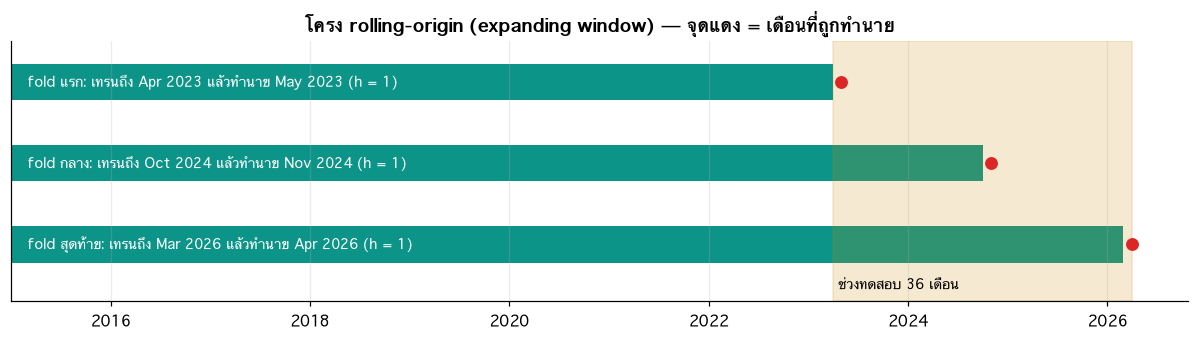

In [43]:
orig = panel.origin.drop_duplicates().sort_values().reset_index(drop=True)
rows = []
for h in HORIZONS:
    test_orig = orig[(orig >= FIRST_ORIGIN) & (orig + pd.DateOffset(months=h) <= LAST_MONTH)]
    n_first = int(((panel.origin + pd.DateOffset(months=h)) <= test_orig.min()).sum())
    n_last = int(((panel.origin + pd.DateOffset(months=h)) <= test_orig.max()).sum())
    rows.append((f"{h} เดือน", len(test_orig), f"{test_orig.min():%Y-%m} → {test_orig.max():%Y-%m}", f"{(test_orig.min() + pd.DateOffset(months=h)):%Y-%m} → {(test_orig.max() + pd.DateOffset(months=h)):%Y-%m}", n_first, n_last))
split = pd.DataFrame(rows, columns=["ระยะพยากรณ์", "จำนวน origin ทดสอบ", "origin", "เดือนที่ถูกทำนาย (target)", "แถวเทรน (origin แรก)", "แถวเทรน (origin ท้ายสุด)"])
display(split)

fig, ax = plt.subplots(figsize=(11, 3.2))
for i, (T_, lab) in enumerate([(pd.Timestamp("2023-04-01"), "fold แรก"), (pd.Timestamp("2024-10-01"), "fold กลาง"), (pd.Timestamp("2026-03-01"), "fold สุดท้าย")]):
    y_ = 2 - i
    ax.barh(y_, (T_ - START_TRAIN).days, left=START_TRAIN, height=.45, color=C["teal"])
    ax.scatter([T_ + pd.DateOffset(months=1)], [y_], color=C["red"], zorder=3, s=55)
    ax.text(START_TRAIN + pd.Timedelta(days=60), y_, f"{lab}: เทรนถึง {T_:%b %Y} แล้วทำนาย {(T_ + pd.DateOffset(months=1)):%b %Y} (h = 1)", va="center", color="white", fontsize=9)
ax.axvspan(FIRST_ORIGIN, LAST_MONTH, color=C["gold"], alpha=.18); ax.text(FIRST_ORIGIN + pd.Timedelta(days=20), -.55, "ช่วงทดสอบ 36 เดือน", fontsize=9)
ax.set(yticks=[], ylim=(-.7, 2.5), title="โครง rolling-origin (expanding window) — จุดแดง = เดือนที่ถูกทำนาย")
plt.tight_layout(); plt.show()

### 📝 อ่านผล: การแบ่งข้อมูล

| ระยะพยากรณ์ | จำนวน origin ทดสอบ | เดือนที่ถูกทำนาย | แถวเทรนที่ origin แรก → สุดท้าย |
|---|---|---|---|
| 1 เดือน | 36 | พ.ค. 2023 – เม.ย. 2026 | 32,868 → 44,488 |
| 3 เดือน | 34 | ก.ค. 2023 – เม.ย. 2026 | 32,204 → 43,160 |
| 6 เดือน | 31 | ต.ค. 2023 – เม.ย. 2026 | 31,208 → 41,168 |

- แต่ละ origin ทดสอบเทรนด้วยแถวที่ **target รู้ผลแล้วเท่านั้น** (origin + h ≤ T) จำนวนแถวเทรนเพิ่มจาก ~32,000 เป็น ~44,000 เมื่อเลื่อนเวลา (expanding window)
- ระยะยาวขึ้นมี origin ทดสอบน้อยลง เพราะเดือนปลายช่วงยังไม่มีค่าจริงให้เทียบ (h = 6 เหลือ 31 จุด)
- ทดสอบรวมราว 332 อนุกรม × 36 origin ≈ **11,900 จุดทำนายที่ระยะ 1 เดือน** ซึ่งพอสำหรับตัวชี้วัดโดยรวม แต่ถ้าแยกย่อยตามกลุ่ม HS ที่เล็ก (เช่น 0308 มี 6 อนุกรม, 0302 มี 7 อนุกรม) ผลต่อกลุ่มจะไม่นิ่ง ควรระวังในการตีความ

## 3.6 Construct — ชุดข้อมูลสำหรับ Goal 2 (จัดกลุ่มตลาด)

หน่วยของการจัดกลุ่มคือ **ประเทศ** (ตลาดหนึ่งตลาดรวมทุกกลุ่มสินค้า) ใช้ข้อมูล 36 เดือน แบ่งเป็น **2 ช่วงเวลา** (W1 = พ.ค. 2020 – เม.ย. 2023, W2 = พ.ค. 2023 – เม.ย. 2026) เพื่อตรวจว่ากลุ่มที่ได้เสถียรหรือไม่เมื่อข้อมูลเปลี่ยนช่วง

| ตัวแปร | ความหมาย |
|---|---|
| `size_log` | log ของมูลค่ารวมทุกสินค้าใน 36 เดือน |
| `growth` | log(ยอด 12 เดือนล่าสุด ÷ ยอด 12 เดือนแรกของช่วง) |
| `volatility` | std ÷ mean ของยอดรวมรายเดือน |
| `active_share` | สัดส่วนเดือนที่มีการส่งออกไปประเทศนั้น |
| `uv_log` | log ราคาต่อกก. (มูลค่ารวม ÷ น้ำหนักรวม) |
| `mix_*` | สัดส่วนมูลค่าของแต่ละกลุ่ม HS4 (รวม = 1) และ `hhi` (ความกระจุกตัวของสินค้า) |
| `gdppc_log`, `pop_log`, `region`, `income` | World Bank (ใช้ตีความ/ตรวจเทียบ ไม่ได้ใช้เป็น feature ตัดสินกลุ่มโดยตรง ขึ้นกับการทดลองในขั้น Modeling) |

In [44]:
def cluster_features(end, months=36, min_active=24):
    cols = MONTHS[(MONTHS > end - pd.DateOffset(months=months)) & (MONTHS <= end)]
    Vc, Wc = V.loc[:, cols], Wt.loc[:, cols].fillna(0.0)
    ct = Vc.groupby(level=1).sum(); wt = Wc.groupby(level=1).sum()
    act = (ct > 0).sum(axis=1)
    keep = act[act >= min_active].index
    ct, wt = ct.loc[keep], wt.loc[keep]
    tot = ct.sum(axis=1)
    hs = Vc.groupby(level=[1, 0]).sum().sum(axis=1).unstack("hs4").reindex(keep).fillna(0)   # แถว = ประเทศ, คอลัมน์ = กลุ่ม HS4
    share = hs.div(hs.sum(axis=1), axis=0)
    assert np.allclose(share.sum(axis=1), 1.0), "สัดส่วนกลุ่มสินค้าต้องรวมเป็น 1"
    first, last = ct.iloc[:, :12].sum(axis=1), ct.iloc[:, -12:].sum(axis=1)
    F = pd.DataFrame({
        "size_log": np.log(tot), "growth": np.log((last + 1) / (first + 1)), "volatility": ct.std(axis=1) / ct.mean(axis=1),
        "active_share": act.loc[keep] / len(cols), "uv_log": np.log(tot.where(wt.sum(axis=1) > 0) / wt.sum(axis=1).where(wt.sum(axis=1) > 0)),
        "hhi": (share ** 2).sum(axis=1)})
    for h in SEAFOOD_HS4: F[f"mix_{h}"] = share[h] if h in share else 0.0
    F = F.reset_index().rename(columns={"partner_iso2": "iso2"})
    yr = end.year - 2
    w = wb_l[wb_l.year == yr].assign(gdppc_log=lambda d: np.log(d.gdp_per_capita_usd), pop_log=lambda d: np.log(d.population))[["iso2", "gdppc_log", "pop_log"]]
    F = F.merge(w, on="iso2", how="left").merge(wmeta[["iso2", "name_en", "region", "income_level"]].rename(columns={"income_level": "income"}), on="iso2", how="left")
    F["window_end"] = end
    return F

W1_END, W2_END = pd.Timestamp("2023-04-01"), LAST_MONTH
cf1, cf2 = cluster_features(W1_END), cluster_features(W2_END)
print(f"W1 ({(W1_END - pd.DateOffset(months=35)):%Y-%m} – {W1_END:%Y-%m}): {len(cf1)} ประเทศ | W2 ({(W2_END - pd.DateOffset(months=35)):%Y-%m} – {W2_END:%Y-%m}): {len(cf2)} ประเทศ | อยู่ทั้งสองช่วง: {len(set(cf1.iso2) & set(cf2.iso2))}")
display(cf2.sort_values("size_log", ascending=False).head(8)[["iso2", "name_en", "size_log", "growth", "volatility", "active_share", "uv_log", "hhi", "mix_1604", "mix_0306", "gdppc_log", "region", "income"]])
print("ค่าว่าง (W2):", cf2.isna().sum()[lambda s: s > 0].to_dict())

W1 (2020-05 – 2023-04): 110 ประเทศ | W2 (2023-05 – 2026-04): 119 ประเทศ | อยู่ทั้งสองช่วง: 107


,iso2,name_en,size_log,growth,volatility,active_share,uv_log,hhi,mix_1604,mix_0306,gdppc_log,region,income
112,US,United States,21.93,0.03,0.16,1.00,1.81,0.42,0.61,0.11,11.36,North America,High income
54,JP,Japan,21.70,-0.12,0.12,1.00,1.92,0.26,0.40,0.09,10.43,East Asia & Pacific,High income
20,CN,China,20.96,0.05,0.16,1.00,1.78,0.49,0.09,0.68,9.50,East Asia & Pacific,Upper middle income
4,AU,Australia,20.64,0.13,0.11,1.00,1.73,0.65,0.79,0.09,11.08,East Asia & Pacific,High income
15,CA,Canada,20.26,0.09,0.13,1.00,1.71,0.53,0.71,0.10,10.92,North America,High income
64,LY,Libya,20.05,0.10,0.24,1.00,1.38,1.00,1.00,0.00,8.79,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income
57,KR,"Korea, Rep.",19.90,-0.06,0.12,1.00,1.92,0.22,0.12,0.18,10.50,East Asia & Pacific,High income
100,SA,Saudi Arabia,19.81,-0.01,0.23,1.00,1.41,0.99,0.99,0.00,10.48,"Middle East, North Africa, Afghanistan & Pakistan",High income


ค่าว่าง (W2): {'gdppc_log': 3}


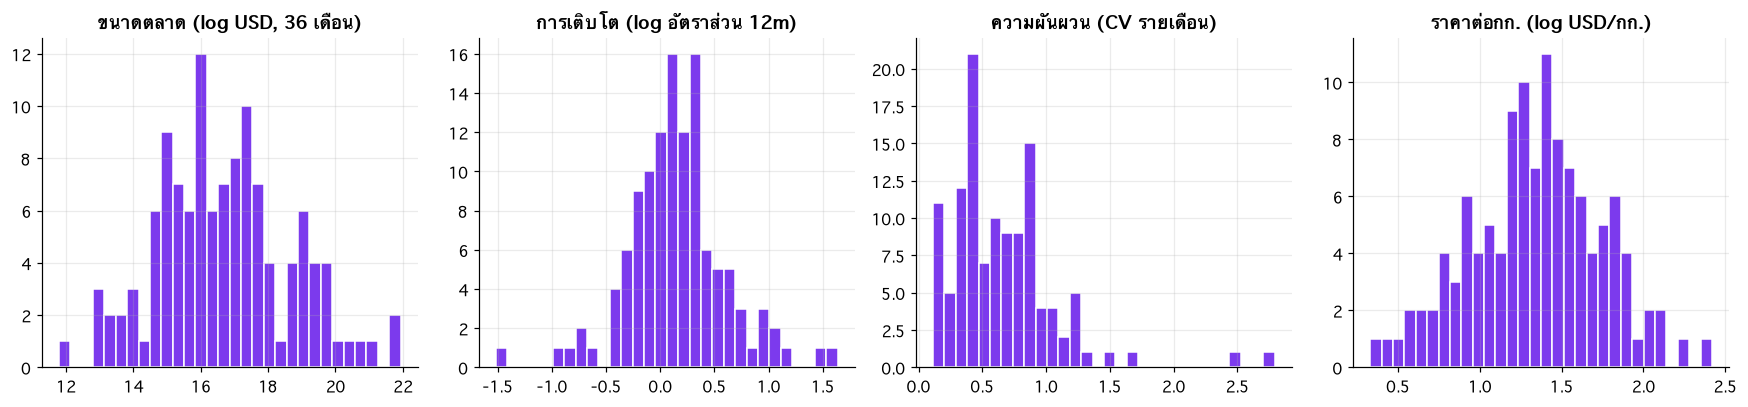

,count,mean,std,min,25%,50%,75%,max
size_log,119.00,16.72,1.97,11.79,15.22,16.57,17.84,21.93
growth,119.00,0.16,0.45,-1.52,-0.06,0.13,0.35,1.64
volatility,119.00,0.66,0.41,0.11,0.40,0.59,0.86,2.79
active_share,119.00,0.95,0.08,0.67,0.93,1.00,1.00,1.00
uv_log,119.00,1.34,0.40,0.33,1.08,1.35,1.61,2.42
hhi,119.00,0.77,0.25,0.21,0.55,0.89,1.00,1.00
gdppc_log,116.00,9.42,1.25,6.44,8.42,9.51,10.44,11.63


In [45]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.8))
for a, c_, t_ in zip(ax, ["size_log", "growth", "volatility", "uv_log"], ["ขนาดตลาด (log USD, 36 เดือน)", "การเติบโต (log อัตราส่วน 12m)", "ความผันผวน (CV รายเดือน)", "ราคาต่อกก. (log USD/กก.)"]):
    a.hist(cf2[c_].dropna(), bins=30, color=C["purple"], edgecolor="white"); a.set(title=t_)
plt.tight_layout(); plt.show()
display(cf2[["size_log", "growth", "volatility", "active_share", "uv_log", "hhi", "gdppc_log"]].describe().T)

### 📝 อ่านผล: ชุดข้อมูลสำหรับจัดกลุ่มตลาด

- **W1 (พ.ค. 2020 – เม.ย. 2023) มี 110 ประเทศ, W2 (พ.ค. 2023 – เม.ย. 2026) มี 119 ประเทศ ซึ่งอยู่ในทั้งสองช่วง 107 ประเทศ** (ใช้ประเทศที่มีการค้าอย่างน้อย 24 จาก 36 เดือน) → ตรวจความเสถียรของกลุ่มข้ามช่วงเวลาได้
- **ตลาดส่วนใหญ่ซื้อสินค้าเฉพาะกลุ่มเดียว:** ค่า hhi (ความกระจุกตัวของสินค้า, 1 = สินค้ากลุ่มเดียว) มัธยฐานราว 0.89 (เฉลี่ย 0.77) ตัวอย่าง: **ลิเบีย 100% และซาอุดีอาระเบีย 99% เป็นปลากระป๋อง (1604)**, ออสเตรเลีย 79%, แคนาดา 71%, สหรัฐฯ 61% ปลากระป๋อง ส่วน **จีน 68% เป็นกลุ่มกุ้ง ปู (0306)** ขณะที่ญี่ปุ่น (hhi 0.26) และเกาหลีใต้ (0.22) กระจายหลายสินค้า → เป็นโครงสร้างที่ clustering น่าจะแยกกลุ่มได้ชัด
- ตัวแปรต่าง ๆ กระจายกว้างพอสำหรับแบ่งกลุ่ม (กราฟ): ขนาดตลาด (log USD) 11.8–21.9, การเติบโตมัธยฐาน 0.13 (−1.52 ถึง 1.64), ความผันผวนมัธยฐาน 0.59 (0.11–2.79), ราคาต่อกก. (log) เฉลี่ย 1.34 ≈ 3.8 USD/กก.
- ค่าว่างมีเพียง `gdppc_log` ของ 3 ประเทศ (จาก 119) → ใช้ตีความกลุ่มได้เกือบครบ
- **ข้อควรระวัง:** ตัวแปรที่มีสเกลต่างกันมาก (ขนาดตลาดเป็น log ~12–22 กับสัดส่วน 0–1) ต้องปรับสเกลก่อนจัดกลุ่มในขั้น Modeling และต้องระวังไม่ให้ `mix_*` กับ `hhi` นับซ้ำจนครอบงำ

## 3.7 บันทึกผลลัพธ์

In [46]:
panel.to_csv(OUT_DIR / "forecast_panel.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(list(universe), columns=["hs4", "iso2"]).to_csv(OUT_DIR / "series_universe.csv", index=False, encoding="utf-8-sig")
cf1.to_csv(OUT_DIR / "cluster_features_w1.csv", index=False, encoding="utf-8-sig")
cf2.to_csv(OUT_DIR / "cluster_features_w2.csv", index=False, encoding="utf-8-sig")
params = {"START_TRAIN": str(START_TRAIN.date()), "FIRST_ORIGIN": str(FIRST_ORIGIN.date()), "LAST_MONTH": str(LAST_MONTH.date()), "HORIZONS": list(HORIZONS), "MIN_ACTIVE": MIN_ACTIVE, "WIN": WIN, "n_series": len(universe), "n_panel_rows": len(panel)}
(OUT_DIR / "prep_params.json").write_text(json.dumps(params, ensure_ascii=False, indent=1), encoding="utf-8")
out = pd.DataFrame([(p.name, f"{p.stat().st_size / 1e6:.1f} MB", sum(1 for _ in open(p, encoding="utf-8-sig")) - 1 if p.suffix == ".csv" else "—") for p in sorted(OUT_DIR.iterdir())], columns=["ไฟล์ใน DATASET/prepared/", "ขนาด", "จำนวนแถว"])
display(out)

,ไฟล์ใน DATASET/prepared/,ขนาด,จำนวนแถว
0,ablation_h1.csv,0.0 MB,7
1,arima_test.csv,0.9 MB,20200
2,cluster_features_w1.csv,0.0 MB,110
3,cluster_features_w2.csv,0.0 MB,119
4,clusters_w1.csv,0.0 MB,110
5,clusters_w2.csv,0.0 MB,119
6,early_warning_latest.csv,0.0 MB,175
7,ew_predictions.csv,3.7 MB,37155
8,ew_sensitivity.csv,0.0 MB,5
9,forecast_panel.csv,26.5 MB,45152


## 3.8 ทะเบียนปัญหาของข้อมูล — สรุปว่าข้อมูลมีปัญหาอะไร และจัดการไปแล้วหรือยัง

รวมปัญหาจากส่วน 2 และที่พบเพิ่มระหว่างเตรียมข้อมูล (จำแนกว่า **แก้แล้ว / ลดผลแล้ว / ยังเหลือ**) เพื่อใช้เป็นหัวข้อ "ข้อจำกัดของข้อมูล" ในรายงาน

In [47]:
reg = pd.DataFrame([
    # (ปัญหา, ชุดข้อมูล, ผลกระทบ, สิ่งที่ทำ, สถานะ)
    ("ยอดส่งออกเปลี่ยนระดับช่วง 2011–2015 (8.1 → 5.5 พันล้านดอลลาร์)", "Comtrade", "โมเดลอาจเรียนรู้จากช่วงที่ไม่เหมือนปัจจุบัน", "target เริ่ม 2015; ทดสอบแบบ rolling-origin ข้ามหลายช่วง", "ลดผลแล้ว"),
    ("ความผันผวนรายเดือนสูง (CV 0.72) ไม่มีฤดูกาลระดับอนุกรมย่อย", "Comtrade", "เพดานความแม่นยำของการพยากรณ์รายเดือนต่ำ", "ตั้งสมมติฐานล่วงหน้า; ทดสอบระยะ 1/3/6 เดือน + feature ค่าเฉลี่ย/ความผันผวน", "ยังเหลือ (ข้อจำกัดของข้อมูลเอง)"),
    ("ตลาดประปราย: 816 จาก 1,148 อนุกรมมีการค้าน้อยกว่า 36 เดือนจาก 60 (ราว 530 ตัวมีการค้า ≤ 3 เดือน)", "Comtrade", "อนุกรมเต็มไปด้วยศูนย์ ทำให้ error สูงเกินจริง", f"ใช้เฉพาะ {len(universe)} อนุกรมที่ต่อเนื่อง (เลือกจากช่วงเทรนเท่านั้น)", "แก้แล้ว"),
    ("ตลาดใหม่ที่เกิดหลังช่วงเทรน (cold start)", "Comtrade", "พยากรณ์ไม่ได้ เพราะไม่มีประวัติ", f"อยู่นอกขอบเขต — ครอบคลุม {funnel.iloc[4, 2]:.1f}% ของมูลค่าช่วงทดสอบ (ส่วนที่เหลือคือตลาดประปราย/ใหม่/nes)", "ยังเหลือ (บันทึกเป็นขอบเขต)"),
    ("สินค้า 1604 ครอง 59% ของมูลค่า", "Comtrade", "ตัวชี้วัดแบบรวมถูกครอบงำด้วยกลุ่มเดียว", "รายงานผลแยกกลุ่ม HS และใช้ WAPE + ผลถ่วงน้ำหนักและไม่ถ่วง", "ลดผลแล้ว"),
    ("ราคาต่อกก. มีค่าสุดโต่ง (0306 สูงสุด 10,105 USD/กก.)", "Comtrade", "feature ราคาถูกดึงด้วยค่าสุดโต่ง", "ใช้ log และคำนวณจากยอดรวม 12 เดือน (ไม่ใช่ค่าเฉลี่ยของแถว)", "ลดผลแล้ว"),
    ("เดือนที่ไม่มีการค้า = ไม่มีแถว", "Comtrade", "ช่องว่างในอนุกรม", "เติม 0 + feature `since_last`, `active12`", "แก้แล้ว"),
    ("คอลัมน์ qty_unit ว่าง 100%, cif_usd ว่าง 50%", "Comtrade", "ใช้ไม่ได้", "ไม่ใช้", "แก้แล้ว"),
    ("แถวคู่ค้าไม่มี ISO2 (nes) 1.6% ของมูลค่ารวมทุกปี (1.9% ในปี 2025)", "Comtrade", "join ข้อมูลประเทศไม่ได้", "ตัดจากอนุกรมประเทศ (ยังอยู่ในยอดรวม)", "แก้แล้ว"),
    ("อัตราแลกเปลี่ยนเริ่มปี 2021 ไม่ครอบคลุมช่วงเทรน", "FX (ECB)", "feature ว่างเกือบครึ่ง", "ดึงชุดรายเดือนตั้งแต่ 2010 เพิ่ม", "แก้แล้ว"),
    ("ECB ไม่มี TWD, VND, AED, SAR", "FX (ECB)", "ccy_chg3 ว่างสำหรับตลาดเหล่านี้", f"ปล่อยว่าง (โมเดลรองรับ) — มีสกุลเงินครอบคลุม {ccy_cov:.0%} ของอนุกรม", "ยังเหลือ"),
    ("World Bank ปีล่าสุดไม่ครบ (GDP 2025: 186/217 ประเทศ)", "World Bank", "ค่าว่างในปีล่าสุด", "ใช้ค่าของ 2 ปีก่อนวันที่ประเมิน (เป็นความเป็นจริงของการใช้งานด้วย)", "ลดผลแล้ว"),
    ("ไต้หวันอยู่ใน 'Other Asia, nes' (ไม่มี ISO2)", "Comtrade / WB", "ตลาดไต้หวันหายจากอนุกรมประเทศ", "ยังไม่แก้ (ราว 1.6–1.9% ของมูลค่า)", "ยังเหลือ"),
    ("DOF trade_hs มี key ซ้ำ 24% ของแถว", "กรมประมง", "นับซ้ำถ้าไม่รวม", "ไม่ใช้เป็นข้อมูลหลัก (ใช้ Comtrade) — รวมยอดแล้วที่ `DATASET/clean/`", "แก้แล้ว"),
    ("DOF รายวัน: สำเนาซ้ำ 59,393 / 20,061 แถว, ไม่มี HS", "กรมประมง", "ยอดอาจเกินจริง ~4%/2%", "ไม่ใช้ในโมเดลหลัก; ยังไม่ตัดสินใจลบ", "ยังเหลือ (ไม่กระทบโจทย์หลัก)"),
    ("ใบรับรองสุขภาพขาด 15 เดือน และไม่เป็นตัวชี้นำ", "กรมประมง", "ใช้เป็น feature ไม่ได้", "ไม่ใช้", "แก้แล้ว (ตัดออก)"),
    ("ผลผลิตกุ้งรายเดือนมีแค่ 23 เดือน; ปีของไฟล์ '2569' อนุมาน", "กรมประมง", "ใช้ในโมเดลหลักไม่ได้", "ไม่ใช้ในโมเดลหลัก", "แก้แล้ว (ตัดออก)"),
    ("ไม่มีข้อมูลราคาตลาดจริง", "ราคาสะพานปลา", "ไม่มี feature ราคาตลาด", "ใช้ราคาต่อกก. จาก Comtrade แทน", "ลดผลแล้ว"),
    ("หน่วยของหลายคอลัมน์ไม่ได้ระบุ (ฝั่งกรมประมง)", "กรมประมง", "ตีความผิดได้", "ทำเครื่องหมาย 'อนุมาน' ใน DICTIONARY; โมเดลหลักใช้ Comtrade ซึ่งหน่วยชัดเจน", "ลดผลแล้ว"),
], columns=["ปัญหา", "ชุดข้อมูล", "ผลกระทบ", "สิ่งที่ทำ", "สถานะ"])
display(reg)
cnt = reg.สถานะ.str.extract(r"^(แก้แล้ว|ลดผลแล้ว|ยังเหลือ)")[0].value_counts()
print("สรุป:", cnt.to_dict(), f"จากทั้งหมด {len(reg)} ปัญหา")

,ปัญหา,ชุดข้อมูล,ผลกระทบ,สิ่งที่ทำ,สถานะ
0,ยอดส่งออกเปลี่ยนระดับช่วง 2011–2015 (8.1 → 5.5 พันล้านดอ...,Comtrade,โมเดลอาจเรียนรู้จากช่วงที่ไม่เหมือนปัจจุบัน,target เริ่ม 2015; ทดสอบแบบ rolling-origin ข้ามหลายช่วง,ลดผลแล้ว
1,ความผันผวนรายเดือนสูง (CV 0.72) ไม่มีฤดูกาลระดับอนุกรมย่อย,Comtrade,เพดานความแม่นยำของการพยากรณ์รายเดือนต่ำ,ตั้งสมมติฐานล่วงหน้า; ทดสอบระยะ 1/3/6 เดือน + feature ค่...,ยังเหลือ (ข้อจำกัดของข้อมูลเอง)
2,"ตลาดประปราย: 816 จาก 1,148 อนุกรมมีการค้าน้อยกว่า 36 เดื...",Comtrade,อนุกรมเต็มไปด้วยศูนย์ ทำให้ error สูงเกินจริง,ใช้เฉพาะ 332 อนุกรมที่ต่อเนื่อง (เลือกจากช่วงเทรนเท่านั้น),แก้แล้ว
3,ตลาดใหม่ที่เกิดหลังช่วงเทรน (cold start),Comtrade,พยากรณ์ไม่ได้ เพราะไม่มีประวัติ,อยู่นอกขอบเขต — ครอบคลุม 96.7% ของมูลค่าช่วงทดสอบ (ส่วนท...,ยังเหลือ (บันทึกเป็นขอบเขต)
4,สินค้า 1604 ครอง 59% ของมูลค่า,Comtrade,ตัวชี้วัดแบบรวมถูกครอบงำด้วยกลุ่มเดียว,รายงานผลแยกกลุ่ม HS และใช้ WAPE + ผลถ่วงน้ำหนักและไม่ถ่วง,ลดผลแล้ว
5,"ราคาต่อกก. มีค่าสุดโต่ง (0306 สูงสุด 10,105 USD/กก.)",Comtrade,feature ราคาถูกดึงด้วยค่าสุดโต่ง,ใช้ log และคำนวณจากยอดรวม 12 เดือน (ไม่ใช่ค่าเฉลี่ยของแถว),ลดผลแล้ว
6,เดือนที่ไม่มีการค้า = ไม่มีแถว,Comtrade,ช่องว่างในอนุกรม,"เติม 0 + feature `since_last`, `active12`",แก้แล้ว
7,"คอลัมน์ qty_unit ว่าง 100%, cif_usd ว่าง 50%",Comtrade,ใช้ไม่ได้,ไม่ใช้,แก้แล้ว
8,แถวคู่ค้าไม่มี ISO2 (nes) 1.6% ของมูลค่ารวมทุกปี (1.9% ใ...,Comtrade,join ข้อมูลประเทศไม่ได้,ตัดจากอนุกรมประเทศ (ยังอยู่ในยอดรวม),แก้แล้ว
9,อัตราแลกเปลี่ยนเริ่มปี 2021 ไม่ครอบคลุมช่วงเทรน,FX (ECB),feature ว่างเกือบครึ่ง,ดึงชุดรายเดือนตั้งแต่ 2010 เพิ่ม,แก้แล้ว


สรุป: {'แก้แล้ว': 8, 'ลดผลแล้ว': 6, 'ยังเหลือ': 5} จากทั้งหมด 19 ปัญหา


### 📝 อ่านผล: ข้อมูลมีปัญหาอะไรบ้าง (สรุปรวม)

จาก 19 ปัญหาที่พบ: **แก้แล้ว 8, ลดผลแล้ว 6, ยังเหลือ 5** ปัญหาที่ยังเหลือเป็นข้อจำกัดที่ต้องบอกในรายงาน ไม่ใช่สิ่งที่ซ่อมได้ด้วยการทำความสะอาด:

1. **ความผันผวนรายเดือนสูงและไม่มีฤดูกาลระดับอนุกรมย่อย** → เพดานความแม่นยำของ Goal 1 ต่ำโดยธรรมชาติของข้อมูล
2. **ตลาดใหม่/ตลาดประปรายที่โมเดลทำนายไม่ได้** (ราว 1.3% ของมูลค่าช่วงทดสอบ) และกลุ่ม nes (2.0%)
3. **ECB ไม่มีสกุลเงินของ 47% ของอนุกรม** (รวม TWD, VND, AED, SAR) ทำให้ feature สกุลเงินคู่ค้าขาดไป
4. **ไต้หวันถูกรวมใน "Other Asia, nes"** จึงหายไปจากอนุกรมประเทศ
5. **ข้อมูลรายวันของกรมประมงมีสำเนาซ้ำและไม่มี HS** (ไม่กระทบโจทย์หลักเพราะไม่ได้ใช้)

### สรุป Data Preparation

**ผลลัพธ์ที่ได้ใน `DATASET/prepared/`:** `forecast_panel.csv` (45,152 แถว), `series_universe.csv` (332 อนุกรม), `cluster_features_w1.csv` (110 ประเทศ), `cluster_features_w2.csv` (119 ประเทศ), `prep_params.json`

**ค่าตั้งต้นที่ใช้ (เปลี่ยนได้ที่ cell ในส่วน 3.0 แล้วรันส่วน 3 ใหม่ทั้งหมด):** target เริ่ม 2015, ทดสอบ 36 เดือนล่าสุด, ระยะ 1/3/6 เดือน, อนุกรมที่ต่อเนื่อง ≥ 36/60 เดือน, หน่วย USD

**ส่วนที่ยังไม่ได้ทำ (Modeling):** การเทรน Baseline/SARIMA/LightGBM ตามโครงในส่วน 1.4, การจัดกลุ่มตลาด และถ้ามีเวลา Early Warning (ต้องสร้าง label เพิ่ม)

> **สถานะ:** Business Understanding · Data Understanding · Data Preparation เสร็จแล้ว ส่วน Modeling, Evaluation, Deployment ยังไม่ได้เริ่ม

---
# 4. Modeling

โมเดลทำทีละโจทย์ ตามลำดับ: **4.1 จัดกลุ่มตลาด (Goal 2)** → 4.2 พยากรณ์ (Goal 1) → (ถ้ามีเวลา) Early Warning

## 4.1 Clustering — จัดกลุ่มตลาดส่งออก

**เป้าหมายทางธุรกิจ:** แบ่งประเทศคู่ค้าเป็นกลุ่มที่มีพฤติกรรมคล้ายกัน เพื่อวางกลยุทธ์แยกกลุ่ม (ใครคือตลาดหลักที่นิ่ง ใครกำลังโต ใครผันผวน)

**วิธีการ (ออกแบบไว้ก่อนดูผล):**
1. **ตัวแปรสองกลุ่ม** — พฤติกรรม 5 ตัว (`size_log`, `growth`, `log(volatility)`, `uv_log`, `active_share`) ปรับสเกลเป็น z-score และส่วนผสมสินค้า 10 กลุ่ม (`mix_*`) แปลงแบบ **Hellinger** (รากที่สองของสัดส่วน) ซึ่งเป็นวิธีมาตรฐานสำหรับข้อมูลสัดส่วนที่รวมกันได้ 1 และลดอิทธิพลของกลุ่มใหญ่ (ปลากระป๋อง 1604 เฉลี่ย 77% ของตลาด) ตัวแปร World Bank **ไม่ใช้ตัดสินกลุ่ม** ใช้ตีความผลเท่านั้น
2. **เปรียบเทียบอัลกอริทึม:** K-Means, Hierarchical (Ward), Gaussian Mixture และ DBSCAN บน k = 2–8
3. **กฎเลือกโมเดล (กำหนดล่วงหน้า):** ในโมเดลที่ *ทุกกลุ่มมีประเทศ ≥ 10 ประเทศ* และ *เสถียรเมื่อสุ่มตัวอย่างซ้ำ (bootstrap ARI ≥ 0.6)* เลือกตัวที่ **Silhouette สูงสุด** โดยต้องมี k ≥ 3 เพราะ k = 2 ให้ภาพแค่ "ใหญ่/เล็ก" ซึ่งหยาบเกินไปต่อการวางกลยุทธ์
4. **ตรวจเทียบ:** กลุ่มแบบสุ่ม, กลุ่มที่แบ่งด้วยขนาดตลาดอย่างเดียว และการจัดกลุ่มด้วยส่วนผสมสินค้าอย่างเดียว
5. **ตรวจความเสถียร:** (ก) สุ่มตัวอย่างซ้ำ 100 ครั้ง (ข) เทียบช่วง W1 (2020–2023) กับ W2 (2023–2026)

**ตัวชี้วัด:** Silhouette (−1 ถึง 1; > 0.5 = กลุ่มชัด, 0.25–0.5 = พอมีโครงสร้าง, < 0.25 = กลุ่มซ้อนทับ), Davies–Bouldin (ยิ่งต่ำยิ่งดี), Calinski–Harabasz (ยิ่งสูงยิ่งดี), ARI (ความสอดคล้องของกลุ่มข้ามการสุ่ม/ข้ามช่วงเวลา: 1 = เหมือนกันทุกประเทศ, 0 = เท่ากับการสุ่ม)

### 4.1.1 โหลดข้อมูลและสร้างเมทริกซ์ตัวแปร

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.decomposition import PCA

PREP = DATA / "prepared"
cl1, cl2 = rd(PREP / "cluster_features_w1.csv"), rd(PREP / "cluster_features_w2.csv")
MIX = [c for c in cl2.columns if c.startswith("mix_")]
BEH = ["size_log", "growth", "vol_log", "uv_log", "active_share"]
W_BEH = 1.0       # น้ำหนักของกลุ่มตัวแปรพฤติกรรมเทียบกับส่วนผสมสินค้า (ทดสอบ 0.5 และ 1.0 ด้านล่าง)
K_RANGE = range(2, 9)
N_INIT = 50       # จำนวนรอบสุ่มจุดเริ่มต้นของ K-Means (ใช้เท่ากันทุกที่เพื่อให้ผลเทียบกับโมเดลสุดท้ายได้ตรงกัน)

def design(df, w_beh=W_BEH, scaler=None):
    """เมทริกซ์สำหรับจัดกลุ่ม = [z-score ของพฤติกรรม × น้ำหนัก | sqrt(สัดส่วนสินค้า)]"""
    d = df.assign(vol_log=np.log(df.volatility))
    scaler = scaler or StandardScaler().fit(d[BEH])
    return np.hstack([scaler.transform(d[BEH]) * w_beh, np.sqrt(d[MIX].to_numpy())]), scaler

print(f"W2 (พ.ค. 2023 – เม.ย. 2026): {len(cl2)} ประเทศ | W1 (พ.ค. 2020 – เม.ย. 2023): {len(cl1)} ประเทศ")
display(cl2[BEH[:2] + ["volatility", "uv_log", "active_share"] + MIX].describe().T[["mean", "std", "min", "50%", "max"]])

W2 (พ.ค. 2023 – เม.ย. 2026): 119 ประเทศ | W1 (พ.ค. 2020 – เม.ย. 2023): 110 ประเทศ


,mean,std,min,50%,max
size_log,16.72,1.97,11.79,16.57,21.93
growth,0.16,0.45,-1.52,0.13,1.64
volatility,0.66,0.41,0.11,0.59,2.79
uv_log,1.34,0.40,0.33,1.35,2.42
active_share,0.95,0.08,0.67,1.00,1.00
mix_0301,0.04,0.12,0.00,0.00,0.56
mix_0302,0.00,0.03,0.00,0.00,0.30
mix_0303,0.04,0.12,0.00,0.00,0.99
mix_0304,0.01,0.02,0.00,0.00,0.15
mix_0305,0.03,0.14,0.00,0.00,0.95


In [49]:
# ทำไมต้องออกแบบตัวแปร: ถ้าโยนทุกตัวแปรเข้าไปปรับสเกลตรง ๆ จะเป็นอย่างไร?
Xn = StandardScaler().fit_transform(cl2.assign(vol_log=np.log(cl2.volatility))[BEH + MIX])
naive = pd.DataFrame([(k, *(lambda l: (silhouette_score(Xn, l), np.bincount(l).tolist()))(KMeans(k, n_init=20, random_state=0).fit_predict(Xn))) for k in range(2, 7)],
                     columns=["k", "silhouette", "ขนาดกลุ่ม"])
print("วิธีตรงไปตรงมา (standardize ทุกตัวแปรรวมสัดส่วนสินค้า 10 ตัว ไม่แปลง) — ได้กลุ่มที่เล็กจนใช้ไม่ได้ (บางกลุ่มมี 1–3 ประเทศ):")
display(naive)

วิธีตรงไปตรงมา (standardize ทุกตัวแปรรวมสัดส่วนสินค้า 10 ตัว ไม่แปลง) — ได้กลุ่มที่เล็กจนใช้ไม่ได้ (บางกลุ่มมี 1–3 ประเทศ):


,k,silhouette,ขนาดกลุ่ม
0,2,0.34,"[88, 31]"
1,3,0.34,"[84, 24, 11]"
2,4,0.36,"[21, 3, 11, 84]"
3,5,0.34,"[25, 3, 10, 2, 79]"
4,6,0.18,"[19, 58, 27, 1, 11, 3]"


### 📝 อ่านผล: ตัวแปรสำหรับจัดกลุ่ม

- ใช้ข้อมูล **119 ประเทศ (W2)** และ 110 ประเทศ (W1) ตัวแปรกระจายกว้างพอจัดกลุ่มได้ (ขนาดตลาด log 11.8–21.9, การเติบโต −1.52 ถึง 1.64, ความผันผวน 0.11–2.79)
- **ส่วนผสมสินค้าเบ้มาก:** `mix_1604` (ปลากระป๋อง) **เฉลี่ย 0.77 แต่มัธยฐาน 0.92** หมายความว่าตลาดมากกว่าครึ่งซื้อปลากระป๋องเกือบทั้งหมด ส่วนกลุ่ม HS อื่นส่วนใหญ่เป็น 0 (มัธยฐานของ mix_0301–0308, 1605 = 0) → จึงต้องแปลงแบบ Hellinger และไม่ปล่อยให้ 10 คอลัมน์สัดส่วนครอบงำ 5 ตัวแปรพฤติกรรม
- **ถ้าใช้วิธีตรงไปตรงมา** (ปรับสเกลทุกตัวแปรแล้วจัดกลุ่ม) ค่า Silhouette ดู *สูง* (0.34–0.36) **แต่เป็นภาพลวง:** กลุ่มที่ได้มีขนาด เช่น [21, 3, 11, 84] และ [25, 3, 10, 2, 79] คือมีกลุ่มที่มีเพียง 1–3 ประเทศ (ค่าสุดโต่งถูกแยกออกมาเป็นกลุ่มเอง) ใช้เป็นกลุ่มตลาดไม่ได้ → เป็นเหตุผลที่ต้องออกแบบตัวแปรและกำหนดเงื่อนไขขนาดกลุ่มขั้นต่ำในกฎเลือกโมเดล

### 4.1.2 เปรียบเทียบอัลกอริทึม × น้ำหนัก × จำนวนกลุ่ม

In [50]:
def fit_labels(algo, X, k, seed=0):
    if algo == "K-Means": return KMeans(k, n_init=N_INIT, random_state=seed).fit_predict(X)
    if algo == "Ward":    return AgglomerativeClustering(k, linkage="ward").fit_predict(X)
    return GaussianMixture(k, covariance_type="spherical", n_init=5, random_state=seed).fit(X).predict(X)

def boot_ari(algo, X, k, B=30, frac=.8, seed=1):
    """สุ่มย่อย 80% ซ้ำ B ครั้ง วัดว่ากลุ่มที่ได้สอดคล้องกับกลุ่มจากข้อมูลเต็มแค่ไหน (ARI เฉลี่ย)"""
    rng, full, out = np.random.default_rng(seed), fit_labels(algo, X, k), []
    for b in range(B):
        idx = rng.choice(len(X), int(frac * len(X)), replace=False)
        out.append(adjusted_rand_score(full[idx], fit_labels(algo, X[idx], k, seed=b)))
    return float(np.mean(out))

rows = []
for w in (0.5, 1.0):
    X, _ = design(cl2, w)
    for algo in ("K-Means", "Ward", "GMM"):
        for k in K_RANGE:
            l = fit_labels(algo, X, k)
            rows.append((w, algo, k, silhouette_score(X, l), davies_bouldin_score(X, l), calinski_harabasz_score(X, l), int(np.bincount(l).min()), boot_ari(algo, X, k)))
grid = pd.DataFrame(rows, columns=["w_beh", "algo", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "min_size", "boot_ARI"])
display(grid[grid.w_beh == 1.0].drop(columns="w_beh").round(3).set_index(["algo", "k"]).unstack(0).swaplevel(0, 1, axis=1).sort_index(axis=1)[["K-Means", "Ward", "GMM"]])

algo  K-Means                                                          Ward                                                           GMM                                                     
     boot_ARI calinski_harabasz davies_bouldin min_size silhouette boot_ARI calinski_harabasz davies_bouldin min_size silhouette boot_ARI calinski_harabasz davies_bouldin min_size silhouette
k                                                                                                                                                                                             
2        0.95             48.24           1.43       48       0.27     0.31             39.69           1.49       46       0.20     0.88             47.01           1.46       50       0.27
3        0.62             40.06           1.44       28       0.21     0.29             34.73           1.58       32       0.18     0.77             31.43           1.67       22       0.17
4        0.61             38.68           1.36       18       0.22     0.40             32.90           1.42       17       0.19     0.63             31.09           1.38       13       0.21
5        0.64             36.02           1.24       14       0.21     0.41             31.00           1.31        7       0.18     0.60             33.40           1.34       15       0.18
6        0.64             35.19           1.24       13       0.21     0.42             29.42           1.24        7       0.18     0.58             33.48           1.31       13       0.20
7        0.66             34.01           1.20        5       0.22     0.42             28.46           1.19        3       0.19     0.57             32.25           1.25       10       0.20
8        0.59             33.54           1.21        5       0.23     0.42             27.50           1.21        3       0.19     0.56             32.98           1.22        6       0.22

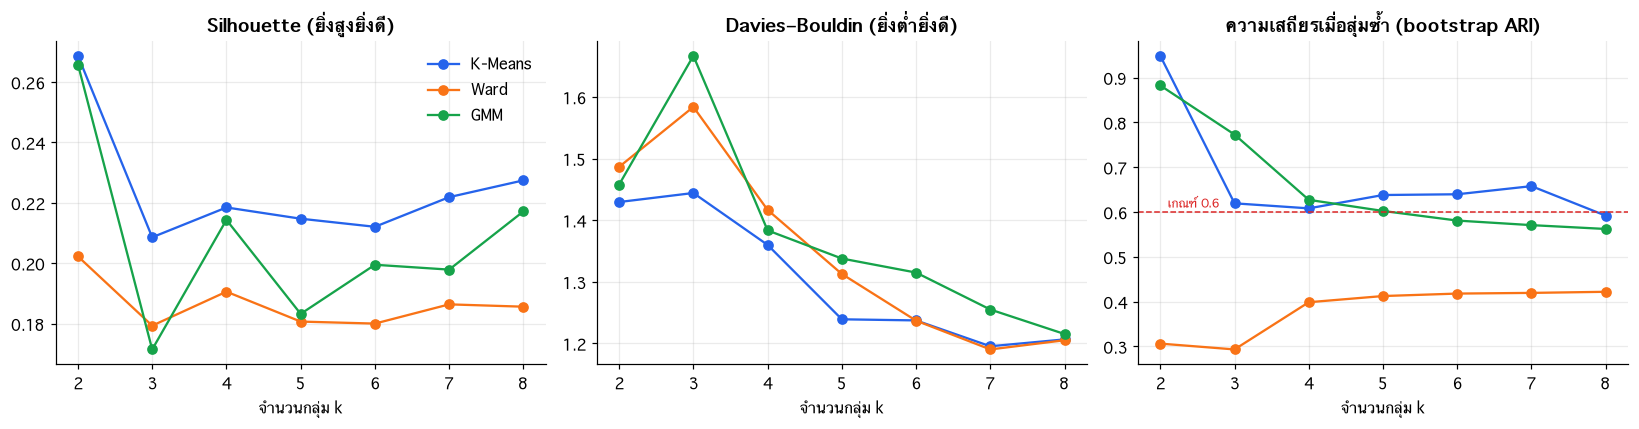

In [51]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, m_, t_ in zip(ax, ["silhouette", "davies_bouldin", "boot_ARI"], ["Silhouette (ยิ่งสูงยิ่งดี)", "Davies–Bouldin (ยิ่งต่ำยิ่งดี)", "ความเสถียรเมื่อสุ่มซ้ำ (bootstrap ARI)"]):
    for (algo, col) in zip(("K-Means", "Ward", "GMM"), (C["blue"], C["orange"], C["green"])):
        g_ = grid[(grid.w_beh == 1.0) & (grid.algo == algo)]; a.plot(g_.k, g_[m_], marker="o", color=col, label=algo)
    a.set(title=t_, xlabel="จำนวนกลุ่ม k")
ax[2].axhline(0.6, color=C["red"], ls="--", lw=1); ax[2].text(2.1, .61, "เกณฑ์ 0.6", color=C["red"], fontsize=8); ax[0].legend(frameon=False)
plt.tight_layout(); plt.show()

In [52]:
# DBSCAN (ไม่ต้องกำหนด k): ลอง eps หลายค่า
Xd, _ = design(cl2, 1.0)
db_rows = []
for eps in (0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0):
    l = DBSCAN(eps=eps, min_samples=5).fit_predict(Xd); n_cl = len(set(l) - {-1}); noise = (l == -1).mean()
    sil = silhouette_score(Xd[l != -1], l[l != -1]) if n_cl >= 2 and (l != -1).sum() > n_cl else np.nan
    db_rows.append((eps, n_cl, f"{noise:.0%}", sil, np.bincount(l[l != -1]).tolist() if n_cl else []))
display(pd.DataFrame(db_rows, columns=["eps", "จำนวนกลุ่ม", "% ประเทศที่เป็น noise", "silhouette (ไม่นับ noise)", "ขนาดกลุ่ม"]))

,eps,จำนวนกลุ่ม,% ประเทศที่เป็น noise,silhouette (ไม่นับ noise),ขนาดกลุ่ม
0,0.40,0,100%,NaN,[]
1,0.60,0,100%,NaN,[]
2,0.80,1,72%,NaN,[33]
3,1.00,2,49%,0.43,"[54, 7]"
4,1.20,1,33%,NaN,[80]
5,1.50,1,13%,NaN,[103]
6,2.00,1,3%,NaN,[115]


### 📝 อ่านผล: เปรียบเทียบอัลกอริทึม

| อัลกอริทึม | Silhouette (k = 3–8) | ความเสถียรเมื่อสุ่มซ้ำ (bootstrap ARI) | สรุป |
|---|---|---|---|
| **K-Means** | 0.21–0.23 | **0.59–0.66** (k = 2: 0.95) | เสถียรที่สุด และ Silhouette สูงสุดเกือบทุก k |
| Ward (Hierarchical) | 0.18–0.19 | **0.29–0.42** | **ไม่เสถียร**: สุ่มข้อมูลใหม่ กลุ่มเปลี่ยนมาก |
| GMM | 0.17–0.22 | 0.56–0.77 | เสถียรปานกลาง Silhouette ต่ำกว่า K-Means |
| DBSCAN | — | — | ไม่เหมาะ: ที่ eps = 1.0 ได้ 2 กลุ่ม (54 และ 7 ประเทศ) แต่ **49% ของประเทศเป็น noise** ค่า eps อื่นได้ทุกประเทศเป็น noise หรือกลุ่มเดียว |

**ข้อสังเกตสำคัญ:**
- **Silhouette แทบแบนที่ ≈ 0.21 ตั้งแต่ k = 3 ถึง 8** (กราฟซ้าย) ไม่มีจำนวนกลุ่มที่ "ธรรมชาติ" เป็นพิเศษ เพียง **k = 2** โดดเด่นขึ้น (0.27) ซึ่งเป็นการแบ่ง "ตลาดใหญ่/นิ่ง" กับ "ตลาดเล็ก/ผันผวน" อย่างหยาบ ๆ
- Davies–Bouldin ลดลงเมื่อ k เพิ่ม (1.43 → 1.21) ซึ่งเป็นลักษณะปกติของตัวชี้วัดนี้ ไม่ได้ชี้ว่ากลุ่มเยอะดีกว่า
- DBSCAN ไม่ได้ผล และ Ward ไม่เสถียร สนับสนุนข้อสรุปว่า **ตลาดกระจายแบบต่อเนื่อง ไม่มีก้อนความหนาแน่นแยกขาด** ผลลัพธ์ที่ได้จึงเป็นการ *แบ่งส่วน (segmentation) เชิงธุรกิจ* มากกว่า "กลุ่มธรรมชาติ"

### 4.1.3 จุดเทียบ: กลุ่มแบบสุ่ม / แบ่งตามขนาดอย่างเดียว / ใช้ส่วนผสมสินค้าอย่างเดียว

In [53]:
rng = np.random.default_rng(0)
ref = []
for k in (2, 4, 6):
    Xk, _ = design(cl2, 1.0)
    km_lab = fit_labels("K-Means", Xk, k)
    rnd = np.mean([silhouette_score(Xk, rng.permutation(km_lab)) for _ in range(200)])           # สลับป้ายกลุ่มแบบสุ่ม ขนาดกลุ่มเท่าเดิม
    size_only = pd.qcut(cl2.size_log, k, labels=False).to_numpy()                                   # แบ่งเป็น k ช่วงตามขนาดตลาดอย่างเดียว
    mix_only = fit_labels("K-Means", np.sqrt(cl2[MIX].to_numpy()), k)                              # จัดกลุ่มด้วยส่วนผสมสินค้าอย่างเดียว (วัดบนเมทริกซ์เต็ม)
    ref.append((k, silhouette_score(Xk, km_lab), rnd, silhouette_score(Xk, size_only), silhouette_score(Xk, mix_only), np.bincount(mix_only).min()))
display(pd.DataFrame(ref, columns=["k", "K-Means (ตัวแปรเต็ม)", "สุ่มป้ายกลุ่ม", "แบ่งตามขนาดตลาดอย่างเดียว", "ใช้ส่วนผสมสินค้าอย่างเดียว", "ประเทศในกลุ่มเล็กสุด (ส่วนผสมอย่างเดียว)"]).round(3))

,k,K-Means (ตัวแปรเต็ม),สุ่มป้ายกลุ่ม,แบ่งตามขนาดตลาดอย่างเดียว,ใช้ส่วนผสมสินค้าอย่างเดียว,ประเทศในกลุ่มเล็กสุด (ส่วนผสมอย่างเดียว)
0,2,0.27,-0.00,0.19,0.14,34
1,4,0.22,-0.06,0.05,0.09,3
2,6,0.21,-0.09,-0.01,-0.04,3


### 📝 อ่านผล: เทียบกับจุดอ้างอิง

| k | สุ่มป้ายกลุ่ม | แบ่งตามขนาดอย่างเดียว | ส่วนผสมสินค้าอย่างเดียว | **K-Means (พฤติกรรม + สินค้า)** |
|---|---|---|---|---|
| 2 | −0.00 | 0.19 | 0.14 | **0.27** |
| 4 | −0.06 | 0.05 | 0.09 | **0.22** |
| 6 | −0.09 | −0.01 | −0.04 | **0.21** |

- **การสุ่มได้ Silhouette ≈ 0 หรือติดลบ** ขณะที่โมเดลได้ 0.21–0.27 → กลุ่มที่ได้ *มีโครงสร้างจริง* ไม่ได้เกิดจากโอกาส แต่เป็นระดับ "โครงสร้างอ่อน" (ต่ำกว่า 0.25 ในเกณฑ์ที่ตั้งไว้ที่ k ≥ 4)
- **ใช้ตัวแปรชุดเดียวอย่างเดียวแย่กว่าใช้รวมกัน:** แบ่งตามขนาดอย่างเดียว (0.05 ที่ k = 4) หรือส่วนผสมสินค้าอย่างเดียว (0.09 ที่ k = 4 และกลุ่มเล็กสุดมีเพียง 3 ประเทศ) → การรวม 2 มิติให้ผลดีกว่า ซึ่งสนับสนุนการออกแบบตัวแปร

### 4.1.4 เลือกโมเดลตามกฎที่ตั้งไว้

In [54]:
cand = grid[(grid.w_beh == 1.0) & (grid.k >= 3) & (grid.min_size >= 10) & (grid.boot_ARI >= 0.6)].sort_values("silhouette", ascending=False)
print("ตัวเลือกที่ผ่านเกณฑ์ (ทุกกลุ่ม ≥ 10 ประเทศ, bootstrap ARI ≥ 0.6, k ≥ 3) เรียงตาม Silhouette:")
display(cand.round(3))
best = cand.iloc[0]
ALGO, K = best.algo, int(best.k)
print(f"\n➡ เลือก: {ALGO}, k = {K} (น้ำหนักพฤติกรรม = {best.w_beh})")

ตัวเลือกที่ผ่านเกณฑ์ (ทุกกลุ่ม ≥ 10 ประเทศ, bootstrap ARI ≥ 0.6, k ≥ 3) เรียงตาม Silhouette:


,w_beh,algo,k,silhouette,davies_bouldin,calinski_harabasz,min_size,boot_ARI
23,1.00,K-Means,4,0.22,1.36,38.68,18,0.61
24,1.00,K-Means,5,0.21,1.24,36.02,14,0.64
37,1.00,GMM,4,0.21,1.38,31.09,13,0.63
25,1.00,K-Means,6,0.21,1.24,35.19,13,0.64
22,1.00,K-Means,3,0.21,1.44,40.06,28,0.62
38,1.00,GMM,5,0.18,1.34,33.40,15,0.60
36,1.00,GMM,3,0.17,1.67,31.43,22,0.77



➡ เลือก: K-Means, k = 4 (น้ำหนักพฤติกรรม = 1.0)


### 📝 อ่านผล: การเลือกโมเดล

ตามกฎที่ตั้งไว้ล่วงหน้า ตัวเลือกที่ผ่านเกณฑ์เรียงตาม Silhouette อันดับแรกคือ **K-Means, k = 4** (Silhouette 0.22, Davies–Bouldin 1.36, bootstrap ARI 0.61, กลุ่มเล็กสุดมี 18 ประเทศ)

**ควรบอกในรายงานตรง ๆ ว่า:** ทางเลือก k = 3, 5, 6 มีคุณภาพใกล้เคียงกันมาก (Silhouette 0.21, ARI 0.62–0.64) ความต่างระหว่าง k = 4 กับ k = 5 อยู่ในระดับที่ไม่มีนัยสำคัญทางสถิติ การเลือก k = 4 จึงเป็นการตัดสินใจตามกฎที่กำหนดล่วงหน้าและเพื่อความอ่านง่ายเชิงธุรกิจ (4 กลุ่ม) ไม่ใช่ว่า 4 เป็น "คำตอบที่ถูกต้อง" เพียงค่าเดียว

### 4.1.5 โปรไฟล์ของแต่ละกลุ่ม

In [55]:
X2, sc2 = design(cl2, W_BEH)
raw_lab = KMeans(K, n_init=N_INIT, random_state=0).fit(X2)
order = pd.Series(cl2.size_log.groupby(raw_lab.labels_).mean()).sort_values(ascending=False).index.tolist()   # เรียงกลุ่มจากขนาดตลาดเฉลี่ยใหญ่ -> เล็ก
remap = {old: new for new, old in enumerate(order)}
cl2["cluster"] = [remap[x] for x in raw_lab.labels_]
km2 = raw_lab; km2_remap = remap
cl2["value_usd"] = np.exp(cl2.size_log)                          # มูลค่ารวม 36 เดือน (ประมาณ)
tot = cl2.value_usd.sum()
prof = cl2.groupby("cluster").agg(ประเทศ=("iso2", "size"), ขนาดตลาดเฉลี่ย_log=("size_log", "mean"), เติบโต=("growth", "mean"), ผันผวน=("volatility", "median"),
                                  ราคาต่อกก_log=("uv_log", "mean"), เดือนที่มีการค้า=("active_share", "mean"), GDPต่อหัว_log=("gdppc_log", "mean"),
                                  มูลค่า_ล้านUSD=("value_usd", lambda s: s.sum() / 1e6))
prof["% ของมูลค่ารวม"] = prof["มูลค่า_ล้านUSD"] / (tot / 1e6) * 100
prof["USD/กก. (exp)"] = np.exp(prof.ราคาต่อกก_log)
display(prof.round(2))
top = {c: ", ".join(g.sort_values("size_log", ascending=False).iso2.head(10)) for c, g in cl2.groupby("cluster")}
print("ประเทศใหญ่สุดในแต่ละกลุ่ม:"); [print(f"  กลุ่ม {c}: {v}") for c, v in top.items()]

,ประเทศ,ขนาดตลาดเฉลี่ย_log,เติบโต,ผันผวน,ราคาต่อกก_log,เดือนที่มีการค้า,GDPต่อหัว_log,มูลค่า_ล้านUSD,% ของมูลค่ารวม,USD/กก. (exp)
cluster,,,,,,,,,,
0,35,19.03,0.15,0.32,1.43,1.00,9.82,"14,156.58",92.05,4.17
1,33,16.28,-0.18,0.67,1.05,0.97,9.22,740.98,4.82,2.85
2,33,15.85,0.39,0.65,1.62,0.98,9.43,414.71,2.70,5.04
3,18,14.63,0.39,0.98,1.21,0.80,8.99,66.88,0.43,3.35


ประเทศใหญ่สุดในแต่ละกลุ่ม:
  กลุ่ม 0: US, JP, CN, AU, CA, LY, KR, SA, AE, EG
  กลุ่ม 1: KH, AR, QA, RS, DO, LK, OM, PA, IQ, SC
  กลุ่ม 2: SY, SO, TR, MX, BA, FR, NO, GR, FI, ID
  กลุ่ม 3: BS, NI, CG, MN, ME, SR, IS, ZW, PY, PF


[None, None, None, None]

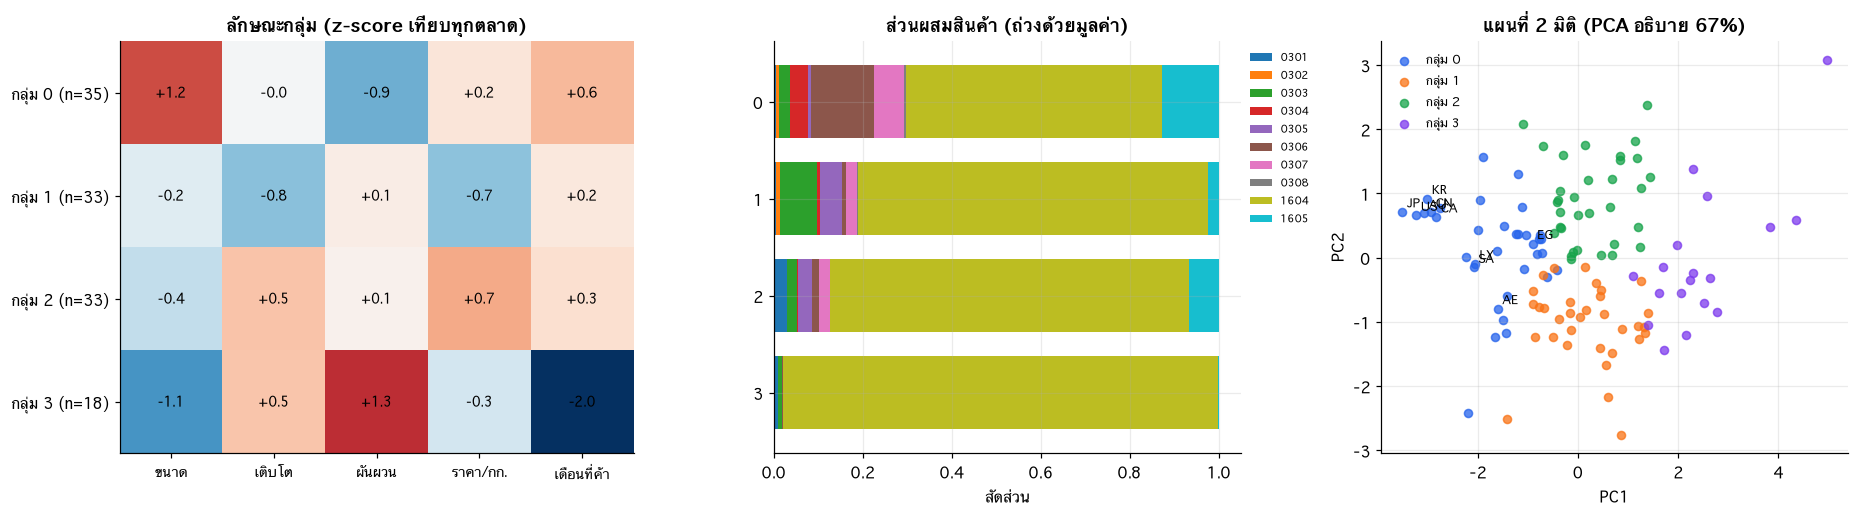

In [56]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={"width_ratios": [1.1, 1.0, 1.0]})
# (1) heatmap ค่ากลางของแต่ละกลุ่มเทียบทั้งตลาด (z-score)
cols = ["size_log", "growth", "volatility", "uv_log", "active_share"]
z = (cl2.groupby("cluster")[cols].mean() - cl2[cols].mean()) / cl2[cols].std()
im = ax[0].imshow(z.values, cmap="RdBu_r", vmin=-1.8, vmax=1.8, aspect="auto")
ax[0].set_xticks(range(len(cols))); ax[0].set_xticklabels(["ขนาด", "เติบโต", "ผันผวน", "ราคา/กก.", "เดือนที่ค้า"], fontsize=9)
ax[0].set_yticks(range(K)); ax[0].set_yticklabels([f"กลุ่ม {i} (n={int((cl2.cluster == i).sum())})" for i in range(K)]); ax[0].grid(False)
for i in range(K):
    for j in range(len(cols)): ax[0].text(j, i, f"{z.values[i, j]:+.1f}", ha="center", va="center", fontsize=9)
ax[0].set_title("ลักษณะกลุ่ม (z-score เทียบทุกตลาด)")
# (2) ส่วนผสมสินค้าแบบถ่วงมูลค่า
vm = (cl2[MIX].mul(cl2.value_usd, axis=0)).groupby(cl2.cluster).sum(); vm = vm.div(vm.sum(axis=1), axis=0)
vm.rename(columns=lambda c: c.replace("mix_", "")).plot.barh(stacked=True, ax=ax[1], colormap="tab10", width=.75, legend=False); ax[1].invert_yaxis()
ax[1].set(title="ส่วนผสมสินค้า (ถ่วงด้วยมูลค่า)", xlabel="สัดส่วน", ylabel=""); ax[1].legend(fontsize=7, frameon=False, bbox_to_anchor=(1, 1))
# (3) PCA 2 มิติ
pcs = PCA(2, random_state=0).fit(X2); P = pcs.transform(X2)
pal = [C["blue"], C["orange"], C["green"], C["purple"], C["red"], C["teal"]]
for c_ in range(K): ax[2].scatter(P[cl2.cluster == c_, 0], P[cl2.cluster == c_, 1], s=28, alpha=.75, color=pal[c_], label=f"กลุ่ม {c_}")
for i in cl2.sort_values("size_log", ascending=False).head(10).index: ax[2].annotate(cl2.iso2[i], P[i], fontsize=8, xytext=(3, 3), textcoords="offset points")
ax[2].set(title=f"แผนที่ 2 มิติ (PCA อธิบาย {pcs.explained_variance_ratio_.sum():.0%})", xlabel="PC1", ylabel="PC2"); ax[2].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

In [57]:
# ตีความด้วยข้อมูลที่ไม่ได้ใช้จัดกลุ่ม: ระดับรายได้และภูมิภาค (World Bank)
inc = pd.crosstab(cl2.cluster, cl2.income.fillna("ไม่มีข้อมูล"), normalize="index").mul(100).round(0)
reg_ = pd.crosstab(cl2.cluster, cl2.region.fillna("ไม่มีข้อมูล"), normalize="index").mul(100).round(0)
print("% ของประเทศในแต่ละกลุ่ม แยกตามระดับรายได้"); display(inc)
print("% ของประเทศในแต่ละกลุ่ม แยกตามภูมิภาค"); display(reg_)

% ของประเทศในแต่ละกลุ่ม แยกตามระดับรายได้


income,High income,Low income,Lower middle income,Upper middle income
cluster,,,,
0,57.00,3.00,11.00,29.00
1,36.00,3.00,24.00,36.00
2,48.00,6.00,18.00,27.00
3,28.00,0.00,39.00,33.00


% ของประเทศในแต่ละกลุ่ม แยกตามภูมิภาค


region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,"Middle East, North Africa, Afghanistan & Pakistan",North America,South Asia,Sub-Saharan Africa
cluster,,,,,,,
0,34.00,20.00,11.00,26.00,6.00,0.00,3.00
1,15.00,18.00,27.00,12.00,0.00,9.00,18.00
2,15.00,48.00,9.00,9.00,0.00,9.00,9.00
3,17.00,28.00,22.00,11.00,0.00,0.00,22.00


### 📝 อ่านผล: 4 กลุ่มตลาดคือใคร

| กลุ่ม | ประเทศ | % ของมูลค่า (36 เดือน) | ลักษณะ | ส่วนผสมสินค้า (ถ่วงมูลค่า) |
|---|---|---|---|---|
| **A ตลาดหลัก: ใหญ่ ต่อเนื่อง ผันผวนต่ำ** | 35 | **92.1%** | ใหญ่ที่สุด (z = +1.2), ผันผวนต่ำสุด (มัธยฐาน 0.32), ค้าครบเกือบทุกเดือน (≥ 97%), เติบโตมัธยฐาน 0.09, ราคา 4.17 USD/กก. | **หลากหลาย:** ปลากระป๋อง 57%, กุ้ง/ปู 14%, กุ้ง/ปู/หอยปรุงแต่ง 13%, หอย/หมึก 7% |
| **B ตลาดปลากระป๋องราคาต่ำที่หดตัว** | 33 | 4.8% | **หดตัว** (เติบโตเฉลี่ย −0.18), **ราคาต่ำสุด** 2.85 USD/กก. | ปลากระป๋อง 79%, ปลาแช่แข็ง 8%, ปลาแห้ง 5% |
| **C ตลาดโตเร็ว ราคาต่อกก. สูง** | 33 | 2.7% | **โตเร็วที่สุด** (เฉลี่ย +0.39, มัธยฐาน +0.33), **ราคาสูงสุด** 5.04 USD/กก., ยุโรป/เอเชียกลาง 48% | ปลากระป๋อง 81% (แต่ราคาสูงกว่ากลุ่มอื่น ยังไม่ทราบสาเหตุ อาจเป็นสินค้าต่างชนิดภายใน HS 1604) |
| **D ตลาดเล็ก ผันผวน ค้าไม่ต่อเนื่อง** | 18 | 0.4% | เล็กสุด, **ผันผวนสุด** (มัธยฐาน 0.98), **ค้าไม่ต่อเนื่อง** (มีการค้าเฉลี่ยราว 80% ของเดือน ต่ำสุด 67%) ตัวเลขการเติบโตไม่น่าเชื่อถือเพราะฐานเล็ก | ปลากระป๋อง 98% |

**สิ่งที่น่าสนใจสำหรับรายงาน**
- **มูลค่าส่งออกกระจุกอยู่ที่กลุ่ม A เกือบทั้งหมด (92.1% จาก 35 ประเทศ)** และ 10 ประเทศแรก (สหรัฐฯ ญี่ปุ่น จีน ออสเตรเลีย แคนาดา ฯลฯ) มี 71% ของมูลค่าทั้งหมด กลยุทธ์ตลาดกลุ่ม A จึงสำคัญที่สุด ส่วนอีก 3 กลุ่มรวมกันมีไม่ถึง 8%
- **ตลาดส่วนใหญ่ซื้อปลากระป๋องเป็นหลัก** ในทุกกลุ่ม; ความแตกต่างระหว่างกลุ่มอยู่ที่ *พฤติกรรม* (นิ่ง/หดตัว/โต/ไม่ต่อเนื่อง) และราคา ไม่ใช่ชนิดสินค้า (ยกเว้นกลุ่ม A ที่ซื้อหลายชนิด)
- **ข้อมูลที่ไม่ได้ใช้จัดกลุ่มสนับสนุนการตีความ:** กลุ่ม A มีประเทศรายได้สูง 57% (East Asia & Pacific 34%, MENA 26%) · กลุ่ม C เป็นยุโรป/เอเชียกลาง 48% และรายได้สูง 48% · กลุ่ม D มีรายได้ปานกลางค่อนต่ำมากกว่า (39% lower-middle)
- **แผนที่ 2 มิติ (PCA อธิบาย 67%) ยืนยันว่ากลุ่มซ้อนทับกัน** ไม่ได้แยกขาดจากกัน สอดคล้องกับ Silhouette ที่ต่ำ: กลุ่ม A เกาะกลุ่มชัดฝั่งซ้าย (ญี่ปุ่น สหรัฐฯ จีน เกาหลีใต้) กลุ่ม B/C/D ปะปนกันมากกว่า

### 4.1.6 ความเสถียรของกลุ่ม

In [58]:
# (ก) bootstrap 100 ครั้ง ที่ k และอัลกอริทึมที่เลือก
ari_b = [boot_ari(ALGO, X2, K, B=1, seed=s) for s in range(100)]
# (ข) ข้ามช่วงเวลา: เอาโมเดลของ W2 ไปจัดประเทศใน W1, เทียบกับการจัดกลุ่ม W1 ด้วยตัวเอง
X1_by2, _ = design(cl1, W_BEH, scaler=sc2)
pred1 = np.array([km2_remap[x] for x in km2.predict(X1_by2)])
X1_own, _ = design(cl1, W_BEH)
own1 = KMeans(K, n_init=N_INIT, random_state=0).fit_predict(X1_own)
ari_win = adjusted_rand_score(pred1, own1)
sil1 = silhouette_score(X1_own, own1)
stab = pd.Series({"bootstrap ARI เฉลี่ย (100 ครั้ง, สุ่ม 80%)": np.mean(ari_b), "bootstrap ARI ต่ำสุด": np.min(ari_b),
                  "ARI: กลุ่ม W1 ที่จัดด้วยโมเดล W2 vs จัดด้วยตัวเอง": ari_win, "Silhouette ของ W1 (จัดกลุ่มเอง)": sil1, "Silhouette ของ W2": silhouette_score(X2, cl2.cluster)})
display(stab.round(3).to_frame("ค่า"))

,ค่า
"bootstrap ARI เฉลี่ย (100 ครั้ง, สุ่ม 80%)",0.69
bootstrap ARI ต่ำสุด,0.18
ARI: กลุ่ม W1 ที่จัดด้วยโมเดล W2 vs จัดด้วยตัวเอง,0.71
Silhouette ของ W1 (จัดกลุ่มเอง),0.22
Silhouette ของ W2,0.22


In [59]:
# ตลาดย้ายกลุ่มไหม? (ประเทศที่อยู่ทั้งสองช่วง)
a = pd.DataFrame({"iso2": cl1.iso2, "name_en": cl1.name_en, "กลุ่ม_W1": pred1, "size_w1": cl1.size_log}).merge(cl2[["iso2", "cluster", "size_log"]].rename(columns={"cluster": "กลุ่ม_W2", "size_log": "size_w2"}), on="iso2")
tr = pd.crosstab(a["กลุ่ม_W1"], a["กลุ่ม_W2"], margins=True)
display(tr)
stay = (a["กลุ่ม_W1"] == a["กลุ่ม_W2"]).mean()
print(f"ประเทศที่อยู่ทั้งสองช่วง {len(a)} ประเทศ | อยู่กลุ่มเดิม {stay:.0%} | ย้ายกลุ่ม {1 - stay:.0%}")
mv = a[a["กลุ่ม_W1"] != a["กลุ่ม_W2"]].sort_values("size_w2", ascending=False)
print("ตลาดใหญ่ที่ย้ายกลุ่ม (10 อันดับแรกตามขนาด W2):"); display(mv.head(10)[["iso2", "name_en", "กลุ่ม_W1", "กลุ่ม_W2"]])

กลุ่ม_W2,0,1,2,3,All
กลุ่ม_W1,,,,,
0,25,1,0,0,26
1,8,21,8,1,38
2,2,4,17,0,23
3,0,5,4,11,20
All,35,31,29,12,107


ประเทศที่อยู่ทั้งสองช่วง 107 ประเทศ | อยู่กลุ่มเดิม 69% | ย้ายกลุ่ม 31%
ตลาดใหญ่ที่ย้ายกลุ่ม (10 อันดับแรกตามขนาด W2):


,iso2,name_en,กลุ่ม_W1,กลุ่ม_W2
52,KH,Cambodia,0,1
80,PE,Peru,1,0
64,MM,Myanmar,1,0
105,YE,"Yemen, Rep.",1,0
56,LB,Lebanon,2,0
54,KW,Kuwait,2,0
75,NL,Netherlands,1,0
55,LA,Lao PDR,1,0
101,UA,Ukraine,1,0
95,SO,"Somalia, Fed. Rep.",3,2


### 📝 อ่านผล: กลุ่มเสถียรไหม?

| การวัด | ค่า | ความหมาย |
|---|---|---|
| bootstrap ARI เฉลี่ย (สุ่ม 80% × 100 ครั้ง) | **0.69** (ต่ำสุด 0.18) | **ปานกลางค่อนดี** แต่บางครั้งกลุ่มเปลี่ยนมาก (ต่ำสุด 0.18) |
| ARI: จัดกลุ่ม W1 ด้วยโมเดล W2 vs จัดด้วยตัวเอง | **0.71** | โครงสร้างของกลุ่มคล้ายกันข้ามช่วงเวลา |
| Silhouette W1 / W2 | 0.22 / 0.22 | โครงสร้างอ่อนเท่ากันทั้งสองช่วง |

**ตลาดย้ายกลุ่มไหม** (107 ประเทศที่อยู่ทั้งสองช่วง): **อยู่กลุ่มเดิม 69%** ย้ายกลุ่ม 31%
- **กลุ่ม A นิ่งที่สุด:** 25 จาก 26 ประเทศที่อยู่กลุ่ม A ใน W1 ยังอยู่กลุ่ม A ใน W2 (96%) · กลุ่ม C คงเดิม 17 จาก 23 (74%) · กลุ่ม B 21 จาก 38 (55%) · กลุ่ม D 11 จาก 20 (55%)
- **ตลาดหลักขยายตัว:** กลุ่ม A เพิ่มจาก 26 เป็น 35 ประเทศ (+9) มี **10 ประเทศขยับเข้ามา** (8 จากกลุ่ม B, 2 จากกลุ่ม C) และ **ออกไปเพียง 1 (กัมพูชา → กลุ่ม B)** ตัวอย่างที่ย้ายเข้ากลุ่ม A: เปรู เมียนมา เยเมน เลบานอน คูเวต เนเธอร์แลนด์ ลาว ยูเครน → จำนวนตลาดที่ค้าต่อเนื่องและนิ่งเพิ่มขึ้นในช่วง 3 ปีล่าสุด
- กลุ่ม B และ D (กลุ่มเล็ก/ผันผวน) ย้ายเข้าออกบ่อย เป็นเรื่องปกติของตลาดที่ไม่นิ่ง

*(หมายเหตุ: W1 ถูกจัดด้วยโมเดลที่เรียนจาก W2 และสเกลเดียวกัน)*

### 4.1.7 บันทึกผลและสรุป

In [60]:
# ตั้งชื่อกลุ่มจาก "ลักษณะ" ไม่ใช่หมายเลข (หมายเลขอาจสลับถ้าใช้ sklearn คนละเวอร์ชัน) — ใช้กับ K = 4 ตามโปรไฟล์ในส่วน 4.1.5
def name_clusters(p):
    if len(p) != 4: return {i: f"กลุ่ม {i}" for i in p.index}
    core = p["ขนาดตลาดเฉลี่ย_log"].idxmax()                                   # ใหญ่ที่สุด
    rest = p.drop(core); small = rest["เดือนที่มีการค้า"].idxmin()             # ค้าไม่ต่อเนื่องที่สุด
    rest = rest.drop(small); down = rest["เติบโต"].idxmin(); up = rest.drop(down).index[0]
    return {core: "A ตลาดหลัก: ใหญ่ ต่อเนื่อง ผันผวนต่ำ", down: "B ตลาดปลากระป๋องราคาต่ำที่หดตัว", up: "C ตลาดโตเร็ว ราคาต่อกก. สูง", small: "D ตลาดเล็ก ผันผวน ค้าไม่ต่อเนื่อง"}
CLUSTER_NAMES = name_clusters(prof)
cl2["cluster_name"] = cl2.cluster.map(CLUSTER_NAMES)
a["cluster_w1_assigned"] = a["กลุ่ม_W1"]
cl2.drop(columns=["value_usd"]).to_csv(PREP / "clusters_w2.csv", index=False, encoding="utf-8-sig")
pd.DataFrame({"iso2": cl1.iso2, "name_en": cl1.name_en, "cluster_assigned_by_w2_model": pred1, "cluster_own_w1": own1}).to_csv(PREP / "clusters_w1.csv", index=False, encoding="utf-8-sig")
print("บันทึก: DATASET/prepared/clusters_w2.csv, clusters_w1.csv")
summary = cl2.groupby("cluster_name").agg(จำนวน=("iso2", "size"), ประเทศ=("iso2", lambda s: ", ".join(s)))
summary["% ของมูลค่า 36 เดือน"] = (cl2.groupby("cluster_name").value_usd.sum() / cl2.value_usd.sum() * 100).round(1)
pd.set_option("display.max_colwidth", 400)
display(summary)

บันทึก: DATASET/prepared/clusters_w2.csv, clusters_w1.csv


,จํานวน,ประเทศ,% ของมูลค่า 36 เดือน
cluster_name,,,
A ตลาดหลัก: ใหญ่ ต่อเนื่อง ผันผวนต่ำ,35,"AE, AU, CA, CH, CL, CN, DE, EG, GB, HK, IL, IT, JM, JO, JP, KR, KW, LA, LB, LY, MM, MY, NL, NZ, PE, PH, RU, SA, SG, TT, UA, US, VN, YE, ZA",92.10
B ตลาดปลากระป๋องราคาต่ำที่หดตัว,33,"AL, AO, AR, BH, BR, BT, CR, DK, DO, ES, FJ, GT, GY, HN, IQ, KE, KH, LK, MU, MV, MZ, NA, NC, OM, PA, PG, QA, RO, RS, SC, SE, SV, VU",4.80
C ตลาดโตเร็ว ราคาต่อกก. สูง,33,"BA, BB, BD, BE, BN, CY, CZ, EE, FI, FM, FR, GE, GH, GR, GU, HU, ID, IE, IN, IR, LC, MK, MO, MX, NG, NO, NP, PK, PL, PT, SO, SY, TR",2.70
D ตลาดเล็ก ผันผวน ค้าไม่ต่อเนื่อง,18,"BG, BS, CG, CI, IS, KZ, MA, ME, MH, MN, MT, NI, PF, PY, SR, TZ, UZ, ZW",0.40


### สรุป 4.1 Clustering

**ผลลัพธ์:** ได้ **4 กลุ่มตลาด** (K-Means, k = 4) ตั้งชื่อและอธิบายได้ในภาษาธุรกิจ บันทึกที่ `DATASET/prepared/clusters_w2.csv` (119 ประเทศ) และ `clusters_w1.csv`

**เทียบกับเกณฑ์ที่ตั้งไว้ (ส่วน 1.4):**
| เกณฑ์ | ผล |
|---|---|
| กลุ่ม ≥ 3 ที่ตั้งชื่อ/อธิบายได้ | ✅ 4 กลุ่ม |
| Silhouette เหนือการสุ่ม | ✅ 0.22 เทียบ −0.06 (สุ่ม) และ 0.05 (แบ่งด้วยขนาดอย่างเดียว) — **แต่เป็นโครงสร้างอ่อน** |
| ไม่แปรปรวนมากข้ามช่วงเวลา | ⚠️ ปานกลาง: ARI ข้ามช่วงเวลา 0.71, bootstrap 0.69, 69% ของประเทศอยู่กลุ่มเดิม (กลุ่ม A นิ่ง 96%) |

**ข้อจำกัดที่ต้องบอกในรายงาน**
1. **ตลาดกระจายต่อเนื่อง ไม่ใช่กลุ่มธรรมชาติ** (Silhouette ≈ 0.21 แบนตั้งแต่ k = 3–8; DBSCAN ไม่ได้ผล) ผลที่ได้คือการแบ่งส่วนเชิงธุรกิจ k = 4 ไม่ได้ "ถูกต้อง" มากกว่า k = 5–6
2. **ตลาดส่วนใหญ่ซื้อปลากระป๋องเป็นหลัก** ทำให้ความต่างระหว่างกลุ่มมาจากพฤติกรรมเป็นส่วนใหญ่ ไม่ใช่ชนิดสินค้า
3. กลุ่ม B–D เล็กและย้ายเข้าออกบ่อย (กลุ่มรวมกันมีมูลค่า 7.9%)
4. ข้อมูลมี 119 ประเทศ (ตัวอย่างน้อย) จึงไม่ควรตีความความต่างเล็ก ๆ ระหว่างกลุ่มมากเกินไป

**ต่อยอดไป Goal 1:** กลุ่ม A คิดเป็น 92% ของมูลค่า → ความแม่นของการพยากรณ์ในกลุ่ม A จะกำหนดผลรวมเกือบทั้งหมด ในขั้นประเมินจะแยกผลตามกลุ่มตลาดนี้

---
## 4.2 พยากรณ์ยอดส่งออกรายเดือน (Goal 1) — รอบที่ 1: ระยะ 1 เดือน

**โจทย์:** ทำนายมูลค่าส่งออก (USD) ของ *เดือนถัดไป* ของแต่ละอนุกรม (ประเทศ × กลุ่ม HS4) จากข้อมูลถึงสิ้นเดือนปัจจุบัน — 332 อนุกรม

**โปรโตคอลการทดสอบ (กำหนดก่อนเห็นผลทดสอบ):**
| ช่วง | เดือน | ใช้ทำอะไร |
|---|---|---|
| เทรน | ม.ค. 2015 → (ขยายตามเวลา) | เทรนใหม่ทุกเดือน (expanding window) ด้วยแถวที่รู้ผล target แล้วเท่านั้น |
| **ตรวจสอบ (validation)** | origin เม.ย. 2019 – มี.ค. 2022 (36 เดือน) | **เลือกวิธี/พารามิเตอร์ และเลือก baseline หลัก** — อยู่ *ก่อน* ช่วงทดสอบทั้งหมด |
| **ทดสอบ (test)** | origin เม.ย. 2023 – มี.ค. 2026 → ทำนาย พ.ค. 2023 – เม.ย. 2026 (36 เดือน) | **รายงานผลสุดท้ายเท่านั้น รันครั้งเดียว ไม่ย้อนกลับไปปรับค่า** |

**โมเดลที่เทียบ:** Baseline 4 แบบ (เท่ากับเดือนก่อน · ค่าเฉลี่ย 3 เดือน · ค่าเฉลี่ย 12 เดือน · เดือนเดียวกันปีก่อน) · Ridge · LightGBM (เทรนรวมทุกอนุกรม)

**ตัวชี้วัด:** WAPE = Σ|ผิดพลาด| ÷ Σ(ค่าจริง) (หลัก ถ่วงด้วยมูลค่า ตลาดใหญ่มีน้ำหนักมาก) · MAE และ RMSE (USD) · MAPE เฉพาะค่าจริง ≥ 50,000 USD (กันค่าใกล้ 0) · Bias % (ลบ = ทำนายต่ำกว่าจริง)

**สมมติฐาน H1 (ตั้งไว้ล่วงหน้า):** LightGBM ได้ WAPE ต่ำกว่า baseline หลักในช่วงทดสอบ รายงานผลตามจริงไม่ว่าจะออกมาอย่างไร

> **บันทึกความโปร่งใส:** baseline ชุดแรกมี 4 แบบ (เท่ากับเดือนก่อน / ค่าเฉลี่ย 3 / 12 เดือน / เดือนเดียวกันปีก่อน) หลังเห็นผลทดสอบรอบแรกและพบว่า LightGBM ชนะ ผมสงสัยว่าชัยชนะส่วนหนึ่งมาจาก *การเรียบข้อมูลที่ดีกว่า* จึง **เพิ่ม baseline ทางสถิติที่แข็งขึ้น คือ Simple Exponential Smoothing (SES)** โดยเลือกค่า α จากช่วงตรวจสอบเท่านั้น (ไม่ปรับตามช่วงทดสอบ) และ baseline หลักถูกเลือกด้วยกฎเดิม (WAPE ต่ำสุดบนช่วงตรวจสอบ) ซึ่งผลลัพธ์ทำให้ SES กลายเป็น baseline หลัก ผลทดสอบที่ใช้เป็นการรันครั้งเดียวด้วยโมเดล/พารามิเตอร์ที่กำหนดจากช่วงตรวจสอบ

### 4.2.1 โหลดแผงข้อมูลและกำหนดตัวแปร

In [61]:
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer

PN = rd(PREP / "forecast_panel.csv", dtype={"hs4": str}, parse_dates=["origin"])
PN["sin_m"], PN["cos_m"] = np.sin(2 * np.pi * PN.origin_month / 12), np.cos(2 * np.pi * PN.origin_month / 12)
NUMF = [c for c in PN.columns if c not in ("origin", "hs4", "iso2", "region", "income", "origin_month", "y1", "y3", "y6") and not c.startswith("base_")]
CATF = ["hs4", "region", "income"]
for c_ in CATF: PN[c_] = PN[c_].astype("category")
H = 1; YC = f"y{H}"
ORIG = sorted(PN.origin.unique())
VAL_ORIG  = [o for o in ORIG if pd.Timestamp("2019-04-01") <= o <= pd.Timestamp("2022-03-01")]
TEST_ORIG = [o for o in ORIG if pd.Timestamp("2023-04-01") <= o and o + pd.DateOffset(months=H) <= LAST_MONTH]
print(f"แผงข้อมูล {PN.shape} | feature ตัวเลข {len(NUMF)} + กลุ่ม {len(CATF)} | origin ตรวจสอบ {len(VAL_ORIG)} จุด | origin ทดสอบ {len(TEST_ORIG)} จุด")
print("feature ตัวเลข:", NUMF)

แผงข้อมูล (45152, 42) | feature ตัวเลข 27 + กลุ่ม 3 | origin ตรวจสอบ 36 จุด | origin ทดสอบ 36 จุด
feature ตัวเลข: ['lag0', 'lag1', 'lag2', 'lag5', 'lag11', 'mean3', 'mean6', 'mean12', 'std6', 'std12', 'mom3_12', 'yoy12', 'active12', 'since_last', 'uv12', 'hs_mean3', 'ctry_mean3', 'share_hs12', 'share_ctry12', 'thb_chg3', 'ccy_chg3', 'gdppc_log', 'pop_log', 'gdp_growth', 'inflation', 'sin_m', 'cos_m']


### 4.2.2 ฟังก์ชันทดสอบแบบ rolling-origin และตัวชี้วัด

In [62]:
def rolling_forecast(fit_predict, origins, h=H):
    """ที่ origin T: เทรนด้วยแถวที่ origin + h <= T (target รู้ผลแล้ว) แล้วทำนายแถวของ origin T"""
    out = []
    for T in origins:
        T = pd.Timestamp(T)
        tr = PN[(PN.origin + pd.DateOffset(months=h) <= T) & PN[f"y{h}"].notna()]
        te = PN[(PN.origin == T) & PN[f"y{h}"].notna()]
        pr = np.maximum(np.asarray(fit_predict(tr, te)), 0)
        out.append(pd.DataFrame({"origin": T, "hs4": te.hs4.astype(str).values, "iso2": te.iso2.values, "y": te[f"y{h}"].values, "pred": pr}))
    return pd.concat(out, ignore_index=True)

def show(df):
    """แสดงตาราง: ค่าใหญ่ (USD) ไม่มีทศนิยม, ค่าสัดส่วนเล็ก 3 ตำแหน่ง (กัน pandas ปัดเหลือ 2 ตำแหน่ง)"""
    with pd.option_context("display.float_format", lambda x: f"{x:,.0f}" if abs(x) >= 1000 else f"{x:.3f}"):
        display(df)

def metrics(d):
    e = d.pred - d.y
    return pd.Series({"WAPE": e.abs().sum() / d.y.sum(), "MAE (USD)": e.abs().mean(), "RMSE (USD)": np.sqrt((e ** 2).mean()),
                      "MAPE (y ≥ 50k)": (e.abs() / d.y)[d.y >= 5e4].mean(), "Bias %": e.sum() / d.y.sum() * 100})

BASE = {"เท่ากับเดือนก่อน": "base_naive", "ค่าเฉลี่ย 3 เดือน": "base_ma3", "ค่าเฉลี่ย 12 เดือน": "base_ma12", "เดือนเดียวกันปีก่อน": f"base_snaive{H}"}
def baseline_fn(col): return lambda tr, te: te[col].to_numpy()

SES_NAME = "SES (การเรียบเอกซ์โปเนนเชียล)"
_Vu = V.loc[universe].T                              # เดือน × อนุกรม (จากส่วน 3.1)
def ses_fn(alpha):
    """SES: s_t = α·y_t + (1-α)·s_(t-1) ใช้ s_t เป็นค่าพยากรณ์ทุกระยะ — ค่า α เลือกจากช่วงตรวจสอบเท่านั้น"""
    E = _Vu.ewm(alpha=alpha, adjust=False).mean(); E.index.name = "origin"; E.columns.names = ["hs4", "iso2"]
    f = E.unstack().rename("ses")                    # index = (hs4, iso2, origin)
    return lambda tr, te: f.reindex(pd.MultiIndex.from_arrays([te.hs4.astype(str).to_numpy(), te.iso2.to_numpy(), te.origin.to_numpy()])).to_numpy()

def lgbm_fn(params, delta=True, weight="sqrt", obj="l1", cols=None):
    """LightGBM: เรียนรู้ log(1+y) เทียบกับ log ค่าเฉลี่ย 12 เดือน (delta) แล้วบวกกลับ; weight ถ่วงตามขนาดอนุกรม"""
    cols = cols or (NUMF + ["origin_month"] + CATF)
    def f(tr, te):
        yt = np.log1p(tr[YC]) - (tr.mean12 if delta else 0)
        w = {"sqrt": np.sqrt(np.expm1(tr.mean12) + 1), "lin": np.expm1(tr.mean12) + 1}.get(weight)
        m = lgb.LGBMRegressor(objective=obj, verbose=-1, random_state=0, n_jobs=4, **params).fit(tr[cols], yt, sample_weight=w)
        return np.expm1(m.predict(te[cols]) + (te.mean12.to_numpy() if delta else 0))
    return f

def ridge_fn(alpha):
    def design(df, cols=None):
        d = pd.concat([df[NUMF + ["origin_month"]].reset_index(drop=True), pd.get_dummies(df.hs4.astype(str), prefix="hs").reset_index(drop=True)], axis=1)
        return d if cols is None else d.reindex(columns=cols, fill_value=0)
    def f(tr, te):
        Xtr = design(tr); Xte = design(te, Xtr.columns)
        imp = SimpleImputer(strategy="median").fit(Xtr); sc = StandardScaler().fit(imp.transform(Xtr))
        m = Ridge(alpha=alpha).fit(sc.transform(imp.transform(Xtr)), np.log1p(tr[YC]) - tr.mean12)
        return np.expm1(m.predict(sc.transform(imp.transform(Xte))) + te.mean12.to_numpy())
    return f
print("พร้อม")

พร้อม


### 📝 การออกแบบที่ใช้ (อ่านก่อนดูผล)

- **ทำนาย "อัตราส่วนเทียบค่าเฉลี่ย 12 เดือน" ไม่ใช่ระดับมูลค่าตรง ๆ:** target ของโมเดล = log(1 + y) − log(1 + ค่าเฉลี่ย 12 เดือน) แล้วบวกกลับตอนทำนาย ทำให้โมเดลที่เทรนรวมทุกอนุกรมไม่ต้องเรียนรู้ขนาดของแต่ละตลาด (ตั้งแต่ไม่กี่พันถึง 80 ล้านดอลลาร์) เพียงเรียนรู้ว่าเดือนหน้าจะเบี่ยงจากค่าเฉลี่ยระยะยาวไปทางไหน
- **การเทรนแบบ expanding window:** ที่ origin แต่ละเดือนเทรนใหม่ด้วยแถวที่รู้ผล target แล้วเท่านั้น (ไม่เห็นอนาคต) ข้อมูลเทรนเพิ่มจาก ~32,000 เป็น ~44,000 แถวตลอด 36 เดือนทดสอบ
- **Baseline ทุกตัวใช้ข้อมูลถึงเดือน t เหมือนโมเดล** (คำนวณในแผงข้อมูลแล้ว ผ่านการทดสอบรั่วไหลในส่วน 3.4)

### 4.2.3 ช่วงตรวจสอบ (2019–2022): เลือก baseline หลัก, รูปแบบการเทรน และพารามิเตอร์

ใช้ช่วงนี้เท่านั้นในการตัดสินใจ (ไม่ใช้ช่วงทดสอบ) ผลถูก cache ไว้ที่ `DATASET/prepared/tuning_h1.csv` (ตั้ง `RETUNE = True` เพื่อคำนวณใหม่ ใช้เวลาราว 10 นาที)

In [63]:
RETUNE = False
TUNE_CACHE = PREP / "tuning_h1.csv"
BASE_PARAMS = dict(n_estimators=300, learning_rate=0.05, num_leaves=15, min_child_samples=30, subsample=0.8, subsample_freq=1, colsample_bytree=0.8)

# (1) baseline บนช่วงตรวจสอบ -> เลือก baseline หลัก
val_rows = {k: metrics(rolling_forecast(baseline_fn(c), VAL_ORIG)) for k, c in BASE.items()}
ses_val = {a: metrics(rolling_forecast(ses_fn(a), VAL_ORIG)).WAPE for a in (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7)}
SES_ALPHA = min(ses_val, key=ses_val.get)
print("SES: WAPE ช่วงตรวจสอบตามค่า α =", {a: round(v, 4) for a, v in ses_val.items()}, f"-> เลือก α = {SES_ALPHA}")
val_rows[SES_NAME] = metrics(rolling_forecast(ses_fn(SES_ALPHA), VAL_ORIG))
val_base = pd.DataFrame(val_rows).T
show(val_base)
PRIMARY_BASE = val_base.WAPE.idxmin()
print(f"➡ baseline หลัก (WAPE ต่ำสุดบนช่วงตรวจสอบ): {PRIMARY_BASE}")

SES: WAPE ช่วงตรวจสอบตามค่า α = {0.1: np.float64(0.2671), 0.2: np.float64(0.2486), 0.3: np.float64(0.2429), 0.4: np.float64(0.2404), 0.5: np.float64(0.2397), 0.6: np.float64(0.2405), 0.7: np.float64(0.2423)} -> เลือก α = 0.5


,WAPE,MAE (USD),RMSE (USD),MAPE (y ≥ 50k),Bias %
เท่ากับเดือนก่อน,0.257,"339,615","1,062,204",0.572,-0.067
ค่าเฉลี่ย 3 เดือน,0.255,"337,598","1,115,244",0.512,-0.150
ค่าเฉลี่ย 12 เดือน,0.268,"354,164","1,217,611",0.532,1.137
เดือนเดียวกันปีก่อน,0.348,"459,544","1,587,610",0.718,3.278
SES (การเรียบเอกซ์โปเนนเชียล),0.240,"316,904","1,034,143",0.500,-0.049


➡ baseline หลัก (WAPE ต่ำสุดบนช่วงตรวจสอบ): SES (การเรียบเอกซ์โปเนนเชียล)


In [64]:
# (2) รูปแบบการเทรนของ LightGBM และพารามิเตอร์ -- ทำเมื่อไม่มี cache
if RETUNE or not TUNE_CACHE.exists():
    variants = [("L2 · ทำนายสัดส่วนเทียบค่าเฉลี่ย 12 เดือน · ไม่ถ่วงน้ำหนัก", dict(delta=True, weight=None, obj="regression")),
                ("L2 · สัดส่วน · ถ่วง √ขนาด", dict(delta=True, weight="sqrt", obj="regression")),
                ("L2 · สัดส่วน · ถ่วงตามขนาด", dict(delta=True, weight="lin", obj="regression")),
                ("L1 · สัดส่วน · ไม่ถ่วง", dict(delta=True, weight=None, obj="l1")),
                ("L1 · สัดส่วน · ถ่วง √ขนาด", dict(delta=True, weight="sqrt", obj="l1")),
                ("Huber · สัดส่วน · ถ่วง √ขนาด", dict(delta=True, weight="sqrt", obj="huber")),
                ("L2 · ทำนายระดับ (log) ตรง ๆ · ไม่ถ่วง", dict(delta=False, weight=None, obj="regression"))]
    rows = [("รูปแบบ", n, metrics(rolling_forecast(lgbm_fn(BASE_PARAMS, **kw), VAL_ORIG)).WAPE) for n, kw in variants]
    best_variant = min(rows, key=lambda r: r[2])[1]; best_kw = dict(variants)[best_variant]
    grid = [("leaves 7", dict(num_leaves=7)), ("leaves 15 (ค่าตั้งต้น)", {}), ("leaves 31", dict(num_leaves=31)), ("leaves 15 · min_child 100", dict(min_child_samples=100)),
            ("leaves 15 · 150 ต้น", dict(n_estimators=150)), ("leaves 15 · 600 ต้น lr 0.025", dict(n_estimators=600, learning_rate=0.025))]
    rows += [("พารามิเตอร์", n, metrics(rolling_forecast(lgbm_fn({**BASE_PARAMS, **upd}, **best_kw), VAL_ORIG)).WAPE) for n, upd in grid]
    rows += [("Ridge", f"alpha = {a}", metrics(rolling_forecast(ridge_fn(a), VAL_ORIG)).WAPE) for a in (1, 10, 100, 1000)]
    pd.DataFrame(rows, columns=["กลุ่ม", "ตัวเลือก", "WAPE ช่วงตรวจสอบ"]).to_csv(TUNE_CACHE, index=False, encoding="utf-8-sig")
tune = rd(TUNE_CACHE)
show(tune)

,กลุ่ม,ตัวเลือก,WAPE ช่วงตรวจสอบ
0,รูปแบบ,L2 · ทำนายสัดส่วนเทียบค่าเฉลี่ย 12 เดือน · ไม่ถ่วงน้ำหนัก,0.258
1,รูปแบบ,L2 · สัดส่วน · ถ่วง √ขนาด,0.243
2,รูปแบบ,L2 · สัดส่วน · ถ่วงตามขนาด,0.238
3,รูปแบบ,L1 · สัดส่วน · ไม่ถ่วง,0.230
4,รูปแบบ,L1 · สัดส่วน · ถ่วง √ขนาด,0.227
5,รูปแบบ,Huber · สัดส่วน · ถ่วง √ขนาด,0.230
6,รูปแบบ,L2 · ทำนายระดับ (log) ตรง ๆ · ไม่ถ่วง,0.297
7,พารามิเตอร์,leaves 7,0.229
8,พารามิเตอร์,leaves 15 (ค่าตั้งต้น),0.227
9,พารามิเตอร์,leaves 31,0.226


In [65]:
# เลือกค่าที่ดีที่สุดในแต่ละกลุ่มจากช่วงตรวจสอบ
VARIANTS = {"L2 · ทำนายสัดส่วนเทียบค่าเฉลี่ย 12 เดือน · ไม่ถ่วงน้ำหนัก": dict(delta=True, weight=None, obj="regression"), "L2 · สัดส่วน · ถ่วง √ขนาด": dict(delta=True, weight="sqrt", obj="regression"),
            "L2 · สัดส่วน · ถ่วงตามขนาด": dict(delta=True, weight="lin", obj="regression"), "L1 · สัดส่วน · ไม่ถ่วง": dict(delta=True, weight=None, obj="l1"),
            "L1 · สัดส่วน · ถ่วง √ขนาด": dict(delta=True, weight="sqrt", obj="l1"), "Huber · สัดส่วน · ถ่วง √ขนาด": dict(delta=True, weight="sqrt", obj="huber"),
            "L2 · ทำนายระดับ (log) ตรง ๆ · ไม่ถ่วง": dict(delta=False, weight=None, obj="regression")}
PGRID = {"leaves 7": dict(num_leaves=7), "leaves 15 (ค่าตั้งต้น)": {}, "leaves 31": dict(num_leaves=31), "leaves 15 · min_child 100": dict(min_child_samples=100),
         "leaves 15 · 150 ต้น": dict(n_estimators=150), "leaves 15 · 600 ต้น lr 0.025": dict(n_estimators=600, learning_rate=0.025)}
BEST_KW = VARIANTS[tune[tune.กลุ่ม == "รูปแบบ"].sort_values("WAPE ช่วงตรวจสอบ").iloc[0].ตัวเลือก]
BEST_P = {**BASE_PARAMS, **PGRID[tune[tune.กลุ่ม == "พารามิเตอร์"].sort_values("WAPE ช่วงตรวจสอบ").iloc[0].ตัวเลือก]}
BEST_ALPHA = float(tune[tune.กลุ่ม == "Ridge"].sort_values("WAPE ช่วงตรวจสอบ").iloc[0].ตัวเลือก.split("= ")[1])
print("รูปแบบที่เลือก:", BEST_KW, "\nพารามิเตอร์ที่เลือก:", BEST_P, "\nRidge alpha:", BEST_ALPHA)

รูปแบบที่เลือก: {'delta': True, 'weight': 'sqrt', 'obj': 'l1'} 
พารามิเตอร์ที่เลือก: {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 15, 'min_child_samples': 100, 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 0.8} 
Ridge alpha: 1000.0


### 📝 อ่านผล: ช่วงตรวจสอบ (2019–2022)

**Baseline:** SES (α = 0.5) ดีที่สุดด้วย **WAPE 0.240** รองลงมาค่าเฉลี่ย 3 เดือน 0.255, เท่ากับเดือนก่อน 0.257, ค่าเฉลี่ย 12 เดือน 0.268 และ **เดือนเดียวกันปีก่อนแย่ที่สุด 0.348** (สอดคล้องกับส่วน 2.2.1 ที่ไม่พบฤดูกาลระดับอนุกรมย่อย) → ตามกฎที่ตั้งไว้ **baseline หลัก = SES**

**LightGBM — สิ่งที่ช่วยและไม่ช่วย:**
| ตัวเลือก | WAPE ช่วงตรวจสอบ | บทเรียน |
|---|---|---|
| ทำนายระดับ (log) ตรง ๆ | 0.297 | **แย่ที่สุด** แย่กว่า baseline เกือบทุกตัว — การทำนาย "อัตราส่วนเทียบค่าเฉลี่ย 12 เดือน" จำเป็น |
| ทำนายสัดส่วน, L2, ไม่ถ่วงน้ำหนัก | 0.258 | ดีกว่าข้างบนมาก แต่ยังไม่ชนะ baseline |
| + ถ่วงน้ำหนักตามขนาด | 0.243 → 0.238 | WAPE ถ่วงด้วยมูลค่า การให้ตลาดใหญ่มีน้ำหนักมากตอนเทรนช่วยได้ |
| **L1 (ความผิดพลาดสัมบูรณ์) + ถ่วง √ขนาด** | **0.227** | **ดีที่สุด** L1 ทนต่อค่าสุดโต่งดีกว่า L2 |
| พารามิเตอร์ต่าง ๆ (7–31 leaves, 150–600 ต้น) | 0.225–0.229 | **แทบไม่มีผล** เลือก min_child 100 (0.225) |
| **Ridge (alpha 1–1000)** | 0.296–0.300 | **แย่กว่า baseline ทุกตัวยกเว้นเดือนเดียวกันปีก่อน** |

- **LightGBM บนช่วงตรวจสอบ 0.225 vs SES 0.240 (ต่ำกว่า ~6%)** — ทิศทางเดียวกับที่จะเห็นในช่วงทดสอบ
- ค่าที่เลือกคือรูปแบบ L1 + สัดส่วน + ถ่วง √ขนาด, min_child_samples = 100, Ridge alpha = 1000 (ทั้งหมดเลือกจากช่วงตรวจสอบเท่านั้น)

### 4.2.4 ผลบนช่วงทดสอบ (รันครั้งเดียว)

In [66]:
test_res = {k: rolling_forecast(baseline_fn(c), TEST_ORIG) for k, c in BASE.items()}
test_res[SES_NAME] = rolling_forecast(ses_fn(SES_ALPHA), TEST_ORIG)
test_res["Ridge"] = rolling_forecast(ridge_fn(BEST_ALPHA), TEST_ORIG)
test_res["LightGBM"] = rolling_forecast(lgbm_fn(BEST_P, **BEST_KW), TEST_ORIG)
res = pd.DataFrame({k: metrics(d) for k, d in test_res.items()}).T
res["WAPE เทียบ baseline หลัก"] = res.WAPE / res.loc[PRIMARY_BASE, "WAPE"] - 1
n_pts = len(test_res["LightGBM"])
print(f"จุดทำนายในช่วงทดสอบ: {n_pts:,} จุด (332 อนุกรม × {len(TEST_ORIG)} เดือน) | baseline หลัก = {PRIMARY_BASE}")
show(res.sort_values("WAPE"))

จุดทำนายในช่วงทดสอบ: 11,952 จุด (332 อนุกรม × 36 เดือน) | baseline หลัก = SES (การเรียบเอกซ์โปเนนเชียล)


,WAPE,MAE (USD),RMSE (USD),MAPE (y ≥ 50k),Bias %,WAPE เทียบ baseline หลัก
LightGBM,0.216,"275,091","910,435",0.434,-2.715,-0.054
SES (การเรียบเอกซ์โปเนนเชียล),0.228,"290,744","958,457",0.485,-0.122,0.000
ค่าเฉลี่ย 3 เดือน,0.237,"302,884","995,327",0.497,-0.029,0.042
ค่าเฉลี่ย 12 เดือน,0.237,"303,073","965,166",0.496,-0.237,0.042
เท่ากับเดือนก่อน,0.254,"324,158","1,089,442",0.551,-0.200,0.115
Ridge,0.263,"335,873","1,144,556",0.497,-5.929,0.155
เดือนเดียวกันปีก่อน,0.312,"397,678","1,248,330",0.658,0.181,0.368


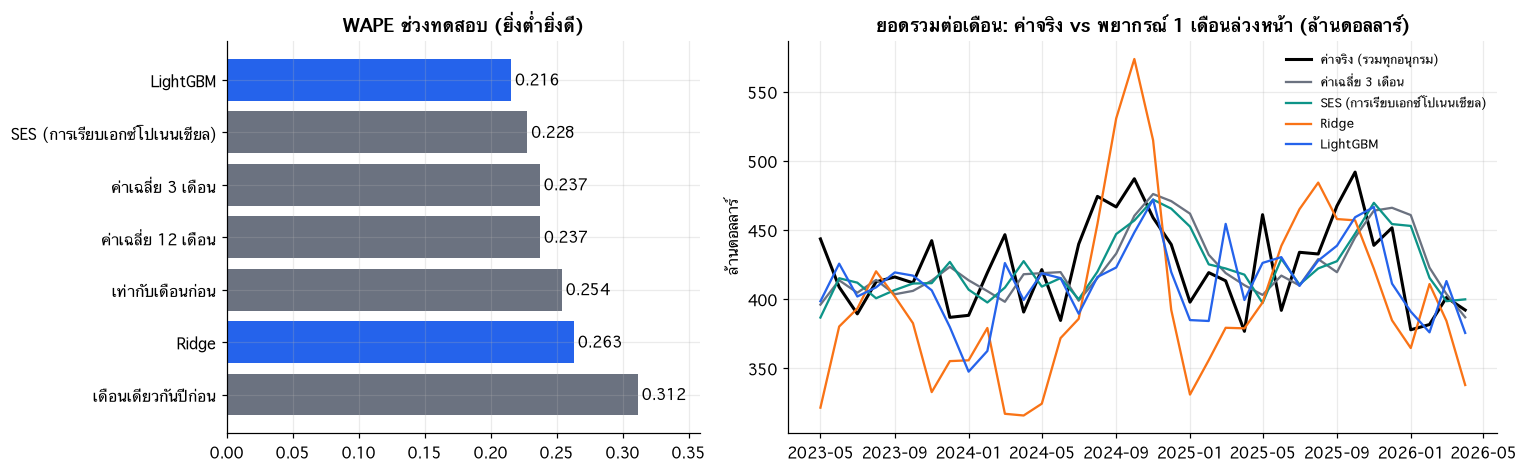

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [1, 1.5]})
r = res.sort_values("WAPE", ascending=False)
cols_ = [C["blue"] if i in ("LightGBM", "Ridge") else C["gray"] for i in r.index]
ax[0].barh(r.index, r.WAPE, color=cols_)
for i, v in enumerate(r.WAPE): ax[0].text(v + .003, i, f"{v:.3f}", va="center")
ax[0].set(title="WAPE ช่วงทดสอบ (ยิ่งต่ำยิ่งดี)", xlim=(0, r.WAPE.max() * 1.15))
tot_a = test_res["LightGBM"].groupby("origin").y.sum() / 1e6; tgt = lambda s_: s_.index + pd.DateOffset(months=H)
ax[1].plot(tgt(tot_a), tot_a.values, color="k", lw=2, label="ค่าจริง (รวมทุกอนุกรม)")
for k, col in [("ค่าเฉลี่ย 3 เดือน", C["gray"]), (PRIMARY_BASE, C["teal"]), ("Ridge", C["orange"]), ("LightGBM", C["blue"])]:
    ax[1].plot(tgt(tot_a), test_res[k].groupby("origin").pred.sum() / 1e6, lw=1.5, color=col, label=k)
ax[1].set(title="ยอดรวมต่อเดือน: ค่าจริง vs พยากรณ์ 1 เดือนล่วงหน้า (ล้านดอลลาร์)", ylabel="ล้านดอลลาร์"); ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

### 📝 อ่านผล: ช่วงทดสอบ (พ.ค. 2023 – เม.ย. 2026)

**11,952 จุดทำนาย (332 อนุกรม × 36 เดือน)**

| โมเดล | WAPE | MAE (USD) | RMSE (USD) | MAPE (y ≥ 50k) | Bias % |
|---|---|---|---|---|---|
| **LightGBM** | **0.216** | **275,091** | **910,435** | **0.434** | −2.7 |
| SES (baseline หลัก) | 0.228 | 290,744 | 958,457 | 0.485 | −0.1 |
| ค่าเฉลี่ย 3 เดือน | 0.237 | 302,884 | 995,327 | 0.497 | −0.0 |
| ค่าเฉลี่ย 12 เดือน | 0.237 | 303,073 | 965,166 | 0.496 | −0.2 |
| เท่ากับเดือนก่อน | 0.254 | 324,158 | 1,089,442 | 0.551 | −0.2 |
| Ridge | 0.263 | 335,873 | 1,144,556 | 0.497 | −5.9 |
| เดือนเดียวกันปีก่อน | 0.312 | 397,678 | 1,248,330 | 0.658 | +0.2 |

- **H1 ได้รับการสนับสนุน แต่ชัยชนะเล็ก:** LightGBM ต่ำกว่า baseline หลัก (SES) **5.4%** และต่ำกว่าค่าเฉลี่ย 3 เดือน **9.2%** ในทุกตัวชี้วัด (WAPE, MAE, RMSE, MAPE) ซึ่งสอดคล้องกับการประเมินจากข้อมูลในส่วน 2.2.1 ที่ว่า *เพดานความแม่นยำต่ำ* จึงไม่ใช่การชนะแบบขาดลอย
- **Ridge ไม่ชนะ baseline:** WAPE 0.263 แย่กว่า SES 15% และทำนายต่ำกว่าจริง 5.9% เส้นในกราฟขวาแกว่งแรงและพลาดช่วงตั้งต้นของช่วงทดสอบมาก → โมเดลเชิงเส้นไม่เหมาะกับข้อมูลที่ความสัมพันธ์ไม่เป็นเส้นตรงนี้
- **เดือนเดียวกันปีก่อนแย่ที่สุด (0.312)** ย้ำว่าข้อมูลไม่มีฤดูกาลที่ใช้ได้
- **LightGBM ทำนายต่ำกว่าจริงเล็กน้อย (−2.7%)** เพราะใช้ L1 (ใกล้มัธยฐาน) ซึ่งต่ำกว่าค่าเฉลี่ยในข้อมูลที่เบ้ขวา
- **กราฟขวา:** ทุกโมเดลเรียบกว่าค่าจริงและ *ตามจุดกลับตัวไม่ทัน* (เช่นจุดสูงสุดเดือน ก.ย.–ต.ค. 2024 และ ก.ย. 2025) เป็นลักษณะของการพยากรณ์ล่วงหน้า 1 เดือนจากข้อมูลที่ผันผวน ไม่มีโมเดลใดทำนายจุดสูง/ต่ำ ได้ตรง

### 4.2.5 ความต่างจริงหรือแค่โชค? (bootstrap ข้ามเดือน)

ถ้ารันโมเดลซ้ำกับเดือนทดสอบชุดอื่น ผลจะต่างจากนี้แค่ไหน — สุ่มเดือนทดสอบ (มีการแทนที่) 10,000 ครั้ง เพื่อหาช่วงความเชื่อมั่น 95% ของส่วนต่าง WAPE

In [68]:
def boot_diff(a, b, B=10000, seed=0):
    """ส่วนต่าง WAPE (a - b) ลบ = a ดีกว่า; สุ่มเดือนด้วยการแทนที่"""
    g = lambda d: d.assign(ae=(d.pred - d.y).abs()).groupby("origin")[["ae", "y"]].sum()
    A, Bm = g(test_res[a]), g(test_res[b]); n = len(A); rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, (B, n))
    wa = A.ae.to_numpy()[idx].sum(1) / A.y.to_numpy()[idx].sum(1); wb = Bm.ae.to_numpy()[idx].sum(1) / Bm.y.to_numpy()[idx].sum(1)
    d = wa - wb; obs = A.ae.sum() / A.y.sum() - Bm.ae.sum() / Bm.y.sum()
    return obs, np.percentile(d, [2.5, 97.5]), (A.ae < Bm.ae).mean(), (d < 0).mean()

cmp = []
for a, b in list(dict.fromkeys([("LightGBM", PRIMARY_BASE), ("LightGBM", "ค่าเฉลี่ย 3 เดือน"), (PRIMARY_BASE, "ค่าเฉลี่ย 3 เดือน"), ("LightGBM", "Ridge"), ("Ridge", PRIMARY_BASE), ("LightGBM", "เท่ากับเดือนก่อน"), ("LightGBM", "เดือนเดียวกันปีก่อน")])):
    obs, ci, win, p = boot_diff(a, b)
    cmp.append((f"{a} − {b}", obs, ci[0], ci[1], f"{win:.0%}", "ใช่" if ci[1] < 0 else ("ไม่" if ci[0] > 0 else "ยังบอกไม่ได้ (ช่วงคร่อม 0)")))
show(pd.DataFrame(cmp, columns=["เปรียบเทียบ (WAPE a − WAPE b)", "ผลต่างที่วัดได้", "ช่วง 95% ล่าง", "ช่วง 95% บน", "% เดือนที่ a ดีกว่า", "a ดีกว่า b อย่างมีนัยสำคัญ?"]))

,เปรียบเทียบ (WAPE a − WAPE b),ผลต่างที่วัดได้,ช่วง 95% ล่าง,ช่วง 95% บน,% เดือนที่ a ดีกว่า,a ดีกว่า b อย่างมีนัยสำคัญ?
0,LightGBM − SES (การเรียบเอกซ์โปเนนเชียล),-0.012,-0.021,-0.005,69%,ใช่
1,LightGBM − ค่าเฉลี่ย 3 เดือน,-0.022,-0.031,-0.014,83%,ใช่
2,SES (การเรียบเอกซ์โปเนนเชียล) − ค่าเฉลี่ย 3 เดือน,-0.010,-0.012,-0.007,89%,ใช่
3,LightGBM − Ridge,-0.048,-0.062,-0.035,92%,ใช่
4,Ridge − SES (การเรียบเอกซ์โปเนนเชียล),0.035,0.020,0.051,19%,ไม่
5,LightGBM − เท่ากับเดือนก่อน,-0.038,-0.048,-0.030,97%,ใช่
6,LightGBM − เดือนเดียวกันปีก่อน,-0.096,-0.112,-0.081,100%,ใช่


### 📝 อ่านผล: ชัยชนะจริงหรือแค่โชค?

| เปรียบเทียบ | ผลต่าง WAPE | ช่วง 95% | a ชนะกี่ % ของเดือน | สรุป |
|---|---|---|---|---|
| **LightGBM − SES** | **−0.012** | [−0.021, −0.005] | 69% | ชนะอย่างมีนัยสำคัญ **แต่เล็ก** |
| LightGBM − ค่าเฉลี่ย 3 เดือน | −0.022 | [−0.031, −0.014] | 83% | ชนะชัดเจน |
| **SES − ค่าเฉลี่ย 3 เดือน** | **−0.010** | [−0.012, −0.007] | 89% | **วิธีสถิติธรรมดาก็ชนะค่าเฉลี่ย 3 เดือนอยู่แล้ว** |
| LightGBM − Ridge | −0.048 | [−0.062, −0.035] | 92% | ชนะชัดเจน |
| Ridge − SES | +0.035 | [+0.020, +0.051] | 19% | Ridge แย่กว่า SES |

- **ประเด็นที่ควรพูดตรง ๆ:** เมื่อเทียบกับ *ค่าเฉลี่ย 3 เดือน* LightGBM ชนะ 0.022 แต่ **ครึ่งหนึ่งของส่วนต่างนั้น (0.010) ได้มาจากการใช้ SES ที่ง่ายกว่าและเสียค่าใช้จ่ายคำนวณแทบเป็นศูนย์** ส่วนที่เป็นของ ML จริง ๆ คือ **0.012 (ราว 5%)** เหนือ SES
- ช่วงความเชื่อมั่นของ LightGBM − SES **ไม่คร่อม 0** (บนสุด −0.005) แต่ใกล้ศูนย์ และชนะ 69% ของเดือนเท่านั้น (31% ของเดือน SES ดีกว่า)
- **ข้อควรระวังของวิธีนี้:** การสุ่มเดือนแบบแทนที่ถือว่าแต่ละเดือนเป็นอิสระต่อกัน แต่ยอดส่งออกรายเดือนมีความเชื่อมโยงกันบางส่วน ช่วงความเชื่อมั่นจริงจึงอาจกว้างกว่าที่แสดง และการทดสอบมีหน้าต่างเวลาเดียว (36 เดือน)

### 4.2.6 โมเดลช่วยตรงไหน? (แยกตามกลุ่มตลาด · กลุ่มสินค้า · ขนาด · ช่วงเวลา)

In [69]:
cl_map = rd(PREP / "clusters_w2.csv").set_index("iso2").cluster_name.to_dict()
TD = test_res["LightGBM"][["origin", "hs4", "iso2", "y"]].copy()
for k, d in test_res.items(): TD[k] = d.pred.to_numpy()
TD["กลุ่มตลาด"] = TD.iso2.map(cl_map).fillna("นอกกลุ่ม").str.split().str[0]
size0 = PN[PN.origin == pd.Timestamp(FIRST_ORIGIN)].set_index(["hs4", "iso2"]).mean12.apply(np.expm1)         # ขนาดอนุกรม ณ ก่อนช่วงทดสอบ (ไม่รั่ว)
size0.index = pd.MultiIndex.from_arrays([size0.index.get_level_values(0).astype(str), size0.index.get_level_values(1)])
TD["ขนาด"] = pd.qcut(pd.Series(list(zip(TD.hs4, TD.iso2))).map(size0.to_dict()).to_numpy(), 3, labels=["เล็ก", "กลาง", "ใหญ่"])
TD["sid"] = TD.hs4 + "_" + TD.iso2
TD["ปีทดสอบ"] = np.where(TD.origin < "2024-04-01", "พ.ค.2023–เม.ย.2024", np.where(TD.origin < "2025-04-01", "พ.ค.2024–เม.ย.2025", "พ.ค.2025–เม.ย.2026"))
MODELS = list(dict.fromkeys([PRIMARY_BASE, "ค่าเฉลี่ย 3 เดือน", "เท่ากับเดือนก่อน", "เดือนเดียวกันปีก่อน", "Ridge", "LightGBM"]))

def seg(key):
    t = TD.groupby(key).apply(lambda g: pd.Series({**{m: (g[m] - g.y).abs().sum() / g.y.sum() for m in MODELS}, "จำนวนอนุกรม": g.sid.nunique(), "% ของมูลค่า": g.y.sum() / TD.y.sum() * 100}))
    t["LightGBM เทียบ baseline หลัก"] = t["LightGBM"] / t[PRIMARY_BASE] - 1
    return t
for key, t_ in [("กลุ่มตลาด", "กลุ่มตลาด (A–D จากส่วน 4.1)"), ("hs4", "กลุ่มสินค้า HS4"), ("ขนาด", "ขนาดอนุกรม (แบ่ง 3 ระดับ)"), ("ปีทดสอบ", "ช่วงเวลา")]:
    print(f"== WAPE แยกตาม{t_}"); show(seg(key))

== WAPE แยกตามกลุ่มตลาด (A–D จากส่วน 4.1)


,SES (การเรียบเอกซ์โปเนนเชียล),ค่าเฉลี่ย 3 เดือน,เท่ากับเดือนก่อน,เดือนเดียวกันปีก่อน,Ridge,LightGBM,จำนวนอนุกรม,% ของมูลค่า,LightGBM เทียบ baseline หลัก
กลุ่มตลาด,,,,,,,,,
A,0.205,0.214,0.228,0.279,0.239,0.194,181.000,92.498,-0.054
B,0.443,0.450,0.499,0.679,0.488,0.419,66.000,4.570,-0.055
C,0.581,0.604,0.656,0.742,0.645,0.554,68.000,2.525,-0.045
D,0.748,0.772,0.896,0.854,0.919,0.697,12.000,0.342,-0.068
นอกกลุ่ม,1.099,1.052,1.255,1.809,0.995,1.045,5.000,0.065,-0.049


== WAPE แยกตามกลุ่มสินค้า HS4


,SES (การเรียบเอกซ์โปเนนเชียล),ค่าเฉลี่ย 3 เดือน,เท่ากับเดือนก่อน,เดือนเดียวกันปีก่อน,Ridge,LightGBM,จำนวนอนุกรม,% ของมูลค่า,LightGBM เทียบ baseline หลัก
hs4,,,,,,,,,
0301,0.253,0.263,0.279,0.321,0.306,0.252,53.000,0.523,-0.003
0302,0.183,0.196,0.177,0.479,0.416,0.214,7.000,0.741,0.173
0303,0.395,0.411,0.445,0.543,0.429,0.372,23.000,2.433,-0.057
0304,0.198,0.198,0.238,0.251,0.301,0.197,19.000,3.630,-0.003
0305,0.450,0.439,0.523,0.554,0.465,0.422,19.000,0.848,-0.060
0306,0.220,0.238,0.223,0.314,0.241,0.215,44.000,13.304,-0.021
0307,0.253,0.264,0.280,0.354,0.347,0.241,32.000,6.439,-0.049
0308,0.422,0.449,0.423,0.656,0.569,0.412,6.000,0.348,-0.023
1604,0.222,0.229,0.253,0.309,0.254,0.211,101.000,59.676,-0.048


== WAPE แยกตามขนาดอนุกรม (แบ่ง 3 ระดับ)


,SES (การเรียบเอกซ์โปเนนเชียล),ค่าเฉลี่ย 3 เดือน,เท่ากับเดือนก่อน,เดือนเดียวกันปีก่อน,Ridge,LightGBM,จำนวนอนุกรม,% ของมูลค่า,LightGBM เทียบ baseline หลัก
ขนาด,,,,,,,,,
เล็ก,0.680,0.686,0.791,0.879,0.688,0.638,111.000,0.530,-0.061
กลาง,0.568,0.575,0.661,0.753,0.623,0.534,111.000,4.144,-0.060
ใหญ่,0.211,0.220,0.233,0.289,0.245,0.199,110.000,95.326,-0.053


== WAPE แยกตามช่วงเวลา


,SES (การเรียบเอกซ์โปเนนเชียล),ค่าเฉลี่ย 3 เดือน,เท่ากับเดือนก่อน,เดือนเดียวกันปีก่อน,Ridge,LightGBM,จำนวนอนุกรม,% ของมูลค่า,LightGBM เทียบ baseline หลัก
ปีทดสอบ,,,,,,,,,
พ.ค.2023–เม.ย.2024,0.230,0.240,0.262,0.331,0.271,0.224,332.000,32.482,-0.028
พ.ค.2024–เม.ย.2025,0.223,0.232,0.244,0.305,0.264,0.214,332.000,33.946,-0.039
พ.ค.2025–เม.ย.2026,0.231,0.240,0.256,0.300,0.254,0.209,332.000,33.572,-0.093


,SES (การเรียบเอกซ์โปเนนเชียล),ค่าเฉลี่ย 3 เดือน,เท่ากับเดือนก่อน,เดือนเดียวกันปีก่อน,Ridge,LightGBM
อนุกรม (ประเทศ × HS4),0.228,0.237,0.254,0.312,0.263,0.216
ระดับประเทศ,0.180,0.187,0.201,0.242,0.213,0.169
ระดับกลุ่มสินค้า,0.088,0.089,0.100,0.113,0.136,0.081
ยอดรวมทั้งหมด,0.066,0.066,0.074,0.070,0.109,0.059


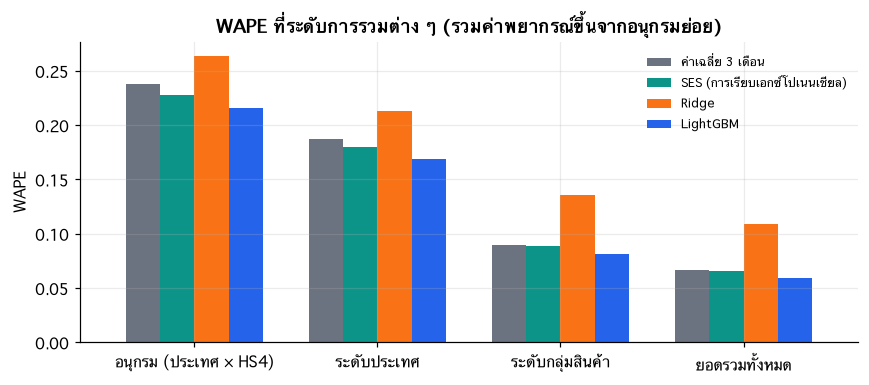

In [70]:
# ผลรวมระดับอื่น (bottom-up): รวมค่าพยากรณ์ของอนุกรมย่อยเป็นระดับประเทศ / กลุ่มสินค้า / ยอดรวม
def agg_wape(keys):
    t = TD.groupby(["origin"] + keys)[["y"] + MODELS].sum().reset_index()
    return pd.Series({m: (t[m] - t.y).abs().sum() / t.y.sum() for m in MODELS})
lvl = pd.DataFrame({"อนุกรม (ประเทศ × HS4)": pd.Series({m: (TD[m] - TD.y).abs().sum() / TD.y.sum() for m in MODELS}), "ระดับประเทศ": agg_wape(["iso2"]), "ระดับกลุ่มสินค้า": agg_wape(["hs4"]), "ยอดรวมทั้งหมด": agg_wape([])}).T
show(lvl)
fig, ax = plt.subplots(figsize=(8, 3.6))
lvl[["ค่าเฉลี่ย 3 เดือน", PRIMARY_BASE, "Ridge", "LightGBM"]].plot.bar(ax=ax, color=[C["gray"], C["teal"], C["orange"], C["blue"]], rot=0, width=.75)
ax.set(title="WAPE ที่ระดับการรวมต่าง ๆ (รวมค่าพยากรณ์ขึ้นจากอนุกรมย่อย)", ylabel="WAPE"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

### 📝 อ่านผล: โมเดลช่วยตรงไหน และเชื่อถือได้แค่ไหน

**1) แยกตามกลุ่มตลาด (จากส่วน 4.1)** — LightGBM ดีกว่า SES ในทุกกลุ่ม แต่ *ความแม่นยำต่างกันมาก*:
| กลุ่ม | % ของมูลค่า | WAPE LightGBM | WAPE SES | เทียบ SES |
|---|---|---|---|---|
| **A ตลาดหลัก** | 92.5% | **0.194** | 0.205 | −5.4% |
| B ตลาดปลากระป๋องราคาต่ำที่หดตัว | 4.6% | 0.419 | 0.443 | −5.5% |
| C ตลาดโตเร็ว ราคาสูง | 2.5% | 0.554 | 0.581 | −4.5% |
| D ตลาดเล็ก ผันผวน | 0.3% | 0.697 | 0.748 | −6.8% |

→ **ข้อสรุปสำคัญสำหรับผู้ใช้:** การพยากรณ์ 1 เดือนล่วงหน้า *เชื่อถือได้พอใช้เฉพาะตลาดกลุ่ม A* (ผิดพลาดราว 19% ของมูลค่า) ส่วนตลาดกลุ่มอื่นผิดพลาด 42–70% ซึ่งแทบใช้ตัดสินใจรายตลาดไม่ได้ ML ช่วยลดความผิดพลาดได้ราว 5% ในทุกกลุ่มเท่า ๆ กัน (ผลลัพธ์ของ Clustering ใช้อธิบายความน่าเชื่อถือได้ตรงตามที่วางแผนไว้)

**2) แยกตามขนาดอนุกรม:** ใหญ่ (95% ของมูลค่า) 0.199 vs SES 0.211 · กลาง 0.534 vs 0.568 · เล็ก 0.638 vs 0.680 — ความผิดพลาดของอนุกรมเล็กสูงกว่าอนุกรมใหญ่ราว 3 เท่า

**3) แยกตามกลุ่มสินค้า:** LightGBM ดีกว่าหรือเท่ากับ SES ใน 9 จาก 10 กลุ่ม กลุ่มใหญ่สุด 1604 (59.7% ของมูลค่า) ดีขึ้น 4.8% (0.211 vs 0.222), **1605 ดีขึ้นมากสุด 15% (0.178 vs 0.210)**, 0301 และ 0304 เท่ากัน (±0.3%) และ **0302 แย่กว่า SES 17% (0.214 vs 0.183)** แต่กลุ่มนี้มีเพียง 7 อนุกรม คิดเป็น 0.7% ของมูลค่า ผลจึงไม่นิ่ง

**4) แยกตามช่วงเวลา:** ข้อได้เปรียบ **ไม่คงที่:** เทียบ SES ลดได้ 2.8% (พ.ค. 2023–เม.ย. 2024), 3.9% (2024–2025) และ 9.3% (2025–2026) — สองปีแรกต่างกันไม่ถึง 0.01 ดังนั้นความสามารถที่เห็นส่วนหนึ่งมาจากปีสุดท้าย

**5) ระดับการรวม** (รวมค่าพยากรณ์ขึ้นจากอนุกรมย่อย): ความผิดพลาดลดเร็วมาก
| ระดับ | LightGBM | SES |
|---|---|---|
| อนุกรม (ประเทศ × HS4) | 0.216 | 0.228 |
| ประเทศ | 0.169 | 0.180 |
| กลุ่มสินค้า | 0.081 | 0.088 |
| **ยอดรวมทั้งหมด** | **0.059** | 0.066 |

→ **พยากรณ์ยอดส่งออกรวมรายเดือนได้ผิดพลาดเฉลี่ยราว 6%** (ใช้งานได้จริง) แต่ที่ระดับตลาด-สินค้าแต่ละตัวผิดพลาดราว 22% การรวมค่าพยากรณ์ช่วยลดความผิดพลาดเพราะความคลาดเคลื่อนของแต่ละอนุกรมหักล้างกันบางส่วน Ridge แย่ที่สุดที่ระดับรวม (0.136 และ 0.109)

### 4.2.7 ตัวแปรไหนสำคัญ? ข้อมูลภายนอกช่วยไหม?

**(ก) ความสำคัญของตัวแปร** ในโมเดลสุดท้าย (เทรนด้วยข้อมูลทั้งหมดที่รู้ผล): gain ของ LightGBM และ SHAP (ค่าสัมบูรณ์เฉลี่ยของการมีส่วนต่อการทำนาย) ซึ่งคำนวณด้วย `pred_contrib` ของ LightGBM

**(ข) ทดสอบถอดกลุ่มตัวแปร (ablation แบบสะสม)** เพิ่มกลุ่มตัวแปรทีละกลุ่มแล้วดู WAPE ช่วงทดสอบ — *เป็นการวิเคราะห์เพื่อทำความเข้าใจ ไม่ได้ใช้เลือกโมเดล* (โมเดลสุดท้ายถูกกำหนดจากช่วงตรวจสอบแล้ว)

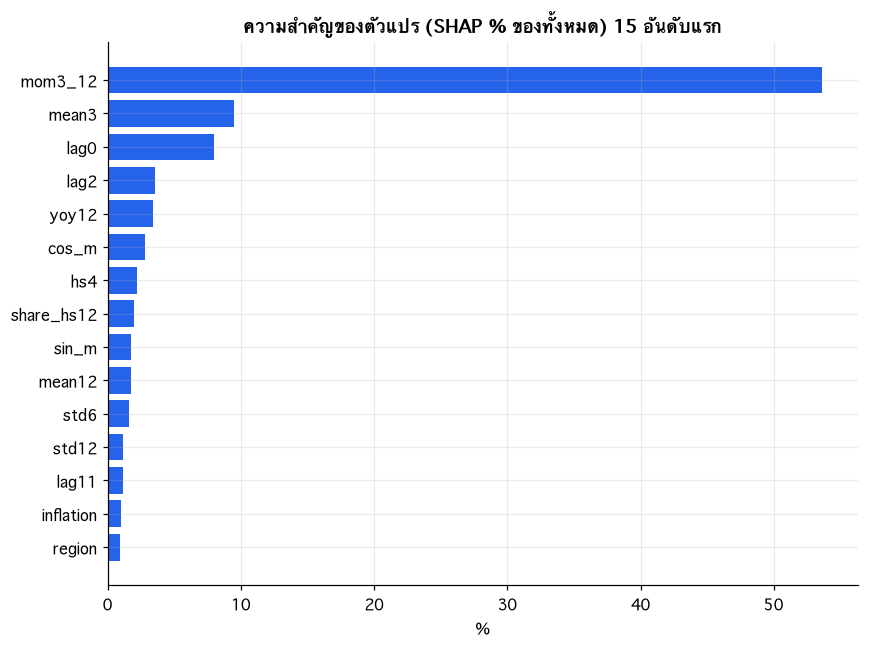

,gain %,SHAP %
mom3_12,18.039,53.645
mean3,1.247,9.490
lag0,9.901,7.956
lag2,5.527,3.542
yoy12,2.832,3.417
cos_m,4.865,2.786
hs4,2.115,2.198
share_hs12,3.073,1.981
sin_m,3.194,1.773
mean12,2.957,1.772


In [71]:
last_T = pd.Timestamp(TEST_ORIG[-1])
tr_f = PN[(PN.origin + pd.DateOffset(months=H) <= last_T) & PN[YC].notna()]
cols_all = NUMF + ["origin_month"] + CATF
w_f = np.sqrt(np.expm1(tr_f.mean12) + 1)
mdl = lgb.LGBMRegressor(objective=BEST_KW["obj"], verbose=-1, random_state=0, n_jobs=4, **BEST_P).fit(tr_f[cols_all], np.log1p(tr_f[YC]) - tr_f.mean12, sample_weight=w_f)
rows_eval = PN[(PN.origin >= pd.Timestamp("2025-04-01")) & (PN.origin <= last_T)]
contrib = mdl.booster_.predict(rows_eval[cols_all], pred_contrib=True)[:, :-1]
imp = pd.DataFrame({"gain %": mdl.booster_.feature_importance("gain") / mdl.booster_.feature_importance("gain").sum() * 100,
                    "SHAP เฉลี่ย |ค่า|": np.abs(contrib).mean(axis=0)}, index=cols_all)
imp["SHAP %"] = imp["SHAP เฉลี่ย |ค่า|"] / imp["SHAP เฉลี่ย |ค่า|"].sum() * 100
imp = imp.sort_values("SHAP %", ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
top15 = imp.head(15).iloc[::-1]; ax.barh(top15.index, top15["SHAP %"], color=C["blue"]); ax.set(title="ความสำคัญของตัวแปร (SHAP % ของทั้งหมด) 15 อันดับแรก", xlabel="%")
plt.tight_layout(); plt.show()
show(imp.head(12)[["gain %", "SHAP %"]])

,กลุ่มตัวแปรที่ใช้ (สะสม),จำนวนตัวแปร,WAPE ช่วงทดสอบ,เปลี่ยนจากแถวก่อน,เทียบ baseline หลัก
0,"1 อนุกรมเวลาอย่างเดียว (lag, ค่าเฉลี่ย, ความผันผวน, YoY)",12,0.217,NaN,-0.048
1,"+ ความต่อเนื่องของตลาด (active12, since_last)",14,0.218,0.001,-0.045
2,+ ราคาต่อกก. (uv12),15,0.218,0.000,-0.044
3,"+ บริบทกลุ่มสินค้า/ประเทศ (hs_mean3, ctry_mean3, share_*, hs4)",20,0.217,-0.001,-0.047
4,+ ปฏิทิน (เดือน),23,0.214,-0.003,-0.060
5,"+ ค่าเงิน (thb_chg3, ccy_chg3)",25,0.218,0.003,-0.045
6,"+ เศรษฐกิจประเทศ (World Bank, region, income) = ทั้งหมด",31,0.214,-0.003,-0.059


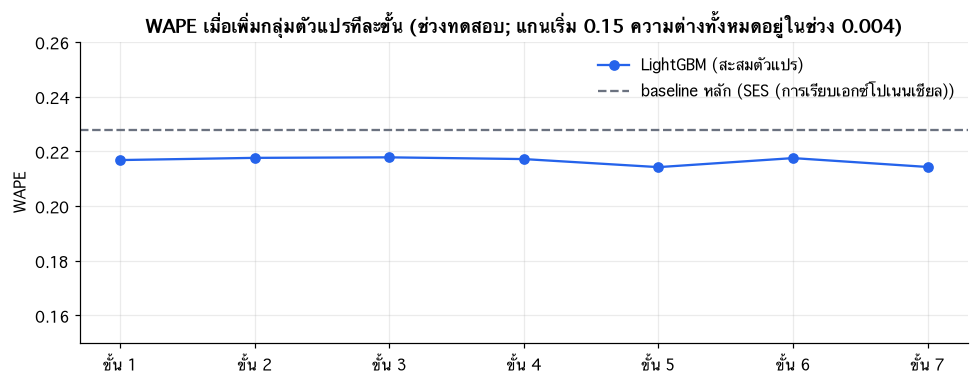

In [72]:
G = [("1 อนุกรมเวลาอย่างเดียว (lag, ค่าเฉลี่ย, ความผันผวน, YoY)", ["lag0", "lag1", "lag2", "lag5", "lag11", "mean3", "mean6", "mean12", "std6", "std12", "mom3_12", "yoy12"]),
     ("+ ความต่อเนื่องของตลาด (active12, since_last)", ["active12", "since_last"]),
     ("+ ราคาต่อกก. (uv12)", ["uv12"]),
     ("+ บริบทกลุ่มสินค้า/ประเทศ (hs_mean3, ctry_mean3, share_*, hs4)", ["hs_mean3", "ctry_mean3", "share_hs12", "share_ctry12", "hs4"]),
     ("+ ปฏิทิน (เดือน)", ["origin_month", "sin_m", "cos_m"]),
     ("+ ค่าเงิน (thb_chg3, ccy_chg3)", ["thb_chg3", "ccy_chg3"]),
     ("+ เศรษฐกิจประเทศ (World Bank, region, income) = ทั้งหมด", ["gdppc_log", "pop_log", "gdp_growth", "inflation", "region", "income"])]
ABL_CACHE = PREP / "ablation_h1.csv"
if RETUNE or not ABL_CACHE.exists():
    cum, rows = [], []
    for name, cs in G:
        cum += cs
        d = rolling_forecast(lgbm_fn(BEST_P, **BEST_KW, cols=list(cum)), TEST_ORIG); rows.append((name, len(cum), metrics(d).WAPE))
    pd.DataFrame(rows, columns=["กลุ่มตัวแปรที่ใช้ (สะสม)", "จำนวนตัวแปร", "WAPE ช่วงทดสอบ"]).to_csv(ABL_CACHE, index=False, encoding="utf-8-sig")
abl = rd(ABL_CACHE)
abl["เปลี่ยนจากแถวก่อน"] = abl["WAPE ช่วงทดสอบ"].diff()
abl["เทียบ baseline หลัก"] = abl["WAPE ช่วงทดสอบ"] / res.loc[PRIMARY_BASE, "WAPE"] - 1
show(abl)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(range(len(abl)), abl["WAPE ช่วงทดสอบ"], marker="o", color=C["blue"], label="LightGBM (สะสมตัวแปร)")
ax.axhline(res.loc[PRIMARY_BASE, "WAPE"], color=C["gray"], ls="--", label=f"baseline หลัก ({PRIMARY_BASE})")
ax.set_xticks(range(len(abl))); ax.set_xticklabels([f"ขั้น {i + 1}" for i in range(len(abl))]); ax.set(title="WAPE เมื่อเพิ่มกลุ่มตัวแปรทีละขั้น (ช่วงทดสอบ; แกนเริ่ม 0.15 ความต่างทั้งหมดอยู่ในช่วง 0.004)", ylabel="WAPE", ylim=(0.15, 0.26)); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### 📝 อ่านผล: ตัวแปรไหนสำคัญ ข้อมูลภายนอกช่วยไหม

**ความสำคัญของตัวแปร (SHAP):**
- **`mom3_12` (ค่าเฉลี่ย 3 เดือนเทียบ 12 เดือน) = 54% ของทั้งหมด** ตามด้วย `mean3` (9.5%), `lag0` (8.0%), `lag2` (3.5%), `yoy12` (3.4%) ปฏิทิน (sin/cos เดือน) รวมราว 4.6% และ `hs4` 2.2%
- แปลว่าโมเดลส่วนใหญ่ตัดสินใจว่า **"จะขยับจากค่าเฉลี่ย 12 เดือน ไปทางค่าเฉลี่ยล่าสุดมากแค่ไหน"** — เป็นกลไกของการเรียบข้อมูลแบบปรับตัว (adaptive smoothing) ซึ่งสอดคล้องกับการที่ SES ทำได้ดีเกือบเท่ากัน

**ทดสอบถอดกลุ่มตัวแปร (WAPE ช่วงทดสอบ):**
| ขั้น | กลุ่มที่เพิ่ม | WAPE | เปลี่ยน |
|---|---|---|---|
| 1 | อนุกรมเวลาอย่างเดียว (12 ตัวแปร) | **0.217** | — |
| 2 | + ความต่อเนื่องของตลาด | 0.218 | +0.001 |
| 3 | + ราคาต่อกก. | 0.218 | 0.000 |
| 4 | + บริบทกลุ่มสินค้า/ประเทศ | 0.217 | −0.001 |
| 5 | + ปฏิทิน | 0.214 | −0.003 |
| 6 | + **ค่าเงิน** | 0.218 | **+0.003** |
| 7 | + **เศรษฐกิจประเทศ (World Bank)** = ทั้งหมด | 0.214 | −0.003 |

- **กำไรทั้งหมดมาจากตัวแปรอนุกรมเวลาล้วน ๆ** (ขั้น 1: 0.217 ต่ำกว่า SES 0.228 อยู่แล้ว) การเพิ่มกลุ่มอื่น ๆ เปลี่ยน WAPE ไม่เกิน ±0.003
- **±0.003 อยู่ในระดับสัญญาณรบกวน:** ชุดตัวแปรเต็มเดียวกัน ได้ 0.216 ในการรันหลัก แต่ 0.214 ในการทดสอบนี้ (ต่างกันเพียงลำดับคอลัมน์ ซึ่งเปลี่ยนการสุ่มตัวแปรของโมเดล) จึงถือว่ากลุ่มตัวแปรใด ๆ หลังขั้น 1 **ไม่ได้ช่วยอย่างยืนยันได้**
- **ข้อมูลภายนอกที่เก็บมา (ค่าเงิน, GDP, ประชากร, เงินเฟ้อ, ภูมิภาค/รายได้) ไม่ช่วยทำนาย 1 เดือนล่วงหน้า** (ค่าเงินแย่ลงเล็กน้อย +0.003) สอดคล้องกับที่เห็นในส่วน 2.7 ว่าค่าเงินกับยอดส่งออกแทบไม่สัมพันธ์ (corr 0.06) เป็นข้อค้นพบที่ควรรายงานตรง ๆ: สมมติฐานใน README ว่าข้อมูลภายนอกจะเพิ่มมิติให้โมเดล *ไม่ได้รับการสนับสนุน* ที่ระยะนี้ด้วยข้อมูลที่มี

### 4.2.8 สรุปรอบที่ 1

### สรุปรอบที่ 1: พยากรณ์ล่วงหน้า 1 เดือน

**ตอบ H1 (LightGBM ชนะ baseline หลัก):** ✅ **ชนะ แต่เล็ก** — WAPE 0.216 เทียบ SES 0.228 (−5.4%) และค่าเฉลี่ย 3 เดือน 0.237 (−9.2%) ช่วงความเชื่อมั่น 95% ของส่วนต่างเทียบ SES ไม่คร่อมศูนย์ ([−0.021, −0.005]) แต่ชนะเพียง 69% ของเดือน

**ข้อค้นพบหลักสำหรับรายงาน**
1. **การพยากรณ์รายเดือนระดับตลาด-สินค้ามีเพดานความแม่นยำต่ำ** (ผิดพลาด ~22% ของมูลค่า) ต่างจากยอดรวมทั้งประเทศที่ผิดพลาดเพียง ~6% ผลนี้ตรงกับที่ข้อมูลบอกไว้ตั้งแต่ส่วน 2.2.1 (ไม่มีฤดูกาล, ผันผวนสูง)
2. **ความน่าเชื่อถือขึ้นกับตลาด:** กลุ่ม A (ตลาดหลัก 92% ของมูลค่า) ผิดพลาด 19% ส่วนกลุ่มตลาดรองถึงตลาดเล็ก 42–70%
3. **ส่วนใหญ่ของกำไรเหนือ baseline ง่าย ๆ มาจาก "การเรียบข้อมูลที่ดีกว่า"** (SES ซึ่งง่ายมากเก็บไปครึ่งหนึ่ง) ส่วนที่เป็นของ ML จริงคือราว 5% เหนือ SES
4. **ข้อมูลภายนอกไม่ช่วย** (ค่าเงิน เศรษฐกิจประเทศ) ที่ระยะ 1 เดือน และตัวแปรอนุกรมเวลาอย่างเดียวให้ผลเท่ากับตัวแปรทั้งหมด
5. **Ridge (เชิงเส้น) ไม่ชนะ baseline** และ **เดือนเดียวกันปีก่อนแย่ที่สุดเสมอ** (ไม่มีฤดูกาลที่ใช้ได้)

**ข้อจำกัดที่ต้องบอก**
- เพิ่ม baseline SES **หลังเห็นผลทดสอบรอบแรก** (เปิดเผยแล้วในส่วน 4.2 และเลือก α จากช่วงตรวจสอบเท่านั้น) — การเปิดเผยนี้ควรอยู่ในรายงานด้วย
- ทดสอบหน้าต่างเดียว (36 เดือน) ข้อได้เปรียบไม่คงที่ข้ามปี (−2.8%, −3.9%, −9.3%) และ bootstrap ถือเดือนเป็นอิสระต่อกัน
- ทำนายต่ำกว่าจริง 2.7% และยังไม่มีช่วงความไม่แน่นอนของการพยากรณ์ (prediction interval)
- ระยะ 1 เดือนเท่านั้น

**ถัดไป (รอบที่ 2):** ระยะ 3 และ 6 เดือน, ช่วงความไม่แน่นอน (LightGBM แบบ quantile), และถ้ามีเวลา SARIMA/ETS บนอนุกรมใหญ่ — แล้วจึงสรุปส่วน Evaluation

---
## 4.3 พยากรณ์ — รอบที่ 2: ระยะ 3 และ 6 เดือน · ARIMA/SARIMA · ช่วงความไม่แน่นอน

**สิ่งที่เพิ่มจากรอบที่ 1 และโปรโตคอล** (ใช้แบบเดียวกับ 4.2: ปรับค่าเฉพาะบนช่วงตรวจสอบ 2019–2022, ทดสอบ พ.ค. 2023 – เม.ย. 2026 รันครั้งเดียว):

| หัวข้อ | วิธีการ |
|---|---|
| **ระยะ 3 และ 6 เดือน** | โมเดลเดิม (baseline, SES, Ridge, LightGBM) แต่ target = มูลค่าเดือน t+3 / t+6 · เลือก baseline หลัก, α ของ SES และรูปแบบการเทรนของ LightGBM **แยกต่อระยะ** จากช่วงตรวจสอบ · จำนวน origin ทดสอบ 34 และ 31 จุด |
| **ARIMA และ SARIMA** | ARIMA(1,1,1) และ SARIMA(1,1,1)(0,1,1)₁₂ บน log(1+มูลค่า) เทรนใหม่ทุก origin ด้วยข้อมูลตั้งแต่ ม.ค. 2015 · **ไม่ได้ปรับ order** (กำหนดล่วงหน้า) · ทำเฉพาะ **100 อนุกรมที่ใหญ่สุด** (เลือกจากขนาด ณ ก่อนช่วงทดสอบ) เพราะเป็นโมเดลรายอนุกรม · เทียบกับโมเดลอื่น *บนอนุกรมชุดเดียวกัน* |
| **ช่วงความไม่แน่นอน 80%** | LightGBM แบบ quantile (10% และ 90%) แล้ว **ปรับให้ครอบคลุมจริงด้วย conformal (CQR)** โดยใช้ช่วงตรวจสอบเป็นชุดปรับเทียบ · วัด coverage (ควรอยู่ใกล้ 80%) และความกว้าง · เทียบกับช่วงง่าย ๆ จากความคลาดเคลื่อนย้อนหลังของ SES |

**ตัวชี้วัดของช่วง:** coverage = สัดส่วนค่าจริงที่อยู่ในช่วง (เป้า 80%), coverage ถ่วงมูลค่า (ตลาดใหญ่มีน้ำหนัก), ความกว้างสัมพัทธ์ = มัธยฐานของ (ขอบบน − ขอบล่าง) ÷ ค่าพยากรณ์

### 4.3.1 เตรียมฟังก์ชันที่รองรับหลายระยะ

In [73]:
import os, tempfile
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

FAST = os.environ.get("NB_FAST") == "1"                # โหมดตรวจโค้ดเร็ว (ใช้แค่ 3 origin) — ผู้ใช้ทั่วไปไม่ต้องตั้ง
CACHE = Path(tempfile.mkdtemp()) if FAST else PREP     # โหมดเร็วไม่เขียนทับ cache จริง
HZ = (1, 3, 6)

def orig_sets(h):
    val = [o for o in ORIG if pd.Timestamp("2019-04-01") <= o <= pd.Timestamp("2022-03-01") and o + pd.DateOffset(months=h) <= LAST_MONTH]
    test = [o for o in ORIG if o >= pd.Timestamp("2023-04-01") and o + pd.DateOffset(months=h) <= LAST_MONTH]
    return (val[:3], test[:3]) if FAST else (val, test)
VAL_O, TEST_O = {h: orig_sets(h)[0] for h in HZ}, {h: orig_sets(h)[1] for h in HZ}

def base_cols(h): return {"เท่ากับเดือนก่อน": "base_naive", "ค่าเฉลี่ย 3 เดือน": "base_ma3", "ค่าเฉลี่ย 12 เดือน": "base_ma12", "เดือนเดียวกันปีก่อน": f"base_snaive{h}"}

def lgbm_h(h, params, delta=True, weight="sqrt", obj="l1", cols=None, alpha=None):
    cols = cols or (NUMF + ["origin_month"] + CATF); yc = f"y{h}"
    def f(tr, te):
        yt = np.log1p(tr[yc]) - (tr.mean12 if delta else 0)
        w = {"sqrt": np.sqrt(np.expm1(tr.mean12) + 1), "lin": np.expm1(tr.mean12) + 1}.get(weight)
        kw = dict(objective=obj, verbose=-1, random_state=0, n_jobs=4, **params)
        if alpha is not None: kw["alpha"] = alpha
        m = lgb.LGBMRegressor(**kw).fit(tr[cols], yt, sample_weight=w)
        return np.expm1(m.predict(te[cols]) + (te.mean12.to_numpy() if delta else 0))
    return f

def ridge_h(h, alpha):
    yc = f"y{h}"
    def design(df, cols=None):
        d = pd.concat([df[NUMF + ["origin_month"]].reset_index(drop=True), pd.get_dummies(df.hs4.astype(str), prefix="hs").reset_index(drop=True)], axis=1)
        return d if cols is None else d.reindex(columns=cols, fill_value=0)
    def f(tr, te):
        Xtr = design(tr); Xte = design(te, Xtr.columns)
        imp = SimpleImputer(strategy="median").fit(Xtr); sc = StandardScaler().fit(imp.transform(Xtr))
        m = Ridge(alpha=alpha).fit(sc.transform(imp.transform(Xtr)), np.log1p(tr[yc]) - tr.mean12)
        return np.expm1(m.predict(sc.transform(imp.transform(Xte))) + te.mean12.to_numpy())
    return f
print("ระยะพยากรณ์ที่ทำ:", {h: f"origin ตรวจสอบ {len(VAL_O[h])} / ทดสอบ {len(TEST_O[h])}" for h in HZ}, "| โหมดเร็ว" if FAST else "")

ระยะพยากรณ์ที่ทำ: {1: 'origin ตรวจสอบ 36 / ทดสอบ 36', 3: 'origin ตรวจสอบ 36 / ทดสอบ 34', 6: 'origin ตรวจสอบ 36 / ทดสอบ 31'} 


### 4.3.2 ช่วงตรวจสอบ: เลือก baseline หลัก, α ของ SES, และรูปแบบการเทรนของ LightGBM *ต่อระยะ*

In [74]:
VARS = {"L1 · สัดส่วน · ถ่วง √ขนาด (ค่าจากระยะ 1)": dict(delta=True, weight="sqrt", obj="l1"),
        "L2 · สัดส่วน · ถ่วง √ขนาด": dict(delta=True, weight="sqrt", obj="regression"),
        "L1 · สัดส่วน · ไม่ถ่วง": dict(delta=True, weight=None, obj="l1")}
T36 = CACHE / "tuning_h3_h6.csv"
if RETUNE or not T36.exists():
    rows = [(h, v, metrics(rolling_forecast(lgbm_h(h, BEST_P, **kw), VAL_O[h], h)).WAPE) for h in (3, 6) for v, kw in VARS.items()]
    pd.DataFrame(rows, columns=["h", "รูปแบบ", "WAPE ช่วงตรวจสอบ"]).to_csv(T36, index=False, encoding="utf-8-sig")
t36 = rd(T36)
PB, SES_A, BEST_KW_H, val_tab = {}, {}, {1: BEST_KW}, {}
for h in HZ:
    bl = {k: metrics(rolling_forecast(baseline_fn(c), VAL_O[h], h)).WAPE for k, c in base_cols(h).items()}
    sa = {a: metrics(rolling_forecast(ses_fn(a), VAL_O[h], h)).WAPE for a in (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7)}
    SES_A[h] = min(sa, key=sa.get); bl[SES_NAME] = sa[SES_A[h]]
    if h == 1: bl["LightGBM"] = float(tune[tune.กลุ่ม == "พารามิเตอร์"]["WAPE ช่วงตรวจสอบ"].min())
    else:
        sub = t36[t36.h == h].sort_values("WAPE ช่วงตรวจสอบ"); BEST_KW_H[h] = VARS[sub.iloc[0].รูปแบบ]; bl["LightGBM"] = float(sub.iloc[0]["WAPE ช่วงตรวจสอบ"])
    PB[h] = min((k for k in bl if k != "LightGBM"), key=bl.get)
    val_tab[h] = pd.Series(bl)
vt = pd.DataFrame(val_tab); vt.columns = [f"ระยะ {h} เดือน" for h in HZ]
show(vt)
print("baseline หลักต่อระยะ:", PB, "| α ของ SES:", SES_A)
if not FAST: show(t36.pivot(index="รูปแบบ", columns="h", values="WAPE ช่วงตรวจสอบ"))

,ระยะ 1 เดือน,ระยะ 3 เดือน,ระยะ 6 เดือน
เท่ากับเดือนก่อน,0.257,0.330,0.364
ค่าเฉลี่ย 3 เดือน,0.255,0.306,0.336
ค่าเฉลี่ย 12 เดือน,0.268,0.288,0.307
เดือนเดียวกันปีก่อน,0.348,0.350,0.350
SES (การเรียบเอกซ์โปเนนเชียล),0.240,0.284,0.305
LightGBM,0.225,0.274,0.301


baseline หลักต่อระยะ: {1: 'SES (การเรียบเอกซ์โปเนนเชียล)', 3: 'SES (การเรียบเอกซ์โปเนนเชียล)', 6: 'SES (การเรียบเอกซ์โปเนนเชียล)'} | α ของ SES: {1: 0.5, 3: 0.2, 6: 0.1}


h,3,6
รูปแบบ,,
L1 · สัดส่วน · ถ่วง √ขนาด (ค่าจากระยะ 1),0.274,0.301
L1 · สัดส่วน · ไม่ถ่วง,0.274,0.303
L2 · สัดส่วน · ถ่วง √ขนาด,0.286,0.314


### 📝 อ่านผล: ช่วงตรวจสอบ ทุกระยะ

- **SES เป็น baseline ที่ดีที่สุดบนช่วงตรวจสอบทั้ง 3 ระยะ** (WAPE 0.240, 0.284, 0.305) จึงเป็น baseline หลักทุกระยะตามกฎที่ตั้งไว้ ส่วนค่าเฉลี่ย 12 เดือนดีขึ้นเมื่อระยะไกลขึ้น (0.268 → 0.288 → 0.307) เร็วกว่าค่าเฉลี่ย 3 เดือน (0.255 → 0.306 → 0.336) ซึ่งสมเหตุสมผล: ระยะไกลควรอิงค่าเฉลี่ยยาว
- **LightGBM บนช่วงตรวจสอบ:** 0.225 / 0.274 / 0.301 เทียบ SES ต่ำกว่า 6%, 4%, 1% — *ข้อได้เปรียบหดลงเมื่อระยะไกลขึ้นตั้งแต่ช่วงตรวจสอบ* ซึ่งเป็นสัญญาณล่วงหน้าของผลทดสอบ
- **รูปแบบการเทรนที่เลือก (ระยะ 3 และ 6):** L1 + สัดส่วน + ถ่วง √ขนาด เหมือนระยะ 1 (L1 ไม่ถ่วงใกล้เคียงกัน 0.274 vs 0.274 และ 0.303 vs 0.301 ส่วน L2 แย่กว่า 0.286, 0.314)

### 4.3.3 ผลช่วงทดสอบ ทุกระยะ

WAPE ช่วงทดสอบ (ยิ่งต่ำยิ่งดี) | จุดทำนาย: {1: '11,952', 3: '11,288', 6: '10,292'}


,ระยะ 1 เดือน,ระยะ 3 เดือน,ระยะ 6 เดือน
LightGBM,0.216,0.239,0.256
SES (การเรียบเอกซ์โปเนนเชียล),0.228,0.253,0.256
ค่าเฉลี่ย 12 เดือน,0.237,0.248,0.255
ค่าเฉลี่ย 3 เดือน,0.237,0.280,0.293
Ridge,0.263,0.276,0.289
เท่ากับเดือนก่อน,0.254,0.307,0.332
เดือนเดียวกันปีก่อน,0.312,0.308,0.303


LightGBM และ SES เทียบกับ baseline หลักของแต่ละระยะ {1: 'SES (การเรียบเอกซ์โปเนนเชียล)', 3: 'SES (การเรียบเอกซ์โปเนนเชียล)', 6: 'SES (การเรียบเอกซ์โปเนนเชียล)'}


,ระยะ 1 เดือน,ระยะ 3 เดือน,ระยะ 6 เดือน
LightGBM,-0.054,-0.054,-0.001
SES,0.000,0.000,0.000


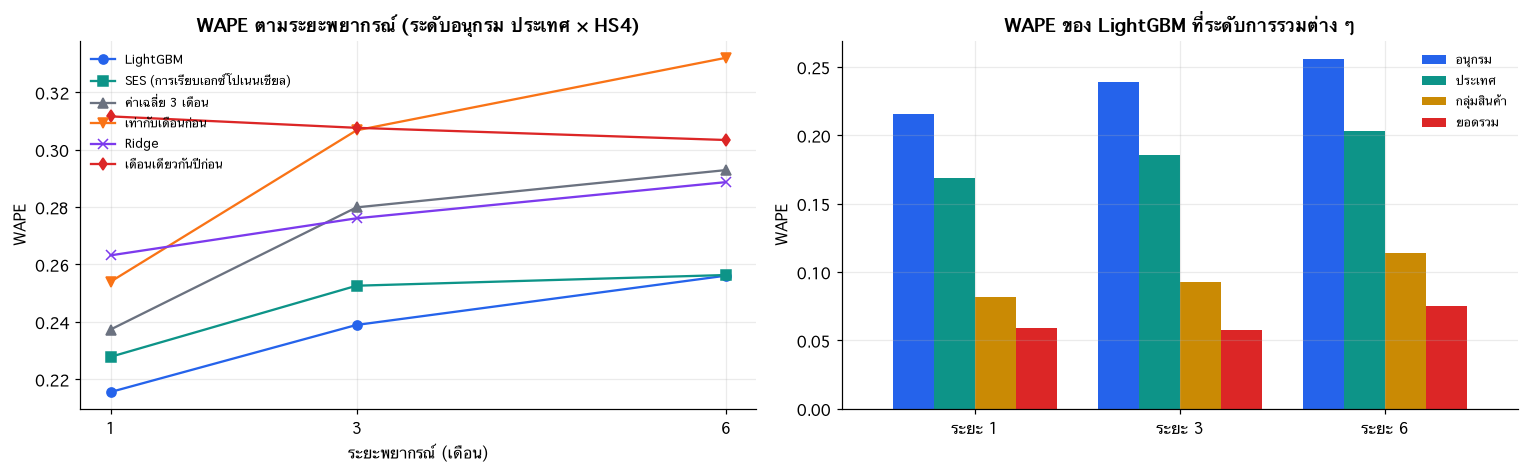

LightGBM: WAPE ที่ระดับการรวมต่าง ๆ แยกตามระยะ


,ระยะ 1,ระยะ 3,ระยะ 6
อนุกรม,0.216,0.239,0.256
ประเทศ,0.169,0.186,0.203
กลุ่มสินค้า,0.081,0.093,0.114
ยอดรวม,0.059,0.058,0.075


In [75]:
TH = {1: test_res}                                               # ระยะ 1 = ผลจากส่วน 4.2 (ไม่รันซ้ำ)
for h in (3, 6):
    d = {k: rolling_forecast(baseline_fn(c), TEST_O[h], h) for k, c in base_cols(h).items()}
    d[SES_NAME] = rolling_forecast(ses_fn(SES_A[h]), TEST_O[h], h)
    d["Ridge"] = rolling_forecast(ridge_h(h, BEST_ALPHA), TEST_O[h], h)
    d["LightGBM"] = rolling_forecast(lgbm_h(h, BEST_P, **BEST_KW_H[h]), TEST_O[h], h)
    TH[h] = d
W = pd.DataFrame({f"ระยะ {h} เดือน": {k: metrics(d).WAPE for k, d in TH[h].items()} for h in HZ})
W = W.loc[W.mean(axis=1).sort_values().index]
print("WAPE ช่วงทดสอบ (ยิ่งต่ำยิ่งดี) | จุดทำนาย:", {h: f"{len(TH[h]['LightGBM']):,}" for h in HZ}); show(W)
R = pd.DataFrame({f"ระยะ {h} เดือน": {"LightGBM": metrics(TH[h]["LightGBM"]).WAPE / metrics(TH[h][PB[h]]).WAPE - 1,
                                      "SES": metrics(TH[h][SES_NAME]).WAPE / metrics(TH[h][PB[h]]).WAPE - 1} for h in HZ})
print(f"LightGBM และ SES เทียบกับ baseline หลักของแต่ละระยะ {PB}"); show(R)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
sty = {"LightGBM": (C["blue"], "o"), SES_NAME: (C["teal"], "s"), "ค่าเฉลี่ย 3 เดือน": (C["gray"], "^"), "เท่ากับเดือนก่อน": (C["orange"], "v"), "Ridge": (C["purple"], "x"), "เดือนเดียวกันปีก่อน": (C["red"], "d")}
for k, (c_, mk) in sty.items(): ax[0].plot(list(HZ), [W.loc[k, f"ระยะ {h} เดือน"] for h in HZ], marker=mk, color=c_, label=k)
ax[0].set(title="WAPE ตามระยะพยากรณ์ (ระดับอนุกรม ประเทศ × HS4)", xlabel="ระยะพยากรณ์ (เดือน)", ylabel="WAPE", xticks=list(HZ)); ax[0].legend(frameon=False, fontsize=8)
def tot_wape(d, key=None):
    t = d.groupby("origin")[["y", "pred"]].sum() if key is None else d.groupby(["origin", key])[["y", "pred"]].sum()
    return (t.pred - t.y).abs().sum() / t.y.sum()
levels = {"อนุกรม": lambda d: metrics(d).WAPE, "ประเทศ": lambda d: tot_wape(d, "iso2"), "กลุ่มสินค้า": lambda d: tot_wape(d, "hs4"), "ยอดรวม": lambda d: tot_wape(d)}
LV = pd.DataFrame({f"ระยะ {h}": {lv: fn(TH[h]["LightGBM"]) for lv, fn in levels.items()} for h in HZ})
LV.T.plot.bar(ax=ax[1], rot=0, color=[C["blue"], C["teal"], C["gold"], C["red"]], width=.8); ax[1].set(title="WAPE ของ LightGBM ที่ระดับการรวมต่าง ๆ", ylabel="WAPE"); ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()
print("LightGBM: WAPE ที่ระดับการรวมต่าง ๆ แยกตามระยะ"); show(LV)

### 📝 อ่านผล: ช่วงทดสอบ ทุกระยะ

| โมเดล | 1 เดือน | 3 เดือน | 6 เดือน |
|---|---|---|---|
| **LightGBM** | **0.216** | **0.239** | 0.256 |
| SES (baseline หลัก) | 0.228 | 0.253 | 0.256 |
| ค่าเฉลี่ย 12 เดือน | 0.237 | 0.248 | **0.255** |
| ค่าเฉลี่ย 3 เดือน | 0.237 | 0.280 | 0.293 |
| Ridge | 0.263 | 0.276 | 0.289 |
| เท่ากับเดือนก่อน | 0.254 | 0.307 | 0.332 |
| เดือนเดียวกันปีก่อน | 0.312 | 0.308 | 0.303 |

- **LightGBM ชนะ SES ที่ระยะ 1 และ 3 เดือน (ต่ำกว่า 5.4% ทั้งคู่) แต่ที่ 6 เดือน "เสมอ"** (0.256 เทียบ 0.256) และเสมอกับค่าเฉลี่ย 12 เดือน (0.255) → ข้อได้เปรียบของ ML จำกัดอยู่ที่ระยะสั้น ถึง 3 เดือน
- **ความผิดพลาดเพิ่มขึ้นช้า** เมื่อระยะไกลขึ้น: LightGBM 0.216 → 0.239 → 0.256 (เพิ่ม 19% จาก 1 เป็น 6 เดือน) เพราะความผันผวนสุ่มรายเดือนเป็นตัวกำหนดความผิดพลาดเป็นหลัก ไม่ใช่แนวโน้มที่ต้องเดาไกลขึ้น
- **baseline ที่ดีที่สุดเปลี่ยนไปตามระยะ:** ระยะสั้นคือ SES ระยะ 3 เดือนคือค่าเฉลี่ย 12 เดือน (0.248 ดีกว่า SES 0.253) และระยะ 6 เดือนค่าเฉลี่ย 12 เดือนเท่ากับ LightGBM ค่าเฉลี่ย 3 เดือนและเท่ากับเดือนก่อนแย่ลงเร็วที่สุด
- **Ridge ยังไม่ชนะ baseline ที่ระยะใดเลย** และเดือนเดียวกันปีก่อนยังแย่ (≈ 0.30–0.31 ทุกระยะ) ย้ำว่าไม่มีฤดูกาลที่ใช้ได้
- **ระดับการรวม (LightGBM):** ยอดรวมทั้งประเทศผิดพลาดเพียง **5.9% / 5.8% / 7.5%** (1/3/6 เดือน), ระดับประเทศ 16.9% / 18.6% / 20.3%, ระดับกลุ่มสินค้า 8.1% / 9.3% / 11.4%, ระดับอนุกรม 21.6% / 23.9% / 25.6% → **พยากรณ์ยอดรวมล่วงหน้า 6 เดือนยังผิดพลาดน้อยกว่า 10%** ซึ่งใช้งานได้จริง แม้ระดับตลาด-สินค้าจะแม่นยำน้อยกว่ามาก

In [76]:
# ความต่างมีนัยสำคัญไหม (bootstrap ข้ามเดือน แบบเดียวกับ 4.2.5) ในแต่ละระยะ
def boot_diff_h(res_h, a, b, B=10000, seed=0):
    g = lambda d: d.assign(ae=(d.pred - d.y).abs()).groupby("origin")[["ae", "y"]].sum()
    A, Bm = g(res_h[a]), g(res_h[b]); n = len(A); idx = np.random.default_rng(seed).integers(0, n, (B, n))
    d = A.ae.to_numpy()[idx].sum(1) / A.y.to_numpy()[idx].sum(1) - Bm.ae.to_numpy()[idx].sum(1) / Bm.y.to_numpy()[idx].sum(1)
    return A.ae.sum() / A.y.sum() - Bm.ae.sum() / Bm.y.sum(), np.percentile(d, [2.5, 97.5]), (A.ae < Bm.ae).mean()
rows = []
for h in HZ:
    for b in dict.fromkeys([PB[h], SES_NAME, "ค่าเฉลี่ย 3 เดือน"]):
        o, ci, win = boot_diff_h(TH[h], "LightGBM", b); rows.append((f"{h} เดือน", f"LightGBM − {b}", o, ci[0], ci[1], f"{win:.0%}", "ใช่" if ci[1] < 0 else ("ไม่ (แย่กว่า)" if ci[0] > 0 else "ยังบอกไม่ได้")))
show(pd.DataFrame(rows, columns=["ระยะ", "เปรียบเทียบ (WAPE a − b)", "ผลต่าง", "ช่วง 95% ล่าง", "ช่วง 95% บน", "% เดือนที่ LightGBM ดีกว่า", "ชนะอย่างมีนัยสำคัญ?"]))

,ระยะ,เปรียบเทียบ (WAPE a − b),ผลต่าง,ช่วง 95% ล่าง,ช่วง 95% บน,% เดือนที่ LightGBM ดีกว่า,ชนะอย่างมีนัยสำคัญ?
0,1 เดือน,LightGBM − SES (การเรียบเอกซ์โปเนนเชียล),-0.012,-0.021,-0.005,69%,ใช่
1,1 เดือน,LightGBM − ค่าเฉลี่ย 3 เดือน,-0.022,-0.031,-0.014,83%,ใช่
2,3 เดือน,LightGBM − SES (การเรียบเอกซ์โปเนนเชียล),-0.014,-0.022,-0.005,74%,ใช่
3,3 เดือน,LightGBM − ค่าเฉลี่ย 3 เดือน,-0.041,-0.052,-0.030,94%,ใช่
4,6 เดือน,LightGBM − SES (การเรียบเอกซ์โปเนนเชียล),-0.000,-0.008,0.007,48%,ยังบอกไม่ได้
5,6 เดือน,LightGBM − ค่าเฉลี่ย 3 เดือน,-0.037,-0.051,-0.024,84%,ใช่


### 📝 อ่านผล: ความต่างจริงหรือแค่โชค (แต่ละระยะ)

| ระยะ | LightGBM − SES | ช่วง 95% | LightGBM ชนะกี่ % ของเดือน | สรุป |
|---|---|---|---|---|
| 1 เดือน | −0.012 | [−0.021, −0.005] | 69% | ✅ ชนะอย่างมีนัยสำคัญ (เล็ก) |
| 3 เดือน | −0.014 | [−0.022, −0.005] | 74% | ✅ ชนะอย่างมีนัยสำคัญ (เล็ก) |
| 6 เดือน | −0.000 | [−0.008, +0.007] | 48% | ➖ **ไม่ต่างกัน** (ช่วงคร่อม 0) |

- **เทียบกับค่าเฉลี่ย 3 เดือน LightGBM ชนะอย่างมีนัยสำคัญทุกระยะ** (ผลต่าง −0.022, −0.041, −0.037 ชนะ 83–94% ของเดือน) แต่ค่าเฉลี่ย 3 เดือนไม่ใช่ baseline ที่ดีที่สุดแล้ว ผลที่ควรรายงานคือการเทียบกับ SES
- **ข้อสรุป:** ที่ระยะ 6 เดือน ไม่มีหลักฐานว่า ML ดีกว่าวิธีเรียบง่าย — ใช้ SES หรือค่าเฉลี่ย 12 เดือนก็ได้ผลเท่ากัน ด้วยต้นทุนต่ำกว่ามาก (ข้อควรระวังเรื่องการถือเดือนเป็นอิสระต่อกันยังใช้เหมือน 4.2.5)

In [77]:
# แยกตามกลุ่มตลาด (A–D) ในแต่ละระยะ
seg_rows = []
for h in HZ:
    d = TH[h]["LightGBM"][["origin", "hs4", "iso2", "y"]].copy(); d["LightGBM"] = TH[h]["LightGBM"].pred.to_numpy(); d["SES"] = TH[h][SES_NAME].pred.to_numpy()
    d["กลุ่ม"] = d.iso2.map(cl_map).fillna("นอกกลุ่ม").str.split().str[0]
    for g_, x in d.groupby("กลุ่ม"):
        seg_rows.append((f"{h} เดือน", g_, (x.LightGBM - x.y).abs().sum() / x.y.sum(), (x.SES - x.y).abs().sum() / x.y.sum(), x.y.sum() / d.y.sum() * 100))
seg3 = pd.DataFrame(seg_rows, columns=["ระยะ", "กลุ่มตลาด", "WAPE LightGBM", "WAPE SES", "% ของมูลค่า"])
show(seg3.pivot(index="กลุ่มตลาด", columns="ระยะ", values=["WAPE LightGBM", "WAPE SES"]).round(3))

WAPE LightGBM                 WAPE SES                
ระยะ            1 เดือน 3 เดือน 6 เดือน  1 เดือน 3 เดือน 6 เดือน
กลุ่มตลาด                                                       
A                 0.194   0.215   0.230    0.205   0.228   0.230
B                 0.419   0.478   0.539    0.443   0.504   0.553
C                 0.554   0.583   0.604    0.581   0.600   0.594
D                 0.697   0.692   0.694    0.748   0.704   0.687
นอกกลุ่ม          1.045   1.084   1.417    1.099   1.196   1.729

### 📝 อ่านผล: แยกตามกลุ่มตลาดในแต่ละระยะ

| กลุ่ม | WAPE LightGBM (1 / 3 / 6 เดือน) | WAPE SES (1 / 3 / 6) |
|---|---|---|
| **A ตลาดหลัก** | 0.194 / 0.215 / 0.230 | 0.205 / 0.228 / 0.230 |
| B ตลาดปลากระป๋องราคาต่ำที่หดตัว | 0.419 / 0.478 / 0.539 | 0.443 / 0.504 / 0.553 |
| C ตลาดโตเร็ว ราคาสูง | 0.554 / 0.583 / 0.604 | 0.581 / 0.600 / 0.594 |
| D ตลาดเล็ก ผันผวน | 0.697 / 0.692 / 0.694 | 0.748 / 0.704 / 0.687 |

- **กลุ่ม A (92% ของมูลค่า):** LightGBM ชนะ SES ที่ 1 และ 3 เดือน (−5.4%, −5.7%) และ **เสมอที่ 6 เดือน (0.230 เท่ากัน)** ความผิดพลาดเพิ่มจาก 19% เป็น 23% เท่านั้น
- **กลุ่ม B** เป็นกลุ่มเดียวที่ LightGBM ยังชนะเล็กน้อยที่ 6 เดือน (0.539 vs 0.553) และความผิดพลาดเพิ่มเร็วสุด (0.419 → 0.539)
- **กลุ่ม C และ D:** ที่ 6 เดือน LightGBM ไม่ดีกว่า SES (C: 0.604 vs 0.594, D: 0.694 vs 0.687) ความผิดพลาดสูงมาก (55–70%) ไม่ว่าจะใช้โมเดลไหน → การพยากรณ์ตลาดกลุ่มนี้ไม่น่าเชื่อถือ

### 4.3.4 ARIMA และ SARIMA (100 อนุกรมที่ใหญ่สุด)

โมเดลรายอนุกรมที่เป็นมาตรฐานของงานอนุกรมเวลา — ARIMA(1,1,1) และ SARIMA(1,1,1)(0,1,1)₁₂ บน log(1+มูลค่า) แต่ละ origin เทรนใหม่ด้วยข้อมูลตั้งแต่ ม.ค. 2015 ถึงเดือนนั้น และพยากรณ์ 6 เดือนข้างหน้าในครั้งเดียว (ใช้ได้ทุกระยะ) ถ้าโมเดลไม่ลู่เข้า ใช้ค่าล่าสุดแทน

In [78]:
AR_CACHE = CACHE / "arima_test.csv"
size_rank = PN[PN.origin == pd.Timestamp(FIRST_ORIGIN)].assign(size=lambda d: np.expm1(d.mean12)).sort_values("size", ascending=False)
TOP100 = list(zip(size_rank.hs4.astype(str).head(100), size_rank.iso2.head(100)))
if RETUNE or not AR_CACHE.exists():
    import warnings as _w; _w.filterwarnings("ignore")
    start = pd.Timestamp("2015-01-01"); rows = []
    orig_all = sorted(set().union(*[set(TEST_O[h]) for h in HZ]))
    for (hs, c_) in TOP100:
        s_full = np.log1p(_Vu[(hs, c_)])
        for T in orig_all:
            y_ = s_full.loc[start:T].to_numpy()
            for name, mk in (("ARIMA", lambda y_: ARIMA(y_, order=(1, 1, 1)).fit()), ("SARIMA", lambda y_: SARIMAX(y_, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False, maxiter=50))):
                try: fc = np.expm1(np.asarray(mk(y_).forecast(6)))
                except Exception: fc = np.full(6, np.expm1(y_[-1]))
                for h in HZ:
                    if T in set(TEST_O[h]): rows.append((name, h, T, hs, c_, max(float(fc[h - 1]), 0.0)))
    pd.DataFrame(rows, columns=["model", "h", "origin", "hs4", "iso2", "pred"]).to_csv(AR_CACHE, index=False, encoding="utf-8-sig")
ar = rd(AR_CACHE, dtype={"hs4": str}, parse_dates=["origin"])
top_set = set(TOP100)
rows = []
for h in HZ:
    base_ = {k: v[v.apply(lambda r: (r.hs4, r.iso2) in top_set, axis=1)] for k, v in TH[h].items() if k in ("LightGBM", SES_NAME, "ค่าเฉลี่ย 3 เดือน", "เท่ากับเดือนก่อน", "เดือนเดียวกันปีก่อน")}
    ref = base_["LightGBM"][["origin", "hs4", "iso2", "y"]]
    for name in ("ARIMA", "SARIMA"):
        a_ = ref.merge(ar[(ar.model == name) & (ar.h == h)], on=["origin", "hs4", "iso2"], how="inner"); base_[name] = a_
    keys = set.intersection(*[set(zip(d.origin, d.hs4, d.iso2)) for d in (base_["ARIMA"], base_["SARIMA"], base_["LightGBM"])])   # เทียบเฉพาะจุดที่ทุกโมเดลมีค่า
    for k, d in base_.items():
        d = d[[(o_, h_, i_) in keys for o_, h_, i_ in zip(d.origin, d.hs4, d.iso2)]]
        rows.append((f"{h} เดือน", k, metrics(d).WAPE, len(d)))
arm = pd.DataFrame(rows, columns=["ระยะ", "โมเดล", "WAPE", "n_points"])
cov_val = sum(PN[(PN.origin == pd.Timestamp(FIRST_ORIGIN))].set_index(["hs4", "iso2"]).loc[TOP100].pipe(lambda d: np.expm1(d.mean12))) / np.expm1(PN[PN.origin == pd.Timestamp(FIRST_ORIGIN)].mean12).sum()
print(f"100 อนุกรมที่ใหญ่สุด ครอบคลุม {cov_val:.1%} ของมูลค่า (ขนาด ณ เม.ย. 2023)")
show(arm.pivot(index="โมเดล", columns="ระยะ", values="WAPE").loc[lambda t: t.mean(axis=1).sort_values().index])
print("จำนวนจุดที่ใช้เทียบ (ทุกโมเดลเท่ากันในแต่ละระยะ):", arm.groupby("ระยะ")["n_points"].agg(lambda s: sorted(set(s))).to_dict())

100 อนุกรมที่ใหญ่สุด ครอบคลุม 95.1% ของมูลค่า (ขนาด ณ เม.ย. 2023)


ระยะ,1 เดือน,3 เดือน,6 เดือน
โมเดล,,,
LightGBM,0.197,0.220,0.237
SES (การเรียบเอกซ์โปเนนเชียล),0.208,0.234,0.236
ARIMA,0.208,0.252,0.270
ค่าเฉลี่ย 3 เดือน,0.218,0.260,0.272
SARIMA,0.231,0.256,0.279
เท่ากับเดือนก่อน,0.231,0.284,0.308
เดือนเดียวกันปีก่อน,0.287,0.282,0.278


จำนวนจุดที่ใช้เทียบ (ทุกโมเดลเท่ากันในแต่ละระยะ): {'1 เดือน': [3600], '3 เดือน': [3400], '6 เดือน': [3100]}


### 📝 อ่านผล: ARIMA และ SARIMA (100 อนุกรมที่ใหญ่สุด = 95.1% ของมูลค่า)

เทียบบน *อนุกรมและจุดทำนายชุดเดียวกันทุกโมเดล* (3,600 / 3,400 / 3,100 จุด)

| โมเดล | 1 เดือน | 3 เดือน | 6 เดือน |
|---|---|---|---|
| **LightGBM** | **0.197** | **0.220** | 0.237 |
| SES | 0.208 | 0.234 | **0.236** |
| ARIMA(1,1,1) | 0.208 | 0.252 | 0.270 |
| ค่าเฉลี่ย 3 เดือน | 0.218 | 0.260 | 0.272 |
| SARIMA(1,1,1)(0,1,1)₁₂ | 0.231 | 0.256 | 0.279 |
| เท่ากับเดือนก่อน | 0.231 | 0.284 | 0.308 |
| เดือนเดียวกันปีก่อน | 0.287 | 0.282 | 0.278 |

- **ARIMA เท่ากับ SES ที่ 1 เดือน (0.208)** — ไม่แปลกเพราะ SES คือ ARIMA(0,1,1) กรณีพิเศษ แต่ **ARIMA แย่กว่า SES เมื่อระยะไกลขึ้น** (0.252 vs 0.234 ที่ 3 เดือน, 0.270 vs 0.236 ที่ 6 เดือน) เพราะส่วน AR/MA ที่ฟิตจากข้อมูลผันผวนนำไปขยายสัญญาณรบกวนที่ระยะไกล
- **SARIMA แย่กว่า ARIMA ทุกระยะ** (0.231 vs 0.208 ที่ 1 เดือน) และที่ 1 เดือนได้เท่ากับ "เท่ากับเดือนก่อน" (0.231) → **การเติมส่วนฤดูกาลทำให้แย่ลง** ยืนยันอีกครั้งว่าข้อมูลไม่มีฤดูกาลที่เสถียร (สอดคล้องกับส่วน 2.2.1 และ seasonal naive) ดังนั้น baseline SARIMA ตามแผน README เดิม **ไม่ใช่ baseline ที่ดี** สำหรับข้อมูลนี้
- **LightGBM ชนะ ARIMA/SARIMA ทุกระยะ:** ต่ำกว่า ARIMA 5%, 13%, 12% ที่ 1/3/6 เดือน
- **ข้อจำกัด:** order ของ ARIMA/SARIMA กำหนดตายตัวล่วงหน้า (ไม่ได้ปรับรายอนุกรม) ถ้าปรับด้วย auto-ARIMA ผลอาจดีขึ้นบ้าง แต่ไม่น่าถึงขั้นเปลี่ยนข้อสรุป เพราะ SES ที่ง่ายกว่าก็ทำได้ดีเท่ากันที่ 1 เดือน

### 4.3.5 ช่วงความไม่แน่นอน 80% (Quantile LightGBM + conformal)

1. เทรน LightGBM แบบ quantile ที่ 10% และ 90% (ใช้ target และการถ่วงน้ำหนักเดียวกับโมเดลหลัก)
2. **ปรับให้ครอบคลุมจริง (CQR):** ในช่วงตรวจสอบ วัดว่าค่าจริงหลุดช่วงไปเท่าไรในสเกล log แล้วขยายช่วงด้วยค่านั้น เพื่อให้ coverage ใกล้ 80% ในข้อมูลที่ไม่เคยเห็น
3. เทียบกับช่วงง่าย ๆ: ค่าพยากรณ์ SES × ควอนไทล์ 10%/90% ของอัตราส่วนความคลาดเคลื่อนในช่วงตรวจสอบ

In [79]:
Q_CACHE = CACHE / "quantiles.csv"
if RETUNE or not Q_CACHE.exists():
    rows = []
    for h in HZ:
        for split, origs in (("val", VAL_O[h]), ("test", TEST_O[h])):
            lo = rolling_forecast(lgbm_h(h, BEST_P, delta=True, weight="sqrt", obj="quantile", alpha=0.1), origs, h)
            hi = rolling_forecast(lgbm_h(h, BEST_P, delta=True, weight="sqrt", obj="quantile", alpha=0.9), origs, h)
            d = lo.rename(columns={"pred": "lo"}).assign(hi=hi.pred.to_numpy(), h=h, split=split); rows.append(d)
    pd.concat(rows).to_csv(Q_CACHE, index=False, encoding="utf-8-sig")
Q = rd(Q_CACHE, dtype={"hs4": str}, parse_dates=["origin"])
Q["lo"], Q["hi"] = np.minimum(Q.lo, Q.hi), np.maximum(Q.lo, Q.hi)
print("ตัวอย่างแถว:", len(Q), "| ต่อระยะ/ช่วง:", Q.groupby(["h", "split"]).size().to_dict())

ตัวอย่างแถว: 69388 | ต่อระยะ/ช่วง: {(1, 'test'): 11952, (1, 'val'): 11952, (3, 'test'): 11288, (3, 'val'): 11952, (6, 'test'): 10292, (6, 'val'): 11952}


In [80]:
NOM = 0.8
def cqr_q(v):
    s = np.maximum(np.log1p(v.lo) - np.log1p(v.y), np.log1p(v.y) - np.log1p(v.hi)); n = len(s)
    return float(np.quantile(s, min(1.0, np.ceil((n + 1) * NOM) / n)))
iv_rows, IV = [], {}
for h in HZ:
    v, t = Q[(Q.h == h) & (Q.split == "val")], Q[(Q.h == h) & (Q.split == "test")].copy()
    qh = cqr_q(v)
    t["lo_c"], t["hi_c"] = np.expm1(np.log1p(t.lo) - qh).clip(lower=0), np.expm1(np.log1p(t.hi) + qh)
    # baseline: SES x ควอนไทล์ของ log-ratio ในช่วงตรวจสอบ
    sv = rolling_forecast(ses_fn(SES_A[h]), VAL_O[h], h); st = rolling_forecast(ses_fn(SES_A[h]), TEST_O[h], h)
    lr = np.log1p(sv.y) - np.log1p(sv.pred); qlo, qhi = np.quantile(lr, [(1 - NOM) / 2, 1 - (1 - NOM) / 2])
    t = t.merge(st.rename(columns={"pred": "ses"})[["origin", "hs4", "iso2", "ses"]], on=["origin", "hs4", "iso2"])
    t["lo_s"], t["hi_s"] = np.expm1(np.log1p(t.ses) + qlo), np.expm1(np.log1p(t.ses) + qhi)
    IV[h] = t
    for name, lo_, hi_ in (("Quantile ดิบ", t.lo, t.hi), ("Quantile + conformal (CQR)", t.lo_c, t.hi_c), ("SES + ควอนไทล์ของความคลาดเคลื่อน", t.lo_s, t.hi_s)):
        ins = (t.y >= lo_) & (t.y <= hi_); pt = t.ses if name.startswith("SES") else None
        center = (lo_ + hi_) / 2
        iv_rows.append((f"{h} เดือน", name, ins.mean(), (t.y * ins).sum() / t.y.sum(), ((hi_ - lo_) / np.maximum(center, 1)).median()))
ivt = pd.DataFrame(iv_rows, columns=["ระยะ", "วิธี", "coverage (เป้า 0.80)", "coverage ถ่วงมูลค่า", "ความกว้างสัมพัทธ์ (มัธยฐาน)"])
show(ivt)
print({h: f"CQR ขยายช่วงใน log เพิ่ม {cqr_q(Q[(Q.h == h) & (Q.split == 'val')]):.3f}" for h in HZ})

,ระยะ,วิธี,coverage (เป้า 0.80),coverage ถ่วงมูลค่า,ความกว้างสัมพัทธ์ (มัธยฐาน)
0,1 เดือน,Quantile ดิบ,0.789,0.726,1.522
1,1 เดือน,Quantile + conformal (CQR),0.824,0.821,1.567
2,1 เดือน,SES + ควอนไทล์ของความคลาดเคลื่อน,0.801,0.975,1.988
3,3 เดือน,Quantile ดิบ,0.792,0.721,1.595
4,3 เดือน,Quantile + conformal (CQR),0.844,0.857,1.663
5,3 เดือน,SES + ควอนไทล์ของความคลาดเคลื่อน,0.804,0.957,1.996
6,6 เดือน,Quantile ดิบ,0.782,0.704,1.651
7,6 เดือน,Quantile + conformal (CQR),0.843,0.875,1.723
8,6 เดือน,SES + ควอนไทล์ของความคลาดเคลื่อน,0.805,0.951,1.998


{1: 'CQR ขยายช่วงใน log เพิ่ม 0.055', 3: 'CQR ขยายช่วงใน log เพิ่ม 0.100', 6: 'CQR ขยายช่วงใน log เพิ่ม 0.123'}


ระยะ             1 เดือน  3 เดือน  6 เดือน
แยกตาม กลุ่ม                              
กลุ่ม  A           0.824    0.850    0.854
       B           0.826    0.832    0.818
       C           0.838    0.852    0.852
       D           0.759    0.767    0.769
       นอกกลุ่ม    0.811    0.835    0.858
ปี     ปี 1        0.837    0.849    0.843
       ปี 2        0.827    0.856    0.852
       ปี 3        0.810    0.822    0.827

ความกว้างสัมพัทธ์ (มัธยฐาน)                 coverage                
ระยะ                           1 เดือน 3 เดือน 6 เดือน  1 เดือน 3 เดือน 6 เดือน
ขนาดอนุกรม                                                                     
กลาง                             1.835   1.845   1.893    0.815   0.834   0.832
เล็ก                             1.993   1.990   1.992    0.829   0.844   0.836
ใหญ่                             1.027   1.187   1.281    0.829   0.853   0.861

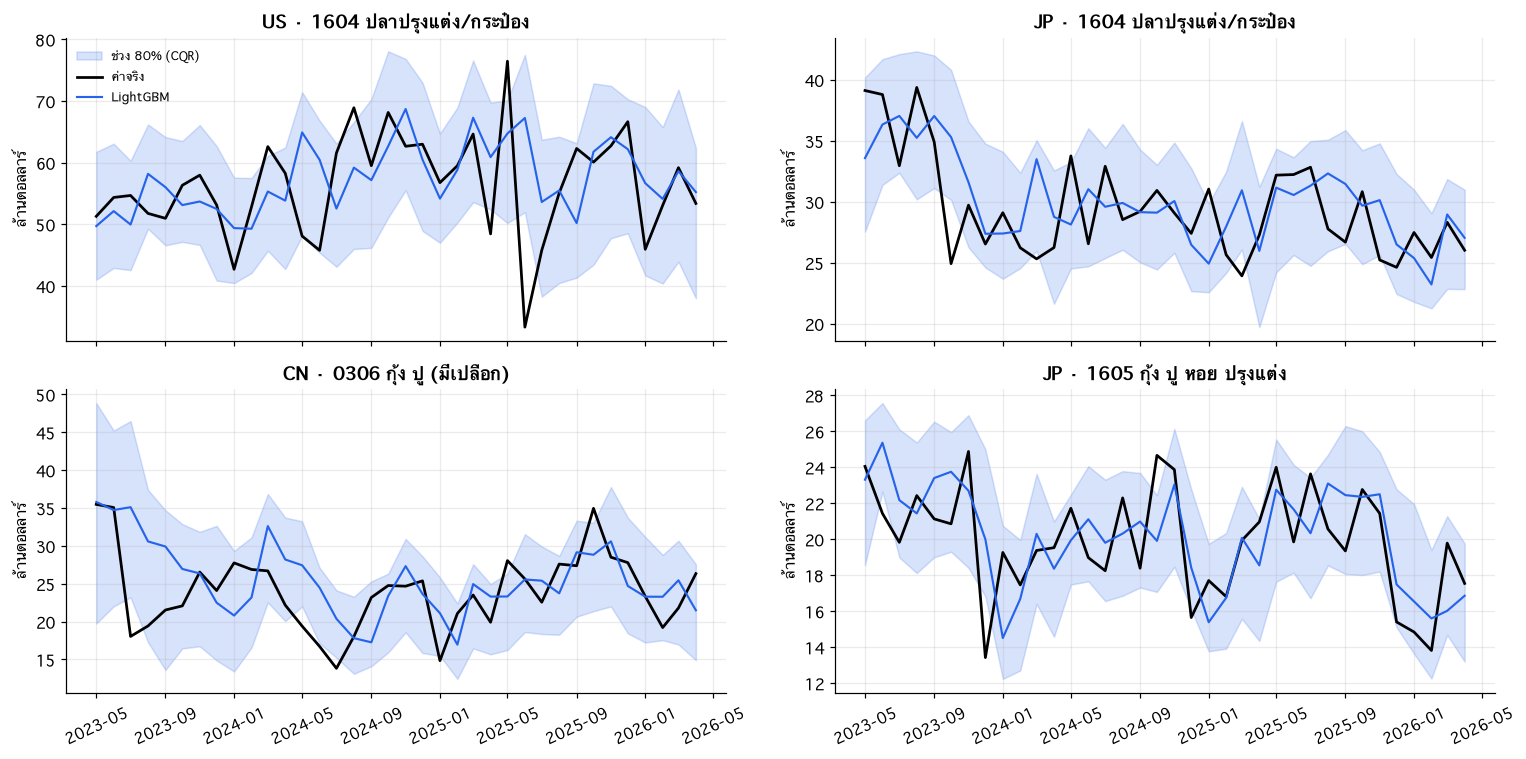

In [81]:
# coverage แยกตามกลุ่มตลาด และตามปีทดสอบ (CQR) — ช่วงควรครอบคลุมใกล้ 80% ทุกกลุ่มหรือไม่
cv = []
for h in HZ:
    t = IV[h].copy(); t["กลุ่ม"] = t.iso2.map(cl_map).fillna("นอกกลุ่ม").str.split().str[0]
    t["ปี"] = np.where(t.origin < "2024-04-01", "ปี 1", np.where(t.origin < "2025-04-01", "ปี 2", "ปี 3"))
    t["in"] = (t.y >= t.lo_c) & (t.y <= t.hi_c)
    for key in ("กลุ่ม", "ปี"):
        for g_, x in t.groupby(key): cv.append((f"{h} เดือน", key, g_, x["in"].mean(), len(x)))
cvt = pd.DataFrame(cv, columns=["ระยะ", "แยกตาม", "กลุ่ม", "coverage CQR", "จุด"])
show(cvt.pivot_table(index=["แยกตาม", "กลุ่ม"], columns="ระยะ", values="coverage CQR"))

# ความกว้างและ coverage ตามขนาดอนุกรม (CQR) — ค่ากลางรวมทุกอนุกรมถูกอนุกรมเล็กดันให้กว้าง
tier = pd.qcut(size0.rename("s"), 3, labels=["เล็ก", "กลาง", "ใหญ่"]).to_dict()
tw = []
for h in HZ:
    t = IV[h].copy(); t["ขนาด"] = [tier.get((a_, b_)) for a_, b_ in zip(t.hs4, t.iso2)]
    t["w"] = (t.hi_c - t.lo_c) / np.maximum((t.hi_c + t.lo_c) / 2, 1); t["in"] = (t.y >= t.lo_c) & (t.y <= t.hi_c)
    for g_, x in t.groupby("ขนาด"): tw.append((f"{h} เดือน", g_, x.w.median(), x["in"].mean()))
twd = pd.DataFrame(tw, columns=["ระยะ", "ขนาดอนุกรม", "ความกว้างสัมพัทธ์ (มัธยฐาน)", "coverage"])
show(twd.pivot(index="ขนาดอนุกรม", columns="ระยะ", values=["ความกว้างสัมพัทธ์ (มัธยฐาน)", "coverage"]).round(3))

# ตัวอย่างอนุกรมที่ใหญ่สุด 4 ตัว ที่ระยะ 1 เดือน
t = IV[1]; big = [s for s in TOP100[:4]]
fig, ax = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for a, (hs, c_) in zip(ax.ravel(), big):
    x = t[(t.hs4 == hs) & (t.iso2 == c_)].sort_values("origin"); xm = x.origin + pd.DateOffset(months=1)
    a.fill_between(xm, x.lo_c / 1e6, x.hi_c / 1e6, color=C["blue"], alpha=.18, label="ช่วง 80% (CQR)")
    a.plot(xm, x.y / 1e6, color="k", lw=1.8, label="ค่าจริง")
    pr = TH[1]["LightGBM"]; pr = pr[(pr.hs4 == hs) & (pr.iso2 == c_)].sort_values("origin"); a.plot(pr.origin + pd.DateOffset(months=1), pr.pred / 1e6, color=C["blue"], lw=1.4, label="LightGBM")
    a.set(title=f"{c_} · {HS4_NAME[hs]}", ylabel="ล้านดอลลาร์"); a.tick_params(axis="x", rotation=25)
ax[0, 0].legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

### 📝 อ่านผล: ช่วงความไม่แน่นอน 80%

| วิธี | coverage (เป้า 0.80) 1/3/6 เดือน | coverage ถ่วงมูลค่า | ความกว้างสัมพัทธ์ (มัธยฐาน) |
|---|---|---|---|
| Quantile ดิบ | 0.789 / 0.792 / 0.782 | **0.726 / 0.721 / 0.704** | 1.52 / 1.60 / 1.65 |
| **Quantile + conformal (CQR)** | **0.824 / 0.844 / 0.843** | **0.821 / 0.857 / 0.875** | 1.57 / 1.66 / 1.72 |
| SES + ควอนไทล์ของความคลาดเคลื่อน | 0.801 / 0.804 / 0.805 | 0.975 / 0.957 / 0.951 | 1.99 / 2.00 / 2.00 |

- **Quantile ดิบ "แคบเกินไป" โดยเฉพาะตลาดใหญ่:** ครอบคลุมจุดข้อมูลได้ราว 78–79% (ใกล้ 80%) แต่ถ่วงด้วยมูลค่าเหลือเพียง 70–73% แปลว่าช่วงของตลาดใหญ่ซึ่งมีน้ำหนักมากที่สุดหลุดบ่อยกว่าที่ควร
- **CQR แก้ได้:** coverage 82–84% (เกินเป้าเล็กน้อย = ระมัดระวัง) และถ่วงมูลค่า 82–88% ปรับเทียบจากช่วงตรวจสอบ 2019–2022 แต่ยังใช้ได้ในช่วงทดสอบ (ข้อมูลที่ไม่เคยเห็น)
- **ช่วงง่าย ๆ จาก SES ใช้ความกว้างเท่ากันทุกอนุกรมจึง "เกินเป้าในตลาดใหญ่ (95–97%) และกว้างกว่า"** (กว้างกว่า CQR 14–27%) CQR ปรับความกว้างตามอนุกรม จึงแคบกว่าในตลาดนิ่งและกว้างในตลาดผันผวน
- **ความกว้างขึ้นกับขนาดอนุกรม (CQR):** อนุกรมใหญ่ (หนึ่งในสามบนสุด) กว้างสัมพัทธ์ 1.03 / 1.19 / 1.28 (1/3/6 เดือน) ส่วนอนุกรมเล็ก ≈ 2.0 (ช่วงกว้างเท่ากับสองเท่าของค่ากลาง) ตลาดที่ใหญ่สุดแคบกว่านี้มาก (ตัวอย่างสหรัฐฯ-1604 ราว ±20% ในกราฟ) → ช่วงของตลาดเล็กกว้างจนแทบไม่ให้ข้อมูล
- **coverage แยกตามกลุ่ม (CQR):** A 82–85%, B 82–83%, C 84–85% ใกล้ 80% ยกเว้น **กลุ่ม D เพียง 76–77% (ต่ำกว่าเป้า)** เพราะตลาดเล็กผันผวนพลาดมากกว่าที่ช่วงตรวจสอบสะท้อน
- **coverage ลดลงเล็กน้อยตามเวลา:** ปีทดสอบที่ 1 → 3: 83.7% → 81.0% (1 เดือน), 84.9% → 82.2% (3 เดือน), 84.3% → 82.7% (6 เดือน) ยังไม่ต่ำกว่าเป้าแต่แสดงว่าการปรับเทียบ ณ ช่วง 2019–2022 เริ่มเก่า ควรปรับเทียบใหม่เป็นระยะ

**ตัวอย่างกราฟ (4 อนุกรมใหญ่สุด, 1 เดือนล่วงหน้า):** แถบ 80% ครอบคลุมค่าจริงเกือบทุกเดือน ยกเว้นเดือนที่ยอดพุ่ง/ดิ่งผิดปกติ (เช่น สหรัฐฯ-1604 เดือน พ.ค. 2025 ที่ลดลงเหลือราว 33 ล้านดอลลาร์) ซึ่งไม่มีโมเดลใดทำนายล่วงหน้าได้

### 4.3.6 บันทึกผลพยากรณ์ช่วงทดสอบ (ใช้ต่อในขั้น Evaluation และนำเสนอ)

In [82]:
parts = []
for h in HZ:
    d = TH[h]["LightGBM"][["origin", "hs4", "iso2", "y"]].rename(columns={"y": "actual"}).copy()
    d["h"] = h; d["target_month"] = d.origin + pd.DateOffset(months=h)
    for k, nm in (("LightGBM", "pred_lightgbm"), (SES_NAME, "pred_ses"), ("ค่าเฉลี่ย 3 เดือน", "pred_ma3"), ("Ridge", "pred_ridge")): d[nm] = TH[h][k].pred.to_numpy()
    d = d.merge(IV[h][["origin", "hs4", "iso2", "lo_c", "hi_c"]].rename(columns={"lo_c": "lo80", "hi_c": "hi80"}), on=["origin", "hs4", "iso2"], how="left")
    parts.append(d)
pred_all = pd.concat(parts, ignore_index=True)
if not FAST: pred_all.to_csv(PREP / "forecast_test_predictions.csv", index=False, encoding="utf-8-sig")
print("บันทึก DATASET/prepared/forecast_test_predictions.csv" if not FAST else "(โหมดเร็ว ไม่บันทึก)", pred_all.shape)
display(pred_all.head(4))

บันทึก DATASET/prepared/forecast_test_predictions.csv (33532, 12)


,origin,hs4,iso2,actual,h,target_month,pred_lightgbm,pred_ses,pred_ma3,pred_ridge,lo80,hi80
0,2023-04-01,0301,AE,"43,464.83",1,2023-05-01,"26,959.18","36,687.67","33,408.61","25,792.49","16,444.50","45,318.20"
1,2023-04-01,0301,AU,"20,404.93",1,2023-05-01,"24,762.43","22,526.56","23,343.01","21,431.33","13,687.03","39,265.65"
2,2023-04-01,0301,BD,"14,585.70",1,2023-05-01,"17,002.92","27,184.11","27,752.38","13,740.57","1,938.92","44,171.12"
3,2023-04-01,0301,BE,"2,118.54",1,2023-05-01,"3,606.55","5,317.61","6,650.60",360.09,0.00,"13,003.80"


### 4.3.7 สรุปรอบที่ 2

### สรุปรอบที่ 2 (Goal 1 พยากรณ์ — ครบแล้ว)

**1) ระยะพยากรณ์:** LightGBM ชนะ baseline หลัก (SES) ที่ **1 เดือน (−5.4%) และ 3 เดือน (−5.4%)** อย่างมีนัยสำคัญ แต่ที่ **6 เดือนไม่ต่างกัน** (0.256 เท่ากับ SES และค่าเฉลี่ย 12 เดือน 0.255) → *ข้อได้เปรียบของ ML ใช้ได้ถึง 3 เดือน*

**2) วิธีสถิติคลาสสิก:** ARIMA เท่ากับ SES ที่ 1 เดือนและแย่กว่าเมื่อระยะไกลขึ้น · **SARIMA แย่กว่า ARIMA ทุกระยะ** (ส่วนฤดูกาลทำให้แย่ลง) ยืนยันว่าข้อมูลไม่มีฤดูกาลที่ใช้ได้ · LightGBM ต่ำกว่า ARIMA 5–13%

**3) ความแม่นยำใช้งานได้จริงที่ระดับรวม:** ยอดส่งออกรวมทั้งประเทศผิดพลาด **5.9% / 5.8% / 7.5%** (1/3/6 เดือน), ระดับประเทศ 17–20%, ระดับตลาด-สินค้า 22–26%, ตลาดกลุ่ม A 19–23% แต่ตลาดกลุ่ม B–D 42–70%

**4) ช่วงความไม่แน่นอน:** Quantile ดิบแคบเกินไปในตลาดใหญ่ (coverage ถ่วงมูลค่า 70–73%) → ปรับด้วย conformal ได้ **coverage 82–84%** (ถ่วงมูลค่า 82–88%) ใกล้เป้า 80% แต่ยังต่ำกว่าเป้าในตลาดกลุ่ม D (76–77%) และลดลงเล็กน้อยตามเวลา ช่วงของตลาดเล็กกว้างราว 2 เท่าของค่ากลาง

**5) ข้อเสนอแนะเชิงปฏิบัติ**
- **1–3 เดือน:** ใช้ LightGBM + ช่วง 80% (CQR) สำหรับตลาดกลุ่ม A และยอดรวม
- **6 เดือน:** ใช้ SES หรือค่าเฉลี่ย 12 เดือน (ได้ผลเท่ากัน ง่ายกว่า) หรือพยากรณ์ที่ระดับรวม (ประเทศ/กลุ่มสินค้า/ยอดรวม) ซึ่งผิดพลาดน้อยกว่ามาก
- **ตลาดกลุ่ม B–D:** อย่าใช้ตัวเลขพยากรณ์รายตลาดตัดสินใจ ใช้เป็นภาพรวมเท่านั้น

**ข้อจำกัดที่ต้องบอก**
- ทดสอบหน้าต่างเดียว 36 เดือน และ bootstrap ถือเดือนเป็นอิสระต่อกัน
- baseline SES เพิ่มหลังเห็นผลทดสอบรอบแรก (เปิดเผยแล้ว) ส่วนรอบที่ 2 ใช้กฎเดิมทุกอย่าง (เลือก baseline/α/รูปแบบจากช่วงตรวจสอบ รันทดสอบครั้งเดียว)
- พารามิเตอร์ LightGBM ปรับเฉพาะที่ระยะ 1 เดือน (ระยะ 3/6 เลือกเพียงรูปแบบการเทรน) · order ของ ARIMA/SARIMA ไม่ได้ปรับรายอนุกรม
- ค่าพยากรณ์ผลช่วงทดสอบบันทึกไว้ที่ `DATASET/prepared/forecast_test_predictions.csv` (33,532 แถว) เพื่อใช้ในส่วน Evaluation และการนำเสนอ

**ถัดไป:** (ถ้ามีเวลา) Early Warning ตลาดยอดตก (Goal 3) → ส่วน Evaluation สรุปรวมทุกโจทย์ → Deployment (รายงาน/สไลด์/ตัวอย่างการใช้ผลพยากรณ์)

---
## 4.4 Early Warning — เตือนตลาดที่ยอดส่งออกกำลังจะตก (Goal 3, เสริม)

**โจทย์ทางธุรกิจ:** ณ สิ้นเดือน *t* ตลาด (ประเทศ × กลุ่ม HS4) ไหนมีความเสี่ยงที่ **ยอดรวม 12 เดือนจะตกเกิน 20% ภายใน 6 เดือนข้างหน้า** เพื่อให้ผู้ส่งออก/หน่วยงานมีเวลากระจายความเสี่ยงหรือเข้าไปแก้ปัญหา

**นิยาม (กำหนดก่อนเห็นผล):**
| หัวข้อ | การตั้งค่า |
|---|---|
| ป้ายกำกับ y = 1 | `S12(t+6) ÷ S12(t−6) − 1 < −20%` โดย S12(x) = ยอดรวม 12 เดือนที่สิ้นเดือน x (เทียบ 12 เดือนที่จบ ณ 6 เดือนก่อน origin) |
| ประชากร | อนุกรมที่ยอดฐาน S12(t−6) ≥ **1 ล้านดอลลาร์** (ตลาดที่มีนัยสำคัญ; ตัดตลาดเล็กที่ YoY แกว่งจากฐานต่ำ) — เลือกด้วยเหตุผลเชิงธุรกิจ ไม่ได้เลือกจากผลโมเดล |
| ตัวแปร | ข้อมูลถึงสิ้นเดือน t เท่านั้น: การเปลี่ยนแปลง YoY ปัจจุบัน, **ส่วนของหน้าต่างที่ "รู้แล้ว"** (6 เดือนล่าสุดเทียบฐาน), ยอดคาดการณ์ถ้าอัตราล่าสุดคงที่, แนวโน้มของฐาน, ความผันผวน, ความต่อเนื่อง, ราคา, ส่วนแบ่ง ฯลฯ |
| การแบ่งข้อมูล | rolling-origin ตามเวลา (เหมือน 4.2): เทรนด้วยแถวที่ *รู้ป้ายแล้ว* (origin + 6 ≤ T) · ตรวจสอบ origin เม.ย. 2019 – มี.ค. 2022 · **ทดสอบ origin เม.ย. 2023 – ต.ค. 2025 (31 เดือน)** รันครั้งเดียว |
| Baseline | (ก) อัตราฐานของคลาส (สุ่ม) (ข) **persistence**: "ตกอยู่ตอนนี้ แล้วตกต่อ" (YoY ปัจจุบัน) (ค) **ยอดคาดการณ์ run-rate**: ยอดที่รู้แล้ว 6 เดือน + อีก 6 เดือนด้วยค่าเฉลี่ย 3 เดือนล่าสุด เทียบกับฐาน (กฎที่ไม่ใช้ ML) · baseline หลัก = ตัวที่ PR-AUC สูงสุดบนช่วงตรวจสอบ |
| โมเดล | Logistic Regression · Random Forest · LightGBM |
| ตัวชี้วัด | **PR-AUC** (หลัก เหมาะกับงานเตือน) · ROC-AUC · Precision/Recall เมื่อเตือนตลาดที่เสี่ยงสุด 10% และ 20% ของแต่ละเดือน · lift เทียบอัตราฐาน · **Recall ถ่วงมูลค่าที่หายไป** (ครอบคลุมมูลค่าที่ตกจริงกี่ %) |

> **หมายเหตุสำคัญ:** หน้าต่าง 12 เดือนของ label ซ้อนกับของ feature (เดือน t−5..t ร่วมกัน) ทำให้ baseline "persistence" ได้เปรียบโดยธรรมชาติ (เหมือนที่ระบุไว้ในส่วน 2.2.1) จึงต้องเทียบกับ baseline ที่ฉลาดขึ้น (run-rate) ด้วย

**สมมติฐาน H3:** โมเดลที่ดีที่สุดมี PR-AUC สูงกว่า baseline หลักในช่วงทดสอบ รายงานผลตามจริง

### 4.4.1 สร้างป้ายกำกับและตัวแปร

แถวทั้งหมด 45,152 | อยู่ในประชากร (ฐาน ≥ 1 ล้าน) และมีป้ายกำกับ 24,172 | อนุกรมที่เข้าเกณฑ์ในบางช่วง 241 จาก 332
อัตราคลาสบวก (ตกเกิน 20%): 27.3%


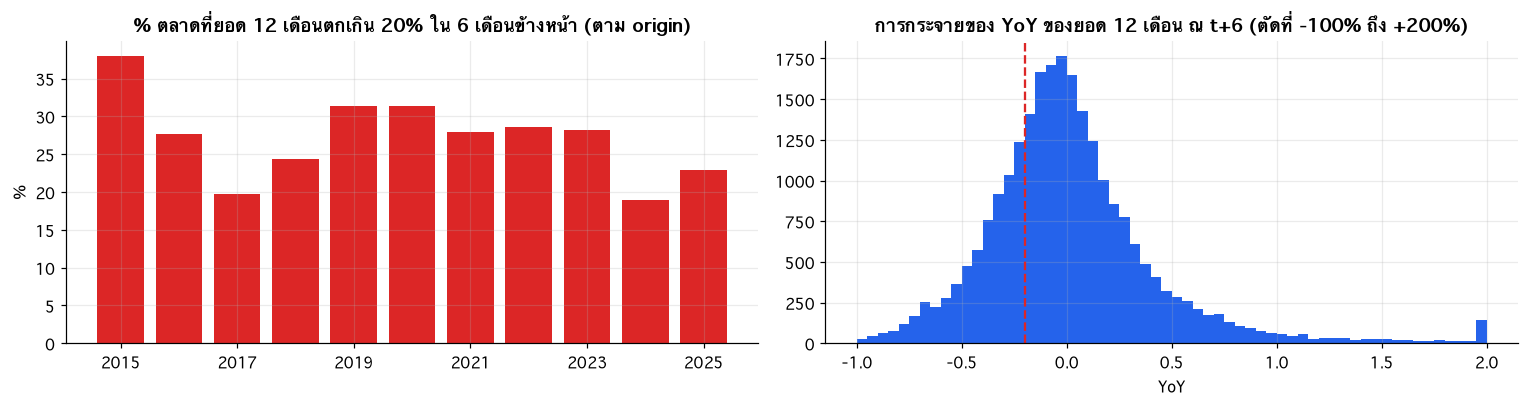

,origin,hs4,iso2,base,fut,yoy_cur,known_ratio,proj3,yoy_fut,y
9,2015-01-01,0301,CN,"2,740,021.54","2,241,721.26",0.14,0.42,-0.27,-0.18,0.00
16,2015-01-01,0301,HK,"8,172,457.38","5,990,610.71",-0.21,0.37,-0.26,-0.27,1.00
22,2015-01-01,0301,IR,"1,195,800.92","1,246,893.33",0.06,0.43,-0.15,0.04,0.00
45,2015-01-01,0301,RU,"1,275,253.85","847,159.24",-0.21,0.40,-0.28,-0.34,1.00


In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

EW_H, EW_THR, EW_MIN_BASE = 6, 0.20, 1_000_000
EWF = ["yoy_cur", "base_log", "known_ratio", "proj3", "proj12", "known_yoy", "base_trend", "S12_log", "mom3_12", "std6", "std12", "active12", "since_last", "uv12", "share_ctry12", "share_hs12", "lag0", "mean3", "mean12"]

def ew_build(Xs, H=None):
    """ตัวแปรและยอด 12 เดือนอนาคต จากเมทริกซ์ (เดือน × อนุกรม): ตัวแปรใช้ shift ย้อนหลังเท่านั้น (ยกเว้น fut ที่ใช้ทำป้าย)
    ป้าย = S12(t+H) ÷ S12(t+H-12) - 1 ; หน้าต่างที่ 'รู้แล้ว' ณ เดือน t ยาว 12-H เดือน (H = 6 -> 6 เดือน)"""
    H = H or EW_H
    S12 = Xs.rolling(12).sum(); kn = Xs.rolling(12 - H).sum(); m3, m12 = Xs.rolling(3).mean(), Xs.rolling(12).mean()
    base = S12.shift(12 - H); nb = base.replace(0, np.nan)
    f = {"yoy_cur": S12 / S12.shift(12).replace(0, np.nan) - 1, "base_log": np.log1p(base), "known_ratio": kn / nb,
         "proj3": (kn + H * m3) / nb - 1, "proj12": (kn + H * m12) / nb - 1, "known_yoy": kn / kn.shift(12).replace(0, np.nan) - 1,
         "base_trend": base / S12.shift(12 - H + 12).replace(0, np.nan) - 1, "S12_log": np.log1p(S12)}
    f = {k: v.replace([np.inf, -np.inf], np.nan).clip(-1, 5) if k not in ("base_log", "S12_log") else v for k, v in f.items()}
    return f, base, S12.shift(-H)

def ew_dataset(H=None, thr=None):
    """ตาราง origin × อนุกรม พร้อมป้ายกำกับ y (ตกเกิน thr ภายใน H เดือน) และตัวแปร"""
    H = H or EW_H; thr = EW_THR if thr is None else thr
    fw, bw, ftw = ew_build(_Vu, H)
    sel = _Vu.index >= START_TRAIN; n_ = int(sel.sum()); S_ = _Vu.shape[1]
    D = pd.DataFrame({"origin": np.repeat(_Vu.index[sel], S_), "hs4": np.tile(_Vu.columns.get_level_values(0).astype(str), n_), "iso2": np.tile(_Vu.columns.get_level_values(1), n_),
                      "base": bw.loc[sel].to_numpy().ravel(), "fut": ftw.loc[sel].to_numpy().ravel(), **{k: v.loc[sel].to_numpy().ravel() for k, v in fw.items()}})
    D = D.merge(PN[["origin", "hs4", "iso2", "mom3_12", "std6", "std12", "active12", "since_last", "uv12", "share_ctry12", "share_hs12", "lag0", "mean3", "mean12"]].assign(hs4=lambda d: d.hs4.astype(str)), on=["origin", "hs4", "iso2"], how="left")
    D["yoy_fut"] = D.fut / D.base.where(D.base > 0) - 1
    D["inpop"] = D.base >= EW_MIN_BASE
    D["y"] = np.where(D.yoy_fut.notna(), (D.yoy_fut < -thr).astype(float), np.nan)
    D["loss"] = np.maximum(D.base - D.fut, 0)
    D["hs4"] = pd.Categorical(D.hs4, categories=SEAFOOD_HS4)
    return D

feat_w, _, _ = ew_build(_Vu)
E = ew_dataset()
S_ = _Vu.shape[1]
lab = E[E.y.notna() & E.inpop]
print(f"แถวทั้งหมด {len(E):,} | อยู่ในประชากร (ฐาน ≥ 1 ล้าน) และมีป้ายกำกับ {len(lab):,} | อนุกรมที่เข้าเกณฑ์ในบางช่วง {lab.groupby(['hs4', 'iso2'], observed=True).ngroups} จาก {S_}")
print(f"อัตราคลาสบวก (ตกเกิน {EW_THR:.0%}): {lab.y.mean():.1%}")
yr = lab.assign(ปี=lab.origin.dt.year).groupby("ปี").agg(แถว=("y", "size"), คลาสบวก=("y", "mean"))
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
ax[0].bar(yr.index, yr.คลาสบวก * 100, color=C["red"]); ax[0].set(title="% ตลาดที่ยอด 12 เดือนตกเกิน 20% ใน 6 เดือนข้างหน้า (ตาม origin)", ylabel="%", xticks=yr.index[::2])
ax[1].hist(lab.yoy_fut.clip(-1, 2), bins=60, color=C["blue"]); ax[1].axvline(-EW_THR, color=C["red"], ls="--"); ax[1].set(title="การกระจายของ YoY ของยอด 12 เดือน ณ t+6 (ตัดที่ -100% ถึง +200%)", xlabel="YoY")
plt.tight_layout(); plt.show()
display(lab.head(4)[["origin", "hs4", "iso2", "base", "fut", "yoy_cur", "known_ratio", "proj3", "yoy_fut", "y"]])

In [84]:
# ทดสอบการรั่วไหล: ตัดข้อมูลหลังเดือน t ทิ้งแล้วสร้างตัวแปรใหม่ ค่าของเดือน t ต้องเท่าเดิม
rows = []
for o in (pd.Timestamp("2016-06-01"), pd.Timestamp("2021-03-01"), pd.Timestamp("2025-09-01")):
    f_t, _, _ = ew_build(_Vu.loc[:o])
    diff = max(np.nanmax(np.abs(f_t[k].loc[o].to_numpy() - feat_w[k].loc[o].to_numpy())) for k in f_t)
    same_na = all((np.isnan(f_t[k].loc[o].to_numpy()) == np.isnan(feat_w[k].loc[o].to_numpy())).all() for k in f_t)
    rows.append((f"{o:%Y-%m}", diff, same_na))
leak2 = pd.DataFrame(rows, columns=["origin ที่ทดสอบ", "ผลต่างสูงสุดหลังตัดอนาคต", "ตำแหน่งค่าว่างตรงกัน"]); display(leak2)
assert (leak2["ผลต่างสูงสุดหลังตัดอนาคต"] < 1e-9).all() and leak2["ตำแหน่งค่าว่างตรงกัน"].all()
print("✅ ผ่าน: ตัวแปรของ Early Warning ไม่ใช้ข้อมูลหลังเดือน t")

,origin ที่ทดสอบ,ผลต่างสูงสุดหลังตัดอนาคต,ตำแหน่งค่าว่างตรงกัน
0,2016-06,0.00,True
1,2021-03,0.00,True
2,2025-09,0.00,True


✅ ผ่าน: ตัวแปรของ Early Warning ไม่ใช้ข้อมูลหลังเดือน t


### 📝 อ่านผล: ข้อมูลของ Early Warning

- **24,172 แถวที่เข้าประชากร** (ยอดฐาน ≥ 1 ล้านดอลลาร์ และรู้ป้ายแล้ว) จาก 241 อนุกรมที่เข้าเกณฑ์ในบางช่วงเวลา (จาก 332) **อัตราคลาสบวก 27.3%** (ไม่เอียงมาก ไม่ต้องใช้เทคนิคจัดการ imbalance)
- **อัตราตลาดที่ตกต่างกันตามปี:** 38% (2015) → 20% (2017) → 31% (2019–2020) → 28% (2021–2023) → **19% (2024)** → 23% (2025) ช่วงทดสอบ (2023–2025) จึงมีอัตราต่ำกว่าช่วงเทรน/ตรวจสอบ ซึ่งต้องจำไว้เวลาเทียบค่า PR-AUC (ค่าตั้งต้นของการสุ่มคือเท่ากับอัตราคลาสบวก)
- **การทดสอบรั่วไหลผ่าน:** ตัดข้อมูลหลังเดือนที่ประเมินทิ้งแล้วสร้างตัวแปรใหม่ ได้ค่าเท่าเดิมทุกหลักใน 3 ช่วงเวลาที่ทดสอบ

### 4.4.2 ฟังก์ชัน rolling-origin และโมเดล

In [85]:
EW_VAL = [o for o in sorted(E.origin.unique()) if pd.Timestamp("2019-04-01") <= o <= pd.Timestamp("2022-03-01")]
EW_TEST = [o for o in sorted(E.origin.unique()) if pd.Timestamp("2023-04-01") <= o and o + pd.DateOffset(months=EW_H) <= LAST_MONTH]
if FAST: EW_VAL, EW_TEST = EW_VAL[:3], EW_TEST[:3]
print(f"origin ตรวจสอบ {len(EW_VAL)} จุด | origin ทดสอบ {len(EW_TEST)} จุด ({pd.Timestamp(EW_TEST[0]):%Y-%m} – {pd.Timestamp(EW_TEST[-1]):%Y-%m})")

def design_ew(df, cols=None, onehot=True):
    d = df[EWF].reset_index(drop=True)
    if onehot: d = pd.concat([d, pd.get_dummies(df.hs4.astype(str), prefix="hs").reset_index(drop=True)], axis=1)
    return d if cols is None else d.reindex(columns=cols, fill_value=0)

def lr_model(tr, te):
    Xtr = design_ew(tr); Xte = design_ew(te, Xtr.columns)
    m = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(C=0.3, max_iter=3000)).fit(Xtr, tr.y)
    return m.predict_proba(Xte)[:, 1]
def rf_model(tr, te):
    Xtr = design_ew(tr); Xte = design_ew(te, Xtr.columns)
    m = make_pipeline(SimpleImputer(strategy="median"), RandomForestClassifier(n_estimators=200, min_samples_leaf=25, max_features="sqrt", n_jobs=-1, random_state=0)).fit(Xtr, tr.y)
    return m.predict_proba(Xte)[:, 1]
def lgb_model(tr, te):
    cols = EWF + ["hs4"]
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=50, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1, random_state=0, n_jobs=4).fit(tr[cols], tr.y)
    return m.predict_proba(te[cols])[:, 1]

def ew_rolling(fn, origins):
    out = []
    for T in origins:
        T = pd.Timestamp(T)
        tr = E[(E.origin + pd.DateOffset(months=EW_H) <= T) & E.y.notna() & E.inpop]
        te = E[(E.origin == T) & E.y.notna() & E.inpop]
        out.append(te[["origin", "hs4", "iso2", "y", "base", "fut", "loss"]].assign(p=fn(tr, te)))
    return pd.concat(out, ignore_index=True)
print("พร้อม")

origin ตรวจสอบ 36 จุด | origin ทดสอบ 31 จุด (2023-04 – 2025-10)
พร้อม


### 4.4.3 ช่วงตรวจสอบ: เลือก baseline หลักและโมเดลหลัก

In [86]:
EW_CACHE = CACHE / "ew_predictions.csv"
if RETUNE or not EW_CACHE.exists():
    parts = []
    for split, origs in (("val", EW_VAL), ("test", EW_TEST)):
        for name, fn in (("Logistic Regression", lr_model), ("Random Forest", rf_model), ("LightGBM", lgb_model)):
            parts.append(ew_rolling(fn, origs).assign(model=name, split=split))
    pd.concat(parts, ignore_index=True).to_csv(EW_CACHE, index=False, encoding="utf-8-sig")
EP = rd(EW_CACHE, dtype={"hs4": str}, parse_dates=["origin"])
# baseline คำนวณจากตัวแปรโดยตรง (ไม่ต้องเทรน): คะแนนความเสี่ยง = -YoY ปัจจุบัน / -ยอดคาดการณ์ run-rate
key = E.set_index(["origin", "hs4", "iso2"])[["yoy_cur", "proj3"]]
def with_base(split):
    d = EP[(EP.split == split) & (EP.model == "LightGBM")][["origin", "hs4", "iso2", "y", "base", "fut", "loss"]].copy()
    k = key.reindex(pd.MultiIndex.from_frame(d[["origin", "hs4", "iso2"]]))
    d["persistence"], d["runrate"], d["prior"] = -k.yoy_cur.fillna(0).to_numpy(), -k.proj3.fillna(0).to_numpy(), 0.0
    return d
BV, BT = with_base("val"), with_base("test")
def score_tab(split, BD):
    r = {"อัตราฐาน (สุ่ม)": average_precision_score(BD.y, np.full(len(BD), BD.y.mean())), "Persistence (ตกอยู่ตอนนี้ แล้วตกต่อ)": average_precision_score(BD.y, BD.persistence), "Run-rate (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน)": average_precision_score(BD.y, BD.runrate)}
    for m_ in ("Logistic Regression", "Random Forest", "LightGBM"):
        d = EP[(EP.split == split) & (EP.model == m_)]; r[m_] = average_precision_score(d.y, d.p)
    return pd.Series(r)
vt_ = score_tab("val", BV).to_frame("PR-AUC ช่วงตรวจสอบ"); vt_["ROC-AUC"] = [0.5, roc_auc_score(BV.y, BV.persistence), roc_auc_score(BV.y, BV.runrate)] + [roc_auc_score(*(lambda d: (d.y, d.p))(EP[(EP.split == "val") & (EP.model == m_)])) for m_ in ("Logistic Regression", "Random Forest", "LightGBM")]
print(f"ช่วงตรวจสอบ: {len(BV):,} แถว | อัตราคลาสบวก {BV.y.mean():.1%}"); show(vt_)
EW_BASES = ["Persistence (ตกอยู่ตอนนี้ แล้วตกต่อ)", "Run-rate (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน)"]
EW_PB = vt_.loc[EW_BASES, "PR-AUC ช่วงตรวจสอบ"].idxmax(); EW_BEST = vt_.loc[["Logistic Regression", "Random Forest", "LightGBM"], "PR-AUC ช่วงตรวจสอบ"].idxmax()
print(f"➡ baseline หลัก = {EW_PB} | โมเดลหลัก = {EW_BEST}")

ช่วงตรวจสอบ: 6,699 แถว | อัตราคลาสบวก 29.6%


,PR-AUC ช่วงตรวจสอบ,ROC-AUC
อัตราฐาน (สุ่ม),0.296,0.500
Persistence (ตกอยู่ตอนนี้ แล้วตกต่อ),0.593,0.739
Run-rate (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน),0.806,0.914
Logistic Regression,0.821,0.924
Random Forest,0.833,0.928
LightGBM,0.827,0.925


➡ baseline หลัก = Run-rate (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน) | โมเดลหลัก = Random Forest


### 📝 อ่านผล: ช่วงตรวจสอบ

| วิธี | PR-AUC | ROC-AUC |
|---|---|---|
| อัตราฐาน (สุ่ม) | 0.296 | 0.500 |
| Persistence (ตกอยู่ตอนนี้ แล้วตกต่อ) | 0.593 | 0.739 |
| **Run-rate** (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน) | **0.806** | **0.914** |
| Logistic Regression | 0.821 | 0.924 |
| **Random Forest** | **0.833** | 0.928 |
| LightGBM | 0.827 | 0.925 |

- **Run-rate (กฎง่าย ๆ ไม่ใช้ ML) แข็งมาก** PR-AUC 0.806 เกือบเท่าโมเดล ML และดีกว่า persistence มาก (0.593) เพราะ 6 เดือนล่าสุดของหน้าต่าง 12 เดือนเป็นข้อมูลที่ "รู้แล้ว" จึงตัดสินป้ายไปได้มาก → ตามกฎ **baseline หลัก = Run-rate** ซึ่งแข็งกว่า persistence ที่คาดไว้ตอนวางแผน
- **โมเดลหลัก = Random Forest** (PR-AUC สูงสุดบนช่วงตรวจสอบ) แต่ทั้งสามโมเดลต่างกันน้อยมาก (0.821–0.833)

### 4.4.4 ผลช่วงทดสอบ (พ.ค. 2023 – ต.ค. 2025)

ช่วงทดสอบ: 5,686 แถว (31 origin) | อัตราคลาสบวก 22.5% | baseline หลัก = Run-rate (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน)


,PR-AUC,ROC-AUC,Precision เตือน 10%,Recall เตือน 10%,Recall ถ่วงมูลค่า 10%,Precision เตือน 20%,Recall เตือน 20%,Recall ถ่วงมูลค่า 20%
โมเดล,,,,,,,,
อัตราฐาน (สุ่ม),0.218,0.483,0.215,0.099,0.076,0.228,0.205,0.194
Persistence (ตกอยู่ตอนนี้ แล้วตกต่อ),0.519,0.720,0.646,0.296,0.256,0.529,0.475,0.460
Run-rate (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน),0.792,0.917,0.874,0.400,0.407,0.742,0.667,0.678
Logistic Regression,0.814,0.931,0.894,0.409,0.419,0.757,0.681,0.685
Random Forest,0.827,0.936,0.887,0.406,0.480,0.760,0.683,0.722
LightGBM,0.832,0.938,0.894,0.409,0.504,0.772,0.694,0.723


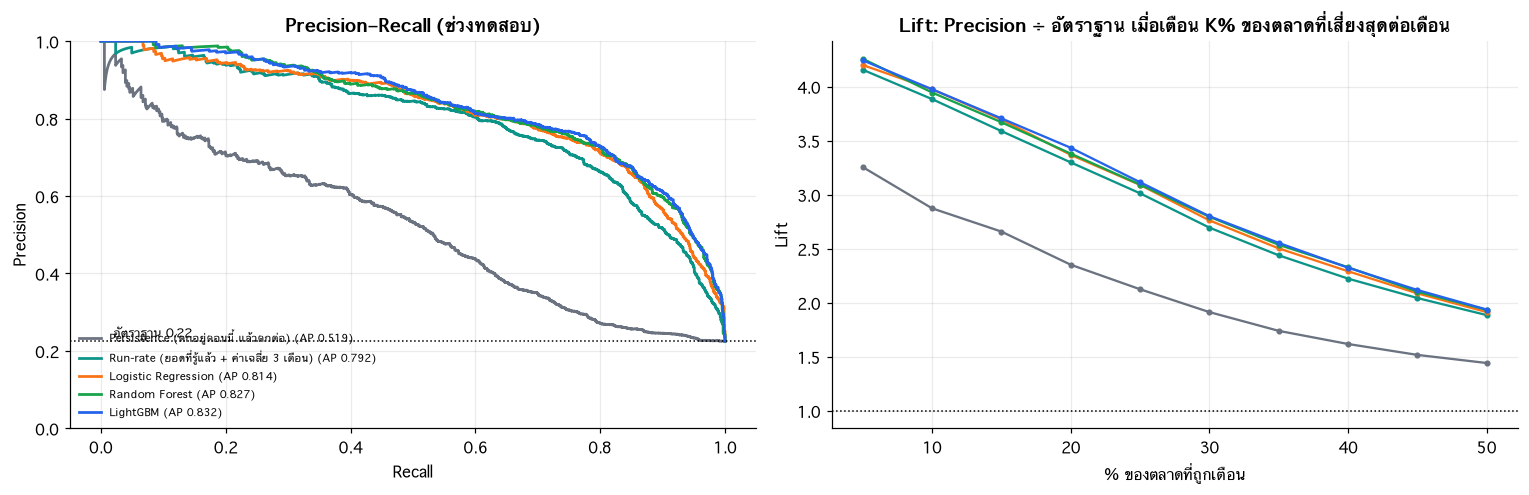

In [87]:
def topk(d, col, k):
    """เตือนตลาดที่เสี่ยงสุด k% ในแต่ละ origin แล้วรวมผลทุก origin"""
    d = d.copy(); d["flag"] = d.groupby("origin")[col].rank(ascending=False, method="first") <= d.groupby("origin")[col].transform(lambda s: np.ceil(len(s) * k))
    tp = (d.flag & (d.y == 1)).sum(); return tp / d.flag.sum(), tp / (d.y == 1).sum(), (d.loss * (d.flag & (d.y == 1))).sum() / (d.loss * (d.y == 1)).sum()

TE_ALL = {"อัตราฐาน (สุ่ม)": BT.assign(s=0.0 + np.random.default_rng(0).random(len(BT))), EW_BASES[0]: BT.assign(s=BT.persistence), EW_BASES[1]: BT.assign(s=BT.runrate)}
for m_ in ("Logistic Regression", "Random Forest", "LightGBM"): TE_ALL[m_] = EP[(EP.split == "test") & (EP.model == m_)].assign(s=lambda d: d.p)
rows = []
for k_, d in TE_ALL.items():
    r = {"โมเดล": k_, "PR-AUC": average_precision_score(d.y, d.s), "ROC-AUC": roc_auc_score(d.y, d.s)}
    for K in (0.1, 0.2):
        p_, r_, w_ = topk(d, "s", K); r.update({f"Precision เตือน {K:.0%}": p_, f"Recall เตือน {K:.0%}": r_, f"Recall ถ่วงมูลค่า {K:.0%}": w_})
    rows.append(r)
ewr = pd.DataFrame(rows).set_index("โมเดล")
prev = BT.y.mean()
print(f"ช่วงทดสอบ: {len(BT):,} แถว ({len(EW_TEST)} origin) | อัตราคลาสบวก {prev:.1%} | baseline หลัก = {EW_PB}")
show(ewr)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
cols_ = {"Persistence (ตกอยู่ตอนนี้ แล้วตกต่อ)": C["gray"], "Run-rate (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน)": C["teal"], "Logistic Regression": C["orange"], "Random Forest": C["green"], "LightGBM": C["blue"]}
for k_, c_ in cols_.items():
    d = TE_ALL[k_]; pr_, rc_, _ = precision_recall_curve(d.y, d.s); ax[0].plot(rc_, pr_, color=c_, label=f"{k_} (AP {average_precision_score(d.y, d.s):.3f})", lw=1.8)
ax[0].axhline(prev, color="k", ls=":", lw=1); ax[0].text(0.02, prev + .01, f"อัตราฐาน {prev:.2f}", fontsize=8)
ax[0].set(title="Precision–Recall (ช่วงทดสอบ)", xlabel="Recall", ylabel="Precision", ylim=(0, 1)); ax[0].legend(frameon=False, fontsize=7, loc="lower left")
ks = np.arange(0.05, 0.55, 0.05)
for k_, c_ in cols_.items(): ax[1].plot(ks * 100, [topk(TE_ALL[k_], "s", K)[0] / prev for K in ks], color=c_, marker="o", ms=3, label=k_)
ax[1].axhline(1, color="k", ls=":", lw=1); ax[1].set(title="Lift: Precision ÷ อัตราฐาน เมื่อเตือน K% ของตลาดที่เสี่ยงสุดต่อเดือน", xlabel="% ของตลาดที่ถูกเตือน", ylabel="Lift")
plt.tight_layout(); plt.show()

### 📝 อ่านผล: ช่วงทดสอบ (31 origin, 5,686 แถว, อัตราคลาสบวก 22.5%)

| วิธี | PR-AUC | ROC-AUC | Precision เตือน 10% | Precision เตือน 20% | Recall ถ่วงมูลค่า 10% / 20% |
|---|---|---|---|---|---|
| อัตราฐาน (สุ่ม) | 0.218 | 0.483 | 0.215 | 0.228 | 0.08 / 0.19 |
| Persistence | 0.519 | 0.720 | 0.646 | 0.529 | 0.26 / 0.46 |
| **Run-rate (baseline หลัก)** | **0.792** | 0.917 | 0.874 | 0.742 | 0.41 / 0.68 |
| Logistic Regression | 0.814 | 0.931 | 0.894 | 0.757 | 0.42 / 0.69 |
| **Random Forest (โมเดลหลัก)** | **0.827** | 0.936 | 0.887 | 0.760 | 0.48 / 0.72 |
| LightGBM | **0.832** | 0.938 | 0.894 | 0.772 | 0.50 / 0.72 |

- **H3 ได้รับการสนับสนุน:** Random Forest (โมเดลที่เลือกจากช่วงตรวจสอบ) PR-AUC 0.827 สูงกว่า baseline หลัก 0.792 และสูงกว่าอัตราฐาน (0.218) ราว 3.8 เท่า LightGBM บนช่วงทดสอบสูงกว่าเล็กน้อย (0.832) แต่ต่างกันเพียง 0.005 ซึ่งอยู่ในระดับสัญญาณรบกวน
- **ใช้งานจริงได้ดีกว่าการพยากรณ์ยอดมาก:** ถ้าเตือนตลาดที่เสี่ยงสุด **10%** ต่อเดือน ตลาดที่เตือนตกจริง **~89%** (lift ราว 4 เท่า) และครอบคลุมมูลค่าที่หายไปจริง 48–50%; ถ้าเตือน **20%** ตกจริง ~76–77% และครอบคลุมมูลค่าที่หายไป ~72%
- **Persistence ("ตกอยู่แล้วจะตกต่อ") อ่อนมาก** (0.519, ROC 0.720) เพราะไม่ได้ใช้ข้อมูลว่า 6 เดือนล่าสุดของหน้าต่างเป็นอย่างไร
- **Run-rate (ไม่ใช้ ML) ได้ 0.792 ซึ่งใกล้โมเดล ML มาก** → ความสามารถในการทำนายส่วนใหญ่เป็นเรื่องของ *เลขคณิต* (ครึ่งหนึ่งของหน้าต่าง 12 เดือนรู้แล้ว) ไม่ใช่การเดาอนาคตล้วน ๆ ส่วนที่ ML เพิ่มให้เป็นการปรับแต่งเล็กน้อย

In [88]:
# ความต่างมีนัยสำคัญไหม: bootstrap ข้าม origin (เดือน) ของ PR-AUC เทียบ baseline หลัก
def boot_ap(a, b, B=2000, seed=0):
    rng = np.random.default_rng(seed); da, db = TE_ALL[a], TE_ALL[b]
    oa = {o: g for o, g in da.groupby("origin")}; ob = {o: g for o, g in db.groupby("origin")}; os_ = list(oa)
    diffs = []
    for _ in range(B):
        pick = rng.choice(len(os_), len(os_), replace=True)
        A = pd.concat([oa[os_[i]] for i in pick]); Bm = pd.concat([ob[os_[i]] for i in pick])
        diffs.append(average_precision_score(A.y, A.s) - average_precision_score(Bm.y, Bm.s))
    return average_precision_score(da.y, da.s) - average_precision_score(db.y, db.s), np.percentile(diffs, [2.5, 97.5])
cmpr = []
for a, b in list(dict.fromkeys([(EW_BEST, EW_PB), (EW_BEST, EW_BASES[0] if EW_PB != EW_BASES[0] else EW_BASES[1]), ("LightGBM", "Logistic Regression"), ("Random Forest", EW_PB), ("LightGBM", EW_PB)])):
    if a == b: continue
    o, ci = boot_ap(a, b); cmpr.append((f"{a} − {b}", o, ci[0], ci[1], "ใช่" if ci[0] > 0 else ("ไม่ (แย่กว่า)" if ci[1] < 0 else "ยังบอกไม่ได้ (ช่วงคร่อม 0)")))
show(pd.DataFrame(cmpr, columns=["เปรียบเทียบ (PR-AUC a − b)", "ผลต่าง", "ช่วง 95% ล่าง", "ช่วง 95% บน", "a ดีกว่า b อย่างมีนัยสำคัญ?"]))

,เปรียบเทียบ (PR-AUC a − b),ผลต่าง,ช่วง 95% ล่าง,ช่วง 95% บน,a ดีกว่า b อย่างมีนัยสำคัญ?
0,Random Forest − Run-rate (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน),0.034,0.027,0.043,ใช่
1,Random Forest − Persistence (ตกอยู่ตอนนี้ แล้วตกต่อ),0.308,0.282,0.334,ใช่
2,LightGBM − Logistic Regression,0.017,0.010,0.025,ใช่
3,LightGBM − Run-rate (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน),0.039,0.031,0.048,ใช่


### 📝 อ่านผล: ความต่างจริงหรือแค่โชค

| เปรียบเทียบ | ผลต่าง PR-AUC | ช่วง 95% | สรุป |
|---|---|---|---|
| **Random Forest − Run-rate** | **+0.034** | [+0.027, +0.043] | ✅ ดีกว่าอย่างมีนัยสำคัญ (เล็ก) |
| **LightGBM − Run-rate** | +0.039 | [+0.031, +0.048] | ✅ ดีกว่าอย่างมีนัยสำคัญ (เล็ก) |
| Random Forest − Persistence | +0.308 | [+0.282, +0.334] | ✅ ดีกว่ามาก |
| LightGBM − Logistic Regression | +0.017 | [+0.010, +0.025] | ✅ ดีกว่าเล็กน้อย |

- **ส่วนที่ ML เพิ่มให้เหนือกฎ run-rate คือ +0.034–0.039 PR-AUC (ราว 4–5%)** ช่วงความเชื่อมั่นไม่คร่อมศูนย์ เป็นขนาดใกล้เคียงกับที่เห็นในการพยากรณ์ (ML เหนือ SES ราว 5%) → ข้อสรุปทั้งโปรเจกต์สอดคล้องกัน: *ML ช่วยได้จริงแต่เพิ่มคุณค่าเหนือกฎง่าย ๆ ไม่มาก*
- ข้อควรระวัง: bootstrap ข้ามเดือนถือเดือนเป็นอิสระต่อกัน ซึ่งไม่จริงทั้งหมด ช่วงจริงอาจกว้างกว่า

### 4.4.5 โมเดลช่วยตรงไหน

In [89]:
T_ = TE_ALL[EW_BEST].copy(); P_ = TE_ALL[EW_PB]
T_["กลุ่มตลาด"] = T_.iso2.map(cl_map).fillna("นอกกลุ่ม").str.split().str[0]
T_["ปีทดสอบ"] = np.where(T_.origin < "2024-04-01", "พ.ค.2023–เม.ย.2024", np.where(T_.origin < "2025-04-01", "พ.ค.2024–เม.ย.2025", "พ.ค.2025–ต.ค.2025"))
def seg_ap(key):
    out = []
    for g_, d in T_.groupby(key, observed=True):
        pb = P_.merge(d[["origin", "hs4", "iso2"]], on=["origin", "hs4", "iso2"])
        if d.y.nunique() < 2: continue
        out.append((g_, len(d), d.y.mean(), average_precision_score(d.y, d.s), average_precision_score(pb.y, pb.s), roc_auc_score(d.y, d.s)))
    return pd.DataFrame(out, columns=[key, "แถว", "อัตราคลาสบวก", f"PR-AUC {EW_BEST}", f"PR-AUC {EW_PB[:10]}", "ROC-AUC"]).set_index(key)
for key in ("กลุ่มตลาด", "hs4", "ปีทดสอบ"): print(f"== แยกตาม{key}"); show(seg_ap(key))

== แยกตามกลุ่มตลาด


,แถว,อัตราคลาสบวก,PR-AUC Random Forest,PR-AUC Run-rate (,ROC-AUC
กลุ่มตลาด,,,,,
A,3696,0.200,0.835,0.794,0.947
B,1052,0.296,0.812,0.801,0.902
C,707,0.184,0.803,0.767,0.939
D,185,0.303,0.827,0.750,0.933
นอกกลุ่ม,46,0.891,0.996,0.994,0.966


== แยกตามhs4


,แถว,อัตราคลาสบวก,PR-AUC Random Forest,PR-AUC Run-rate (,ROC-AUC
hs4,,,,,
0301,156,0.083,0.765,0.794,0.961
0302,153,0.477,0.915,0.922,0.920
0303,405,0.356,0.888,0.891,0.937
0304,359,0.156,0.827,0.785,0.960
0305,307,0.261,0.780,0.747,0.896
0306,565,0.308,0.860,0.827,0.922
0307,465,0.138,0.825,0.782,0.950
0308,88,0.341,0.848,0.832,0.891
1604,2663,0.188,0.808,0.779,0.943


== แยกตามปีทดสอบ


,แถว,อัตราคลาสบวก,PR-AUC Random Forest,PR-AUC Run-rate (,ROC-AUC
ปีทดสอบ,,,,,
พ.ค.2023–เม.ย.2024,2196,0.250,0.831,0.804,0.932
พ.ค.2024–เม.ย.2025,2215,0.192,0.843,0.784,0.949
พ.ค.2025–ต.ค.2025,1275,0.239,0.802,0.782,0.922


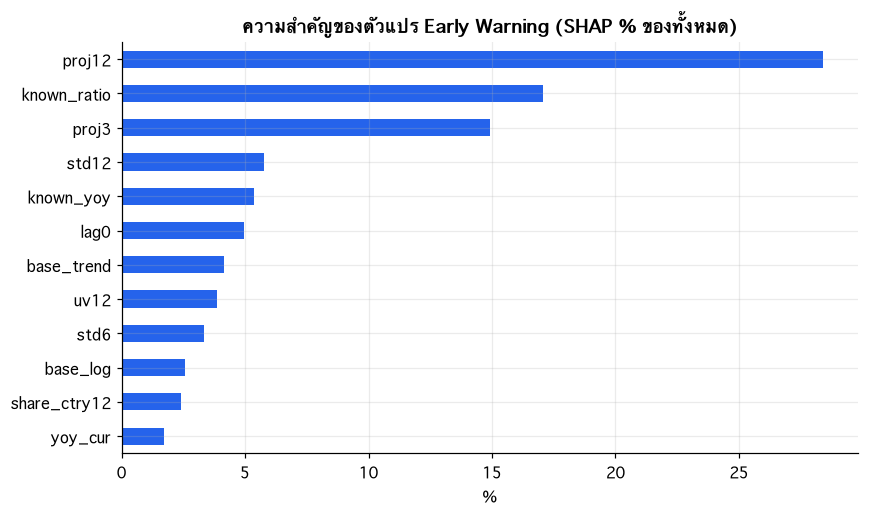

,SHAP %
proj12,28.402
known_ratio,17.067
proj3,14.918
std12,5.773
known_yoy,5.361
lag0,4.940
base_trend,4.138
uv12,3.852


In [90]:
# ตัวแปรที่โมเดลหลักใช้ (LightGBM ถ้าเป็นโมเดลหลัก; ไม่เช่นนั้นแสดง LightGBM เป็นตัวอ้างอิง) — SHAP จาก pred_contrib
last_T = pd.Timestamp(EW_TEST[-1])
trf = E[(E.origin + pd.DateOffset(months=EW_H) <= last_T) & E.y.notna() & E.inpop]
mf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=50, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1, random_state=0, n_jobs=4).fit(trf[EWF + ["hs4"]], trf.y)
ev = E[(E.origin > last_T - pd.DateOffset(months=12)) & (E.origin <= last_T) & E.y.notna() & E.inpop]
ct = mf.booster_.predict(ev[EWF + ["hs4"]], pred_contrib=True)[:, :-1]
imp2 = pd.Series(np.abs(ct).mean(axis=0), index=EWF + ["hs4"]); imp2 = (imp2 / imp2.sum() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.8)); imp2.head(12).iloc[::-1].plot.barh(ax=ax, color=C["blue"]); ax.set(title="ความสำคัญของตัวแปร Early Warning (SHAP % ของทั้งหมด)", xlabel="%"); plt.tight_layout(); plt.show()
show(imp2.head(8).to_frame("SHAP %"))

In [91]:
# วัด "การเตือนก่อนตก" จริง: เฉพาะตลาดที่ *ยังไม่ตก* ณ วันที่ประเมิน (YoY ปัจจุบัน ≥ -20%) — ตัดกรณีที่ตกอยู่แล้วออก
kk = E.set_index(["origin", "hs4", "iso2"])[["yoy_cur"]]
sub = []
for k_ in ("Persistence (ตกอยู่ตอนนี้ แล้วตกต่อ)", EW_BASES[1], "Logistic Regression", "Random Forest", "LightGBM"):
    d = TE_ALL[k_]; yc_ = kk.reindex(pd.MultiIndex.from_frame(d[["origin", "hs4", "iso2"]])).yoy_cur.to_numpy()
    m = d[yc_ >= -EW_THR]
    p20 = topk(m, "s", 0.2)
    sub.append((k_, len(m), m.y.mean(), average_precision_score(m.y, m.s), roc_auc_score(m.y, m.s), p20[0], p20[1]))
subt = pd.DataFrame(sub, columns=["โมเดล", "แถว", "อัตราคลาสบวก", "PR-AUC", "ROC-AUC", "Precision เตือน 20%", "Recall เตือน 20%"]).set_index("โมเดล")
print("เฉพาะตลาดที่ยังไม่ตก ณ วันประเมิน (YoY ปัจจุบัน ≥ -20%) — วัดความสามารถในการเตือน 'ก่อน' ตกจริง:"); show(subt)

# calibration ของโมเดลหลัก: ความน่าจะเป็นที่ให้ vs สัดส่วนที่ตกจริง
cb = T_.assign(bin=pd.qcut(T_.s, 10, duplicates="drop")).groupby("bin", observed=True).agg(ความน่าจะเป็นเฉลี่ย=("s", "mean"), สัดส่วนที่ตกจริง=("y", "mean"), แถว=("y", "size"))
print(f"Calibration ของ {EW_BEST} (แบ่ง 10 กลุ่มตามความน่าจะเป็น):"); show(cb.reset_index(drop=True))
print(f"ค่าเฉลี่ยความน่าจะเป็นที่ให้ = {T_.s.mean():.3f} | สัดส่วนตกจริง = {T_.y.mean():.3f} | Brier = {np.mean((T_.s - T_.y) ** 2):.4f} (อัตราฐานคงที่ = {np.mean((T_.y.mean() - T_.y) ** 2):.4f})")

เฉพาะตลาดที่ยังไม่ตก ณ วันประเมิน (YoY ปัจจุบัน ≥ -20%) — วัดความสามารถในการเตือน 'ก่อน' ตกจริง:


,แถว,อัตราคลาสบวก,PR-AUC,ROC-AUC,Precision เตือน 20%,Recall เตือน 20%
โมเดล,,,,,,
Persistence (ตกอยู่ตอนนี้ แล้วตกต่อ),4453,0.141,0.178,0.548,0.188,0.270
Run-rate (ยอดที่รู้แล้ว + ค่าเฉลี่ย 3 เดือน),4453,0.141,0.674,0.904,0.517,0.743
Logistic Regression,4453,0.141,0.706,0.919,0.530,0.762
Random Forest,4453,0.141,0.706,0.924,0.540,0.776
LightGBM,4453,0.141,0.718,0.927,0.546,0.784


Calibration ของ Random Forest (แบ่ง 10 กลุ่มตามความน่าจะเป็น):


,ความน่าจะเป็นเฉลี่ย,สัดส่วนที่ตกจริง,แถว
0,0.001,0.007,569
1,0.005,0.000,569
2,0.012,0.004,568
3,0.025,0.026,569
4,0.054,0.033,568
5,0.115,0.072,569
6,0.235,0.167,568
7,0.424,0.374,569
8,0.690,0.674,568
9,0.908,0.891,569


ค่าเฉลี่ยความน่าจะเป็นที่ให้ = 0.247 | สัดส่วนตกจริง = 0.225 | Brier = 0.0812 (อัตราฐานคงที่ = 0.1743)


### 📝 อ่านผล: ตรงไหนได้ผล / การเตือน "ก่อน" ตกจริง

**1) วัดเฉพาะตลาดที่ "ยังไม่ตก" ณ วันประเมิน (YoY ปัจจุบัน ≥ −20%; 4,453 แถว, คลาสบวก 14.1%)** — ส่วนนี้คือการเตือนล่วงหน้าที่แท้จริง เพราะตัดกรณีที่ตกอยู่แล้วออก:
| วิธี | PR-AUC | ROC-AUC | Precision เตือน 20% | Recall เตือน 20% |
|---|---|---|---|---|
| Persistence | **0.178** | 0.548 | 0.188 | 0.270 |
| Run-rate | 0.674 | 0.904 | 0.517 | 0.743 |
| Logistic Regression | 0.706 | 0.919 | 0.530 | 0.762 |
| Random Forest | 0.706 | 0.924 | 0.540 | 0.776 |
| LightGBM | **0.718** | **0.927** | 0.546 | 0.784 |

→ **Persistence ใช้ไม่ได้เลยเมื่อเป็นการเตือน "ก่อน" ตก** (PR-AUC 0.178 ใกล้อัตราฐาน 0.141) ส่วนโมเดลได้ **0.71–0.72 (ราว 5 เท่าของอัตราฐาน)** เตือนตลาด 20% ที่เสี่ยงสุดครอบคลุมตลาดที่ตกจริง 76–78% ด้วยความแม่น ~54% ML เหนือ run-rate ราว +0.03–0.04

**2) แยกตามกลุ่มตลาด** (Random Forest เทียบ Run-rate): A 0.835 vs 0.794 · B 0.812 vs 0.801 · C 0.803 vs 0.767 · D 0.827 vs 0.750 — **ต่างจากการพยากรณ์ยอด การเตือนทำได้ใกล้เคียงกันทุกกลุ่ม** (0.80–0.84) รวมถึงตลาดเล็ก เพราะป้ายอิงยอดรวม 12 เดือนที่ผันผวนน้อยกว่ารายเดือนมาก

**3) แยกตามกลุ่มสินค้า:** Random Forest ดีกว่า run-rate ใน 7 จาก 10 กลุ่ม เล็กน้อยกว่าใน 0301 (0.765 vs 0.794), 0302, 0303 (ต่างน้อยมาก) กลุ่มใหญ่ 1604 ได้ 0.808 vs 0.779

**4) แยกตามช่วงเวลา:** RF 0.831 / 0.843 / 0.802 vs run-rate 0.804 / 0.784 / 0.782 → ได้เปรียบทุกช่วง (+0.027, +0.059, +0.020) แต่ไม่คงที่

**5) ตัวแปรสำคัญ (SHAP):** **`proj12` (ยอดคาดการณ์ถ้าค่าเฉลี่ย 12 เดือนคงที่) 28%, `known_ratio` (ส่วนที่รู้แล้วเทียบฐาน) 17%, `proj3` 15%** รวม 60% ตามด้วย `std12` 5.8%, `known_yoy` 5.4% → โมเดลส่วนใหญ่ "ปรับแต่งการคาดการณ์ run-rate" ไม่ได้ค้นพบสัญญาณใหม่ที่ต่างจากเลขคณิต

**6) ความน่าจะเป็นเชื่อถือได้ไหม (calibration ของ Random Forest):** ค่อนข้างตรง — กลุ่มความน่าจะเป็นสูงสุด คาด 0.908 ตกจริง 0.891; กลุ่มกลาง คาด 0.424 ตกจริง 0.374; กลุ่มต่ำ ๆ คาดสูงกว่าจริงเล็กน้อย (0.235 vs 0.167) ค่าเฉลี่ยที่ให้ 0.247 เทียบจริง 0.225 (ประเมินสูงเล็กน้อย สอดคล้องกับอัตราตลาดตกที่ลดลงในช่วงทดสอบ) **Brier score 0.081 ต่ำกว่าอัตราฐานคงที่ (0.174) ราว 53%**

### 4.4.6 ตัวอย่างการใช้งานจริง: รายชื่อตลาดที่ควรจับตา ณ เม.ย. 2026

ใช้โมเดลหลักที่เทรนด้วยข้อมูลที่รู้ป้ายทั้งหมด (origin ถึง ต.ค. 2025) ให้คะแนนความเสี่ยงตลาดที่ origin ล่าสุด (เม.ย. 2026) ซึ่งยังไม่รู้ผลจริง — **ป้ายของ origin นี้จะรู้ได้ราว ต.ค. 2026**

In [92]:
tr_all = E[E.y.notna() & E.inpop & (E.origin + pd.DateOffset(months=EW_H) <= LAST_MONTH)]
now = E[(E.origin == LAST_MONTH) & E.inpop]
fn_best = {"Logistic Regression": lr_model, "Random Forest": rf_model, "LightGBM": lgb_model}[EW_BEST]
now = now.assign(risk=fn_best(tr_all, now))
names = rd(PREP / "clusters_w2.csv").set_index("iso2").name_en.to_dict()
al = now.sort_values("risk", ascending=False).head(15)
al = al.assign(ตลาด=[names.get(i, i) for i in al.iso2], กลุ่มสินค้า=[HS4_NAME[str(h)] for h in al.hs4])
show(al[["ตลาด", "iso2", "กลุ่มสินค้า", "risk", "yoy_cur", "proj3", "base"]].rename(columns={"risk": "ความน่าจะเป็นที่ยอดตก > 20% ใน 6 เดือน", "yoy_cur": "YoY ปัจจุบัน", "proj3": "YoY ที่คาด (run-rate)", "base": "ยอดฐาน 12 เดือน (USD)"}).reset_index(drop=True))
print(f"ตลาดในประชากร ณ {LAST_MONTH:%Y-%m}: {len(now)} | คาดว่ามีความเสี่ยงสูง (ความน่าจะเป็น > 50%): {(now.risk > 0.5).sum()} ตลาด")
if not FAST: now[["origin", "hs4", "iso2", "risk", "yoy_cur", "proj3", "base"]].to_csv(PREP / "early_warning_latest.csv", index=False, encoding="utf-8-sig")

,ตลาด,iso2,กลุ่มสินค้า,ความน่าจะเป็นที่ยอดตก > 20% ใน 6 เดือน,YoY ปัจจุบัน,YoY ที่คาด (run-rate),ยอดฐาน 12 เดือน (USD)
0,Cambodia,KH,1604 ปลาปรุงแต่ง/กระป๋อง,0.986,-0.592,-0.598,"46,033,121"
1,Italy,IT,0306 กุ้ง ปู (มีเปลือก),0.965,-0.328,-0.738,"4,761,302"
2,Cambodia,KH,1605 กุ้ง ปู หอย ปรุงแต่ง,0.963,-0.827,-0.976,"2,854,326"
3,"Hong Kong SAR, China",HK,0305 ปลาแห้ง/รมควัน,0.958,0.010,-0.640,"5,426,842"
4,United Kingdom,GB,0306 กุ้ง ปู (มีเปลือก),0.955,-0.857,-0.793,"3,102,004"
5,Viet Nam,VN,0304 เนื้อปลา/ฟิลเล,0.945,-0.825,-0.656,"1,773,566"
6,Malaysia,MY,0302 ปลาสด/แช่เย็น,0.942,-0.569,-0.422,"23,234,825"
7,Cambodia,KH,0307 หอย หมึก,0.939,-0.847,-1.000,"7,165,744"
8,Bahrain,BH,1604 ปลาปรุงแต่ง/กระป๋อง,0.938,0.025,-0.695,"2,904,789"
9,Cambodia,KH,0302 ปลาสด/แช่เย็น,0.934,-0.695,-1.000,"2,955,441"


ตลาดในประชากร ณ 2026-04: 175 | คาดว่ามีความเสี่ยงสูง (ความน่าจะเป็น > 50%): 50 ตลาด


### 📝 อ่านผล: ตลาดที่ควรจับตา ณ เม.ย. 2026

- จากตลาดในประชากร 175 ตลาด โมเดลให้ความน่าจะเป็นตกเกิน 20% ใน 6 เดือน **> 50% จำนวน 50 ตลาด (29%)**
- **กัมพูชา (KH) ขึ้นอันดับต้น ๆ ถึง 6 รายการจาก 15 อันดับแรก** (ปลากระป๋อง 1604 ฐาน 46 ล้านดอลลาร์ YoY −59%, และกลุ่ม 1605, 0307, 0302, 0303, 0306) แปลว่ายอดส่งออกไปกัมพูชาลดลงกว้างขวางทุกกลุ่มสินค้า (ก่อนหน้านี้ก็พบว่ากัมพูชาย้ายจากกลุ่มตลาดหลักไปกลุ่ม B ในส่วน 4.1)
- **ตัวอย่างที่ "ยังไม่ตกในวันนี้แต่ถูกเตือน"** (เป้าหมายของ Early Warning): ฮ่องกง-ปลาแห้ง (0305: YoY ปัจจุบัน +1% แต่ run-rate −64%), บาห์เรน-ปลากระป๋อง (+2.5% vs −70%), ฝรั่งเศส-ปลากระป๋อง (+2.5% vs −66%) — ยอด 6 เดือนล่าสุดตกลงมากแล้วแต่ยอดรวม 12 เดือนยังไม่สะท้อน
- **ข้อควรระวัง:** รายชื่อนี้เป็นการให้คะแนน ณ origin ล่าสุดซึ่งยังไม่รู้ผลจริง (จะรู้ราว ต.ค. 2026) ควรใช้เป็นรายการ "ตรวจสอบเพิ่ม" ไม่ใช่ข้อสรุปว่าตลาดจะตกแน่นอน บันทึกไว้ที่ `DATASET/prepared/early_warning_latest.csv`

### 4.4.7 สรุป Early Warning

### สรุป Early Warning (Goal 3)

**ตอบ H3:** ✅ **โมเดล ML ดีกว่า baseline หลักอย่างมีนัยสำคัญแต่เพิ่มไม่มาก** PR-AUC 0.827–0.832 เทียบ run-rate 0.792 (+0.034–0.039) และ persistence 0.519

**ข้อค้นพบสำหรับรายงาน**
1. **Early Warning ใช้งานได้จริงกว่าการพยากรณ์ยอดรายเดือน:** ROC-AUC 0.94; เตือนตลาด 10% ที่เสี่ยงสุดต่อเดือน แม่น ~89% (lift ~4 เท่า) ครอบคลุมมูลค่าที่ตกจริง ~50% ใช้ได้กับทุกกลุ่มตลาดใกล้เคียงกัน (0.80–0.84)
2. **การเตือน "ก่อน" ตกจริง (ตลาดที่ยังไม่ตก) ได้ PR-AUC 0.71–0.72** (5 เท่าของอัตราฐาน) ขณะที่ persistence ใช้ไม่ได้เลย (0.178)
3. **ส่วนใหญ่ของความสามารถมาจากเลขคณิตของหน้าต่าง 12 เดือน** (6 เดือนที่รู้แล้ว + คาดการณ์อีก 6 เดือน) กฎ run-rate ที่ไม่ใช้ ML ได้ 0.792 และ ML เพิ่มให้ราว 4–5% — สอดคล้องกับข้อสรุปของ Goal 1 ว่า ML ช่วยได้จริงแต่เหนือกฎง่าย ๆ ไม่มาก
4. **ความน่าจะเป็นเชื่อถือได้พอสมควร** (calibration ดี ประเมินสูงเล็กน้อย Brier ต่ำกว่าอัตราฐาน 53%)

**ข้อจำกัดที่ต้องบอก**
- **หน้าต่างของป้ายซ้อนกับของตัวแปร** ทำให้คะแนนของทุกวิธีสูงกว่า "การทำนายอนาคตล้วน ๆ" ส่วนหนึ่ง (จึงมี baseline run-rate และการวัดเฉพาะตลาดที่ยังไม่ตกเพื่อชดเชย)
- ค่าเกณฑ์ (ตก > 20%), ระยะ (6 เดือน) และประชากร (ฐาน ≥ 1 ล้านดอลลาร์) **กำหนดล่วงหน้า ไม่ได้ทดสอบความไว** ต่อค่าอื่น (10/30%, 3/12 เดือน)
- อัตราตลาดตกในช่วงทดสอบ (22.5%) ต่ำกว่าช่วงตรวจสอบ (29.6%) ทดสอบหน้าต่างเดียว 31 เดือน และ bootstrap ถือเดือนเป็นอิสระต่อกัน
- Random Forest ถูกเลือกด้วยกฎ (PR-AUC สูงสุดบนช่วงตรวจสอบ) แต่ LightGBM สูงกว่าเล็กน้อยบนช่วงทดสอบ (0.832 vs 0.827) ต่างกันในระดับสัญญาณรบกวน
- ยังไม่มีการกำหนดเกณฑ์ตัดสินใจจริง (ต้นทุนของการเตือนผิด vs พลาด) ต้องคุยกับผู้ใช้ปลายทาง

---
# 5. Evaluation

ขั้นนี้ตาม CRISP-DM คือ **ประเมินว่าผลที่ได้ตอบเป้าหมายทางธุรกิจและเกณฑ์ที่ตั้งไว้ในส่วน 1 หรือไม่** (ไม่ใช่แค่ทวนตัวเลขโมเดล) ทบทวนกระบวนการ และกำหนดขั้นต่อไป

| หัวข้อ | เนื้อหา |
|---|---|
| 5.1 | Scorecard: เทียบผลกับ **เกณฑ์ความสำเร็จที่ตั้งไว้ล่วงหน้า** (ส่วน 1.4) — คำนวณจากผลในส่วน 4 |
| 5.2 | เทียบกับ **เป้าหมายทางธุรกิจ** (ส่วน 1.3): ตอบได้แค่ไหน |
| 5.3 | ภาพสรุปผลทั้งโครงงาน (ใช้ในรายงาน/สไลด์) |
| 5.4 | **ตรวจความไว:** Early Warning เปลี่ยนนิยามแล้วผลเปลี่ยนไหม (ข้อจำกัดที่ระบุไว้ใน 4.4) |
| 5.5 | **ควรเทรนโมเดลใหม่บ่อยแค่ไหน** และความผิดพลาดนิ่งตามเวลาไหม (เพื่อวางแผนติดตามผล) |
| 5.6 | ทบทวนกระบวนการ: ทะเบียนการตัดสินใจ (ตั้งล่วงหน้า vs ทำหลังเห็นผล) และภัยคุกคามต่อความถูกต้อง |
| 5.7 | สรุป ข้อเสนอแนะ และขั้นต่อไป |

## 5.1 Scorecard เทียบเกณฑ์ความสำเร็จ (ส่วน 1.4)

In [93]:
# ผลทั้งหมดดึงจากตัวแปรที่คำนวณไว้ในส่วน 4 (ไม่พิมพ์ตัวเลขเอง)
K_ = int(cl2.cluster.nunique()); _rg = np.random.default_rng(0)       # คำนวณจุดเทียบใหม่ตรงนี้ (ตัวแปรเก่าอาจถูกใช้ชื่อซ้ำในส่วนอื่น)
sil_k = float(silhouette_score(X2, cl2.cluster.to_numpy())); sil_rnd = float(np.mean([silhouette_score(X2, _rg.permutation(cl2.cluster.to_numpy())) for _ in range(200)]))
sil_size = float(silhouette_score(X2, pd.qcut(cl2.size_log, K_, labels=False).to_numpy()))
boot_ari, win_ari = float(stab.iloc[0]), float(stab.iloc[2]); stay_pct = float((pd.DataFrame({"iso2": cl1.iso2, "w1": pred1}).merge(cl2[["iso2", "cluster"]], on="iso2").pipe(lambda m_: m_.w1 == m_.cluster)).mean())
fc_diff = {}
for h in HZ:
    o_, ci_, win_ = boot_diff_h(TH[h], "LightGBM", SES_NAME); fc_diff[h] = (o_, ci_, win_, metrics(TH[h]["LightGBM"]).WAPE, metrics(TH[h][SES_NAME]).WAPE)
tot_lgb = LV.loc["ยอดรวม"]; grpA = seg3[seg3["กลุ่มตลาด"] == "A"].set_index("ระยะ")["WAPE LightGBM"]
ew_pr = {k: ewr.loc[k, "PR-AUC"] for k in ewr.index}; ew_best_pr = ew_pr[EW_BEST]; ew_base_pr = ew_pr[EW_PB]; ew_pers_pr = ew_pr[EW_BASES[0]]
yes_ = lambda c: "✅ ผ่าน" if c else "❌ ไม่ผ่าน"
sc = [
 ("Goal 2 Clustering", "กลุ่ม ≥ 3 ที่ตั้งชื่อ/อธิบายได้ในภาษาธุรกิจ", f"{K_} กลุ่ม (A–D) อธิบายได้ด้วยขนาด/ความผันผวน/ราคา/การเติบโต", yes_(K_ >= 3)),
 ("Goal 2 Clustering", "Silhouette เหนือการสุ่มกลุ่ม", f"{sil_k:.2f} เทียบสุ่ม {sil_rnd:.2f} และแบ่งด้วยขนาดอย่างเดียว {sil_size:.2f} (โครงสร้างอ่อน < 0.25)", "✅ ผ่าน (แต่โครงสร้างอ่อน)" if sil_k > sil_rnd + 0.1 else "❌ ไม่ผ่าน"),
 ("Goal 2 Clustering", "ไม่แปรปรวนมากข้ามช่วงเวลา", f"ARI ข้ามช่วงเวลา {win_ari:.2f}, bootstrap {boot_ari:.2f}, ประเทศอยู่กลุ่มเดิม {stay_pct:.0%}", "⚠️ ผ่านบางส่วน" if win_ari >= 0.6 else "❌ ไม่ผ่าน"),
 ("Goal 1 พยากรณ์", "ทดสอบรัดกุม: แบ่งตามเวลา, ไม่รั่ว, baseline ครบ, ทำซ้ำได้", f"rolling-origin {len(TEST_O[1])}/{len(TEST_O[3])}/{len(TEST_O[6])} จุด, ผ่านการทดสอบรั่วไหล, baseline 5 แบบ + ARIMA/SARIMA", "✅ ผ่าน"),
 ("Goal 1 พยากรณ์", "H1: LightGBM ชนะ baseline หลักอย่างมีนัยสำคัญ", " · ".join(f"{h} เดือน: {fc_diff[h][3]:.3f} vs SES {fc_diff[h][4]:.3f} ({'ชนะ' if fc_diff[h][1][1] < 0 else 'เสมอ'})" for h in HZ), "⚠️ ผ่านบางส่วน (1, 3 เดือน; 6 เดือนเสมอ)" if sum(fc_diff[h][1][1] < 0 for h in HZ) in (1, 2) else yes_(all(fc_diff[h][1][1] < 0 for h in HZ))),
 ("Goal 1 พยากรณ์", "ได้ข้อสรุปที่ใช้ประโยชน์ได้ (เชื่อถือได้ระดับไหน)", f"ยอดรวมผิดพลาด {tot_lgb.iloc[0]:.1%}/{tot_lgb.iloc[1]:.1%}/{tot_lgb.iloc[2]:.1%} (1/3/6 เดือน); ตลาดกลุ่ม A {grpA['1 เดือน']:.1%}-{grpA['6 เดือน']:.1%}; ช่วง 80% ครอบคลุม {ivt.iloc[1, 2]:.0%}-{ivt.iloc[7, 2]:.0%}", "✅ ผ่าน"),
 ("Goal 3 Early Warning", "ชนะ baseline persistence (PR-AUC)", f"{EW_BEST} {ew_best_pr:.3f} vs persistence {ew_pers_pr:.3f}", yes_(ew_best_pr > ew_pers_pr)),
 ("Goal 3 Early Warning", "ชนะ baseline ที่ฉลาดขึ้น (run-rate) อย่างมีนัยสำคัญ", f"{ew_best_pr:.3f} vs {ew_base_pr:.3f} (+{ew_best_pr - ew_base_pr:.3f}; ช่วง 95% = [{cmpr[0][2]:+.3f}, {cmpr[0][3]:+.3f}])", "✅ ผ่าน (เพิ่มเล็กน้อย)" if cmpr[0][2] > 0 else "⚠️ ยังบอกไม่ได้"),
 ("Goal 3 Early Warning", "เตือน 'ก่อน' ตกได้จริง (เฉพาะตลาดที่ยังไม่ตก)", f"PR-AUC {subt.loc[EW_BEST, 'PR-AUC']:.2f} เทียบอัตราฐาน {subt.loc[EW_BEST, 'อัตราคลาสบวก']:.2f} (persistence {subt.iloc[0, 2]:.2f})", yes_(subt.loc[EW_BEST, 'PR-AUC'] > 2 * subt.loc[EW_BEST, 'อัตราคลาสบวก'])),
]
SC = pd.DataFrame(sc, columns=["โจทย์", "เกณฑ์ที่ตั้งไว้ล่วงหน้า (ส่วน 1.4)", "ผลที่วัดได้", "ผล"])
pd.set_option("display.max_colwidth", 200); display(SC)
print("สรุป:", SC["ผล"].str[:2].value_counts().to_dict())

,โจทย์,เกณฑ์ที่ตั้งไว้ล่วงหน้า (ส่วน 1.4),ผลที่วัดได้,ผล
0,Goal 2 Clustering,กลุ่ม ≥ 3 ที่ตั้งชื่อ/อธิบายได้ในภาษาธุรกิจ,4 กลุ่ม (A–D) อธิบายได้ด้วยขนาด/ความผันผวน/ราคา/การเติบโต,✅ ผ่าน
1,Goal 2 Clustering,Silhouette เหนือการสุ่มกลุ่ม,0.22 เทียบสุ่ม -0.06 และแบ่งด้วยขนาดอย่างเดียว 0.05 (โครงสร้างอ่อน < 0.25),✅ ผ่าน (แต่โครงสร้างอ่อน)
2,Goal 2 Clustering,ไม่แปรปรวนมากข้ามช่วงเวลา,"ARI ข้ามช่วงเวลา 0.71, bootstrap 0.69, ประเทศอยู่กลุ่มเดิม 69%",⚠️ ผ่านบางส่วน
3,Goal 1 พยากรณ์,"ทดสอบรัดกุม: แบ่งตามเวลา, ไม่รั่ว, baseline ครบ, ทำซ้ำได้","rolling-origin 36/34/31 จุด, ผ่านการทดสอบรั่วไหล, baseline 5 แบบ + ARIMA/SARIMA",✅ ผ่าน
4,Goal 1 พยากรณ์,H1: LightGBM ชนะ baseline หลักอย่างมีนัยสำคัญ,1 เดือน: 0.216 vs SES 0.228 (ชนะ) · 3 เดือน: 0.239 vs SES 0.253 (ชนะ) · 6 เดือน: 0.256 vs SES 0.256 (เสมอ),"⚠️ ผ่านบางส่วน (1, 3 เดือน; 6 เดือนเสมอ)"
5,Goal 1 พยากรณ์,ได้ข้อสรุปที่ใช้ประโยชน์ได้ (เชื่อถือได้ระดับไหน),ยอดรวมผิดพลาด 5.9%/5.8%/7.5% (1/3/6 เดือน); ตลาดกลุ่ม A 19.4%-23.0%; ช่วง 80% ครอบคลุม 82%-84%,✅ ผ่าน
6,Goal 3 Early Warning,ชนะ baseline persistence (PR-AUC),Random Forest 0.827 vs persistence 0.519,✅ ผ่าน
7,Goal 3 Early Warning,ชนะ baseline ที่ฉลาดขึ้น (run-rate) อย่างมีนัยสำคัญ,"0.827 vs 0.792 (+0.034; ช่วง 95% = [+0.027, +0.043])",✅ ผ่าน (เพิ่มเล็กน้อย)
8,Goal 3 Early Warning,เตือน 'ก่อน' ตกได้จริง (เฉพาะตลาดที่ยังไม่ตก),PR-AUC 0.71 เทียบอัตราฐาน 0.14 (persistence 0.18),✅ ผ่าน


สรุป: {'✅ ': 7, '⚠️': 2}


### 📝 อ่านผล: Scorecard

**ผ่าน 7 จาก 9 เกณฑ์ และผ่านบางส่วน 2 เกณฑ์ ไม่มีเกณฑ์ที่ไม่ผ่าน**

| ผ่านบางส่วน | เหตุผล |
|---|---|
| Clustering: ไม่แปรปรวนมากข้ามช่วงเวลา | ARI ข้ามช่วงเวลา 0.71 และ bootstrap 0.69 ใช้ได้ แต่ประเทศอยู่กลุ่มเดิมเพียง 69% และ bootstrap ต่ำสุดลงไปถึง 0.18 |
| Goal 1: H1 (LightGBM ชนะ baseline หลักอย่างมีนัยสำคัญ) | ชนะที่ 1 และ 3 เดือน (0.216 vs 0.228; 0.239 vs 0.253) แต่ **เสมอที่ 6 เดือน** (0.256 vs 0.256) |

**ข้อควรระวังในการอ่าน:** เกณฑ์ทั้งหมดตั้งโดยทีมเอง ไม่ใช่มาตรฐานภายนอก และบางข้อที่ "ผ่าน" ผ่านแบบอ่อน (Silhouette 0.22 = โครงสร้างอ่อน, ML เหนือ run-rate ราว 4–5%) คำว่า "ผ่าน" จึงหมายถึงตามเกณฑ์ที่ตั้งไว้ ไม่ได้หมายถึงผลที่แข็งแรงมาก

## 5.2 เทียบกับเป้าหมายทางธุรกิจ (ส่วน 1.3)

In [94]:
obj = pd.DataFrame([
 ("1. พยากรณ์ยอดล่วงหน้า และบอกว่าเชื่อถือได้แค่ไหน",
  f"ยอดส่งออกรวมทั้งประเทศพยากรณ์ได้ผิดพลาด ~{tot_lgb.iloc[0]:.0%}/{tot_lgb.iloc[1]:.0%}/{tot_lgb.iloc[2]:.0%} (1/3/6 เดือน) · ตลาดหลัก (กลุ่ม A) ~{grpA['1 เดือน']:.0%}-{grpA['6 เดือน']:.0%} · ระดับตลาด-สินค้ารายตัว ~22-26% · ตลาดเล็ก/ผันผวน 42-70% · ช่วง 80% ปรับเทียบแล้ว ครอบคลุม {ivt.iloc[1, 2]:.0%}-{ivt.iloc[7, 2]:.0%}",
  "ตอบได้ ในระดับรวม/ตลาดหลัก", "ปานกลาง-สูง (ทดสอบ 36 เดือน, baseline หลายแบบ)", "ตลาดรองถึงเล็กใช้รายตัวตัดสินใจไม่ได้; ที่ 6 เดือน ML ไม่ดีกว่าวิธีง่าย ๆ"),
 ("2. เข้าใจโครงสร้างตลาด จัดกลุ่มเพื่อวางกลยุทธ์",
  f"4 กลุ่ม: A ตลาดหลัก {prof.iloc[0, 8]:.0f}% ของมูลค่า (35 ประเทศ), B หดตัว/ราคาต่ำ, C โตเร็ว/ราคาสูง, D เล็ก-ผันผวน · ตลาดหลักขยายตัว (+9 ประเทศในช่วง 3 ปี)",
  "ตอบได้ แต่เป็นการแบ่งส่วนเชิงธุรกิจ", "ปานกลาง (Silhouette 0.22 โครงสร้างอ่อน; 69% อยู่กลุ่มเดิม)", "ตลาดกระจายต่อเนื่อง ไม่มีกลุ่มธรรมชาติแยกขาด; k = 4 ไม่ได้ 'ถูกต้อง' มากกว่า k = 5-6"),
 ("3. เตือนล่วงหน้าตลาดที่ยอดกำลังจะตก",
  f"เตือนตลาด 10% ที่เสี่ยงสุดต่อเดือน แม่น ~{ewr.loc[EW_BEST, 'Precision เตือน 10%']:.0%} (lift ~4 เท่า) ครอบคลุมมูลค่าที่ตกจริง ~{ewr.loc[EW_BEST, 'Recall ถ่วงมูลค่า 10%']:.0%} · เฉพาะตลาดที่ยังไม่ตก PR-AUC {subt.loc[EW_BEST, 'PR-AUC']:.2f} (5 เท่าของอัตราฐาน)",
  "ตอบได้ดีที่สุดในสามโจทย์", "ปานกลาง-สูง (calibration ดี, ใช้ได้ทุกกลุ่มตลาด)", "ส่วนใหญ่ของความแม่นมาจากเลขคณิตของหน้าต่าง 12 เดือน; ML เพิ่มราว 4-5%; ยังไม่กำหนดเกณฑ์ตัดสินใจจริง"),
], columns=["เป้าหมายทางธุรกิจ", "ผลที่ได้", "ตอบเป้าหมายได้ไหม", "ความมั่นใจ", "ข้อจำกัดหลัก"])
display(obj)

,เป้าหมายทางธุรกิจ,ผลที่ได้,ตอบเป้าหมายได้ไหม,ความมั่นใจ,ข้อจำกัดหลัก
0,1. พยากรณ์ยอดล่วงหน้า และบอกว่าเชื่อถือได้แค่ไหน,ยอดส่งออกรวมทั้งประเทศพยากรณ์ได้ผิดพลาด ~6%/6%/8% (1/3/6 เดือน) · ตลาดหลัก (กลุ่ม A) ~19%-23% · ระดับตลาด-สินค้ารายตัว ~22-26% · ตลาดเล็ก/ผันผวน 42-70% · ช่วง 80% ปรับเทียบแล้ว ครอบคลุม 82%-84%,ตอบได้ ในระดับรวม/ตลาดหลัก,"ปานกลาง-สูง (ทดสอบ 36 เดือน, baseline หลายแบบ)",ตลาดรองถึงเล็กใช้รายตัวตัดสินใจไม่ได้; ที่ 6 เดือน ML ไม่ดีกว่าวิธีง่าย ๆ
1,2. เข้าใจโครงสร้างตลาด จัดกลุ่มเพื่อวางกลยุทธ์,"4 กลุ่ม: A ตลาดหลัก 92% ของมูลค่า (35 ประเทศ), B หดตัว/ราคาต่ำ, C โตเร็ว/ราคาสูง, D เล็ก-ผันผวน · ตลาดหลักขยายตัว (+9 ประเทศในช่วง 3 ปี)",ตอบได้ แต่เป็นการแบ่งส่วนเชิงธุรกิจ,ปานกลาง (Silhouette 0.22 โครงสร้างอ่อน; 69% อยู่กลุ่มเดิม),ตลาดกระจายต่อเนื่อง ไม่มีกลุ่มธรรมชาติแยกขาด; k = 4 ไม่ได้ 'ถูกต้อง' มากกว่า k = 5-6
2,3. เตือนล่วงหน้าตลาดที่ยอดกำลังจะตก,เตือนตลาด 10% ที่เสี่ยงสุดต่อเดือน แม่น ~89% (lift ~4 เท่า) ครอบคลุมมูลค่าที่ตกจริง ~48% · เฉพาะตลาดที่ยังไม่ตก PR-AUC 0.71 (5 เท่าของอัตราฐาน),ตอบได้ดีที่สุดในสามโจทย์,"ปานกลาง-สูง (calibration ดี, ใช้ได้ทุกกลุ่มตลาด)",ส่วนใหญ่ของความแม่นมาจากเลขคณิตของหน้าต่าง 12 เดือน; ML เพิ่มราว 4-5%; ยังไม่กำหนดเกณฑ์ตัดสินใจจริง


### 📝 อ่านผล: ตอบเป้าหมายทางธุรกิจได้แค่ไหน

1. **พยากรณ์ล่วงหน้าและบอกความน่าเชื่อถือ — ตอบได้ในระดับรวมและตลาดหลัก:** ยอดส่งออกรวมผิดพลาดราว 6–8% ตลาดกลุ่ม A (92% ของมูลค่า) 19–23% และมีช่วงความไม่แน่นอน 80% ที่ปรับเทียบแล้ว (coverage 82–84%) แต่ตลาดรองถึงเล็กแม่นยำต่ำจนใช้ตัดสินใจรายตัวไม่ได้
2. **เข้าใจโครงสร้างตลาด — ตอบได้ แต่เป็นการแบ่งส่วนเชิงธุรกิจ:** ได้ 4 กลุ่มที่อธิบายได้ และพบว่าตลาดหลัก 35 ประเทศครอง 92% ของมูลค่า แต่โครงสร้างอ่อนและกลุ่มเล็กย้ายเข้าออกบ่อย
3. **เตือนล่วงหน้า — เป็นโจทย์ที่ตอบได้ดีที่สุด:** เตือน 10% ของตลาดที่เสี่ยงสุดต่อเดือน ตกจริง ~89% และใช้ได้กับทุกกลุ่มตลาด แต่ความแม่นส่วนใหญ่มาจากเลขคณิตของหน้าต่าง 12 เดือน

## 5.3 ภาพสรุปผลทั้งโครงงาน (ใช้ในรายงานและสไลด์)

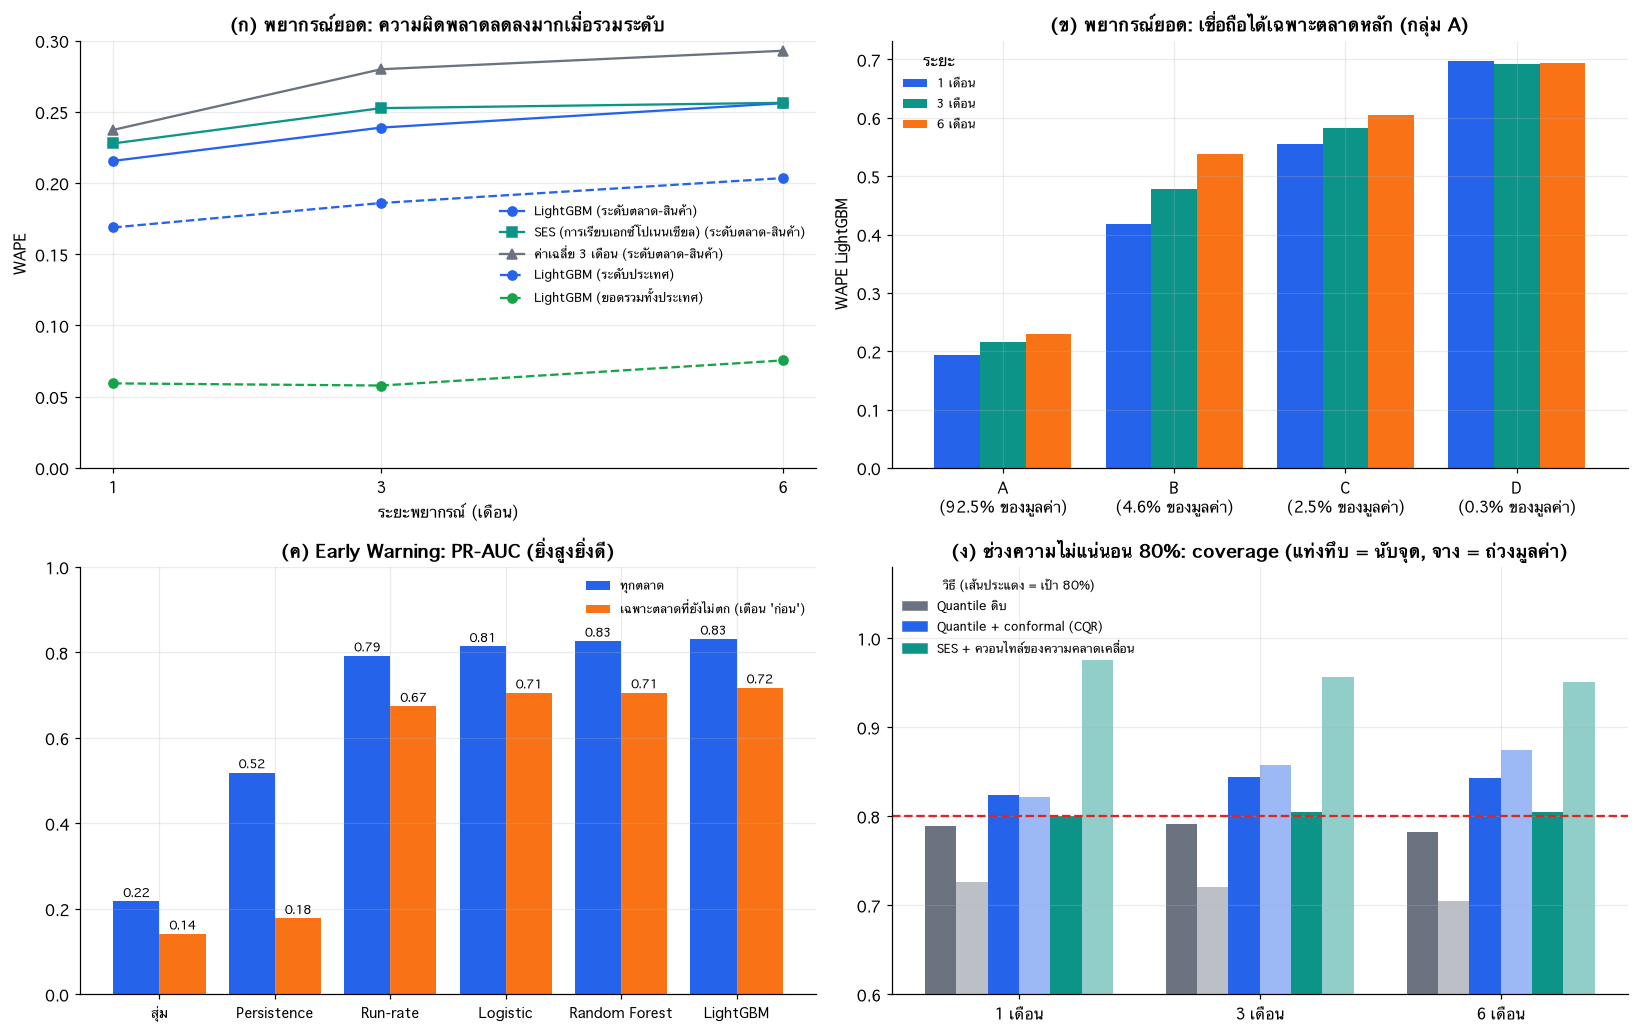

In [95]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9.5))
# (ก) WAPE ตามระยะพยากรณ์
for k_, (c_, mk) in {"LightGBM": (C["blue"], "o"), SES_NAME: (C["teal"], "s"), "ค่าเฉลี่ย 3 เดือน": (C["gray"], "^")}.items():
    ax[0, 0].plot(list(HZ), [W.loc[k_, f"ระยะ {h} เดือน"] for h in HZ], marker=mk, color=c_, label=f"{k_} (ระดับตลาด-สินค้า)")
ax[0, 0].plot(list(HZ), [LV.loc["ประเทศ", f"ระยะ {h}"] for h in HZ], marker="o", color=C["blue"], ls="--", label="LightGBM (ระดับประเทศ)")
ax[0, 0].plot(list(HZ), [LV.loc["ยอดรวม", f"ระยะ {h}"] for h in HZ], marker="o", color=C["green"], ls="--", label="LightGBM (ยอดรวมทั้งประเทศ)")
ax[0, 0].set(title="(ก) พยากรณ์ยอด: ความผิดพลาดลดลงมากเมื่อรวมระดับ", xlabel="ระยะพยากรณ์ (เดือน)", ylabel="WAPE", xticks=list(HZ), ylim=(0, 0.3)); ax[0, 0].legend(frameon=False, fontsize=8)
# (ข) WAPE ตามกลุ่มตลาด
pv = seg3[seg3["กลุ่มตลาด"].isin(list("ABCD"))].pivot(index="กลุ่มตลาด", columns="ระยะ", values="WAPE LightGBM")
shr = seg3[(seg3["ระยะ"] == "1 เดือน") & seg3["กลุ่มตลาด"].isin(list("ABCD"))].set_index("กลุ่มตลาด")["% ของมูลค่า"]
pv.plot.bar(ax=ax[0, 1], rot=0, color=[C["blue"], C["teal"], C["orange"]], width=.8)
ax[0, 1].set_xticklabels([f"{g_}\n({shr[g_]:.1f}% ของมูลค่า)" for g_ in pv.index]); ax[0, 1].set(title="(ข) พยากรณ์ยอด: เชื่อถือได้เฉพาะตลาดหลัก (กลุ่ม A)", ylabel="WAPE LightGBM", xlabel=""); ax[0, 1].legend(title="ระยะ", frameon=False, fontsize=8)
# (ค) Early Warning
names_ = ["อัตราฐาน (สุ่ม)", EW_BASES[0], EW_BASES[1], "Logistic Regression", "Random Forest", "LightGBM"]
lab_ = ["สุ่ม", "Persistence", "Run-rate", "Logistic", "Random Forest", "LightGBM"]
allv = [ewr.loc[n_, "PR-AUC"] for n_ in names_]; nyv = [subt["อัตราคลาสบวก"].iloc[0]] + [subt.loc[n_, "PR-AUC"] for n_ in names_[1:]]
x_ = np.arange(len(names_)); ax[1, 0].bar(x_ - .2, allv, .4, color=C["blue"], label="ทุกตลาด"); ax[1, 0].bar(x_ + .2, nyv, .4, color=C["orange"], label="เฉพาะตลาดที่ยังไม่ตก (เตือน 'ก่อน')")
for xi, (u, v_) in enumerate(zip(allv, nyv)): ax[1, 0].text(xi - .2, u + .01, f"{u:.2f}", ha="center", fontsize=8); ax[1, 0].text(xi + .2, v_ + .01, f"{v_:.2f}", ha="center", fontsize=8)
ax[1, 0].set_xticks(x_); ax[1, 0].set_xticklabels(lab_, fontsize=9); ax[1, 0].set(title="(ค) Early Warning: PR-AUC (ยิ่งสูงยิ่งดี)", ylim=(0, 1.0)); ax[1, 0].legend(frameon=False, fontsize=8)
# (ง) ช่วง 80%
iv = ivt.pivot(index="ระยะ", columns="วิธี", values="coverage (เป้า 0.80)")[["Quantile ดิบ", "Quantile + conformal (CQR)", "SES + ควอนไทล์ของความคลาดเคลื่อน"]]
ivw = ivt.pivot(index="ระยะ", columns="วิธี", values="coverage ถ่วงมูลค่า")[["Quantile ดิบ", "Quantile + conformal (CQR)", "SES + ควอนไทล์ของความคลาดเคลื่อน"]]
x2 = np.arange(len(iv)); wd = .13
for j, (nm, c_) in enumerate(zip(iv.columns, [C["gray"], C["blue"], C["teal"]])):
    ax[1, 1].bar(x2 + (j - 1) * 2 * wd - wd / 2, iv[nm], wd, color=c_, label=f"{nm} (จุด)"); ax[1, 1].bar(x2 + (j - 1) * 2 * wd + wd / 2, ivw[nm], wd, color=c_, alpha=.45, label=f"{nm} (ถ่วงมูลค่า)" if j == 0 else None)
ax[1, 1].axhline(0.8, color=C["red"], ls="--"); ax[1, 1].set_xticks(x2); ax[1, 1].set_xticklabels(iv.index); ax[1, 1].set(title="(ง) ช่วงความไม่แน่นอน 80%: coverage (แท่งทึบ = นับจุด, จาง = ถ่วงมูลค่า)", ylim=(0.6, 1.08))
from matplotlib.patches import Patch
ax[1, 1].legend(handles=[Patch(color=c_, label=nm) for nm, c_ in zip(iv.columns, [C["gray"], C["blue"], C["teal"]])], frameon=False, fontsize=8, loc="upper left", title="วิธี (เส้นประแดง = เป้า 80%)", title_fontsize=8)
plt.tight_layout(); plt.show()

### 📝 อ่านผล: ภาพสรุป (4 แผง)

- **(ก)** LightGBM (เส้นน้ำเงิน) ต่ำกว่า SES และค่าเฉลี่ย 3 เดือนที่ 1 และ 3 เดือน แต่ **เส้นมาบรรจบกันที่ 6 เดือน** ส่วนความผิดพลาดลดลงอย่างมากเมื่อรวมระดับ: ตลาด-สินค้า ~22–26% → ประเทศ ~17–20% → ยอดรวมทั้งประเทศ ~6–8%
- **(ข)** ความผิดพลาดเพิ่มขึ้นชัดเมื่อตลาดเล็กลง: กลุ่ม A ~19–23% → B ~42–54% → C ~55–60% → D ~70% ที่ทุกระยะ
- **(ค)** Early Warning: ทุกโมเดล ML (0.81–0.83) สูงกว่า run-rate (0.79) เล็กน้อย และสูงกว่า persistence (0.52) มาก เฉพาะตลาดที่ยังไม่ตก (แท่งส้ม) persistence ล้มเหลว (0.18) ขณะที่โมเดลคงอยู่ที่ ~0.71
- **(ง)** ช่วงความไม่แน่นอน: Quantile ดิบ (เทา) ต่ำกว่าเป้า 80% โดยเฉพาะเมื่อถ่วงมูลค่า (~0.70–0.73) ส่วน CQR (น้ำเงิน) อยู่เหนือเป้าเล็กน้อย (0.82–0.88) และช่วงแบบง่ายจาก SES (เขียว) ครอบคลุมตลาดใหญ่เกินจำเป็น (0.95–0.98) ซึ่งหมายถึงช่วงกว้างเกินไป

## 5.4 ตรวจความไว: Early Warning เปลี่ยนนิยามแล้วผลเปลี่ยนไหม

ในส่วน 4.4 เกณฑ์ (ตก > 20%) และระยะ (6 เดือน) ถูกกำหนดล่วงหน้าโดยไม่ได้ทดสอบค่าอื่น ตรงนี้ทดสอบ **ความไว** เพื่อดูว่าข้อสรุปขึ้นกับนิยามที่เลือกหรือไม่ — **เป็นการวิเคราะห์เพื่อความเข้าใจ ไม่ได้ใช้เลือกนิยามใหม่** (นิยามหลักยังเป็น 20%/6 เดือน) ใช้ LightGBM และ Logistic Regression (เร็ว) บนช่วงทดสอบเดียวกัน

,ระยะ (เดือน),เกณฑ์ตก,แถว,อัตราคลาสบวก,PR-AUC persistence,PR-AUC run-rate,PR-AUC Logistic,PR-AUC LightGBM,ROC-AUC LightGBM,LightGBM − run-rate,lift (LightGBM ÷ อัตราฐาน)
0,6,0.100,5686,0.351,0.612,0.816,0.837,0.848,0.912,0.032,2.412
1,6,0.200,5686,0.225,0.519,0.792,0.814,0.832,0.938,0.039,3.697
2,6,0.300,5686,0.145,0.447,0.778,0.799,0.814,0.955,0.036,5.605
3,3,0.200,6240,0.233,0.771,0.923,0.931,0.938,0.980,0.016,4.019
4,9,0.200,5134,0.214,0.311,0.594,0.629,0.644,0.858,0.050,3.005


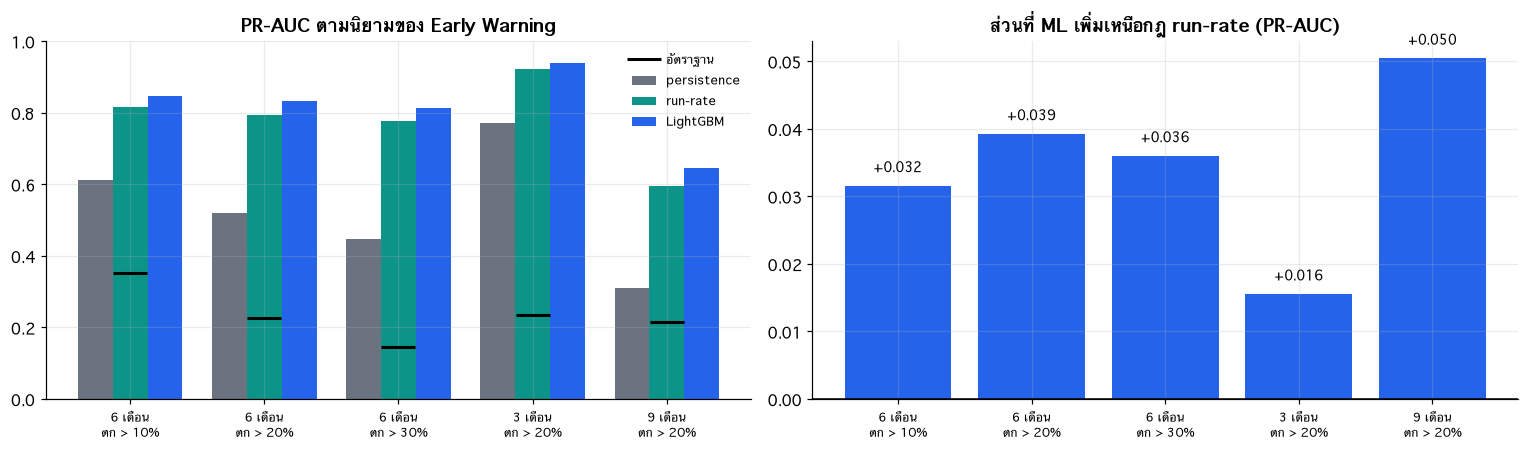

In [96]:
SENS_CACHE = CACHE / "ew_sensitivity.csv"
def ew_sens_run(H, thr):
    Es = ew_dataset(H, thr)
    origs = [o for o in sorted(Es.origin.unique()) if o >= pd.Timestamp("2023-04-01") and o + pd.DateOffset(months=H) <= LAST_MONTH]
    if FAST: origs = origs[:3]
    out = []
    for T in origs:
        T = pd.Timestamp(T)
        tr = Es[(Es.origin + pd.DateOffset(months=H) <= T) & Es.y.notna() & Es.inpop]; te = Es[(Es.origin == T) & Es.y.notna() & Es.inpop]
        out.append(te[["origin", "y", "proj3", "yoy_cur"]].assign(p_lgb=lgb_model(tr, te), p_lr=lr_model(tr, te)))
    d = pd.concat(out)
    return {"ระยะ (เดือน)": H, "เกณฑ์ตก": thr, "แถว": len(d), "อัตราคลาสบวก": d.y.mean(), "PR-AUC persistence": average_precision_score(d.y, -d.yoy_cur.fillna(0)),
            "PR-AUC run-rate": average_precision_score(d.y, -d.proj3.fillna(0)), "PR-AUC Logistic": average_precision_score(d.y, d.p_lr), "PR-AUC LightGBM": average_precision_score(d.y, d.p_lgb), "ROC-AUC LightGBM": roc_auc_score(d.y, d.p_lgb)}
if RETUNE or not SENS_CACHE.exists():
    pd.DataFrame([ew_sens_run(H, t) for H, t in [(6, 0.10), (6, 0.20), (6, 0.30), (3, 0.20), (9, 0.20)]]).to_csv(SENS_CACHE, index=False, encoding="utf-8-sig")
sens = rd(SENS_CACHE)
sens["LightGBM − run-rate"] = sens["PR-AUC LightGBM"] - sens["PR-AUC run-rate"]
sens["lift (LightGBM ÷ อัตราฐาน)"] = sens["PR-AUC LightGBM"] / sens["อัตราคลาสบวก"]
show(sens)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
lbls = [f"{int(r['ระยะ (เดือน)'])} เดือน\nตก > {r['เกณฑ์ตก']:.0%}" for _, r in sens.iterrows()]; xs = np.arange(len(sens))
for j, (cn, c_) in enumerate([("PR-AUC persistence", C["gray"]), ("PR-AUC run-rate", C["teal"]), ("PR-AUC LightGBM", C["blue"])]): ax[0].bar(xs + (j - 1) * .26, sens[cn], .26, color=c_, label=cn.replace("PR-AUC ", ""))
ax[0].plot(xs, sens["อัตราคลาสบวก"], "k_", ms=22, mew=2, label="อัตราฐาน"); ax[0].set_xticks(xs); ax[0].set_xticklabels(lbls, fontsize=8); ax[0].set(title="PR-AUC ตามนิยามของ Early Warning", ylim=(0, 1)); ax[0].legend(frameon=False, fontsize=8)
ax[1].bar(xs, sens["LightGBM − run-rate"], color=C["blue"]); ax[1].set_xticks(xs); ax[1].set_xticklabels(lbls, fontsize=8); ax[1].axhline(0, color="k", lw=1); ax[1].set(title="ส่วนที่ ML เพิ่มเหนือกฎ run-rate (PR-AUC)")
for i_, v_ in enumerate(sens["LightGBM − run-rate"]): ax[1].text(i_, v_ + .002, f"{v_:+.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

### 📝 อ่านผล: ความไวต่อนิยามของ Early Warning

| นิยาม | คลาสบวก | PR-AUC run-rate | PR-AUC LightGBM | ML − run-rate | lift ของ LightGBM |
|---|---|---|---|---|---|
| 6 เดือน, ตก > 10% | 35.1% | 0.816 | 0.848 | +0.032 | 2.4× |
| **6 เดือน, ตก > 20% (นิยามหลัก)** | 22.5% | 0.792 | 0.832 | +0.039 | 3.7× |
| 6 เดือน, ตก > 30% | 14.5% | 0.778 | 0.814 | +0.036 | 5.6× |
| 3 เดือน, ตก > 20% | 23.3% | 0.923 | 0.938 | +0.016 | 4.0× |
| 9 เดือน, ตก > 20% | 21.4% | 0.594 | 0.644 | **+0.050** | 3.0× |

- **ข้อสรุปไม่ขึ้นกับนิยามที่เลือก:** LightGBM สูงกว่า run-rate ในทั้ง 5 นิยาม (+0.016 ถึง +0.050) และสูงกว่า persistence ทุกนิยามมาก
- **เกณฑ์ที่ตกแรงขึ้น เตือนได้ "คม" ขึ้น** (lift 2.4× → 3.7× → 5.6× เมื่อเกณฑ์ 10% → 20% → 30%) เพราะตลาดที่ตกแรงชัดเจนกว่า
- **ระยะไกลขึ้นยากขึ้นมาก:** PR-AUC ลดจาก 0.938 (3 เดือน) → 0.832 (6 เดือน) → 0.644 (9 เดือน) เพราะส่วนที่ "รู้แล้ว" ของหน้าต่าง 12 เดือนลดลงจาก 9 เหลือ 6 และ 3 เดือน (ที่ 3 เดือนเกือบเป็นเลขคณิตล้วน run-rate ได้ 0.923) ขณะที่ **ส่วนที่ ML เพิ่มเหนือกฎง่าย ๆ กลับมากขึ้นเมื่อระยะไกล** (+0.016 → +0.039 → +0.050)
- **ข้อควรระวัง:** การวิเคราะห์นี้ไม่ได้คำนวณช่วงความเชื่อมั่นของส่วนต่างในแต่ละนิยาม และเป็นการตรวจความไว ไม่ได้ใช้เลือกนิยามใหม่

## 5.5 ควรเทรนโมเดลใหม่บ่อยแค่ไหน และความผิดพลาดนิ่งตามเวลาไหม

(ก) เปรียบเทียบนโยบายการเทรน LightGBM ระยะ 1 เดือนในช่วงทดสอบ: **เทรนใหม่ทุกเดือน** (ที่ใช้ในส่วน 4.2) vs ทุก 3, 6, 12 เดือน vs **เทรนครั้งเดียวที่ต้นช่วงทดสอบแล้วไม่ปรับอีก** (ข) ดูความผิดพลาดและ coverage ของช่วง 80% รายเดือน เพื่อดูว่ามีการเสื่อมของโมเดลตามเวลาไหม

In [97]:
orgs = [pd.Timestamp(o) for o in TEST_O[1]]
def retrain_every(k):
    parts = []
    for i in range(0, len(orgs), k):
        blk = orgs[i:i + k]; Tc = blk[0]
        tr = PN[(PN.origin + pd.DateOffset(months=1) <= Tc) & PN["y1"].notna()]; te = PN[PN.origin.isin(blk) & PN["y1"].notna()]
        parts.append(pd.DataFrame({"origin": te.origin.values, "y": te["y1"].values, "pred": np.maximum(lgbm_h(1, BEST_P, **BEST_KW)(tr, te), 0)}))
    return pd.concat(parts)
rt = {}
for k_, nm in ((1, "ทุกเดือน"), (3, "ทุก 3 เดือน"), (6, "ทุก 6 เดือน"), (12, "ทุก 12 เดือน"), (len(orgs), "เทรนครั้งเดียว (ไม่ปรับอีก)")): rt[nm] = metrics(TH[1]["LightGBM"] if k_ == 1 else retrain_every(k_)).WAPE
rt["SES (ไม่ต้องเทรน เทียบ)"] = metrics(TH[1][SES_NAME]).WAPE
rtd = pd.Series(rt).to_frame("WAPE ช่วงทดสอบ (ระยะ 1 เดือน)"); rtd["เทียบเทรนทุกเดือน"] = rtd.iloc[:, 0] / rt["ทุกเดือน"] - 1
show(rtd)

,WAPE ช่วงทดสอบ (ระยะ 1 เดือน),เทียบเทรนทุกเดือน
ทุกเดือน,0.216,0.000
ทุก 3 เดือน,0.216,0.000
ทุก 6 เดือน,0.215,-0.000
ทุก 12 เดือน,0.215,-0.002
เทรนครั้งเดียว (ไม่ปรับอีก),0.219,0.015
SES (ไม่ต้องเทรน เทียบ),0.228,0.057


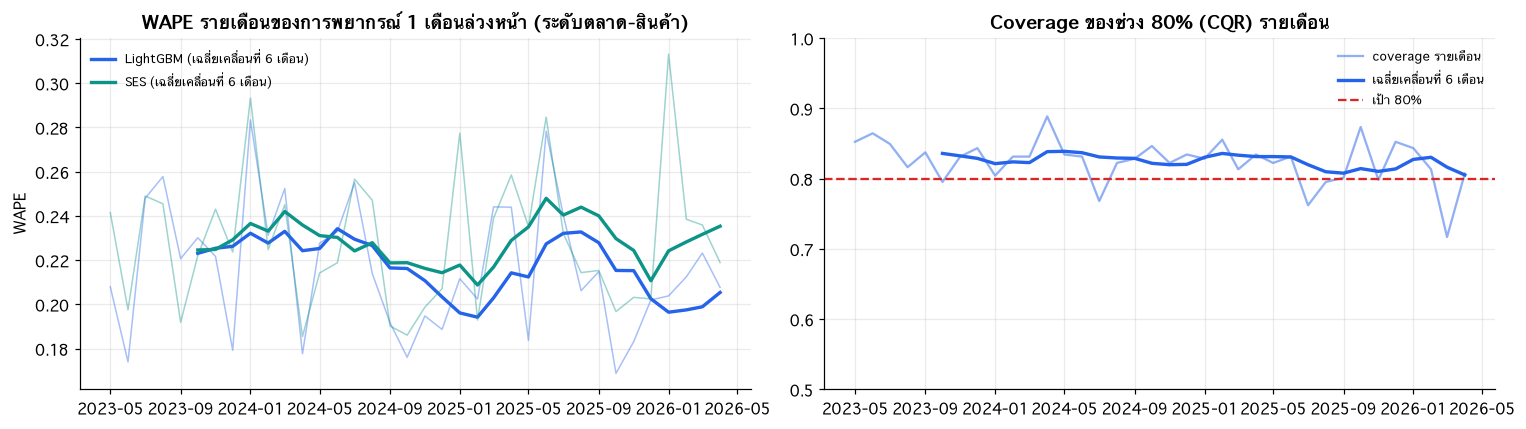

,LightGBM,SES,coverage,LightGBM − SES
ครึ่งที่ 1,0.223,0.225,0.836,-0.002
ครึ่งที่ 2,0.224,0.236,0.838,-0.012
ครึ่งที่ 3,0.216,0.219,0.822,-0.003
ครึ่งที่ 4,0.214,0.229,0.831,-0.015
ครึ่งที่ 5,0.215,0.230,0.814,-0.014
ครึ่งที่ 6,0.205,0.235,0.805,-0.030


LightGBM ดีกว่า SES ใน 25 จาก 36 เดือน


In [98]:
# ความผิดพลาดรายเดือนตามเวลา
mo = pd.DataFrame({"LightGBM": TH[1]["LightGBM"].groupby("origin").apply(lambda g: (g.pred - g.y).abs().sum() / g.y.sum()),
                   "SES": TH[1][SES_NAME].groupby("origin").apply(lambda g: (g.pred - g.y).abs().sum() / g.y.sum())})
cov_m = IV[1].assign(ins=lambda d: (d.y >= d.lo_c) & (d.y <= d.hi_c)).groupby("origin").ins.mean().reindex(mo.index)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
tm = mo.index + pd.DateOffset(months=1)
for cn, c_ in (("LightGBM", C["blue"]), ("SES", C["teal"])): ax[0].plot(tm, mo[cn], color=c_, alpha=.4, lw=1); ax[0].plot(tm, mo[cn].rolling(6).mean(), color=c_, lw=2.2, label=f"{cn} (เฉลี่ยเคลื่อนที่ 6 เดือน)")
ax[0].set(title="WAPE รายเดือนของการพยากรณ์ 1 เดือนล่วงหน้า (ระดับตลาด-สินค้า)", ylabel="WAPE"); ax[0].legend(frameon=False, fontsize=8)
ax[1].plot(tm, cov_m, color=C["blue"], alpha=.5, label="coverage รายเดือน"); ax[1].plot(tm, cov_m.rolling(6).mean(), color=C["blue"], lw=2.2, label="เฉลี่ยเคลื่อนที่ 6 เดือน"); ax[1].axhline(0.8, color=C["red"], ls="--", label="เป้า 80%")
ax[1].set(title="Coverage ของช่วง 80% (CQR) รายเดือน", ylim=(0.5, 1.0)); ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()
half = pd.DataFrame({"LightGBM": mo.LightGBM, "SES": mo.SES, "coverage": cov_m}).groupby(np.arange(len(mo)) // 6).mean(); half.index = [f"ครึ่งที่ {i + 1}" for i in range(len(half))]
show(half.assign(**{"LightGBM − SES": half.LightGBM - half.SES}))
print(f"LightGBM ดีกว่า SES ใน {(mo.LightGBM < mo.SES).sum()} จาก {len(mo)} เดือน")

### 📝 อ่านผล: เทรนใหม่บ่อยแค่ไหน และนิ่งตามเวลาไหม

| นโยบายเทรน (LightGBM ระยะ 1 เดือน) | WAPE ช่วงทดสอบ | เทียบเทรนทุกเดือน |
|---|---|---|
| ทุกเดือน | 0.216 | — |
| ทุก 3 / 6 / 12 เดือน | 0.216 / 0.215 / 0.215 | 0% / −0.0% / −0.2% |
| **เทรนครั้งเดียวต้นช่วงทดสอบ ไม่ปรับอีก 3 ปี** | 0.219 | +1.5% |
| SES (เทียบ) | 0.228 | +5.7% |

- **ความถี่ในการเทรนแทบไม่มีผล:** เทรนทุก 12 เดือนดีเท่ากับทุกเดือน และแม้ *เทรนครั้งเดียวในเดือน เม.ย. 2023 แล้วไม่ปรับอีก* ก็ยังได้ 0.219 ซึ่งดีกว่า SES (0.228) → **ข้อได้เปรียบของ LightGBM ไม่ได้มาจากการเทรนใหม่บ่อย** และในการใช้งานจริงเทรนทุก 6–12 เดือนก็เพียงพอ
- **ความผิดพลาดนิ่งตามเวลา (กราฟ):** WAPE ของ LightGBM รายครึ่งปี 0.223 → 0.224 → 0.216 → 0.214 → 0.215 → 0.205 (ไม่เสื่อมลง) ส่วน SES 0.225 → 0.236 → 0.219 → 0.229 → 0.230 → 0.235 ส่วนต่างขยายจาก −0.002 เป็น −0.030 ในครึ่งปีสุดท้าย LightGBM ชนะ SES ใน **25 จาก 36 เดือน (69%)** *(หมายเหตุ: α ของ SES ถูกเลือกจากช่วง 2019–2022 และไม่ได้ปรับตามเวลา ส่วนหนึ่งของส่วนต่างที่ขยายอาจเป็นเพราะ SES ไม่ได้ปรับ แต่ LightGBM ที่ไม่เทรนใหม่เลยก็ยังดีกว่า SES)*
- **Coverage ของช่วง 80% ลดลงช้า ๆ:** 83.6% → 83.8% → 82.2% → 83.1% → 81.4% → 80.5% (รายครึ่งปี) ยังไม่ต่ำกว่า 80% แต่มีแนวโน้มลดลง จึง **ควรปรับเทียบช่วงใหม่ (CQR) อย่างน้อยปีละครั้ง**

## 5.6 ทบทวนกระบวนการ: ทะเบียนการตัดสินใจและภัยคุกคามต่อความถูกต้อง

In [99]:
reg_dec = pd.DataFrame([
    ("โปรโตคอลทดสอบ (เทรน/ตรวจสอบ/ทดสอบ, rolling-origin, ไม่สุ่ม)", "ตั้งล่วงหน้า", "—"),
    ("ช่วง target เริ่มปี 2015, อนุกรม ≥ 36 เดือนจาก 60 ก่อนช่วงทดสอบ", "ตั้งล่วงหน้า", "—"),
    ("กฎเลือกโมเดล Clustering (ทุกกลุ่ม ≥ 10 ประเทศ, ARI ≥ 0.6, Silhouette สูงสุด)", "ตั้งล่วงหน้า", "—"),
    ("เลือกรูปแบบการเทรน/พารามิเตอร์ LightGBM, α ของ SES, baseline หลัก", "ตั้งล่วงหน้า (ช่วงตรวจสอบเท่านั้น)", "—"),
    ("**เพิ่ม baseline SES หลังเห็นผลทดสอบรอบแรก**", "**หลังเห็นผล**", "เปิดเผยแล้วในส่วน 4.2; เลือก α จากช่วงตรวจสอบ; ทำให้ข้อสรุป 'ML ชนะ' อ่อนลง (เหนือ SES 5% จากเหนือค่าเฉลี่ย 3 เดือน 9%)"),
    ("ทดสอบถอดกลุ่มตัวแปร (ablation) และความสำคัญตัวแปร", "หลังเห็นผล (วิเคราะห์เพื่อเข้าใจ)", "ไม่ได้ใช้เลือกโมเดล"),
    ("order ของ ARIMA/SARIMA (1,1,1)(0,1,1)₁₂", "ตั้งล่วงหน้า (ไม่ปรับ)", "อาจเป็นข้อเสียเปรียบของ ARIMA"),
    ("ช่วง 80%: ปรับเทียบ (CQR) ด้วยช่วงตรวจสอบ", "ตั้งล่วงหน้า", "—"),
    ("นิยาม Early Warning (ตก > 20%, 6 เดือน, ฐาน ≥ 1 ล้าน), baseline 3 แบบ, โมเดลหลักจากช่วงตรวจสอบ", "ตั้งล่วงหน้า", "—"),
    ("วิเคราะห์ 'เฉพาะตลาดที่ยังไม่ตก' และ calibration ของ Early Warning", "**หลังเห็นผล**", "เพิ่มเพื่อตรวจว่า baseline persistence ได้เปรียบเกินจริงหรือไม่"),
    ("ตรวจความไวของนิยาม Early Warning และนโยบายเทรนใหม่ (ส่วน 5.4–5.5)", "หลังเห็นผล (วิเคราะห์เพื่อเข้าใจ)", "ไม่ได้ใช้เปลี่ยนโมเดล/นิยามหลัก"),
], columns=["การตัดสินใจ/การวิเคราะห์", "ตั้งล่วงหน้าหรือหลังเห็นผล", "หมายเหตุ"])
display(reg_dec)
threats = pd.DataFrame([
    ("ข้อมูล", "Comtrade เป็นรายงานศุลกากรไทย หน่วย USD ระดับ HS4 (10 กลุ่ม) ไม่ใช่ HS11; ไต้หวันอยู่ใน 'Other Asia, nes'", "ตัวเลขตรงกับกรมประมงปี 2025 ภายใน ±3% (ส่วน 2.8) แต่ยังไม่รู้ผลของการปรับปรุงย้อนหลัง (revisions) ของ Comtrade"),
    ("ช่วงทดสอบ", "หน้าต่างเดียว 36 เดือน (พ.ค. 2023 – เม.ย. 2026) ข้อได้เปรียบของ ML ไม่คงที่ข้ามปี", "ผลอาจเปลี่ยนในช่วงเศรษฐกิจ/นโยบายการค้าแบบอื่น (เช่น ภาษี สงคราม โรคระบาด)"),
    ("ความเป็นอิสระ", "bootstrap สุ่มเดือนด้วยการแทนที่ ถือเดือนเป็นอิสระ ซึ่งไม่จริงทั้งหมด", "ช่วงความเชื่อมั่นจริงอาจกว้างกว่าที่รายงาน"),
    ("การเปรียบเทียบหลายครั้ง", "เปรียบเทียบหลายโมเดล/ระยะ/กลุ่ม ไม่ได้ปรับค่านัยสำคัญ", "ควรอ่านผลที่ 'ชนะเล็กน้อย' ด้วยความระมัดระวัง"),
    ("Early Warning", "หน้าต่างของป้ายซ้อนกับของตัวแปร", "ชดเชยด้วย baseline run-rate และการวัดเฉพาะตลาดที่ยังไม่ตก"),
    ("ขอบเขตอนุกรม", "เลือกจากกิจกรรมก่อนช่วงทดสอบ — ตลาดใหม่ (cold start) ราว 1.3% ของมูลค่าพยากรณ์ไม่ได้", "ระบุเป็นขอบเขต (ส่วน 3.8)"),
    ("หน่วยและความหมายคอลัมน์", "ข้อมูลกรมประมงหลายคอลัมน์ไม่ระบุหน่วย (อนุมาน)", "โมเดลหลักใช้ Comtrade ที่หน่วยชัดเจน"),
    ("ข้อมูลภายนอก", "ค่าเงินและเศรษฐกิจรายประเทศไม่ช่วยทำนาย (ส่วน 4.2.7) อาจเพราะความละเอียดรายเดือน/ประเทศไม่ตรงกับข้อมูลรายปี", "ไม่ได้ลองข้อมูลเหตุการณ์ (นโยบายภาษี การห้ามนำเข้า) ซึ่งอาจมีผลกว่า"),
], columns=["ประเด็น", "ภัยคุกคามต่อความถูกต้อง", "การจัดการ / ผลต่อข้อสรุป"])
display(threats)

,การตัดสินใจ/การวิเคราะห์,ตั้งล่วงหน้าหรือหลังเห็นผล,หมายเหตุ
0,"โปรโตคอลทดสอบ (เทรน/ตรวจสอบ/ทดสอบ, rolling-origin, ไม่สุ่ม)",ตั้งล่วงหน้า,—
1,"ช่วง target เริ่มปี 2015, อนุกรม ≥ 36 เดือนจาก 60 ก่อนช่วงทดสอบ",ตั้งล่วงหน้า,—
2,"กฎเลือกโมเดล Clustering (ทุกกลุ่ม ≥ 10 ประเทศ, ARI ≥ 0.6, Silhouette สูงสุด)",ตั้งล่วงหน้า,—
3,"เลือกรูปแบบการเทรน/พารามิเตอร์ LightGBM, α ของ SES, baseline หลัก",ตั้งล่วงหน้า (ช่วงตรวจสอบเท่านั้น),—
4,**เพิ่ม baseline SES หลังเห็นผลทดสอบรอบแรก**,**หลังเห็นผล**,เปิดเผยแล้วในส่วน 4.2; เลือก α จากช่วงตรวจสอบ; ทำให้ข้อสรุป 'ML ชนะ' อ่อนลง (เหนือ SES 5% จากเหนือค่าเฉลี่ย 3 เดือน 9%)
5,ทดสอบถอดกลุ่มตัวแปร (ablation) และความสำคัญตัวแปร,หลังเห็นผล (วิเคราะห์เพื่อเข้าใจ),ไม่ได้ใช้เลือกโมเดล
6,"order ของ ARIMA/SARIMA (1,1,1)(0,1,1)₁₂",ตั้งล่วงหน้า (ไม่ปรับ),อาจเป็นข้อเสียเปรียบของ ARIMA
7,ช่วง 80%: ปรับเทียบ (CQR) ด้วยช่วงตรวจสอบ,ตั้งล่วงหน้า,—
8,"นิยาม Early Warning (ตก > 20%, 6 เดือน, ฐาน ≥ 1 ล้าน), baseline 3 แบบ, โมเดลหลักจากช่วงตรวจสอบ",ตั้งล่วงหน้า,—
9,วิเคราะห์ 'เฉพาะตลาดที่ยังไม่ตก' และ calibration ของ Early Warning,**หลังเห็นผล**,เพิ่มเพื่อตรวจว่า baseline persistence ได้เปรียบเกินจริงหรือไม่


,ประเด็น,ภัยคุกคามต่อความถูกต้อง,การจัดการ / ผลต่อข้อสรุป
0,ข้อมูล,"Comtrade เป็นรายงานศุลกากรไทย หน่วย USD ระดับ HS4 (10 กลุ่ม) ไม่ใช่ HS11; ไต้หวันอยู่ใน 'Other Asia, nes'",ตัวเลขตรงกับกรมประมงปี 2025 ภายใน ±3% (ส่วน 2.8) แต่ยังไม่รู้ผลของการปรับปรุงย้อนหลัง (revisions) ของ Comtrade
1,ช่วงทดสอบ,หน้าต่างเดียว 36 เดือน (พ.ค. 2023 – เม.ย. 2026) ข้อได้เปรียบของ ML ไม่คงที่ข้ามปี,ผลอาจเปลี่ยนในช่วงเศรษฐกิจ/นโยบายการค้าแบบอื่น (เช่น ภาษี สงคราม โรคระบาด)
2,ความเป็นอิสระ,bootstrap สุ่มเดือนด้วยการแทนที่ ถือเดือนเป็นอิสระ ซึ่งไม่จริงทั้งหมด,ช่วงความเชื่อมั่นจริงอาจกว้างกว่าที่รายงาน
3,การเปรียบเทียบหลายครั้ง,เปรียบเทียบหลายโมเดล/ระยะ/กลุ่ม ไม่ได้ปรับค่านัยสำคัญ,ควรอ่านผลที่ 'ชนะเล็กน้อย' ด้วยความระมัดระวัง
4,Early Warning,หน้าต่างของป้ายซ้อนกับของตัวแปร,ชดเชยด้วย baseline run-rate และการวัดเฉพาะตลาดที่ยังไม่ตก
5,ขอบเขตอนุกรม,เลือกจากกิจกรรมก่อนช่วงทดสอบ — ตลาดใหม่ (cold start) ราว 1.3% ของมูลค่าพยากรณ์ไม่ได้,ระบุเป็นขอบเขต (ส่วน 3.8)
6,หน่วยและความหมายคอลัมน์,ข้อมูลกรมประมงหลายคอลัมน์ไม่ระบุหน่วย (อนุมาน),โมเดลหลักใช้ Comtrade ที่หน่วยชัดเจน
7,ข้อมูลภายนอก,ค่าเงินและเศรษฐกิจรายประเทศไม่ช่วยทำนาย (ส่วน 4.2.7) อาจเพราะความละเอียดรายเดือน/ประเทศไม่ตรงกับข้อมูลรายปี,ไม่ได้ลองข้อมูลเหตุการณ์ (นโยบายภาษี การห้ามนำเข้า) ซึ่งอาจมีผลกว่า


### 📝 อ่านผล: ทบทวนกระบวนการ

**ทะเบียนการตัดสินใจ:** การตัดสินใจหลักตั้งล่วงหน้า (โปรโตคอล กฎเลือกโมเดล พารามิเตอร์จากช่วงตรวจสอบ) มี 3 จุดที่ทำหลังเห็นผลและเปิดเผยไว้: (1) **เพิ่ม baseline SES** (ทำให้ข้อสรุป "ML ชนะ" อ่อนลงจาก 9% เหลือ 5%) (2) วิเคราะห์ตลาดที่ยังไม่ตกและ calibration ของ Early Warning (3) ablation, ความไว และนโยบายเทรนใหม่ (วิเคราะห์เพื่อเข้าใจ ไม่ได้ใช้เปลี่ยนโมเดล)

**ภัยคุกคามต่อความถูกต้องที่สำคัญที่สุด 3 ข้อ**
1. **หน้าต่างทดสอบเดียว 36 เดือน** — ข้อได้เปรียบของ ML ไม่คงที่ข้ามปี ผลอาจเปลี่ยนในช่วงที่เศรษฐกิจ/นโยบายการค้าต่างออกไป
2. **การสุ่มเดือนแบบอิสระ (bootstrap)** ทำให้ช่วงความเชื่อมั่นอาจแคบเกินจริง
3. **ไม่ได้ปรับค่านัยสำคัญสำหรับการเปรียบเทียบหลายครั้ง** ผลที่ชนะเล็กน้อย (เช่น 5% เหนือ SES, ML เหนือ run-rate 4%) ควรอ่านอย่างระมัดระวัง

## 5.7 บันทึกตารางผลสรุป

In [100]:
rows = []
for h in HZ:
    for m_ in W.index: rows.append(("Goal 1 พยากรณ์", m_, f"ระยะ {h} เดือน · ระดับตลาด-สินค้า", "WAPE", W.loc[m_, f"ระยะ {h} เดือน"]))
    for lv in LV.index: rows.append(("Goal 1 พยากรณ์", "LightGBM", f"ระยะ {h} เดือน · ระดับ{lv}", "WAPE", LV.loc[lv, f"ระยะ {h}"]))
    for _, r in ivt[ivt["ระยะ"] == f"{h} เดือน"].iterrows(): rows.append(("Goal 1 ช่วง 80%", r["วิธี"], f"ระยะ {h} เดือน", "coverage", r.iloc[2]))
for m_ in ewr.index:
    for c_ in ("PR-AUC", "ROC-AUC", "Precision เตือน 10%", "Precision เตือน 20%"): rows.append(("Goal 3 Early Warning", m_, "ทุกตลาด ทดสอบ", c_, ewr.loc[m_, c_]))
for m_ in subt.index: rows.append(("Goal 3 Early Warning", m_, "ตลาดที่ยังไม่ตก", "PR-AUC", subt.loc[m_, "PR-AUC"]))
for nm_, v_ in stab.items(): rows.append(("Goal 2 Clustering", "K-Means k=4", "ความเสถียร", nm_, v_))
SUMM = pd.DataFrame(rows, columns=["โจทย์", "โมเดล/วิธี", "ตั้งค่า", "ตัวชี้วัด", "ค่า"])
if not FAST: SUMM.to_csv(PREP / "results_summary.csv", index=False, encoding="utf-8-sig")
print("บันทึก DATASET/prepared/results_summary.csv" if not FAST else "(โหมดเร็ว)", SUMM.shape)
display(SUMM.head(6))

บันทึก DATASET/prepared/results_summary.csv (76, 5)


,โจทย์,โมเดล/วิธี,ตั้งค่า,ตัวชี้วัด,ค่า
0,Goal 1 พยากรณ์,LightGBM,ระยะ 1 เดือน · ระดับตลาด-สินค้า,WAPE,0.22
1,Goal 1 พยากรณ์,SES (การเรียบเอกซ์โปเนนเชียล),ระยะ 1 เดือน · ระดับตลาด-สินค้า,WAPE,0.23
2,Goal 1 พยากรณ์,ค่าเฉลี่ย 12 เดือน,ระยะ 1 เดือน · ระดับตลาด-สินค้า,WAPE,0.24
3,Goal 1 พยากรณ์,ค่าเฉลี่ย 3 เดือน,ระยะ 1 เดือน · ระดับตลาด-สินค้า,WAPE,0.24
4,Goal 1 พยากรณ์,Ridge,ระยะ 1 เดือน · ระดับตลาด-สินค้า,WAPE,0.26
5,Goal 1 พยากรณ์,เท่ากับเดือนก่อน,ระยะ 1 เดือน · ระดับตลาด-สินค้า,WAPE,0.25


### สรุป Evaluation และข้อเสนอแนะ

### 📝 สรุป Evaluation

**ภาพรวม:** โครงงานตอบเป้าหมายทางธุรกิจทั้ง 3 ข้อได้ในระดับหนึ่ง ผ่านเกณฑ์ที่ตั้งไว้ 7 จาก 9 ข้อ (ผ่านบางส่วน 2) ไม่มีข้อที่ไม่ผ่าน และผลลัพธ์ที่สม่ำเสมอที่สุดคือข้อสรุปที่ว่า **ML ช่วยได้จริงแต่เหนือวิธีง่าย ๆ เพียงราว 4–6%** ในทั้งการพยากรณ์และการเตือน เนื่องจากสัญญาณของข้อมูลอ่อนโดยธรรมชาติ (ผันผวนสูง ไม่มีฤดูกาลที่ใช้ได้)

**ข้อเสนอแนะการนำไปใช้**
| การใช้งาน | วิธีที่แนะนำ | ความน่าเชื่อถือ |
|---|---|---|
| วางแผนยอดส่งออกรวมทั้งประเทศ (1–6 เดือน) | LightGBM หรือ SES | ผิดพลาด ~6–8% (ใช้ได้จริง) |
| พยากรณ์รายตลาด-สินค้า 1–3 เดือน | LightGBM + ช่วง 80% (CQR) **เฉพาะตลาดกลุ่ม A** | ผิดพลาด ~19–23% |
| พยากรณ์ 6 เดือน | SES หรือค่าเฉลี่ย 12 เดือน (ได้ผลเท่า ML และง่ายกว่า) หรือระดับรวม | — |
| ตลาดกลุ่ม B–D | ใช้ภาพรวมเท่านั้น **ไม่ใช้ตัวเลขรายตลาดตัดสินใจ** | ผิดพลาด 42–70% |
| เตือนตลาดยอดตก | จับตา 10–20% ของตลาดที่เสี่ยงสุดต่อเดือน แล้วตรวจสอบด้วยผู้เชี่ยวชาญ | แม่น 76–89% (lift 3–4 เท่า) |

**แผนติดตามผลหากนำไปใช้จริง**
- เทรนโมเดลใหม่ทุก 6–12 เดือน (ความถี่ไม่ส่งผลต่อความแม่นยำมากนัก) · ปรับเทียบช่วงความไม่แน่นอนใหม่อย่างน้อยปีละครั้ง
- ติดตาม WAPE และ coverage รายเดือน เทียบ baseline SES · ตรวจ Early Warning เมื่อรู้ผลจริง (ป้ายของ origin เม.ย. 2026 จะรู้ราว ต.ค. 2026)

**ข้อมูลที่ควรเพิ่มเพื่อปรับปรุง:** รหัส HS ละเอียดกว่า 4 หลักในช่วงยาว · ข้อมูลเหตุการณ์ (ภาษี การห้ามนำเข้า มาตรฐานสินค้า) ซึ่งน่าจะอธิบายการตกของตลาดได้มากกว่าค่าเงินหรือ GDP · ข้อมูลราคาตลาดจริง · ตลาดไต้หวันที่ถูกรวมใน "Other Asia, nes"

> **สถานะ:** Business Understanding · Data Understanding · Data Preparation · Modeling · **Evaluation เสร็จแล้ว** เหลือ Deployment (รายงาน สไลด์นำเสนอ ตัวอย่างการใช้ผลลัพธ์)